In [ ]:
# Should be executed first in a fresh venv
import os
FIG_ROOT = os.environ.get('SCDIS_FIG', os.path.join(os.environ['SCDIS_ROOT'], 'figures'))

# Compute Metrics

In [1]:
import scanpy as sc
import compute_metrics_norman as cmn

#### If pre-processed norman accessible:

In [2]:
adata = sc.read_h5ad('../../Datasets/preprocessed_datasets/norman.h5ad')
all_perts = adata.obs['condition'].unique().tolist()
double_perts = [x for x in all_perts if '+' in x]
len(double_perts)

data_name = 'Norman'

##### Otherwise skip the cell above and run:

In [ ]:
import glob, os
double_perts = sorted(os.path.basename(f)[:-4] for f in
                      glob.glob('results/Norman/combinatorially_seen/SCDISENTANGLE/*.csv'))
data_name = 'Norman'

# Combinatorially seen

In [ ]:
# # Baseline

# cmn.compute_metrics_baselines(
#     data_name=data_name,
#     custom_name='combinatorially_seen',
#     methods=['Pert Mean', 'Match Mean'],
#     cond_key='condition',
#     control_name='ctrl',
#     degs_key='rank_genes_groups',
#     ood_labels=double_perts,
#     scenario='1',
# )

In [ ]:
# # Models 

# print('computing metrics')
# cmn.compute_metrics(
#     data_name=data_name,
#     custom_name='combinatorially_seen',
#     methods= ['SCDISENTANGLE', 'CPA', 'GEARS'],
#     cond_key='cond_harm',
#     control_name='ctrl',
#     degs_key='rank_genes_groups',
#     ood_labels=double_perts,
#     scenario='1',
# )

# Single only

In [3]:
conds = [
    'CBL+CNN1', 'DUSP9+ETS2', 'DUSP9+MAPK1', 
    'ETS2+MAPK1', 'ETS2+CEBPE', 'CNN1+MAPK1', 
    'CEBPB+CEBPA', 'CBL+PTPN12', 'AHR+FEV', 
]

In [ ]:
# Baseline

cmn.compute_metrics_baselines(
    data_name=data_name,
    methods=['Pert Mean', 'Match Mean'],
    cond_key='condition',
    control_name='ctrl',
    degs_key='rank_genes_groups',
    ood_labels=conds,
    scenario='2',
    custom_name='single_only'
)

In [ ]:
# # Models

# cmn.compute_metrics(
#     data_name=data_name,
#     custom_name='single_only',
#     methods= ['SCDISENTANGLE', 'CPA', 'GEARS'],
#     cond_key='cond_harm',
#     control_name='ctrl',
#     degs_key='rank_genes_groups',
#     ood_labels=conds,
#     scenario='2',
# )

# Export results

In [4]:
import os
import glob
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import hygeia.utils.hplots as hp
import metrics_tools as mt

In [5]:
data_name = 'Norman'
cond_key = 'condition'
control_name = 'ctrl'
custom_name = 'combinatorially_seen'
ood_labels = double_perts

all_results = []
for ood_l in ood_labels:
    all_results.append(f'{ood_l}')

base_path = f'results/{data_name}/{custom_name}'
os.makedirs(f'{FIG_ROOT}/{data_name}/{custom_name}/Benchmarks/', exist_ok=True)

Using 128 perturbation


/home/SE/Desktop/Projects/SCDISENTANGLE/hygeia/hygeia/utils/hplots.py:208: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


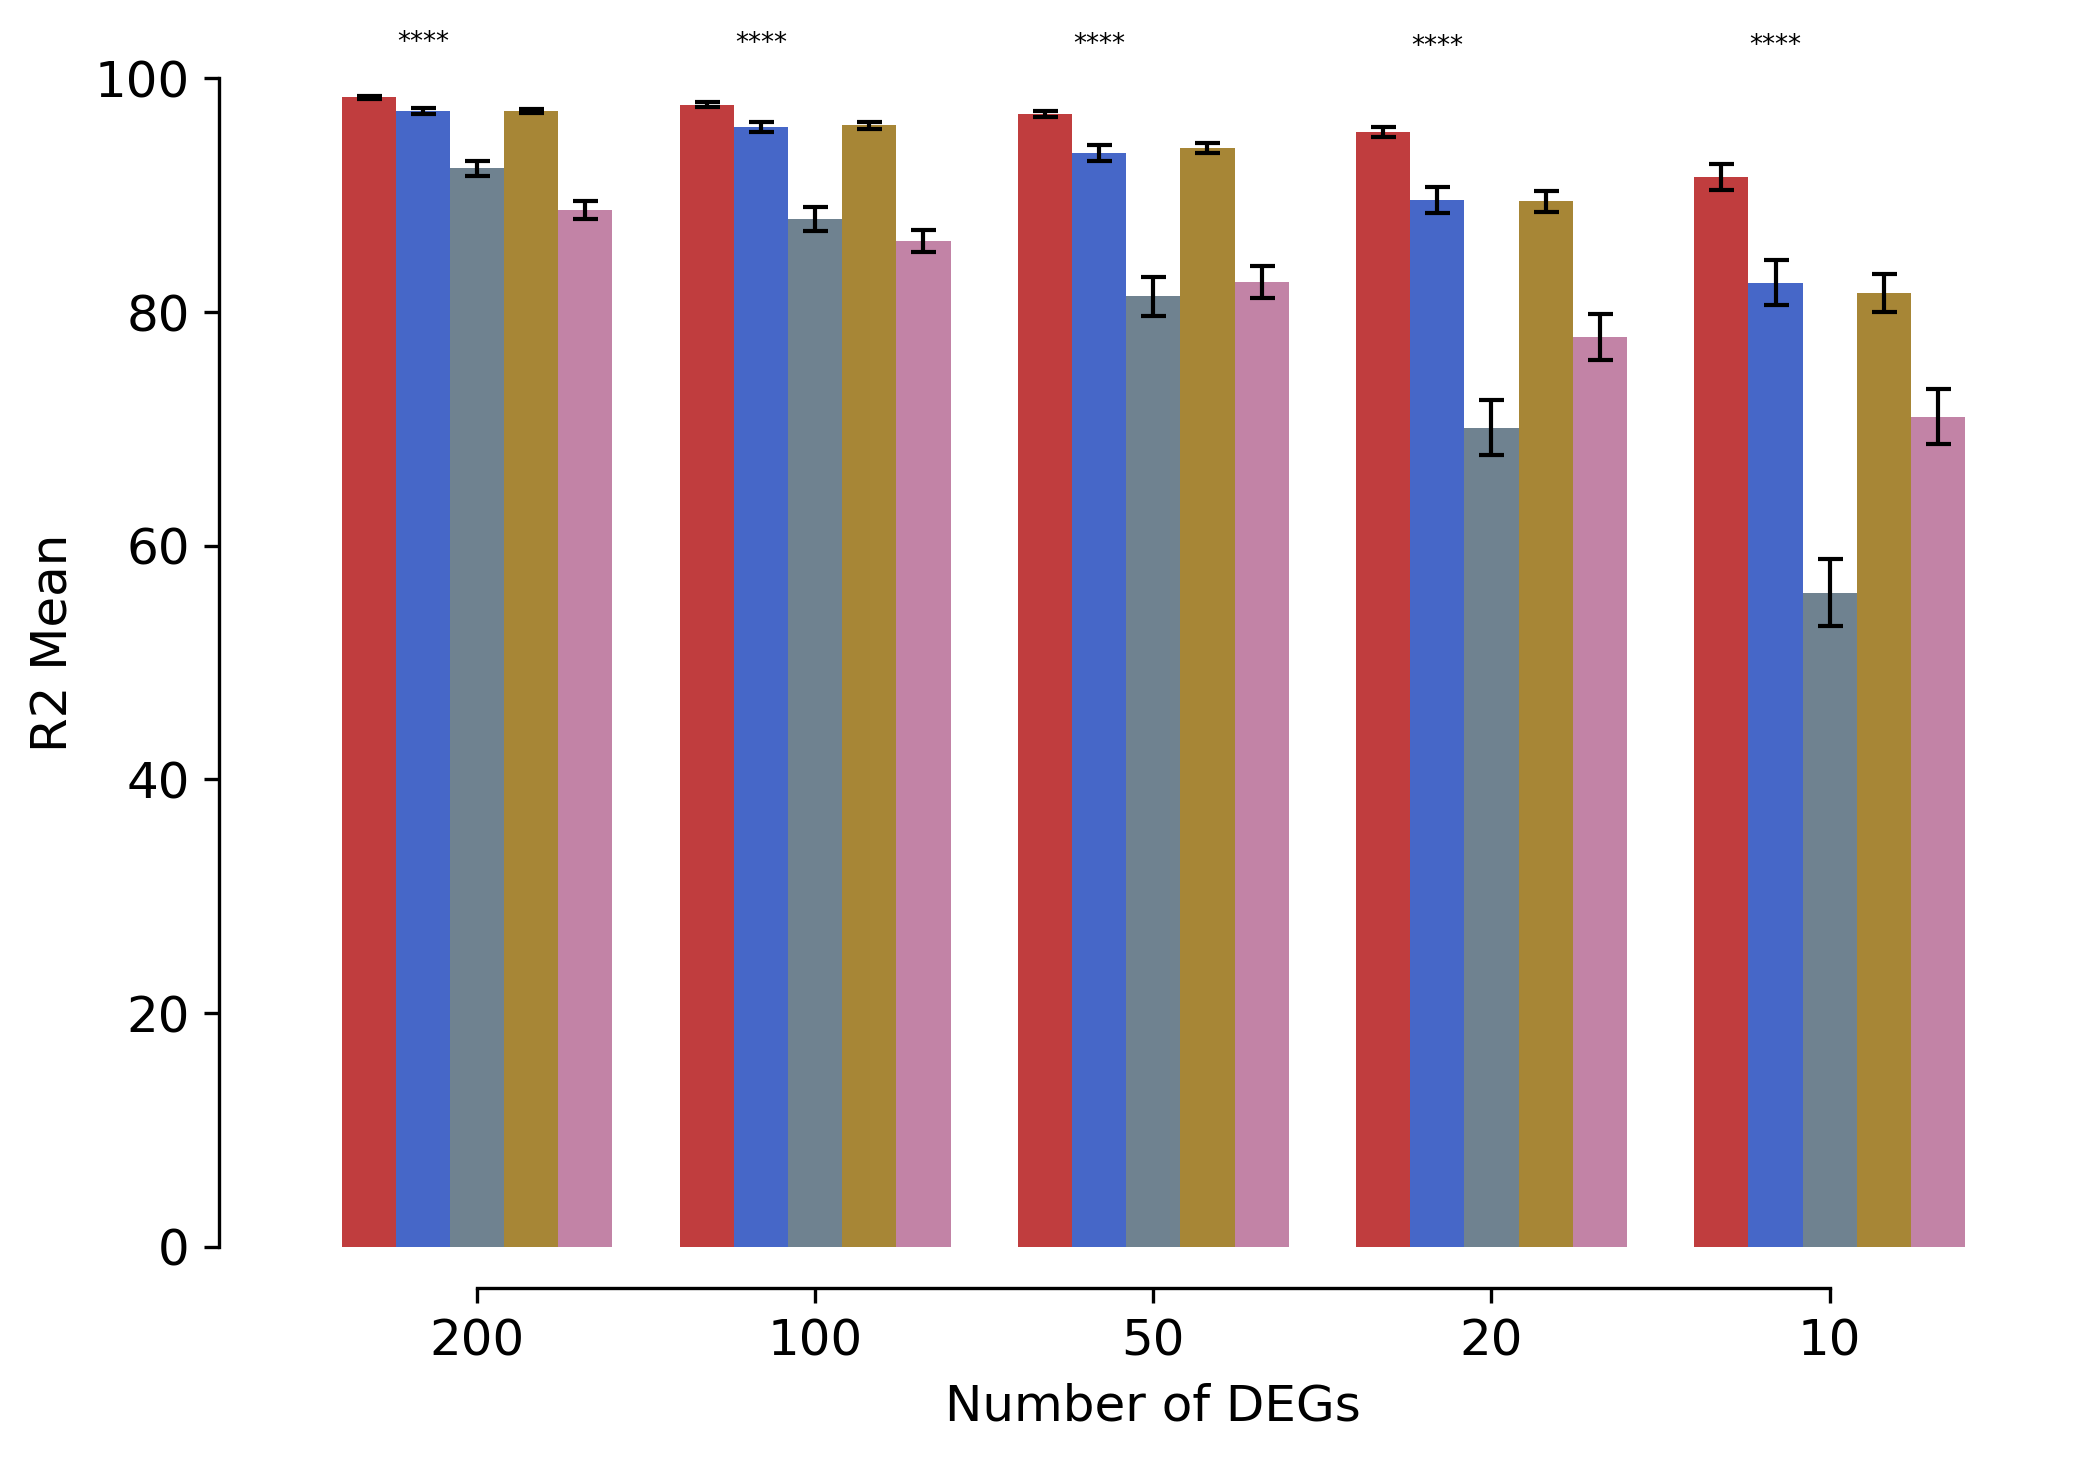

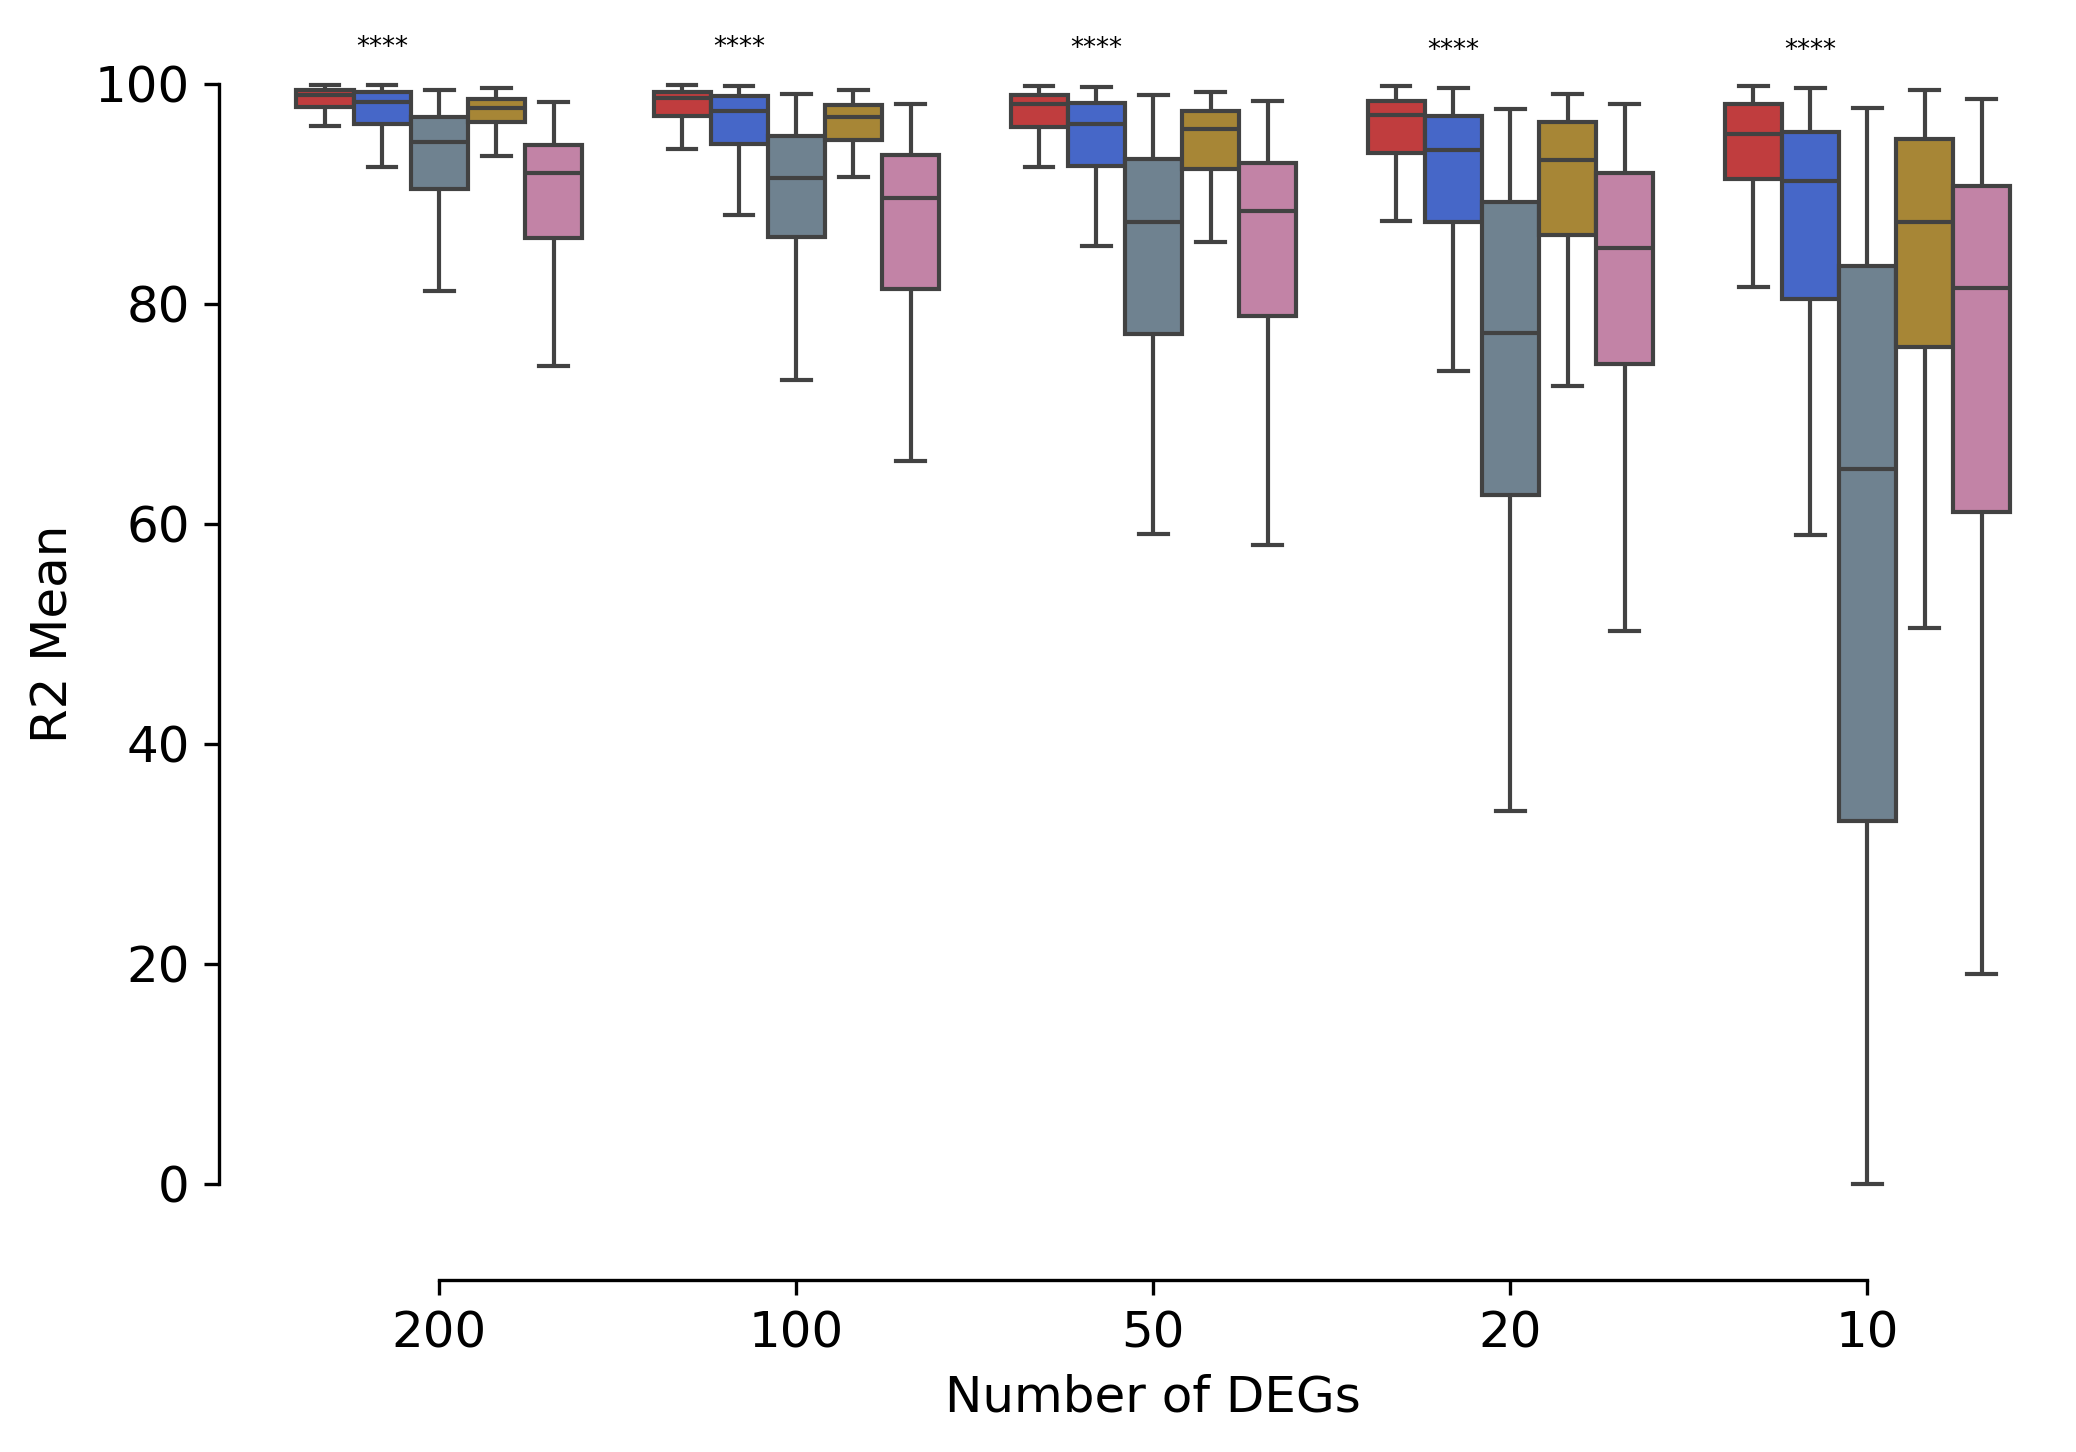

Using 128 perturbation


/home/SE/Desktop/Projects/SCDISENTANGLE/hygeia/hygeia/utils/hplots.py:208: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


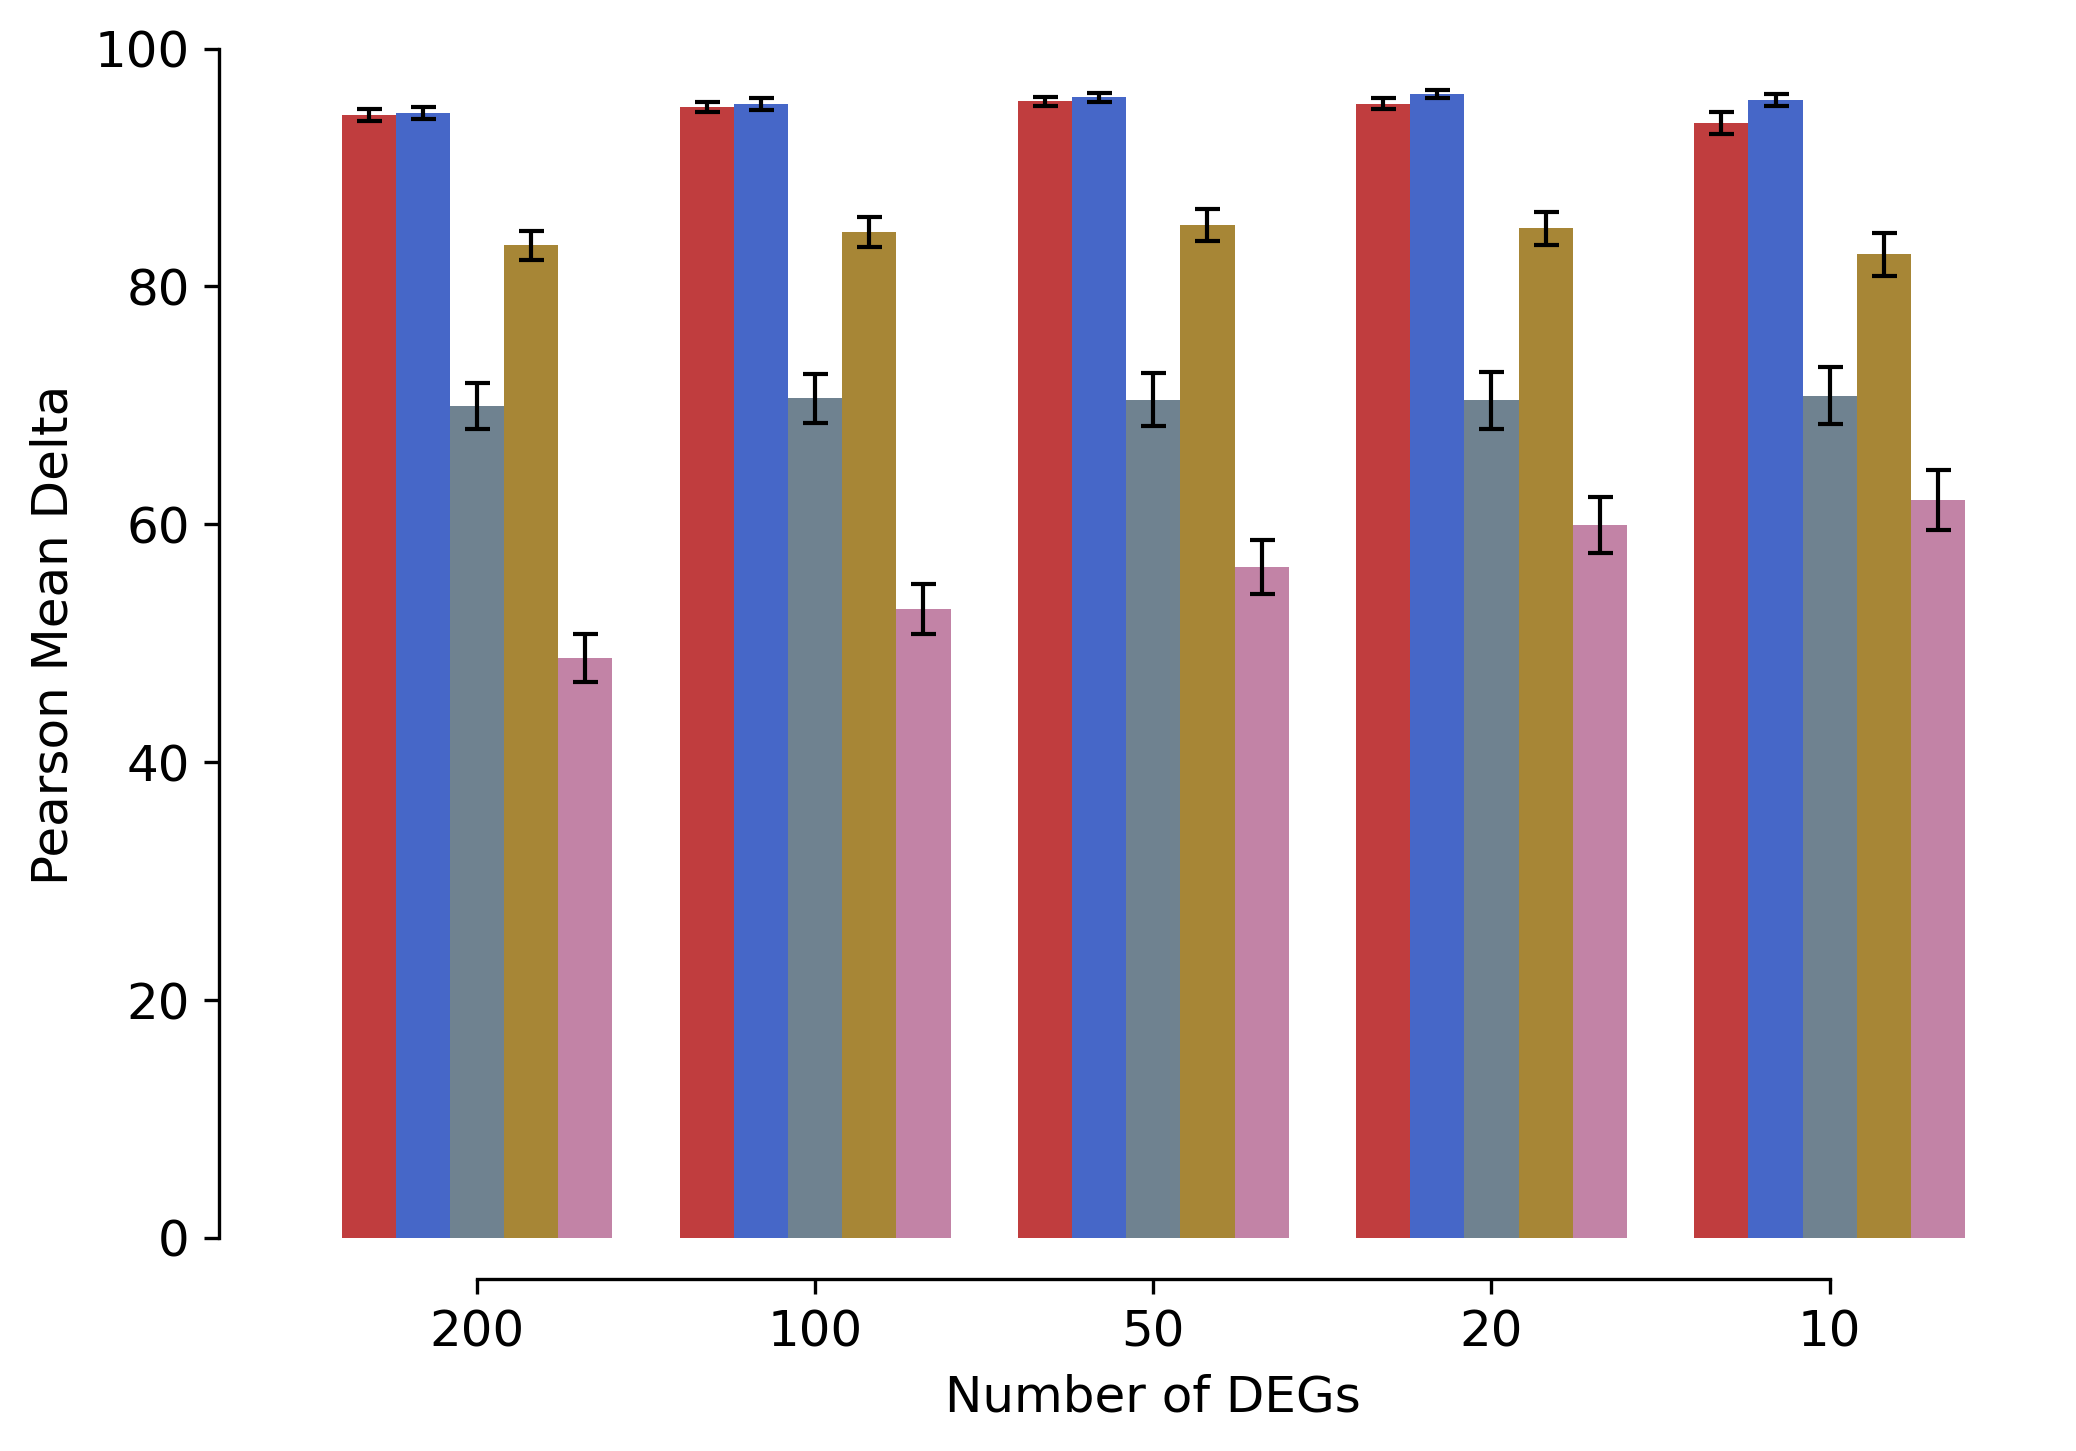

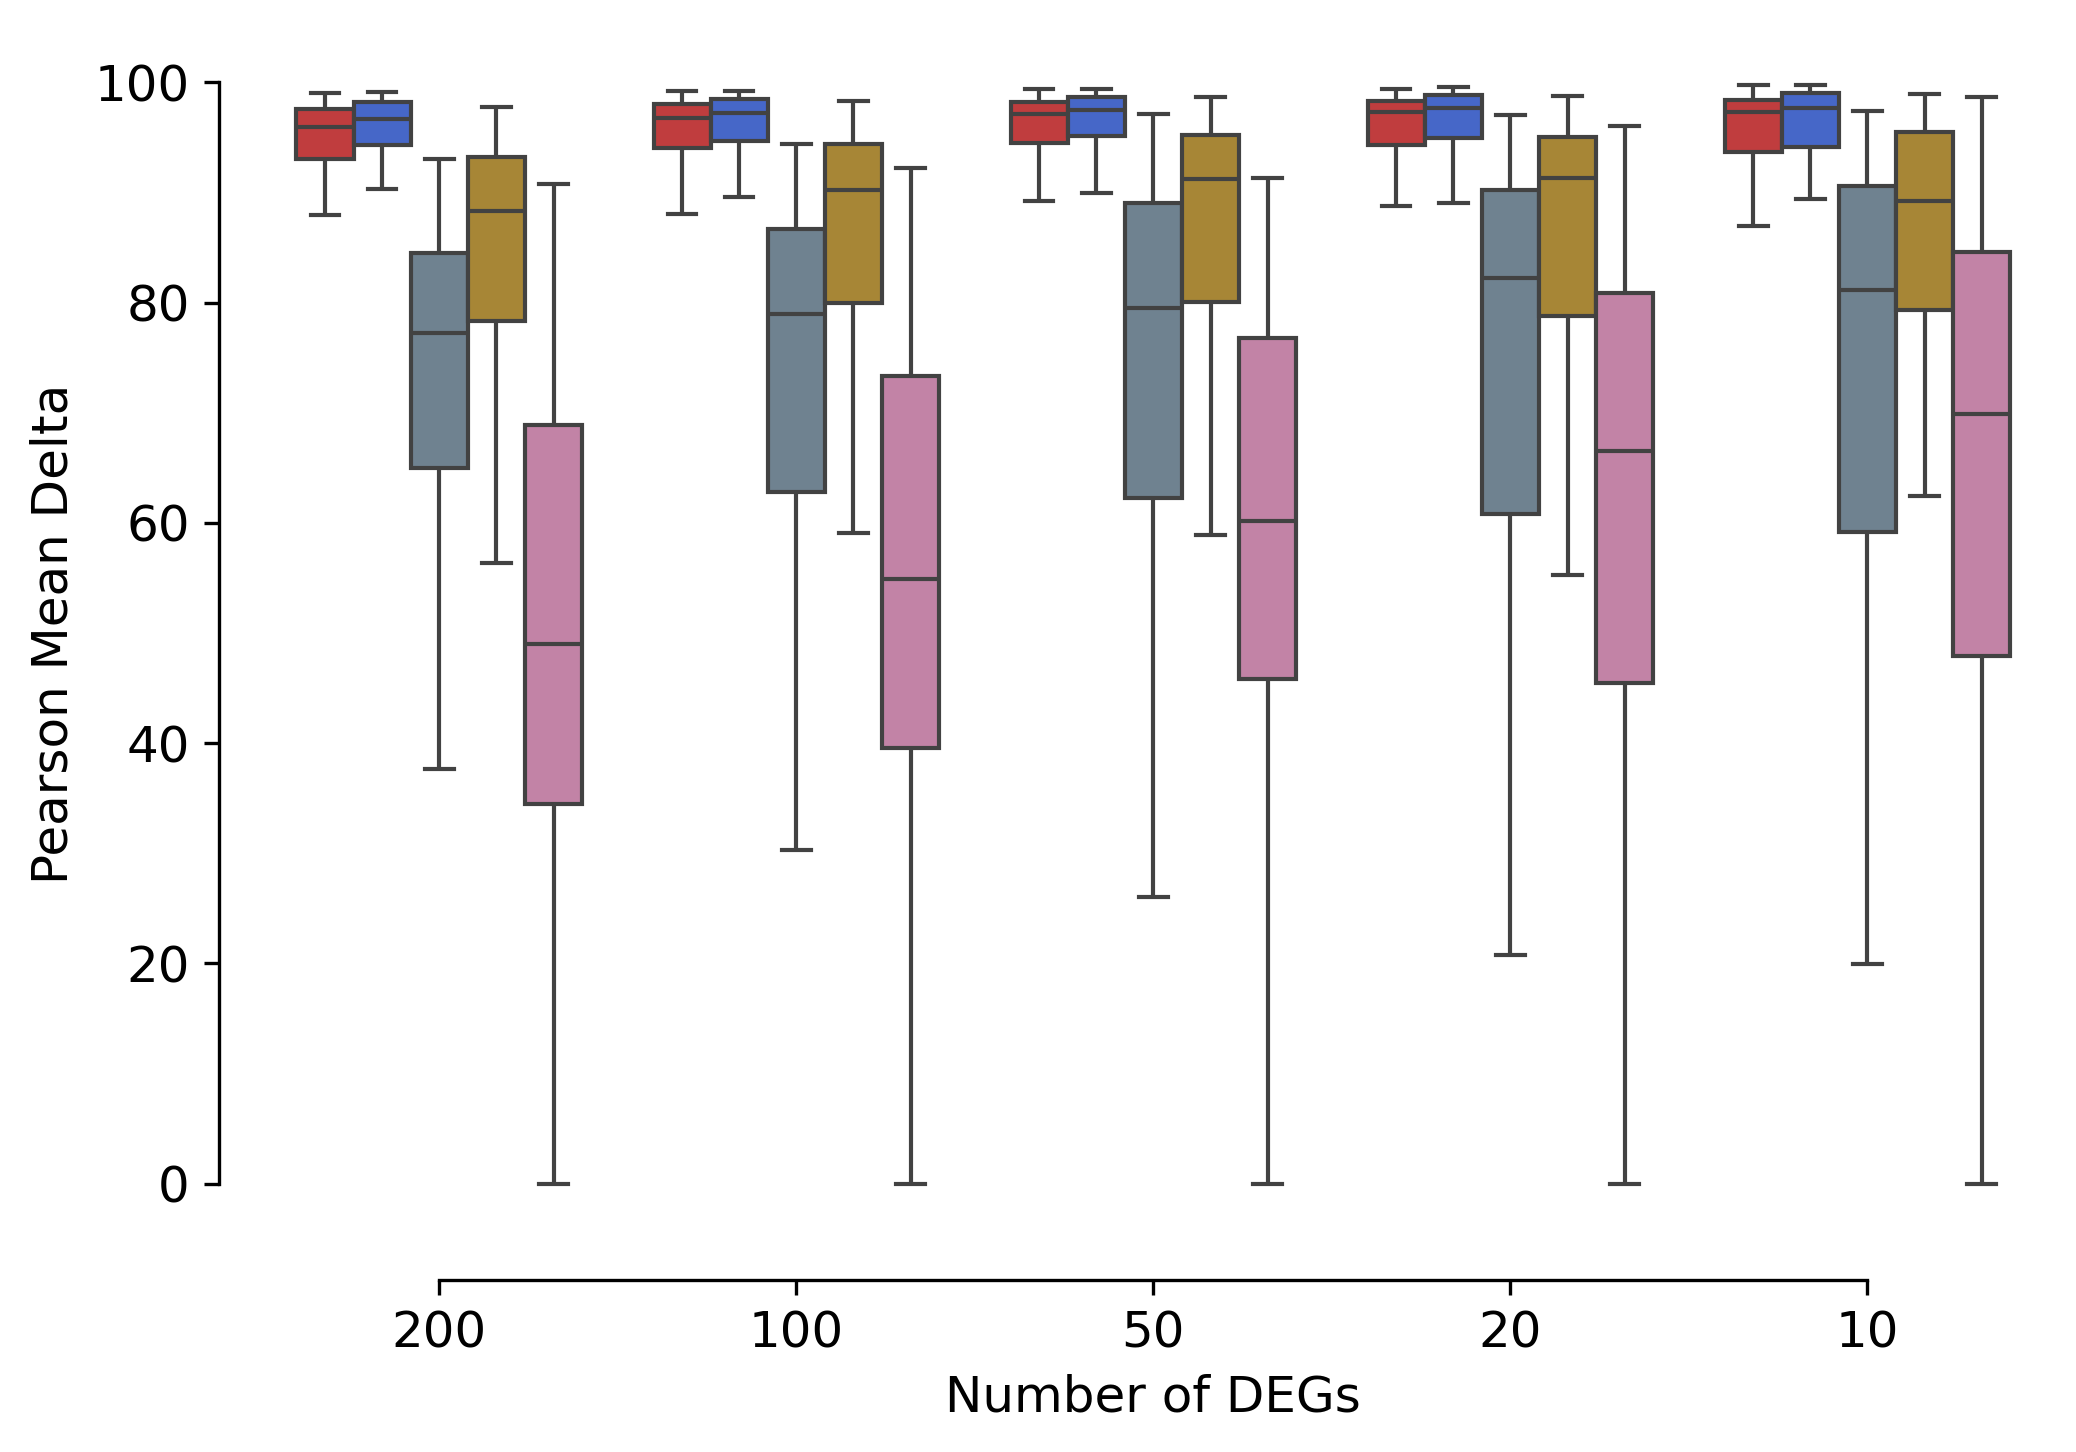

Using 128 perturbation


/home/SE/Desktop/Projects/SCDISENTANGLE/hygeia/hygeia/utils/hplots.py:208: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


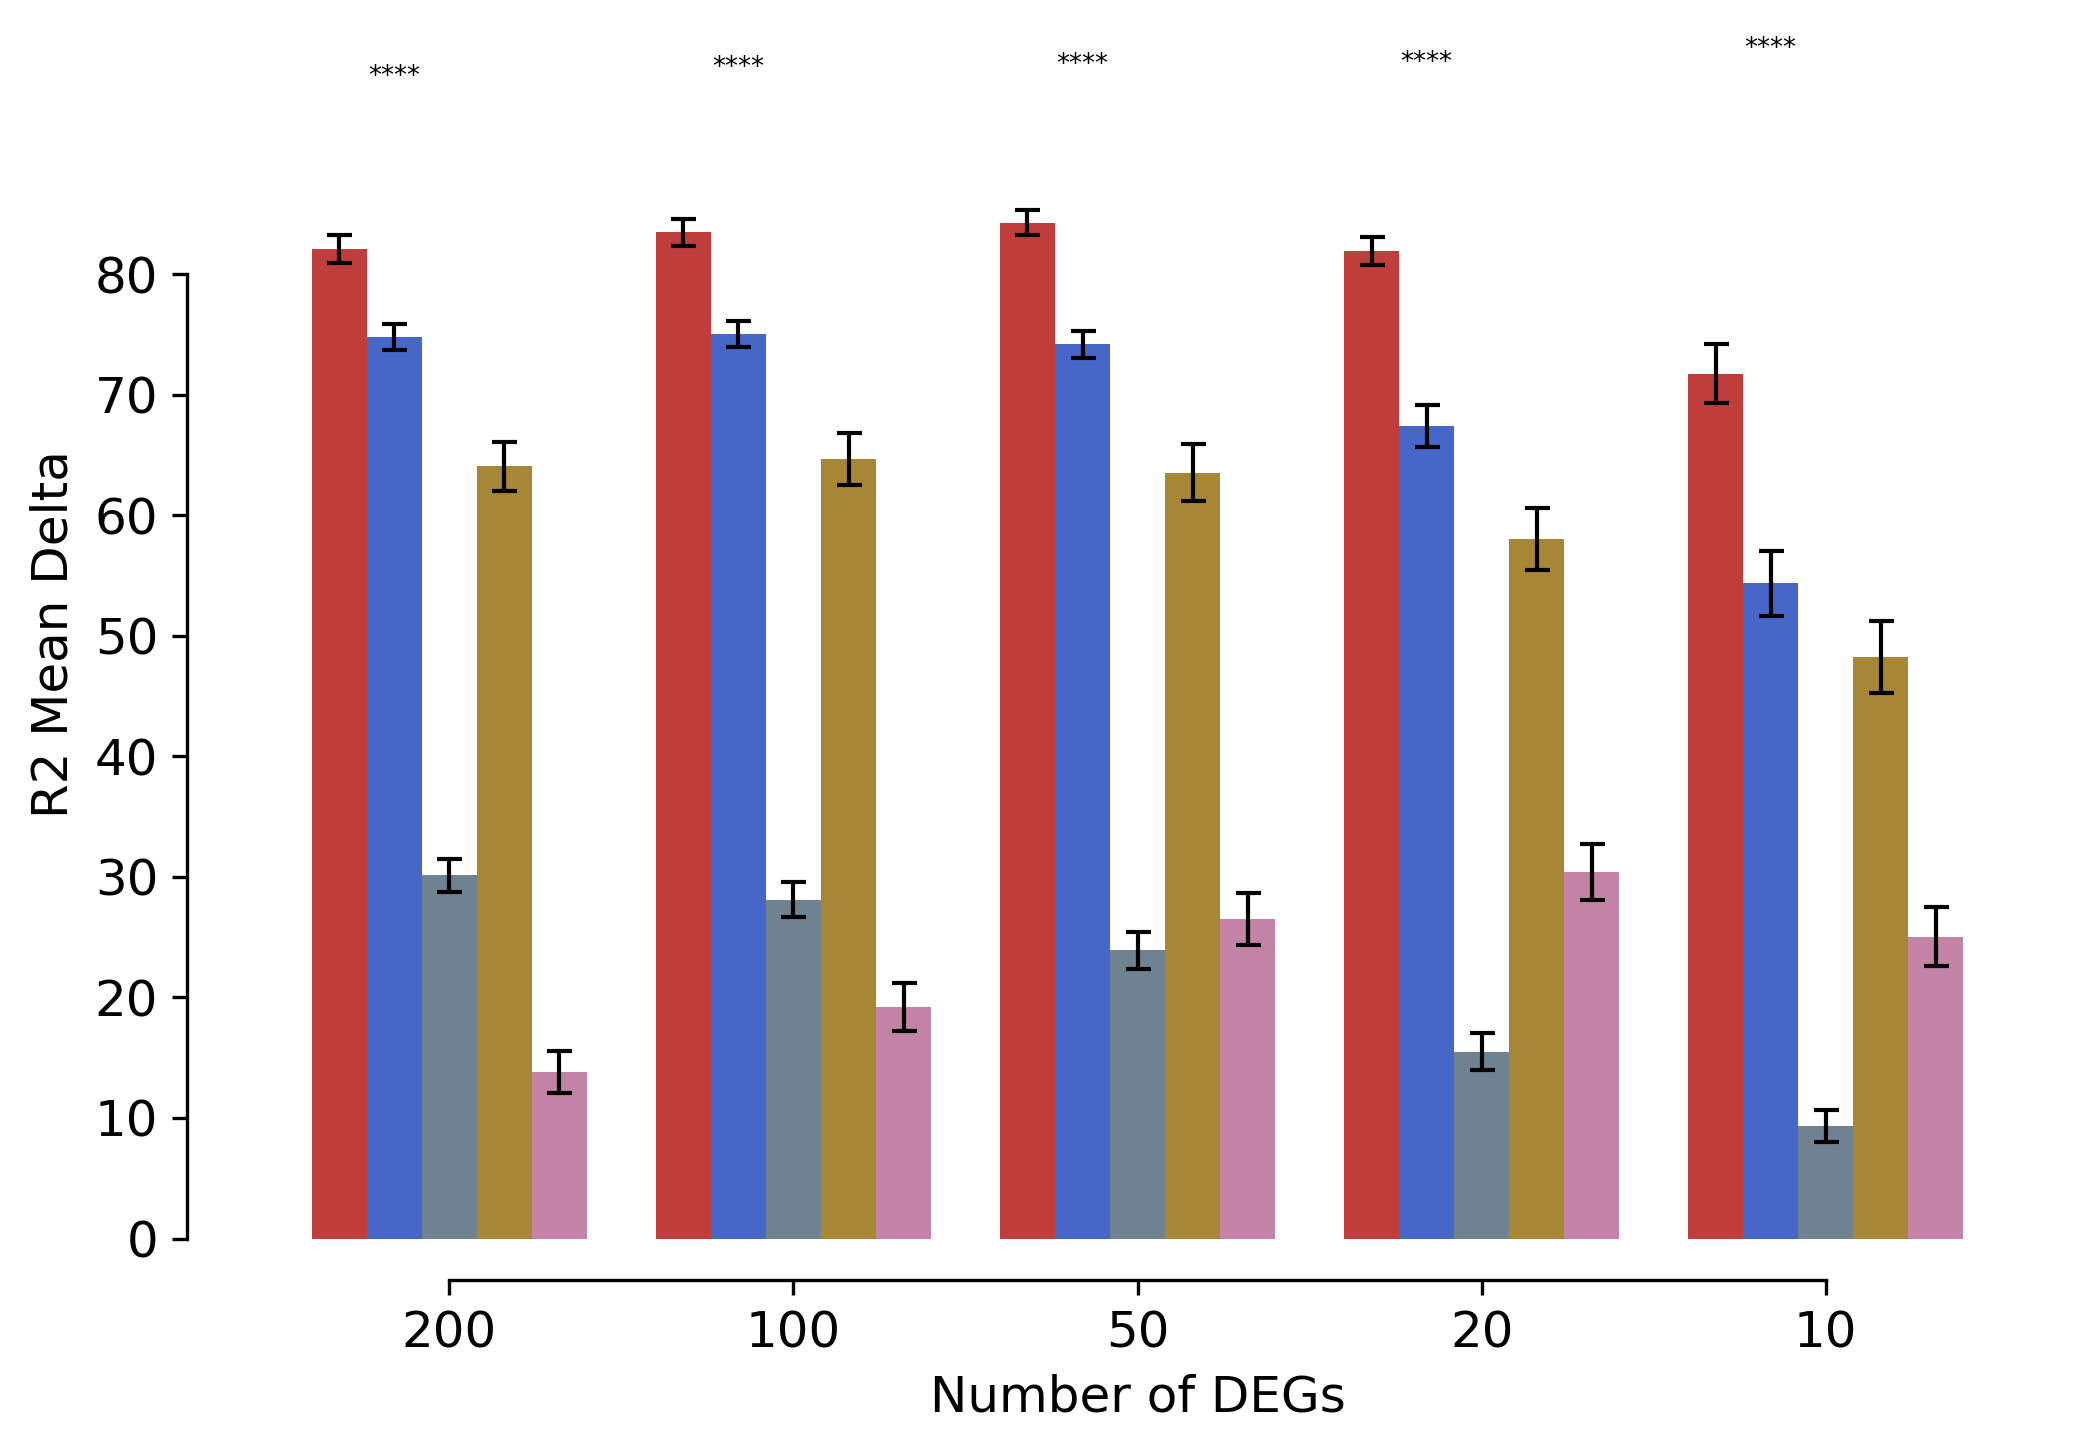

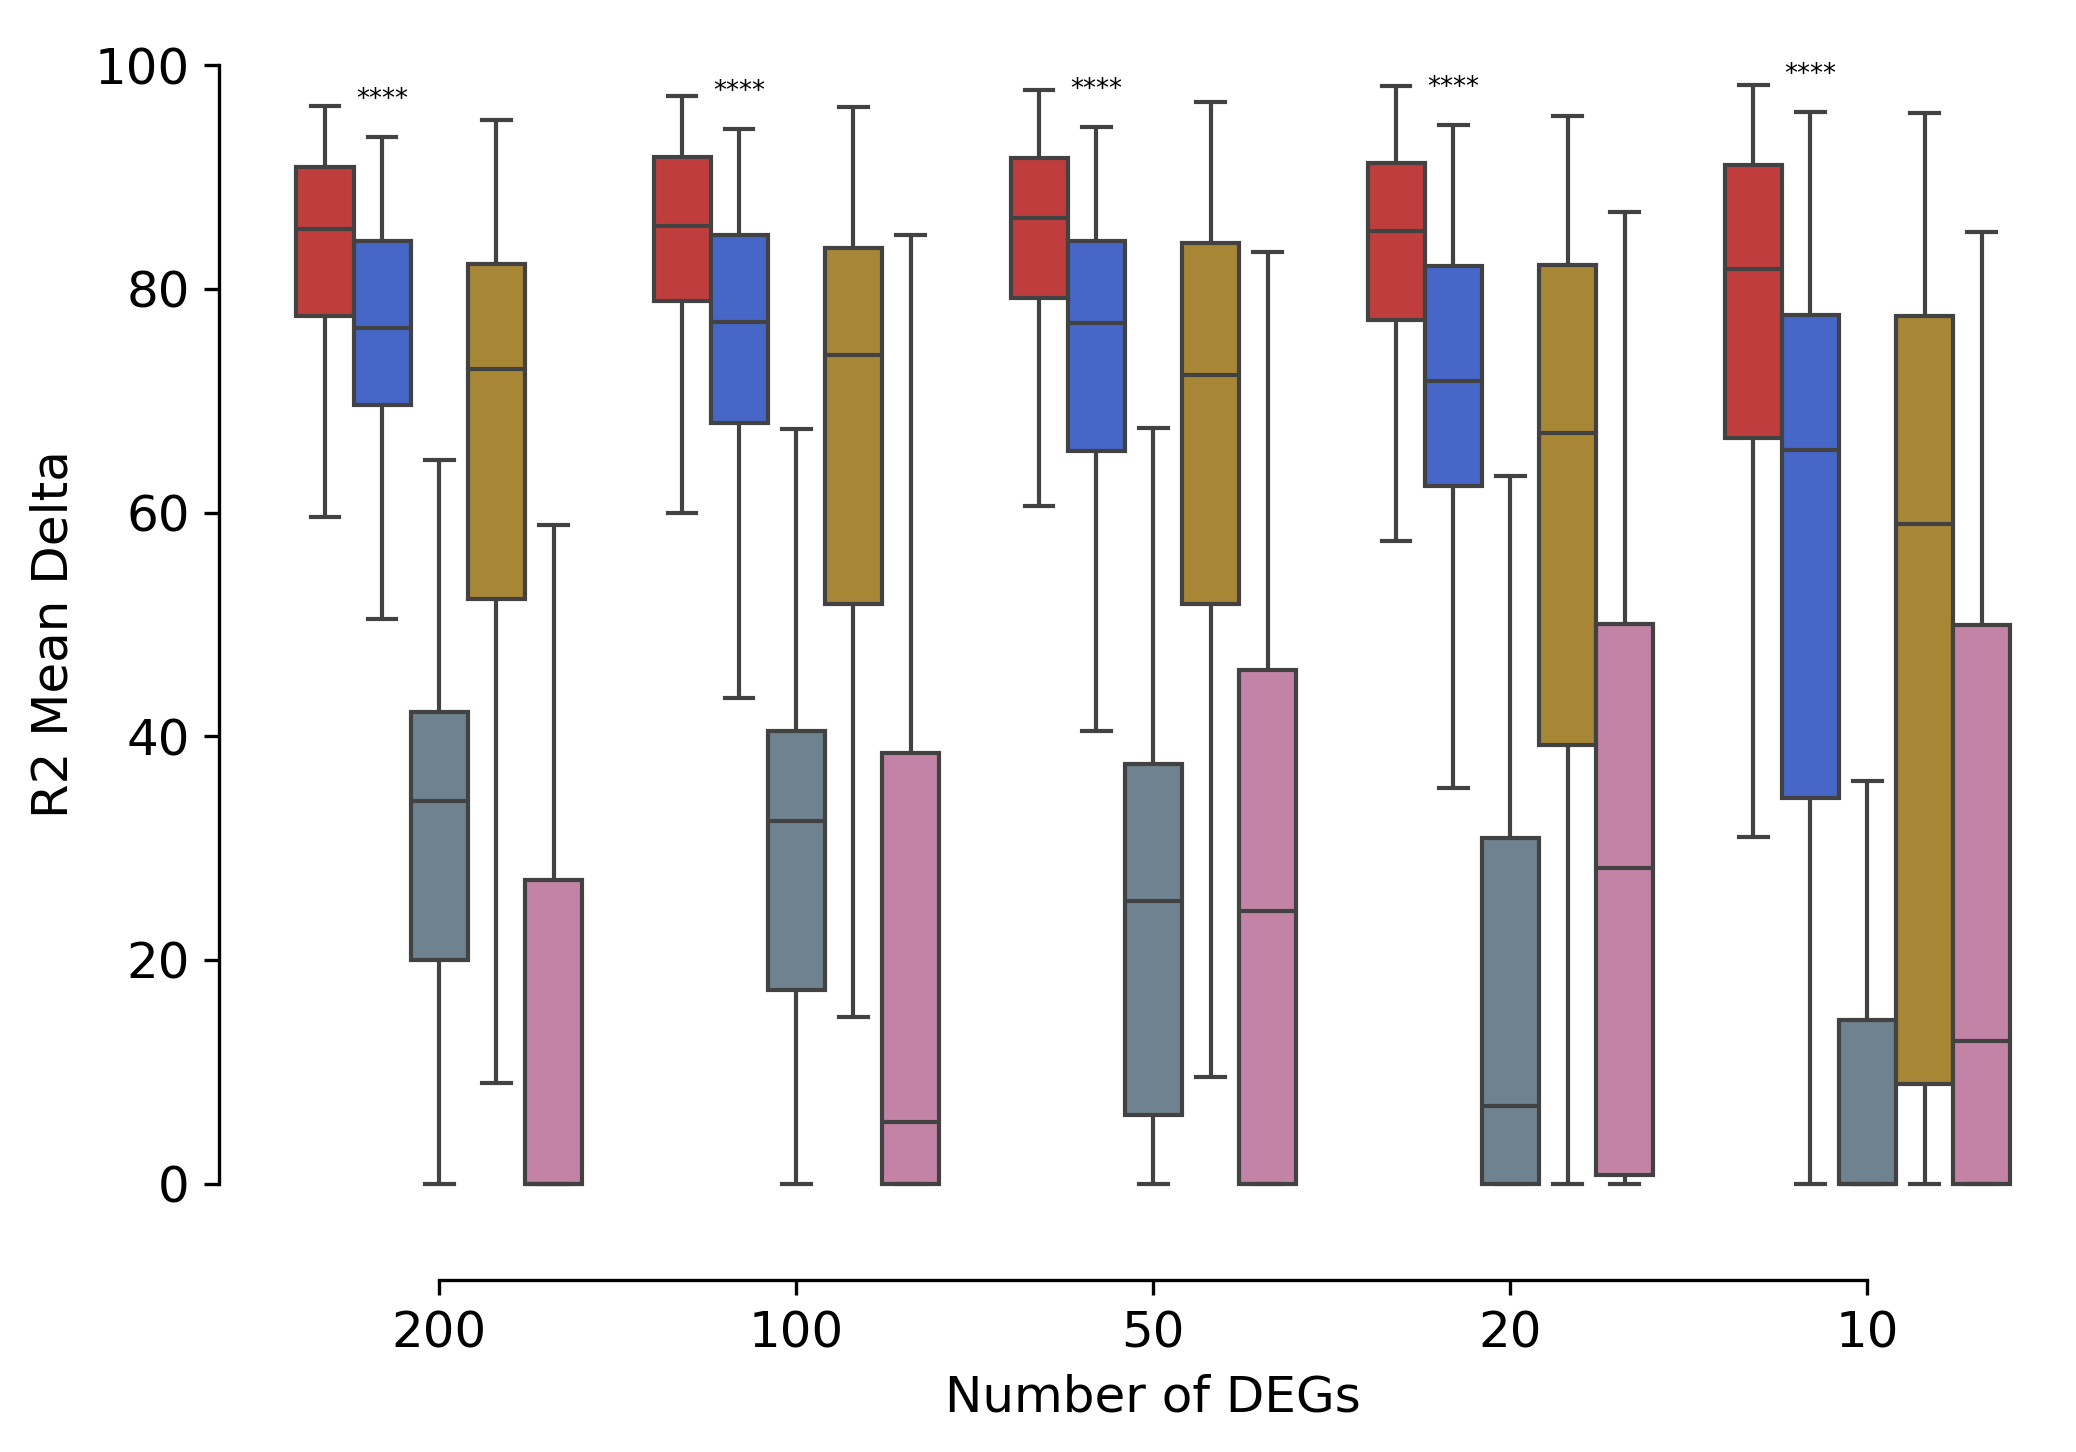

Using 128 perturbation


/home/SE/Desktop/Projects/SCDISENTANGLE/hygeia/hygeia/utils/hplots.py:208: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


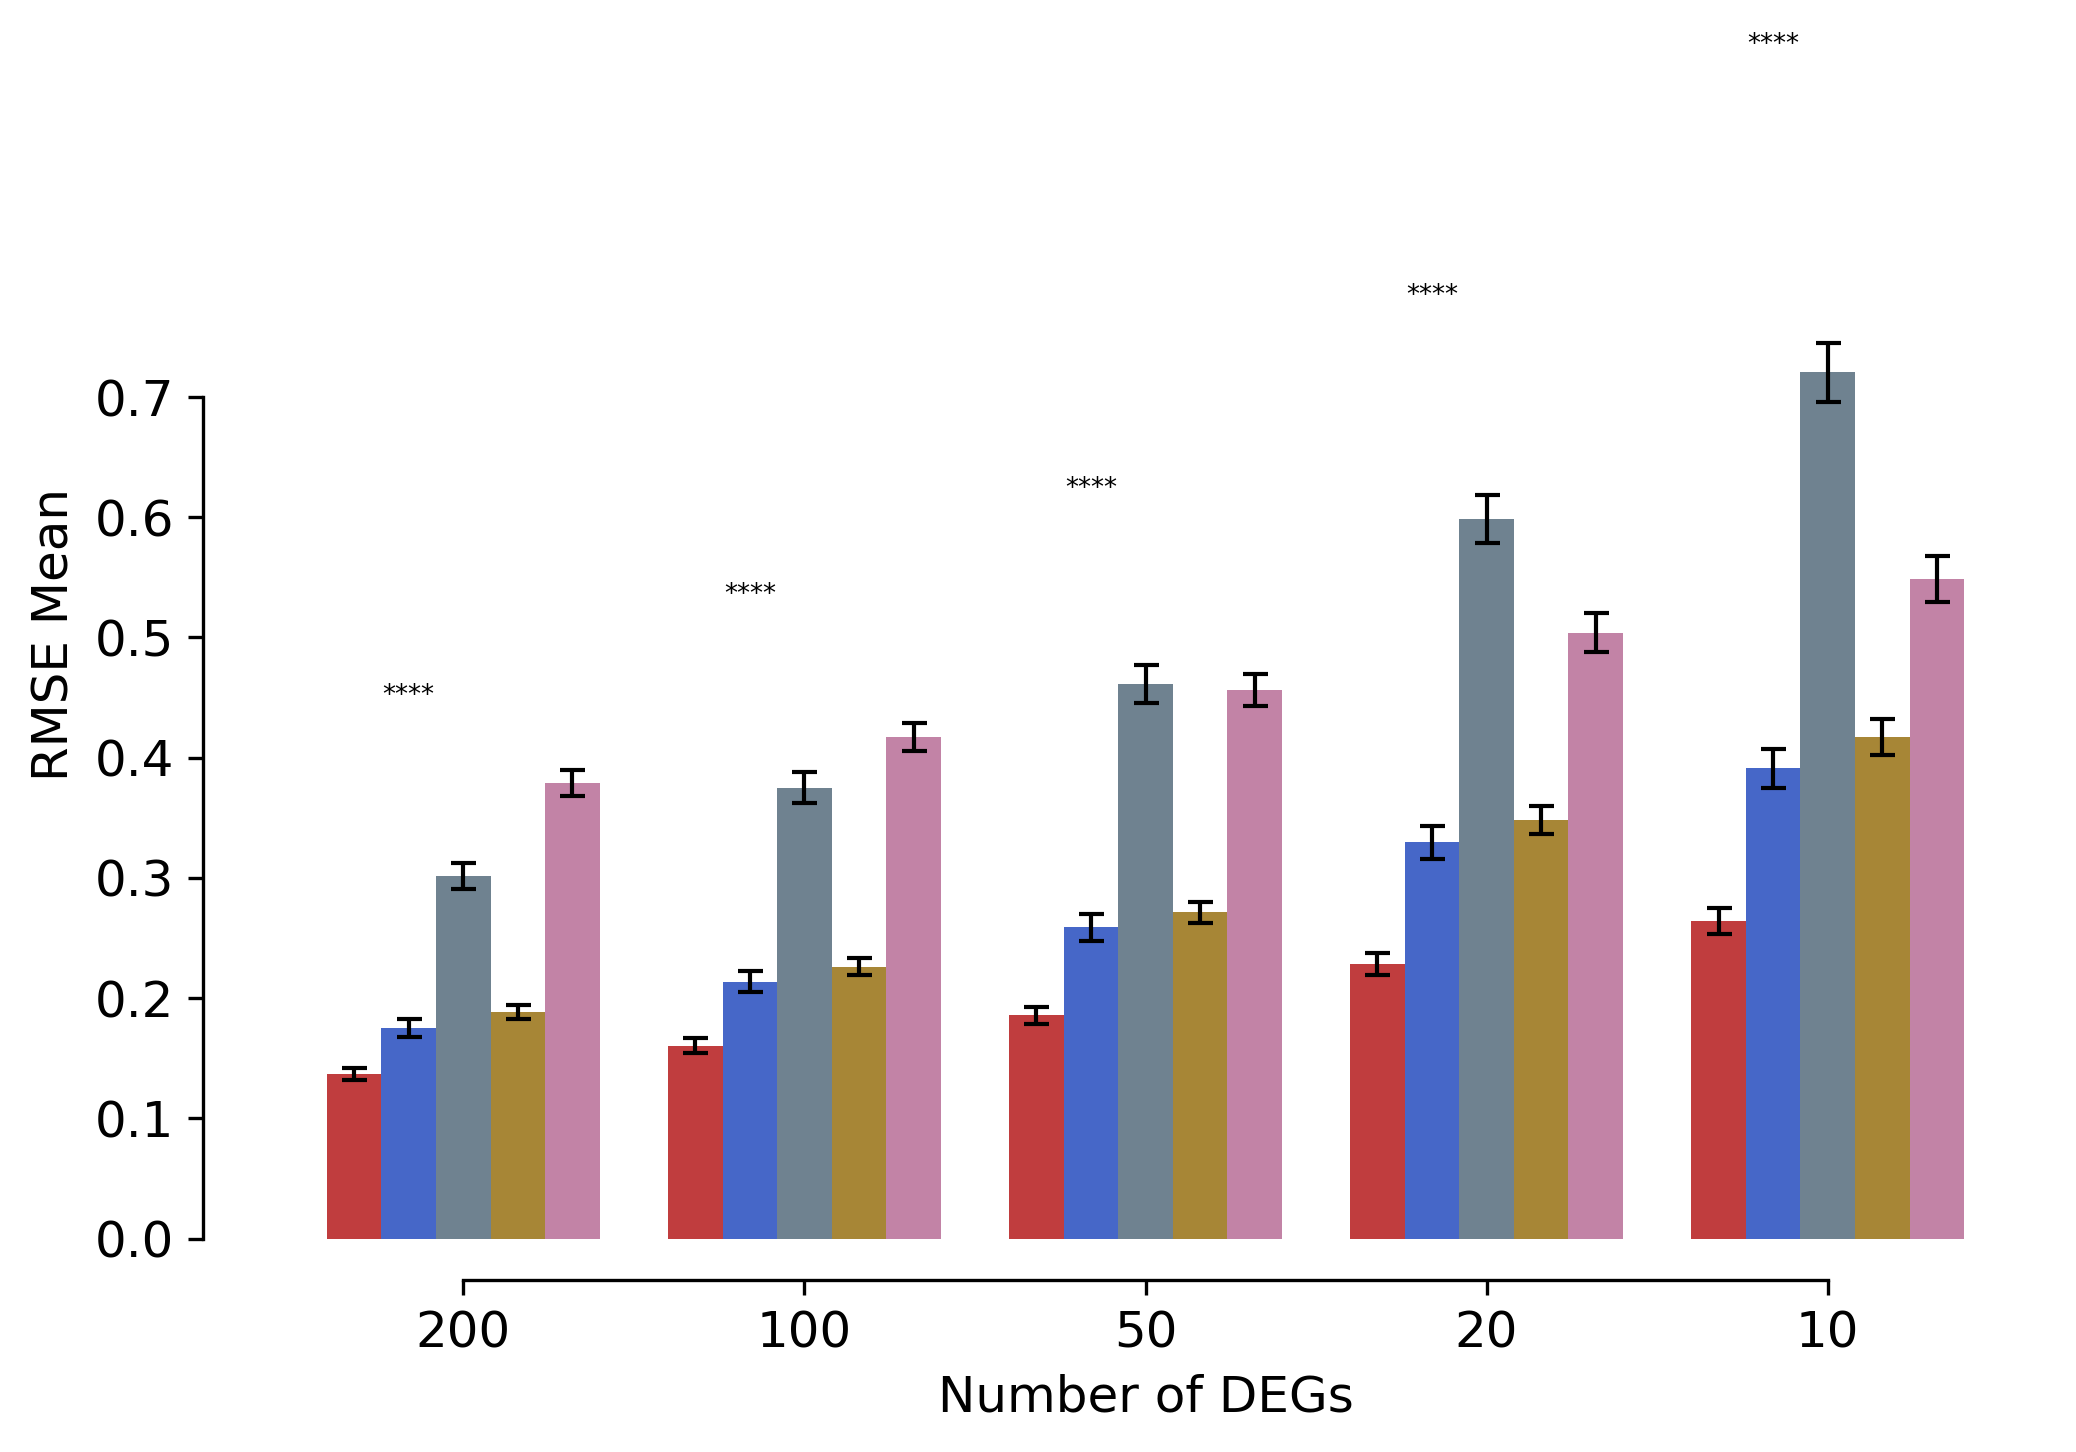

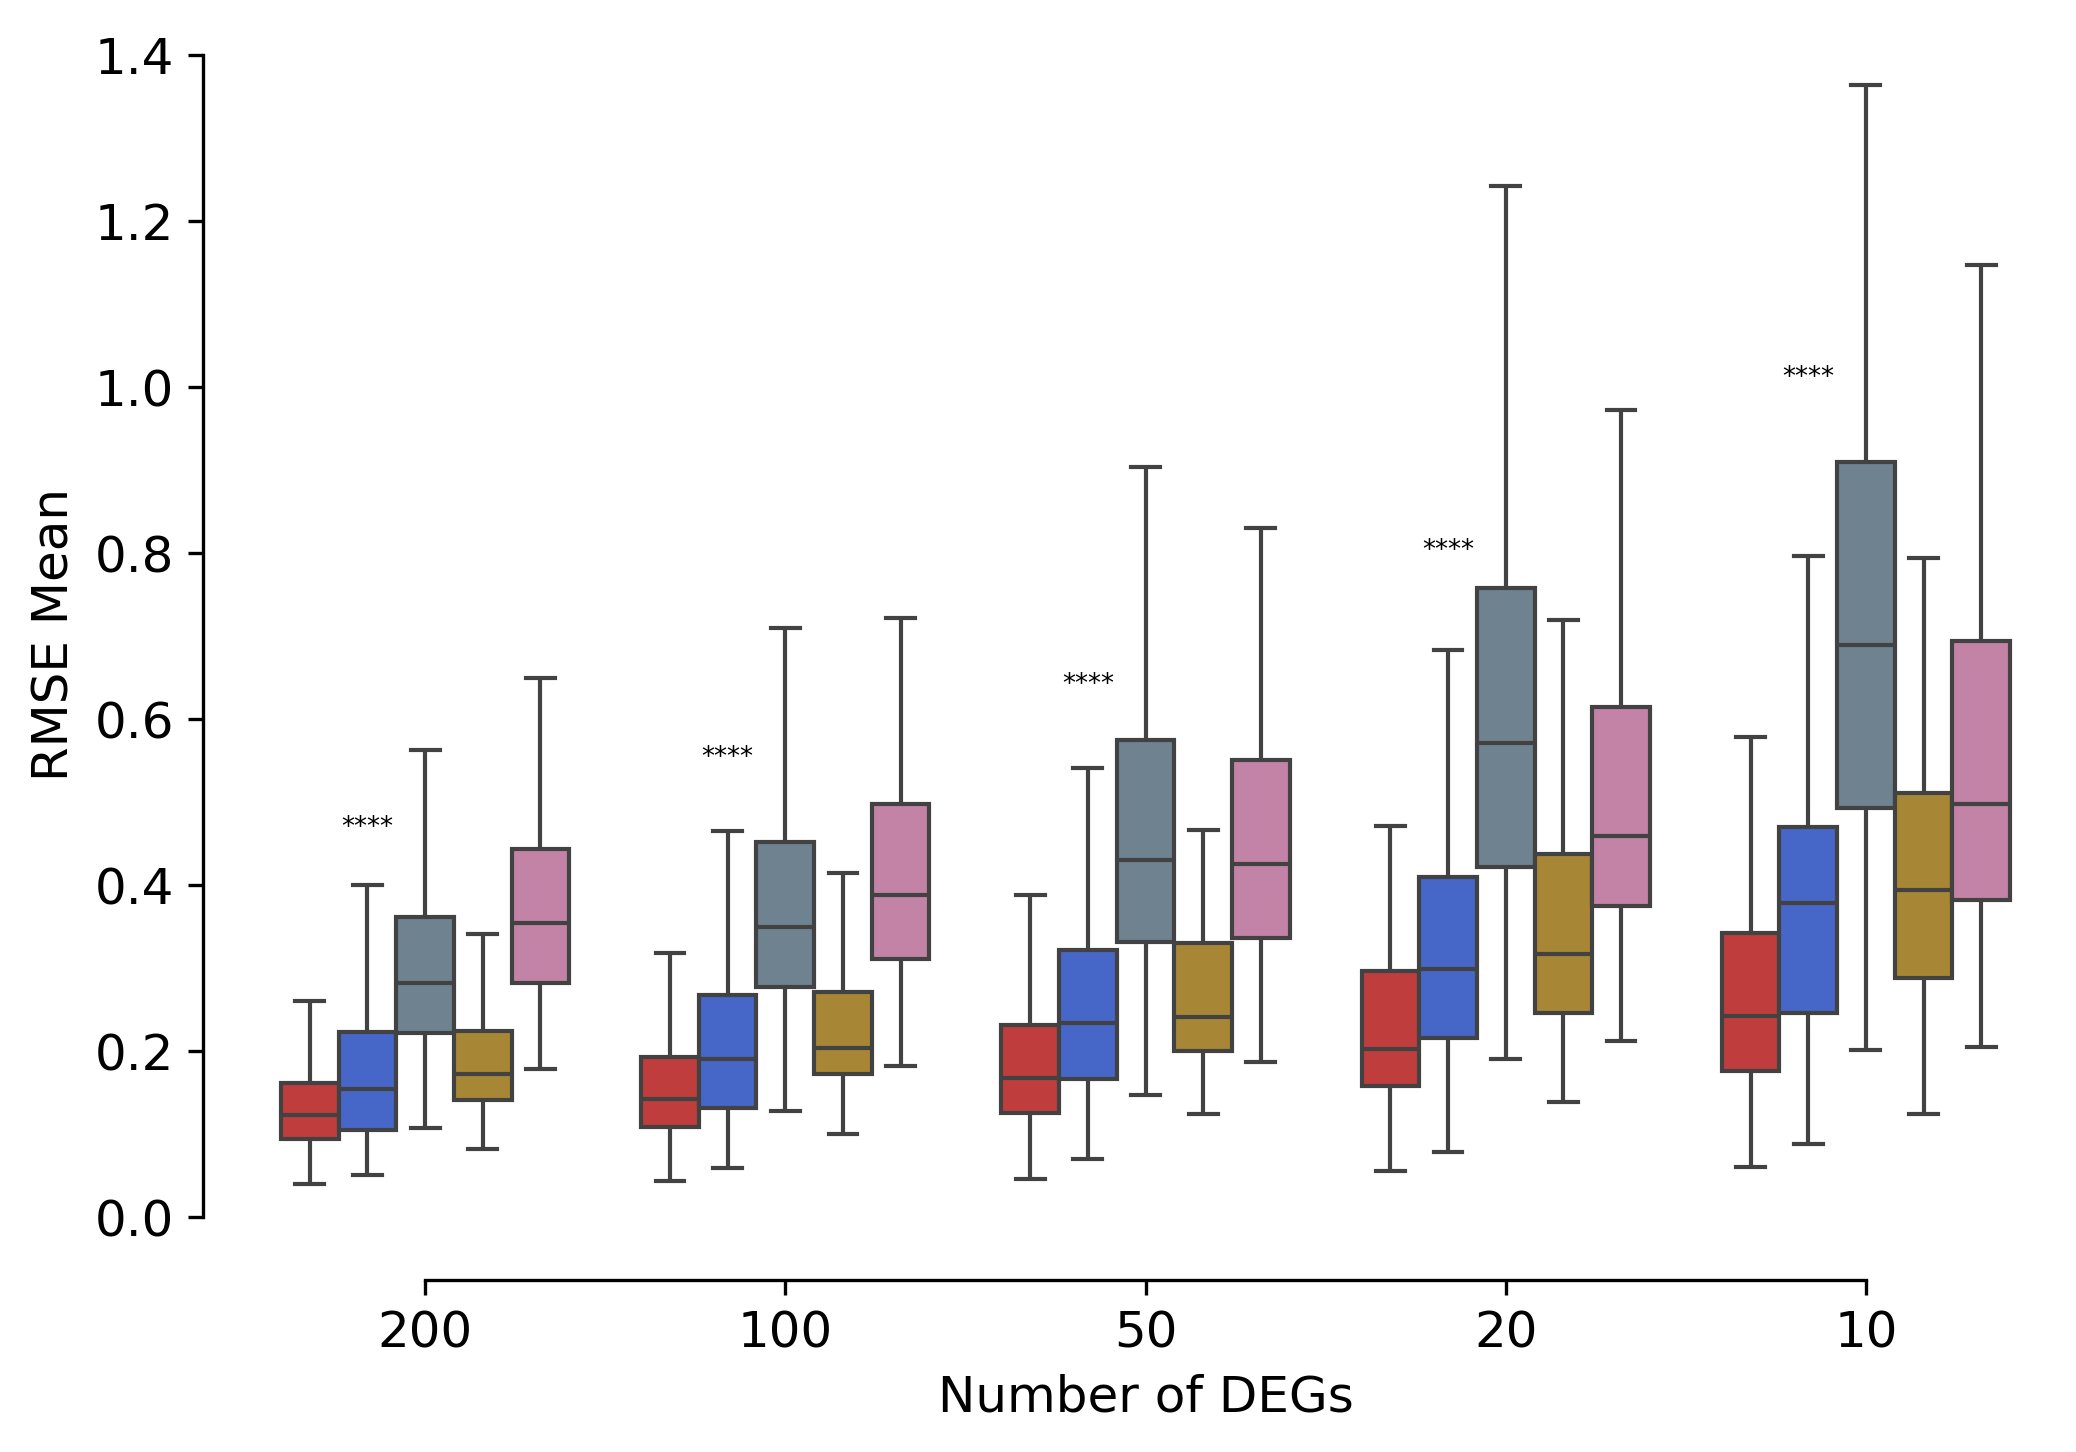

Using 128 perturbation


/home/SE/Desktop/Projects/SCDISENTANGLE/hygeia/hygeia/utils/hplots.py:208: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


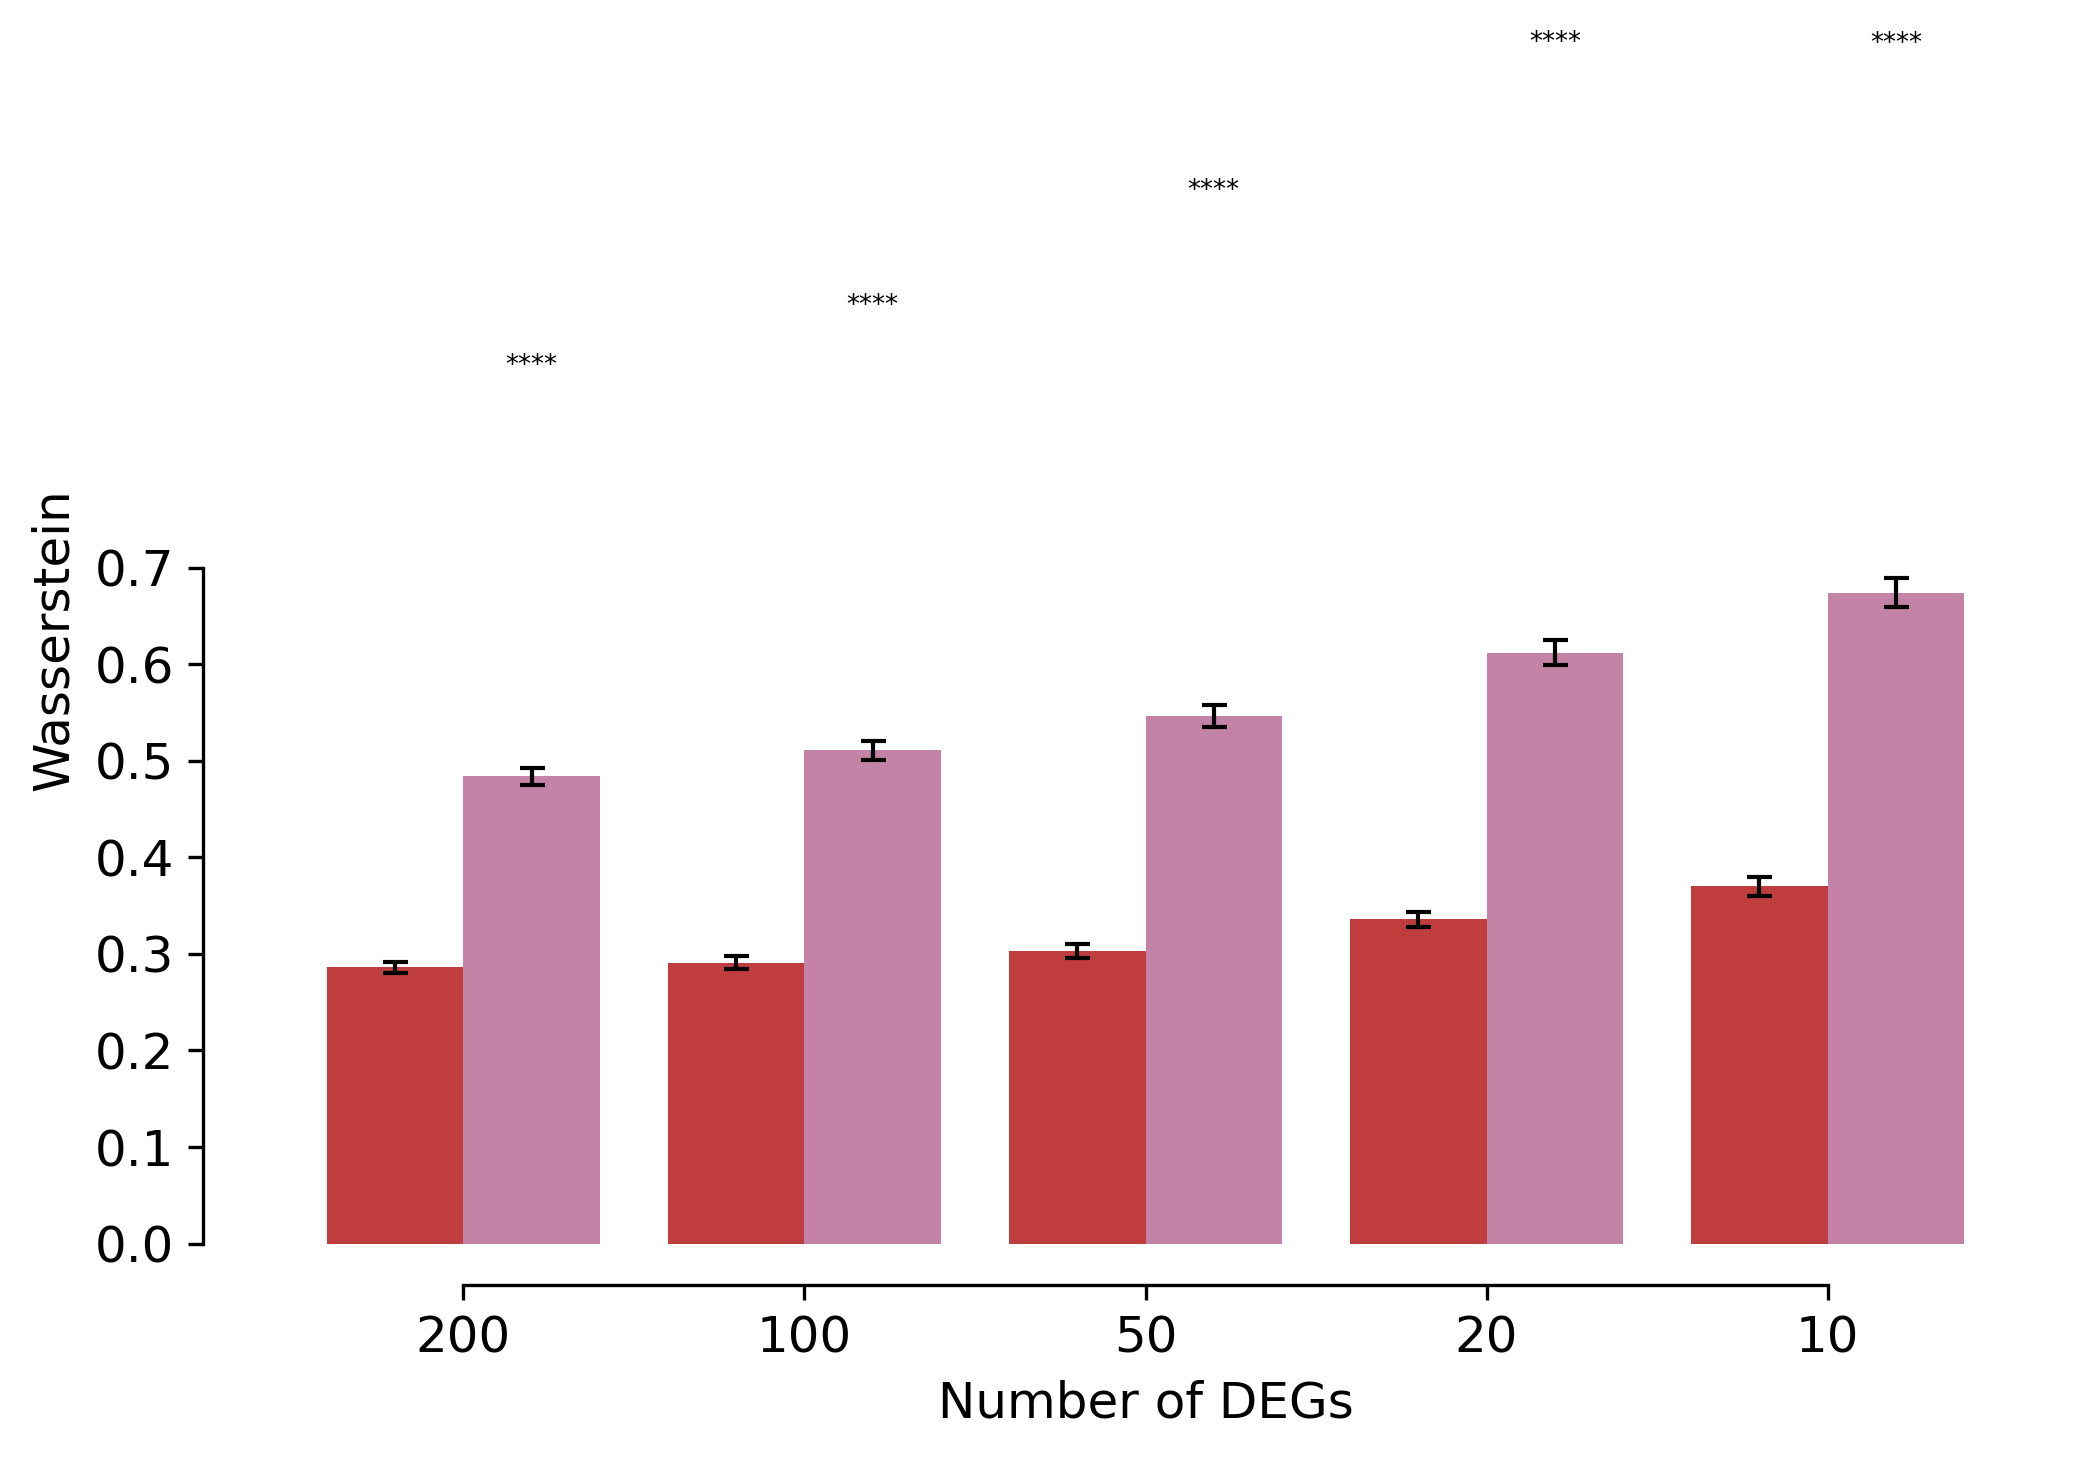

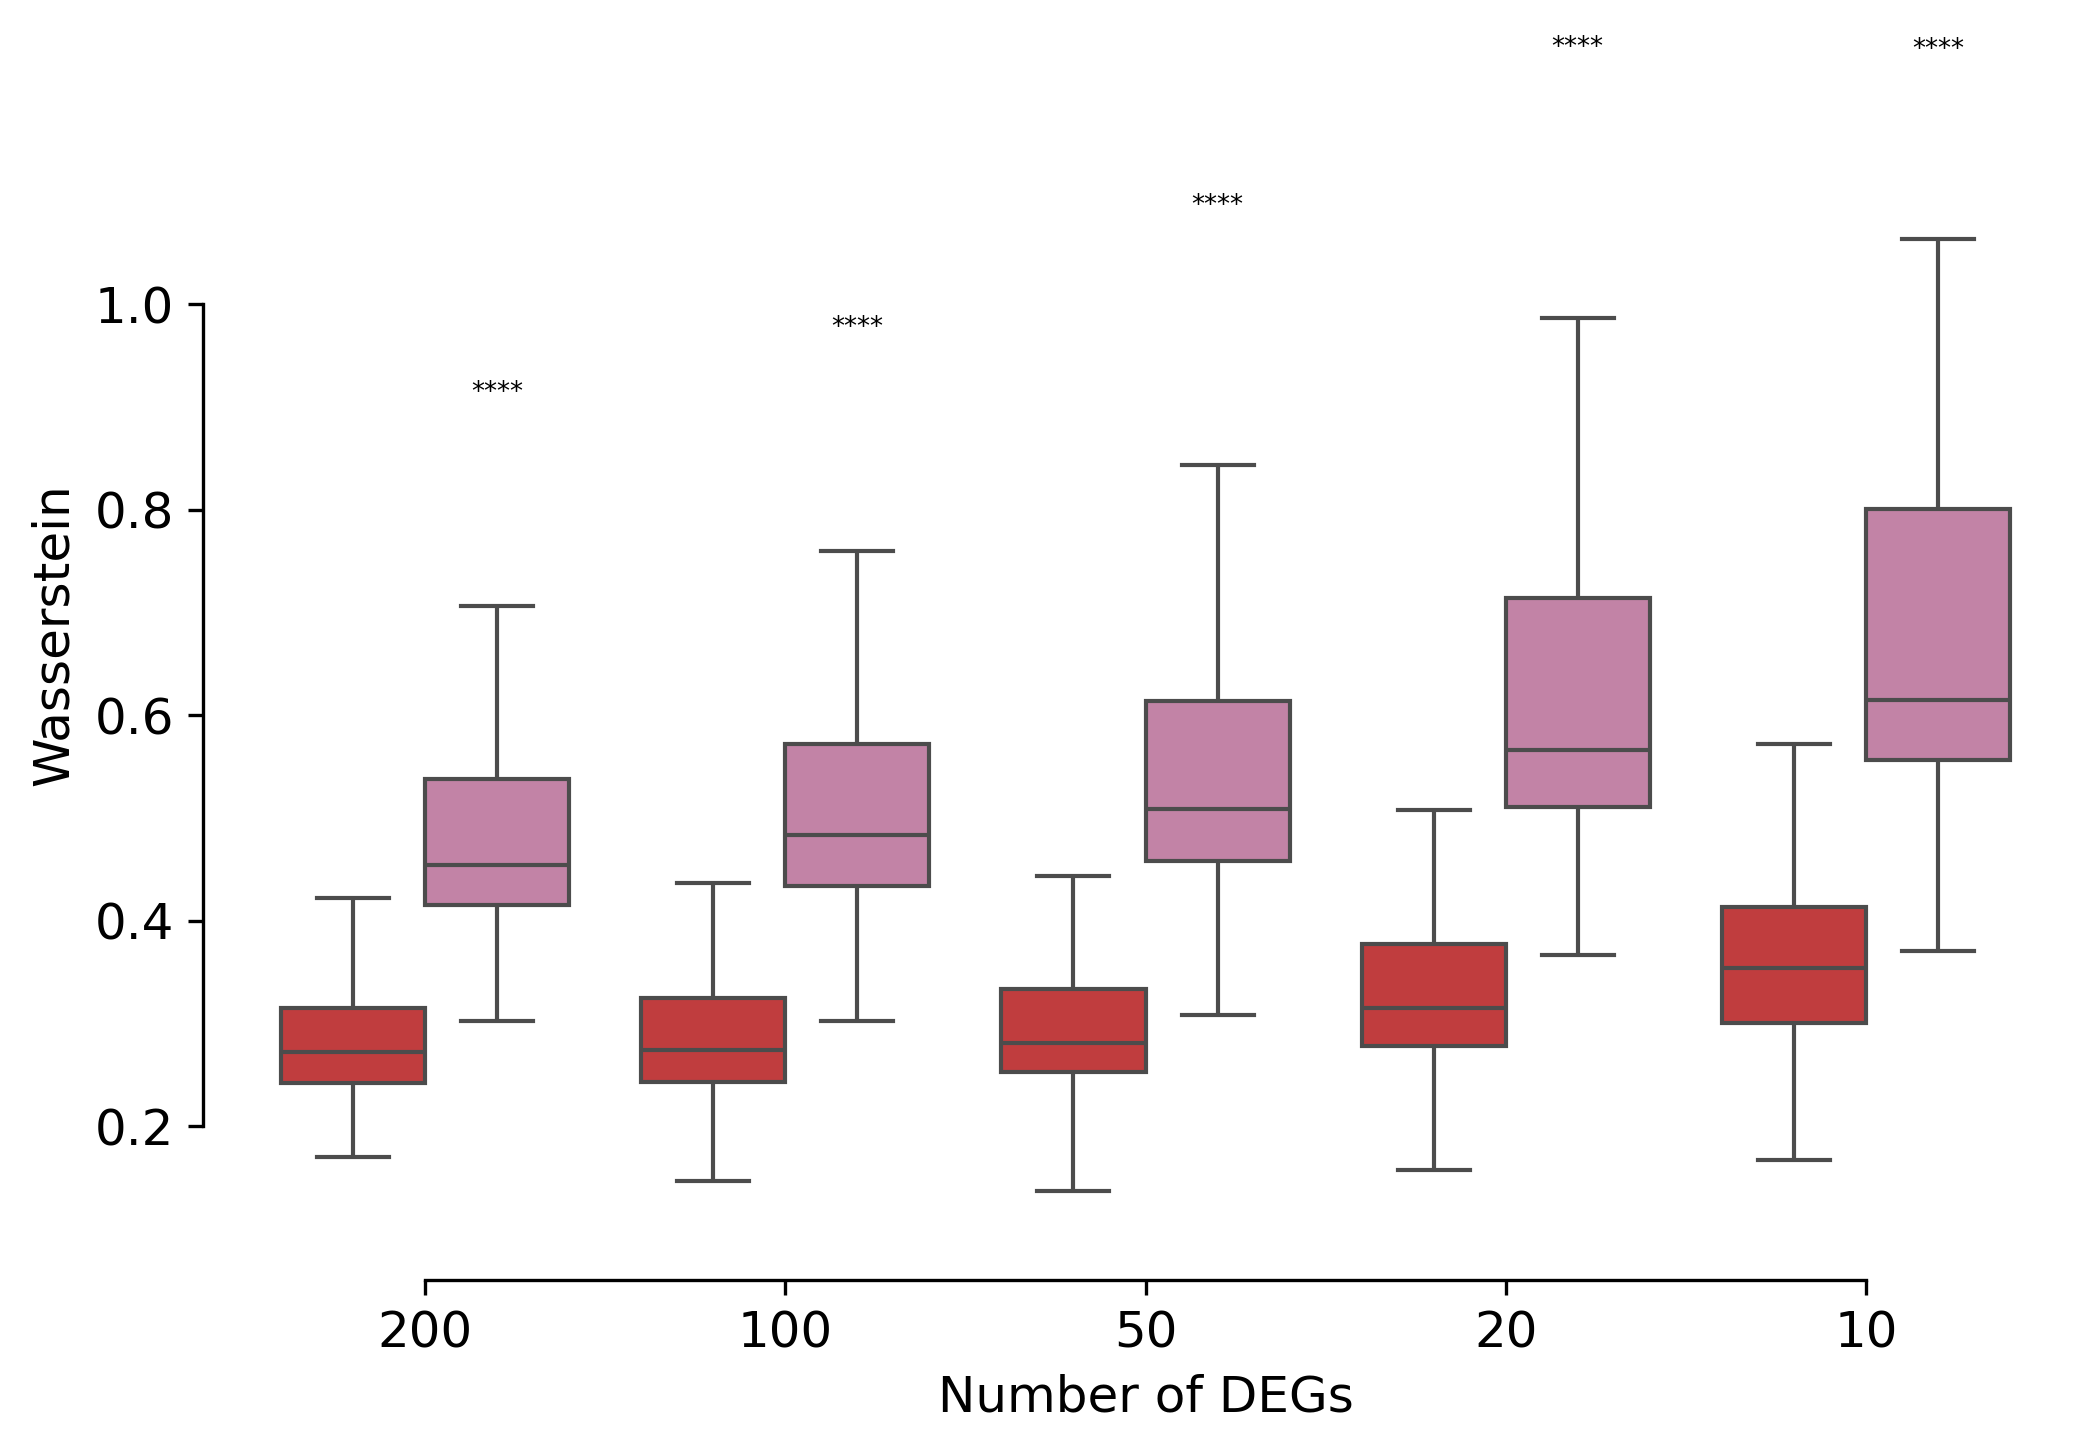

Using 128 perturbation


/home/SE/Desktop/Projects/SCDISENTANGLE/hygeia/hygeia/utils/hplots.py:208: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


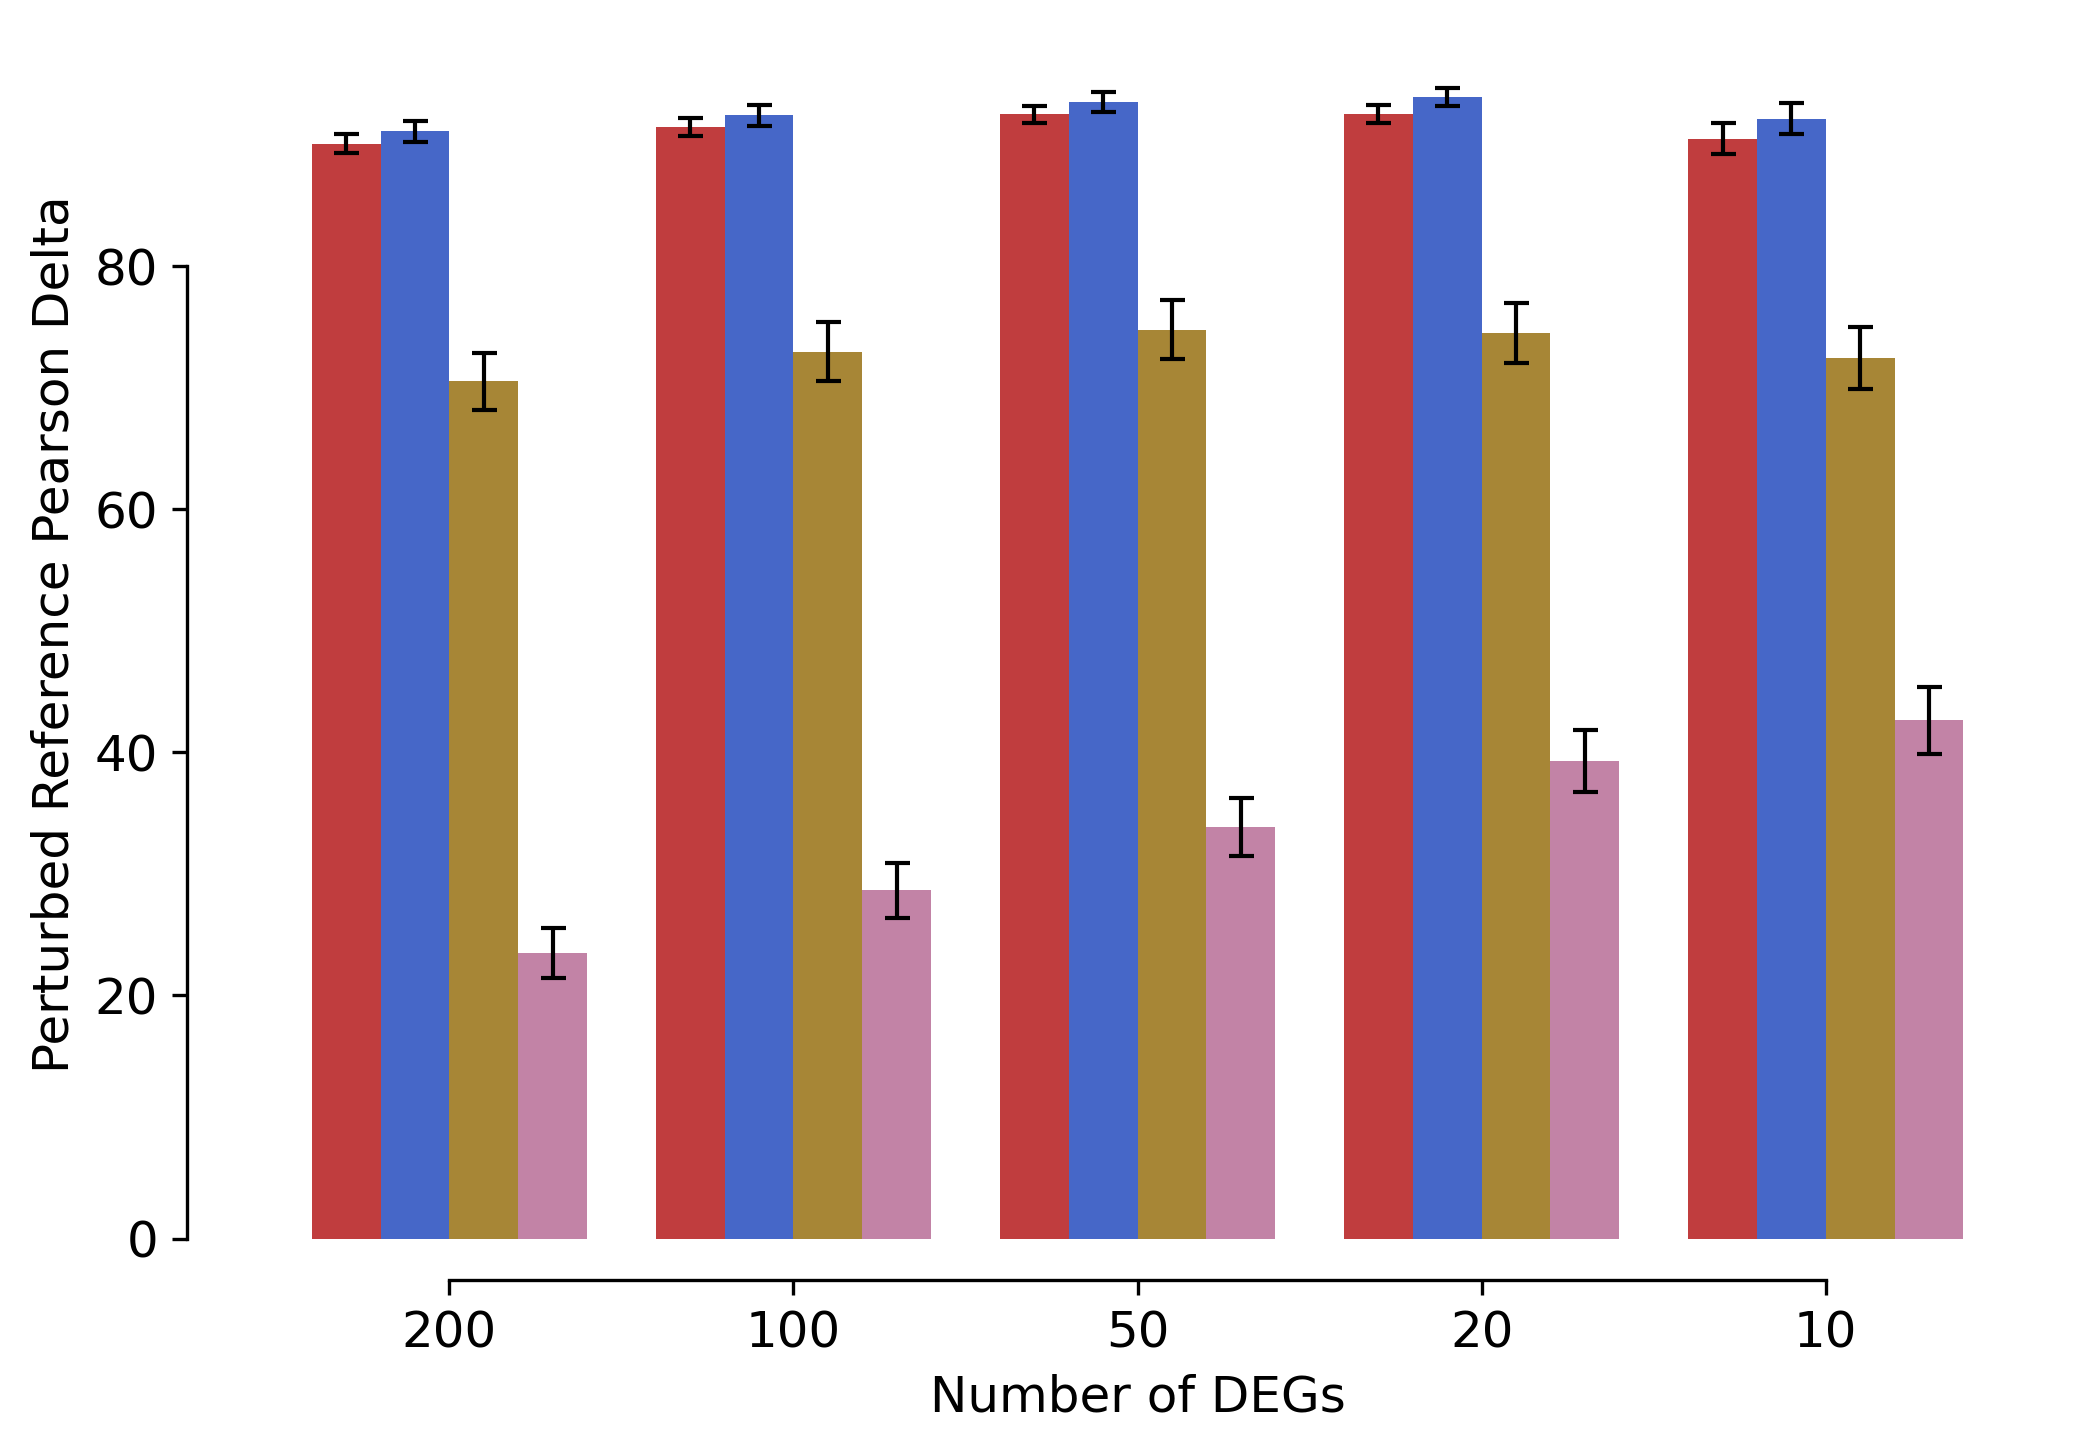

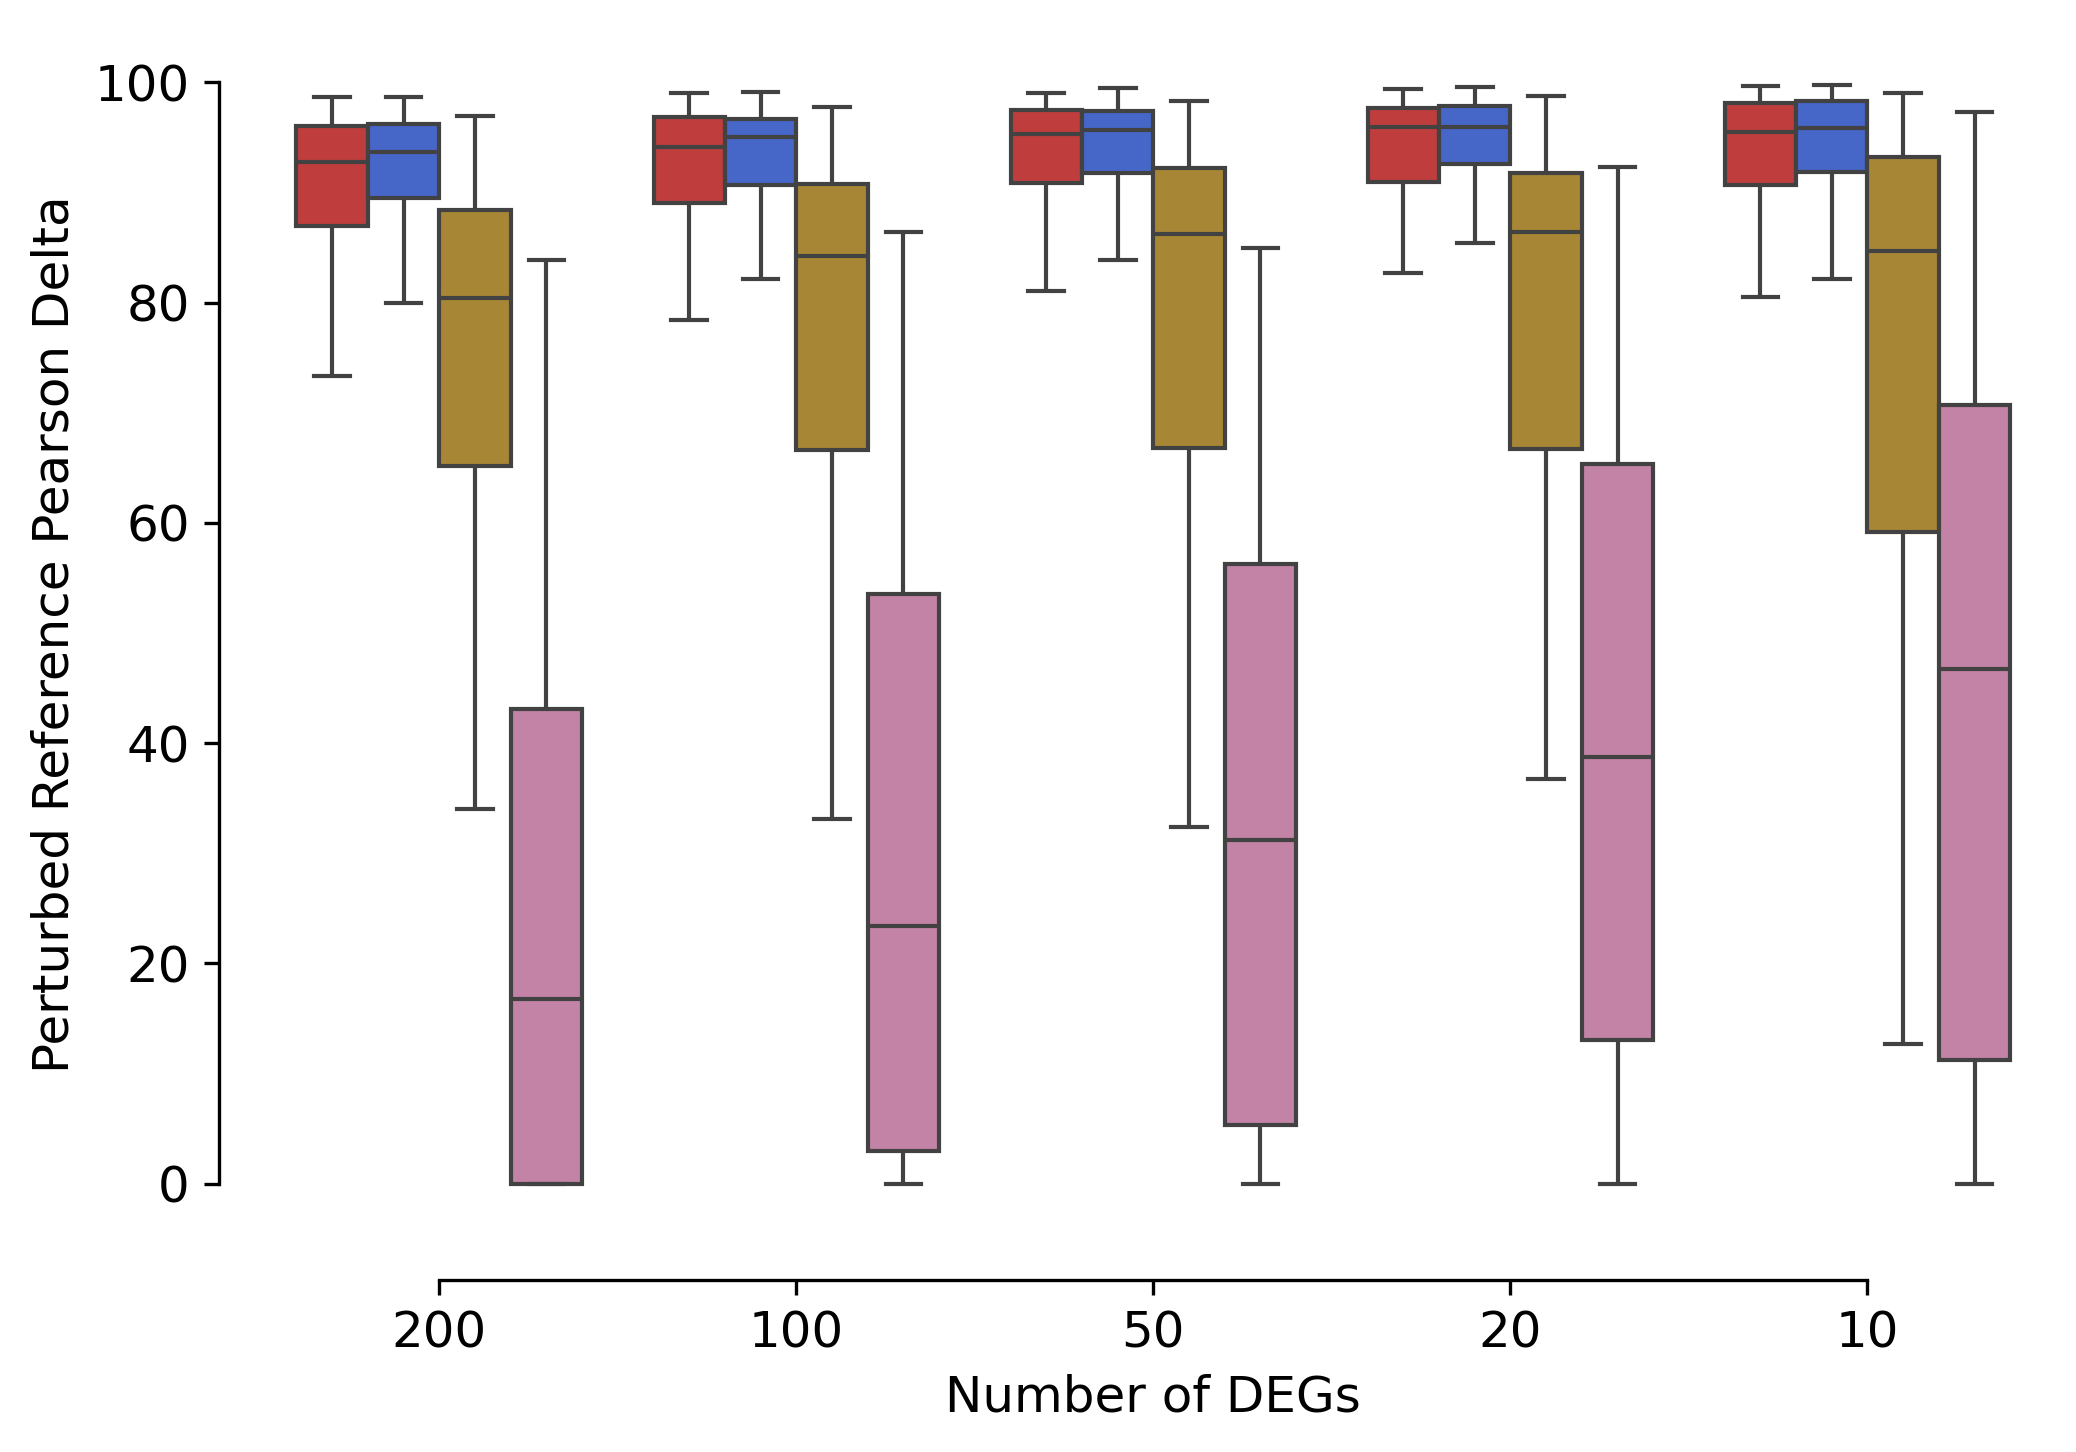

Using 128 perturbation


/home/SE/Desktop/Projects/SCDISENTANGLE/hygeia/hygeia/utils/hplots.py:208: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


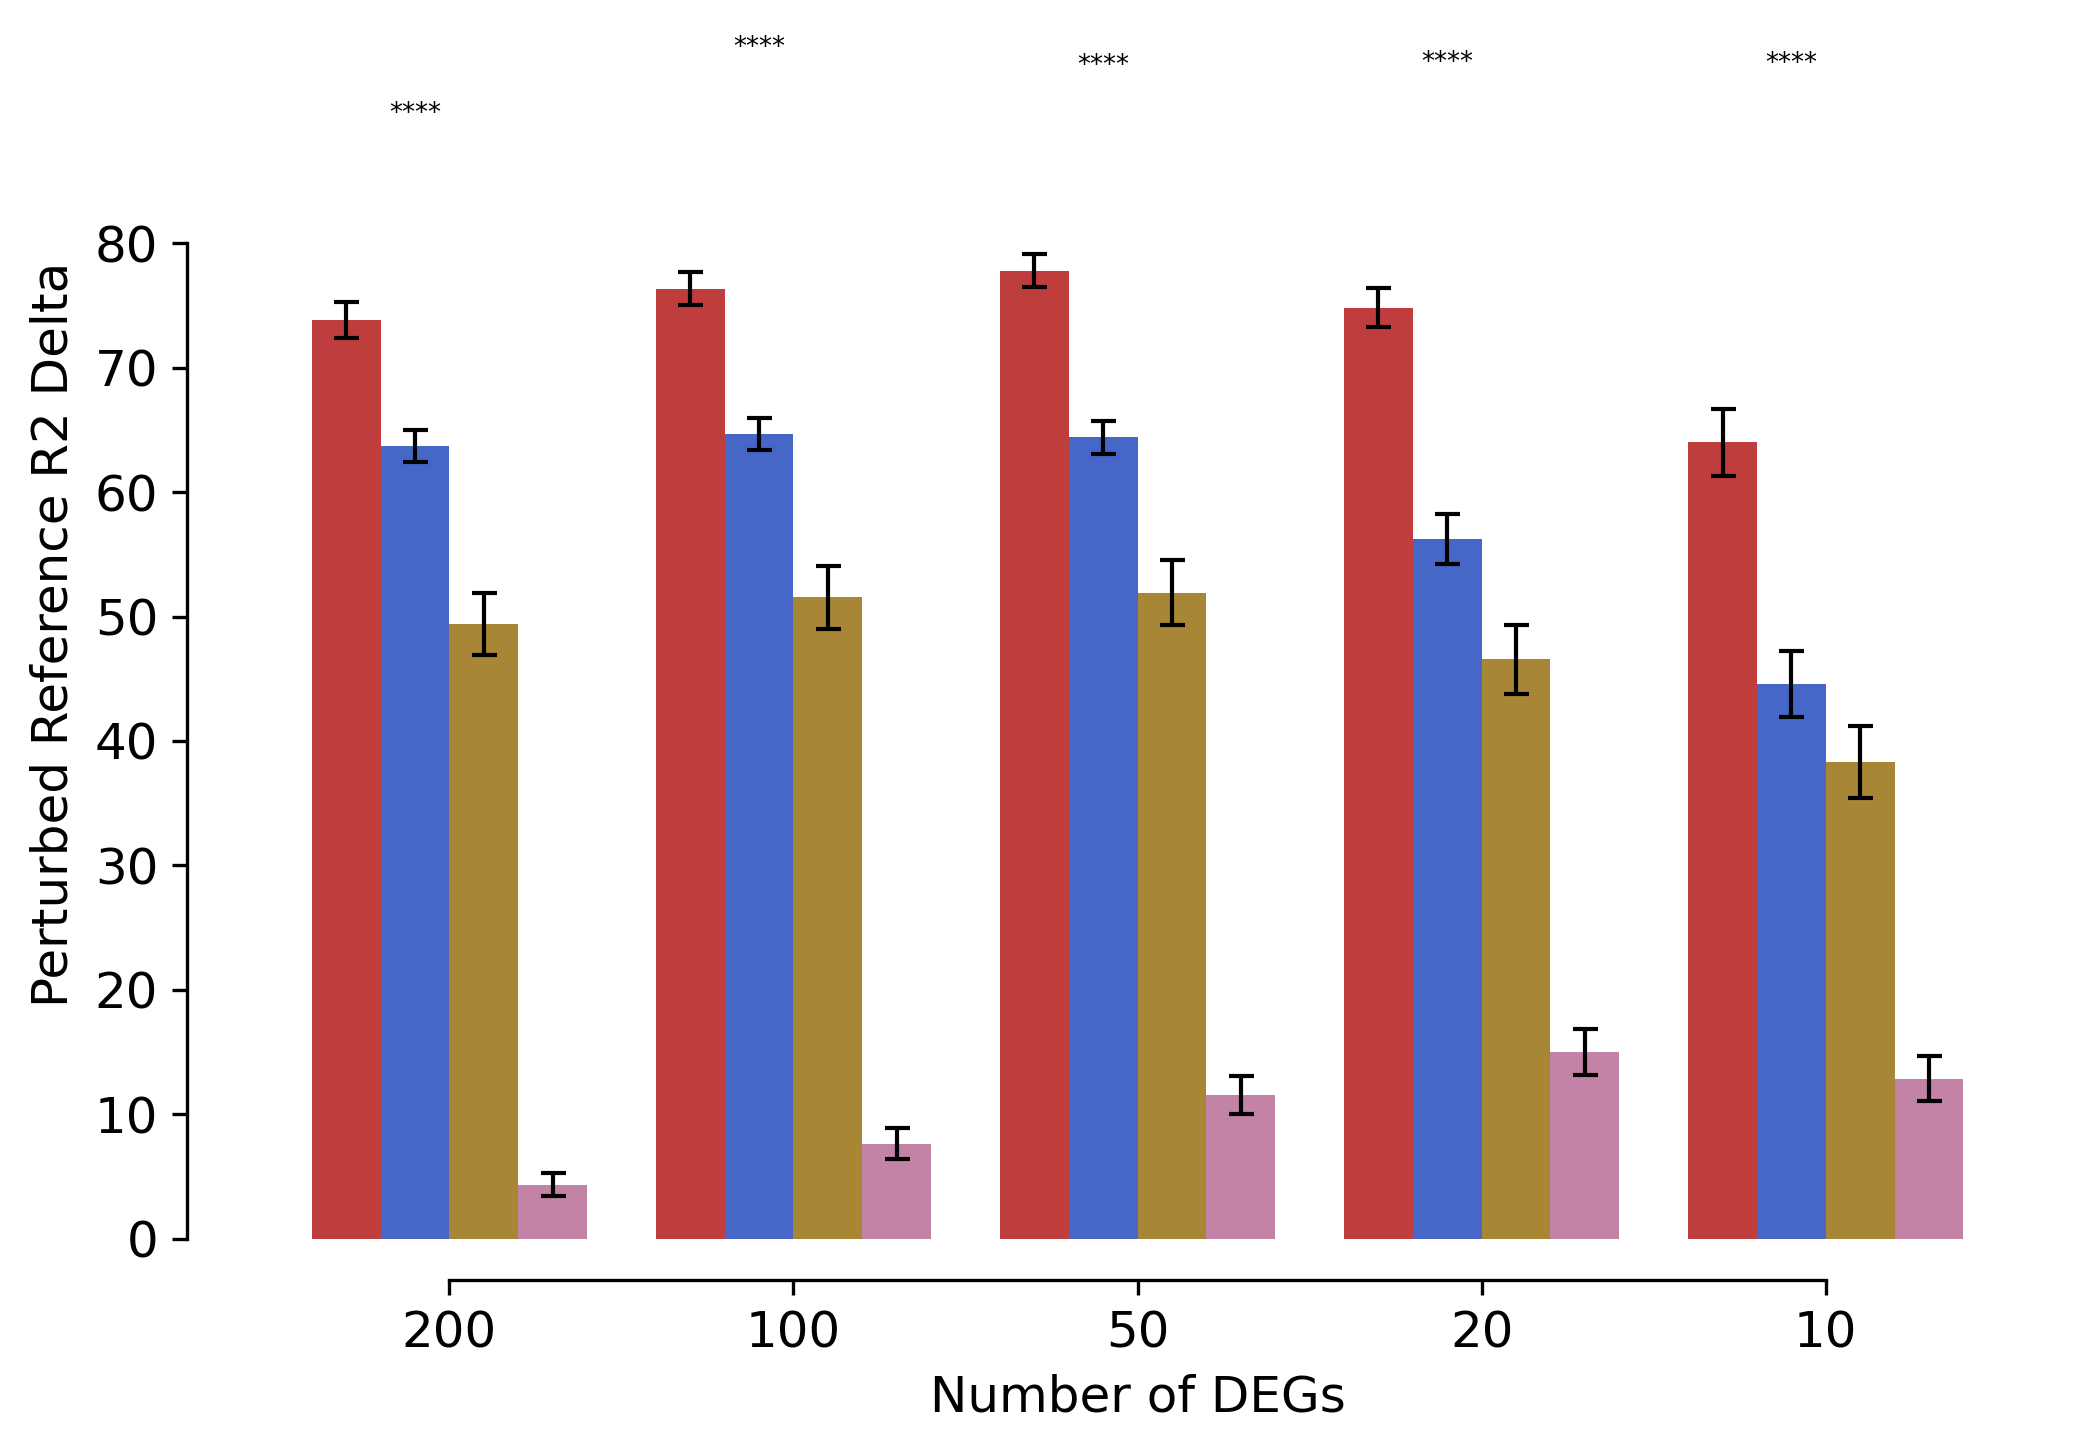

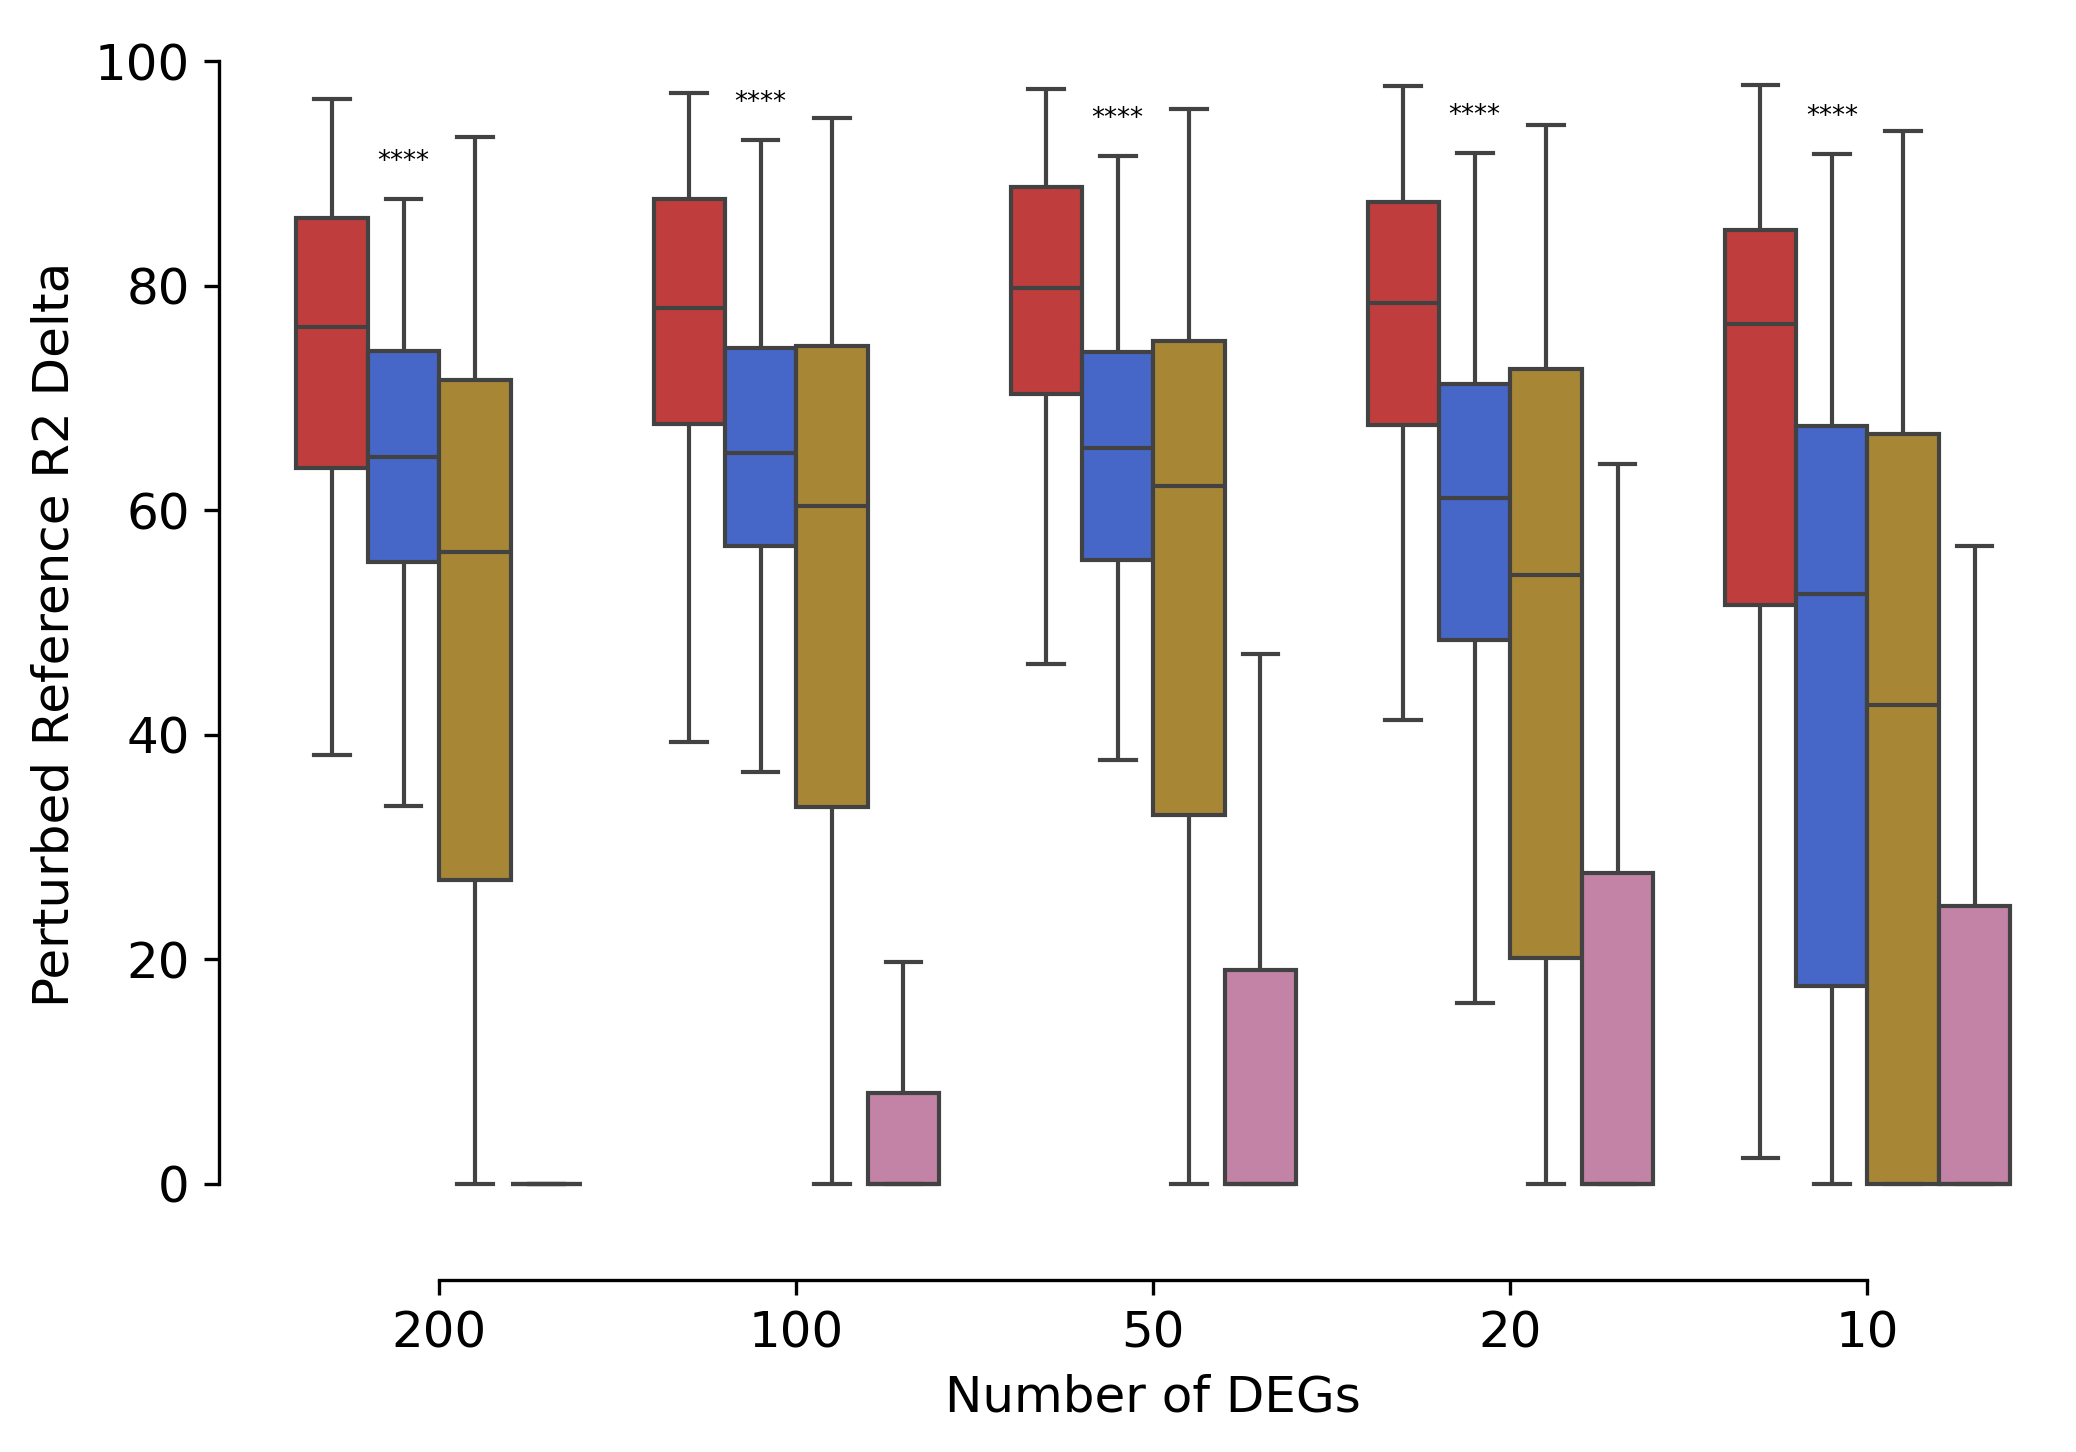

Using 128 perturbation


/home/SE/Desktop/Projects/SCDISENTANGLE/hygeia/hygeia/utils/hplots.py:208: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


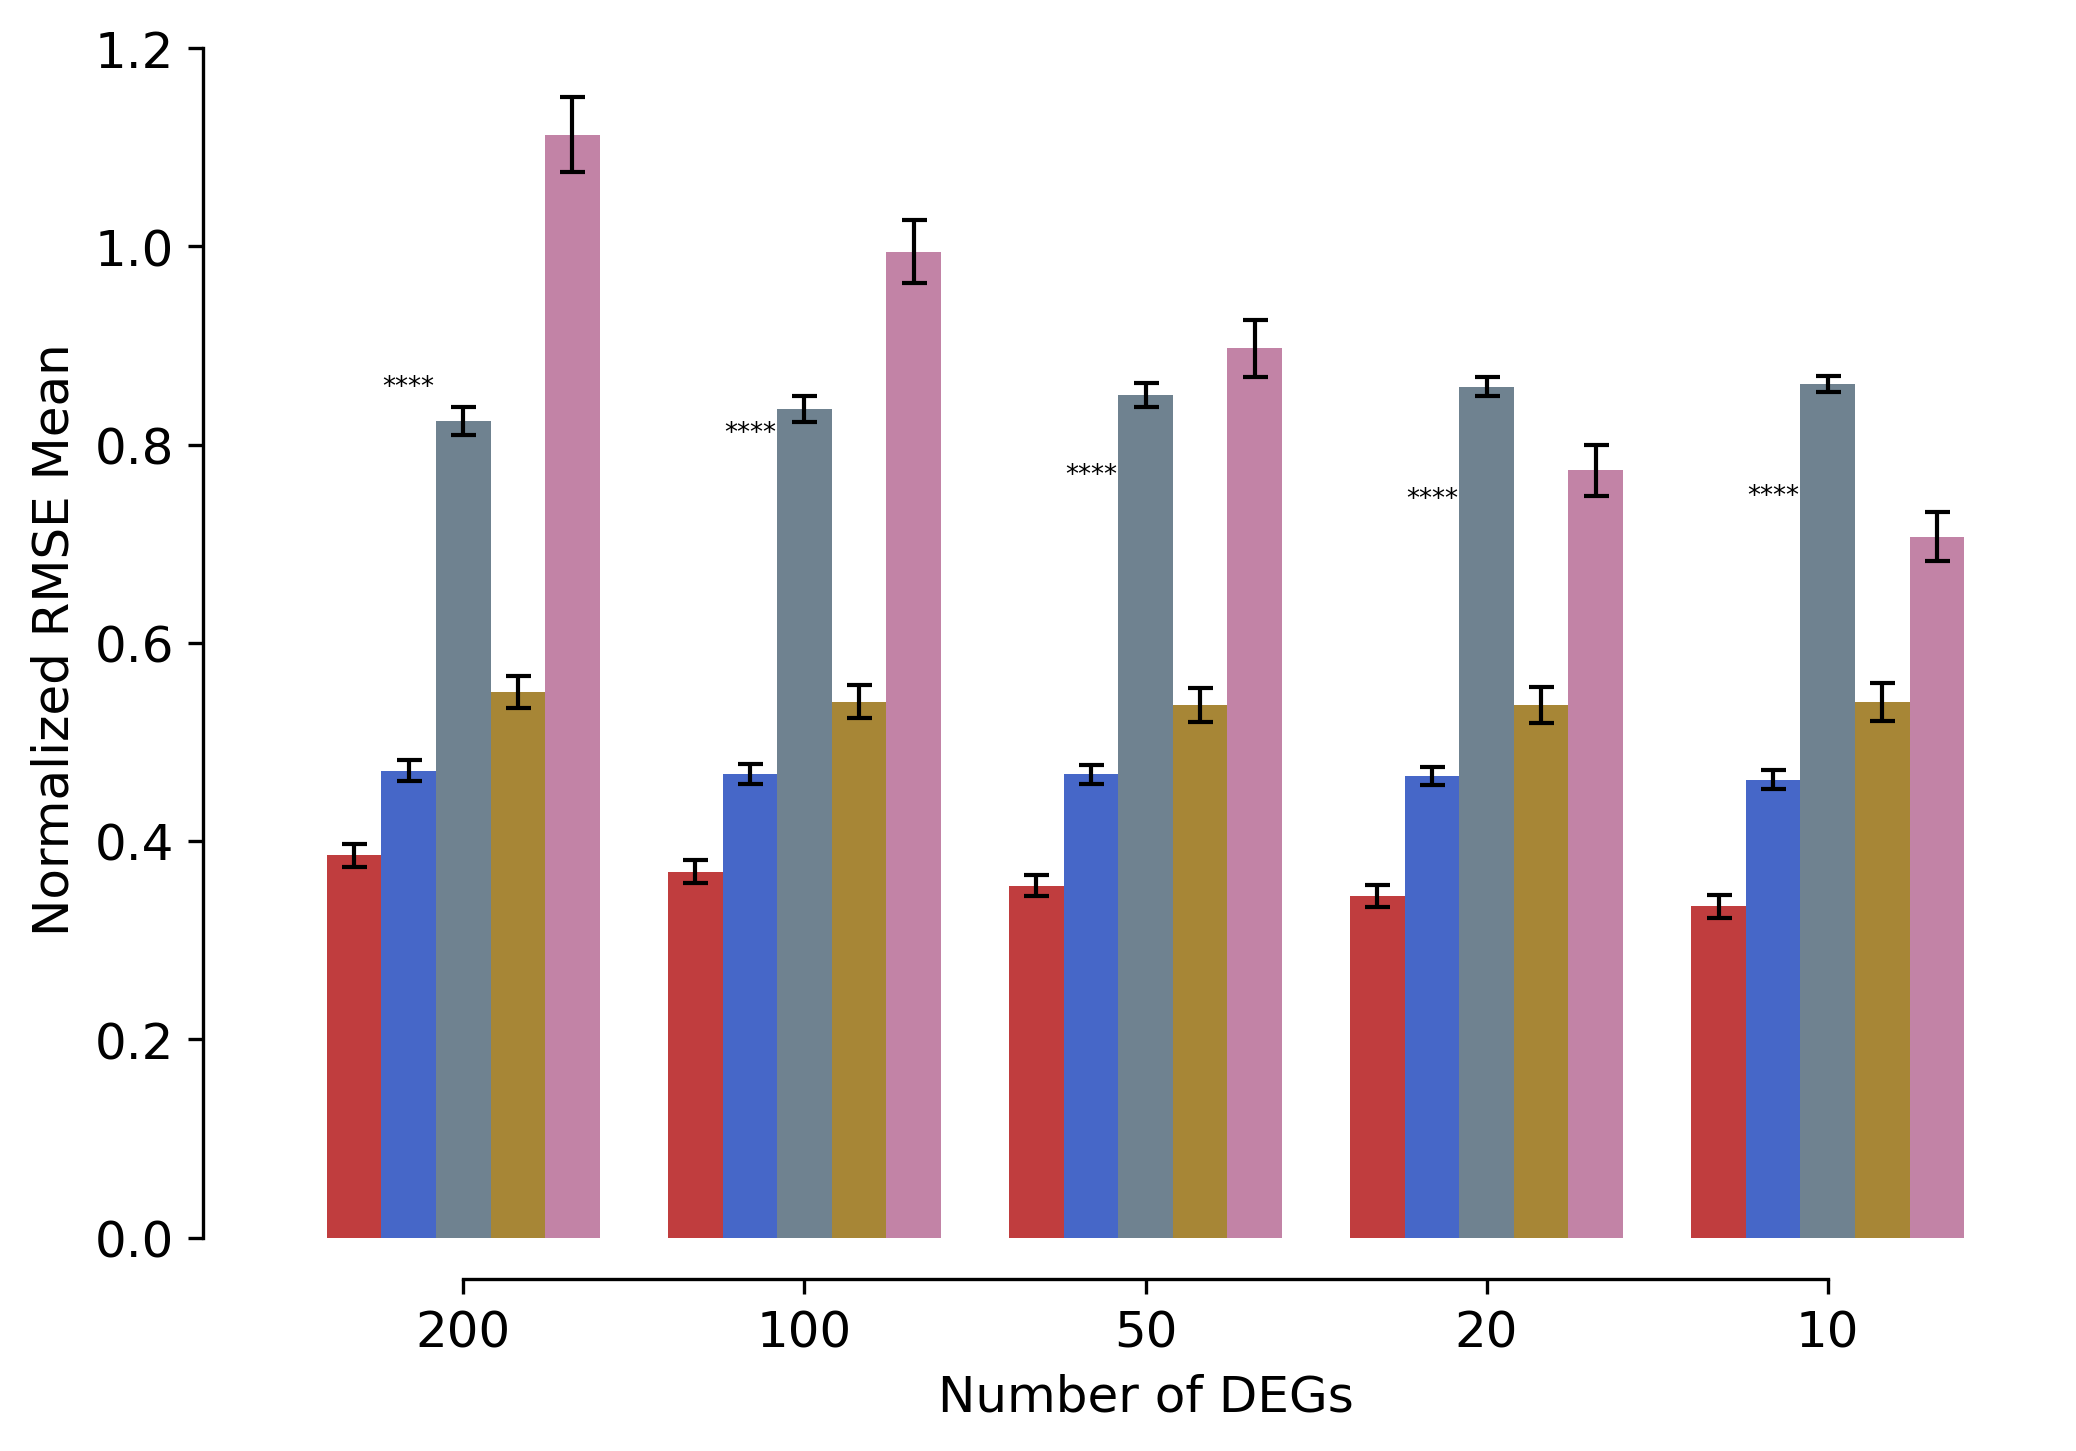

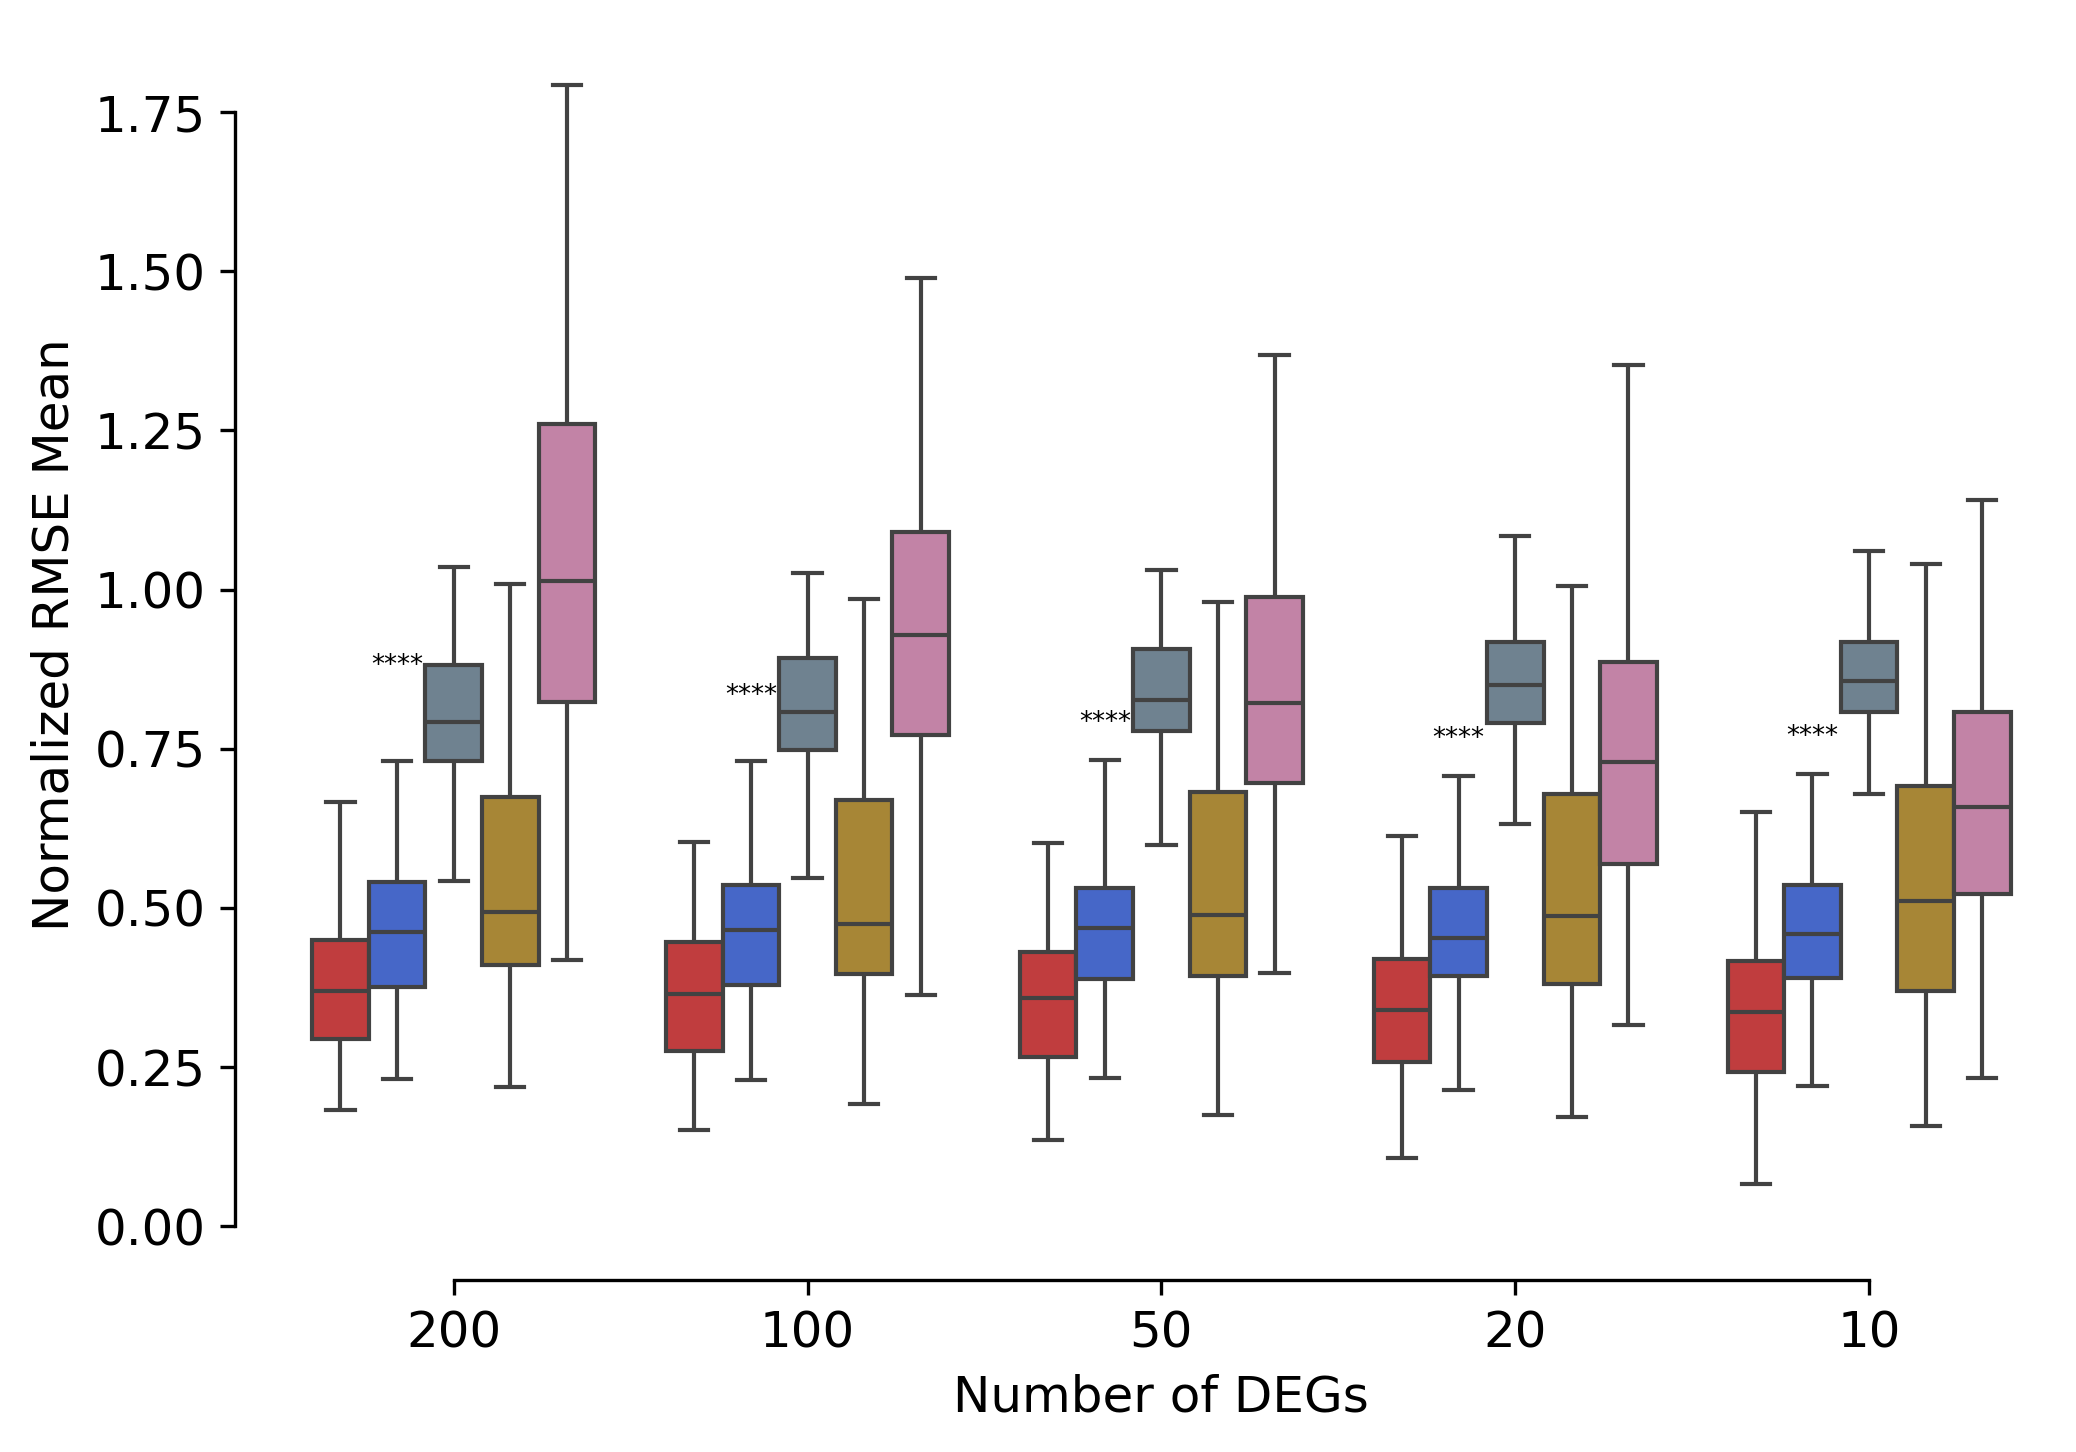

Using 128 perturbation


/home/SE/Desktop/Projects/SCDISENTANGLE/hygeia/hygeia/utils/hplots.py:208: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


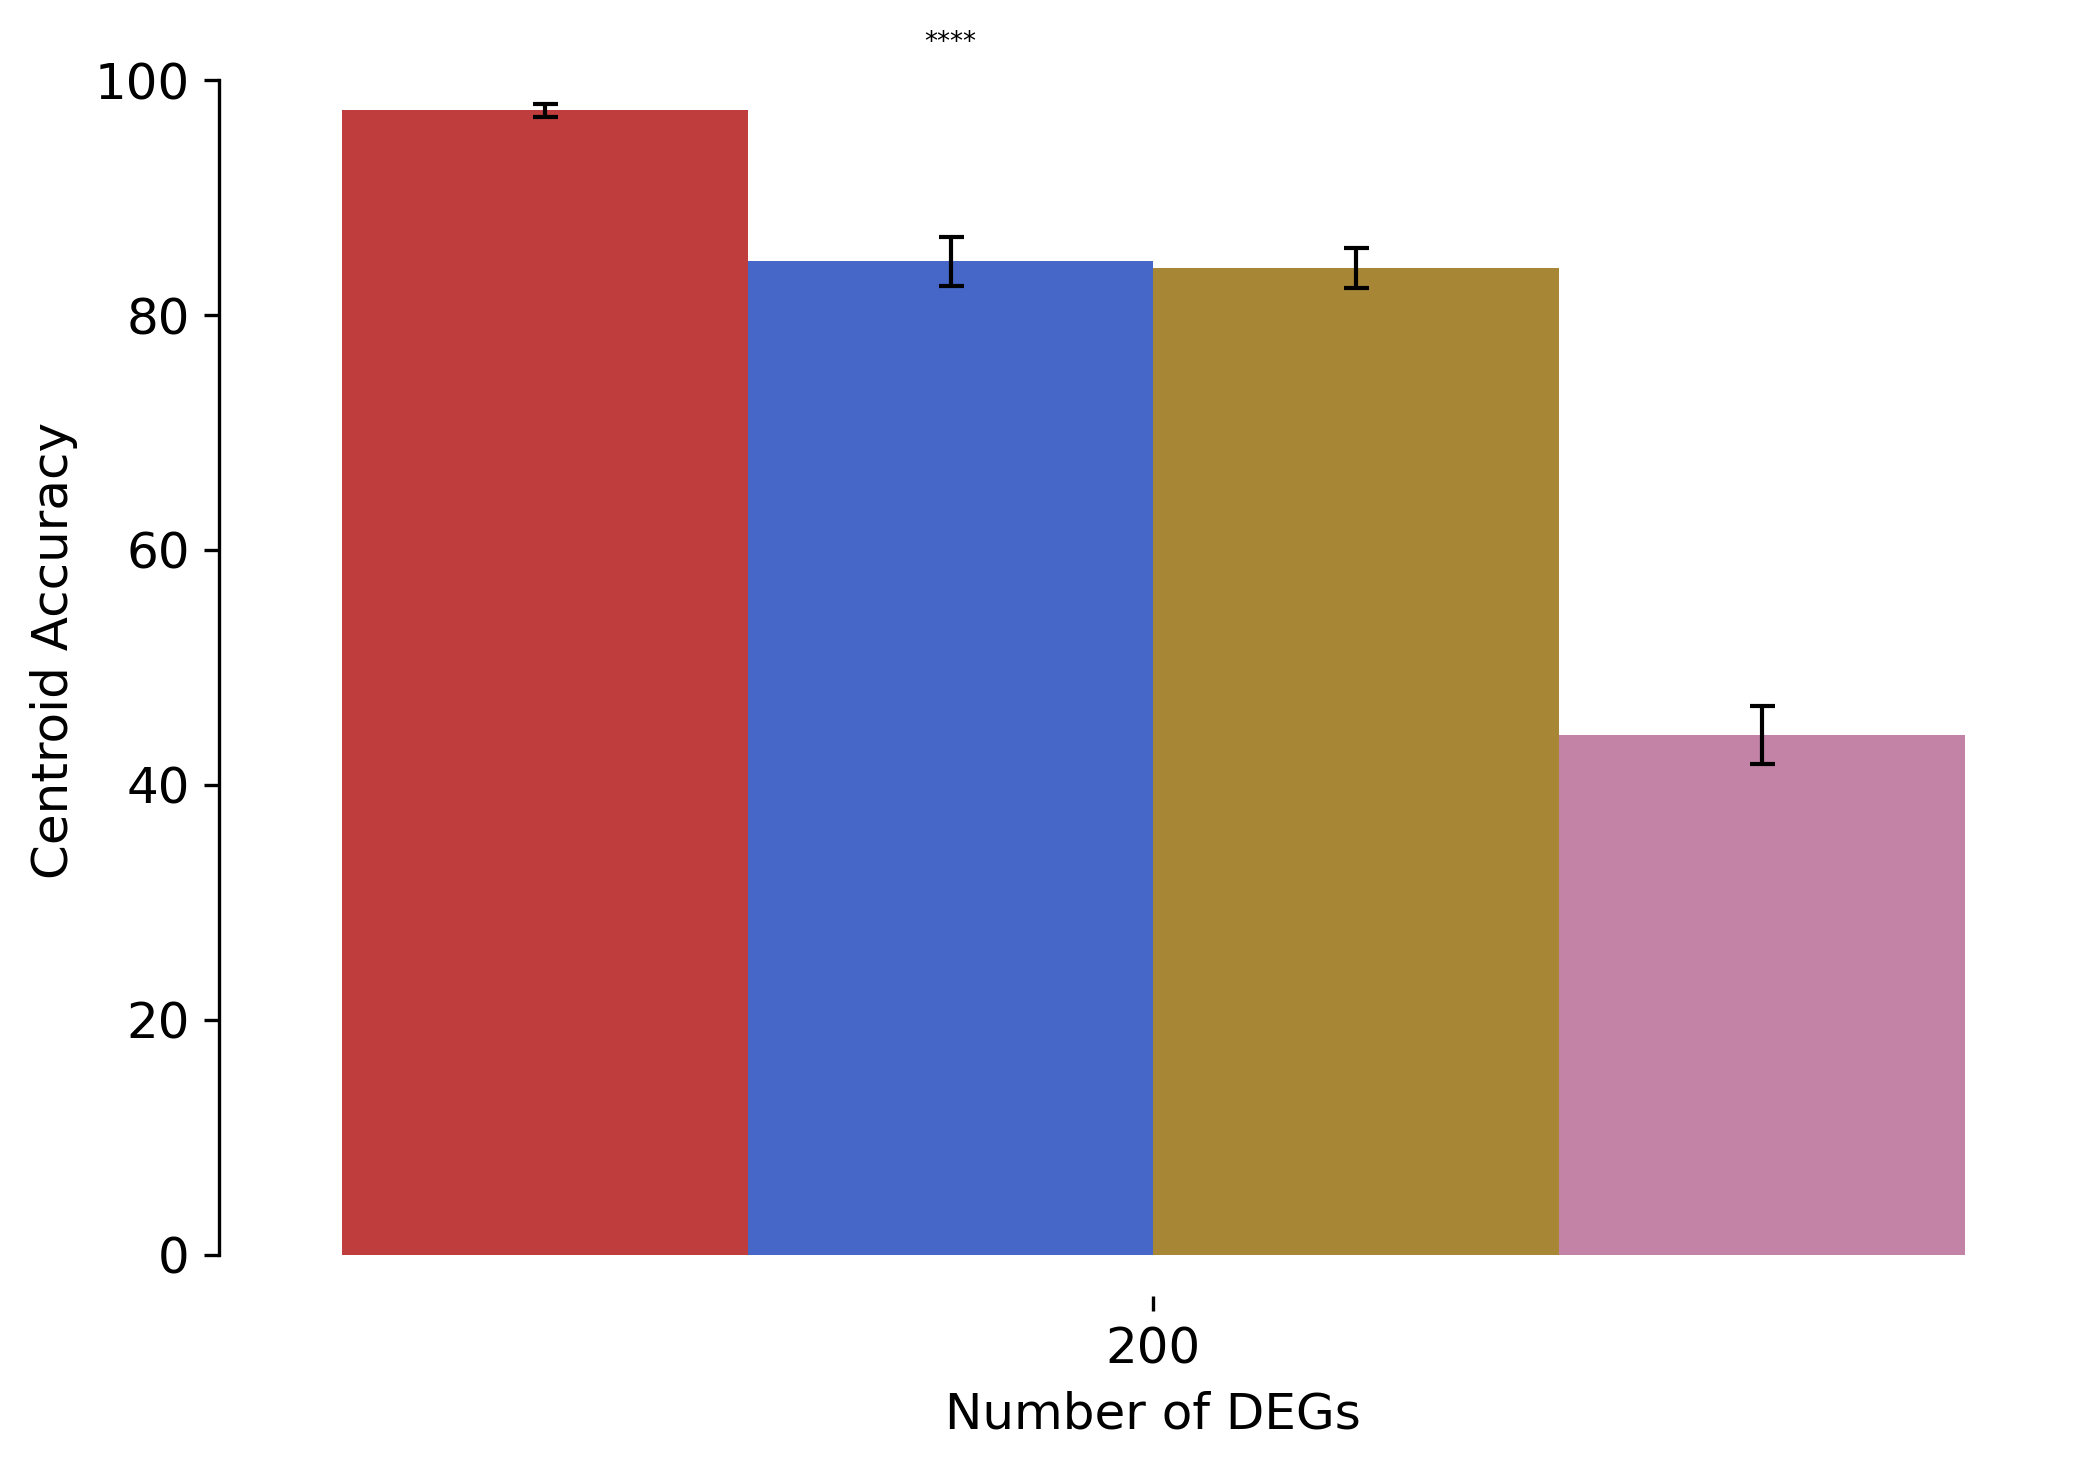

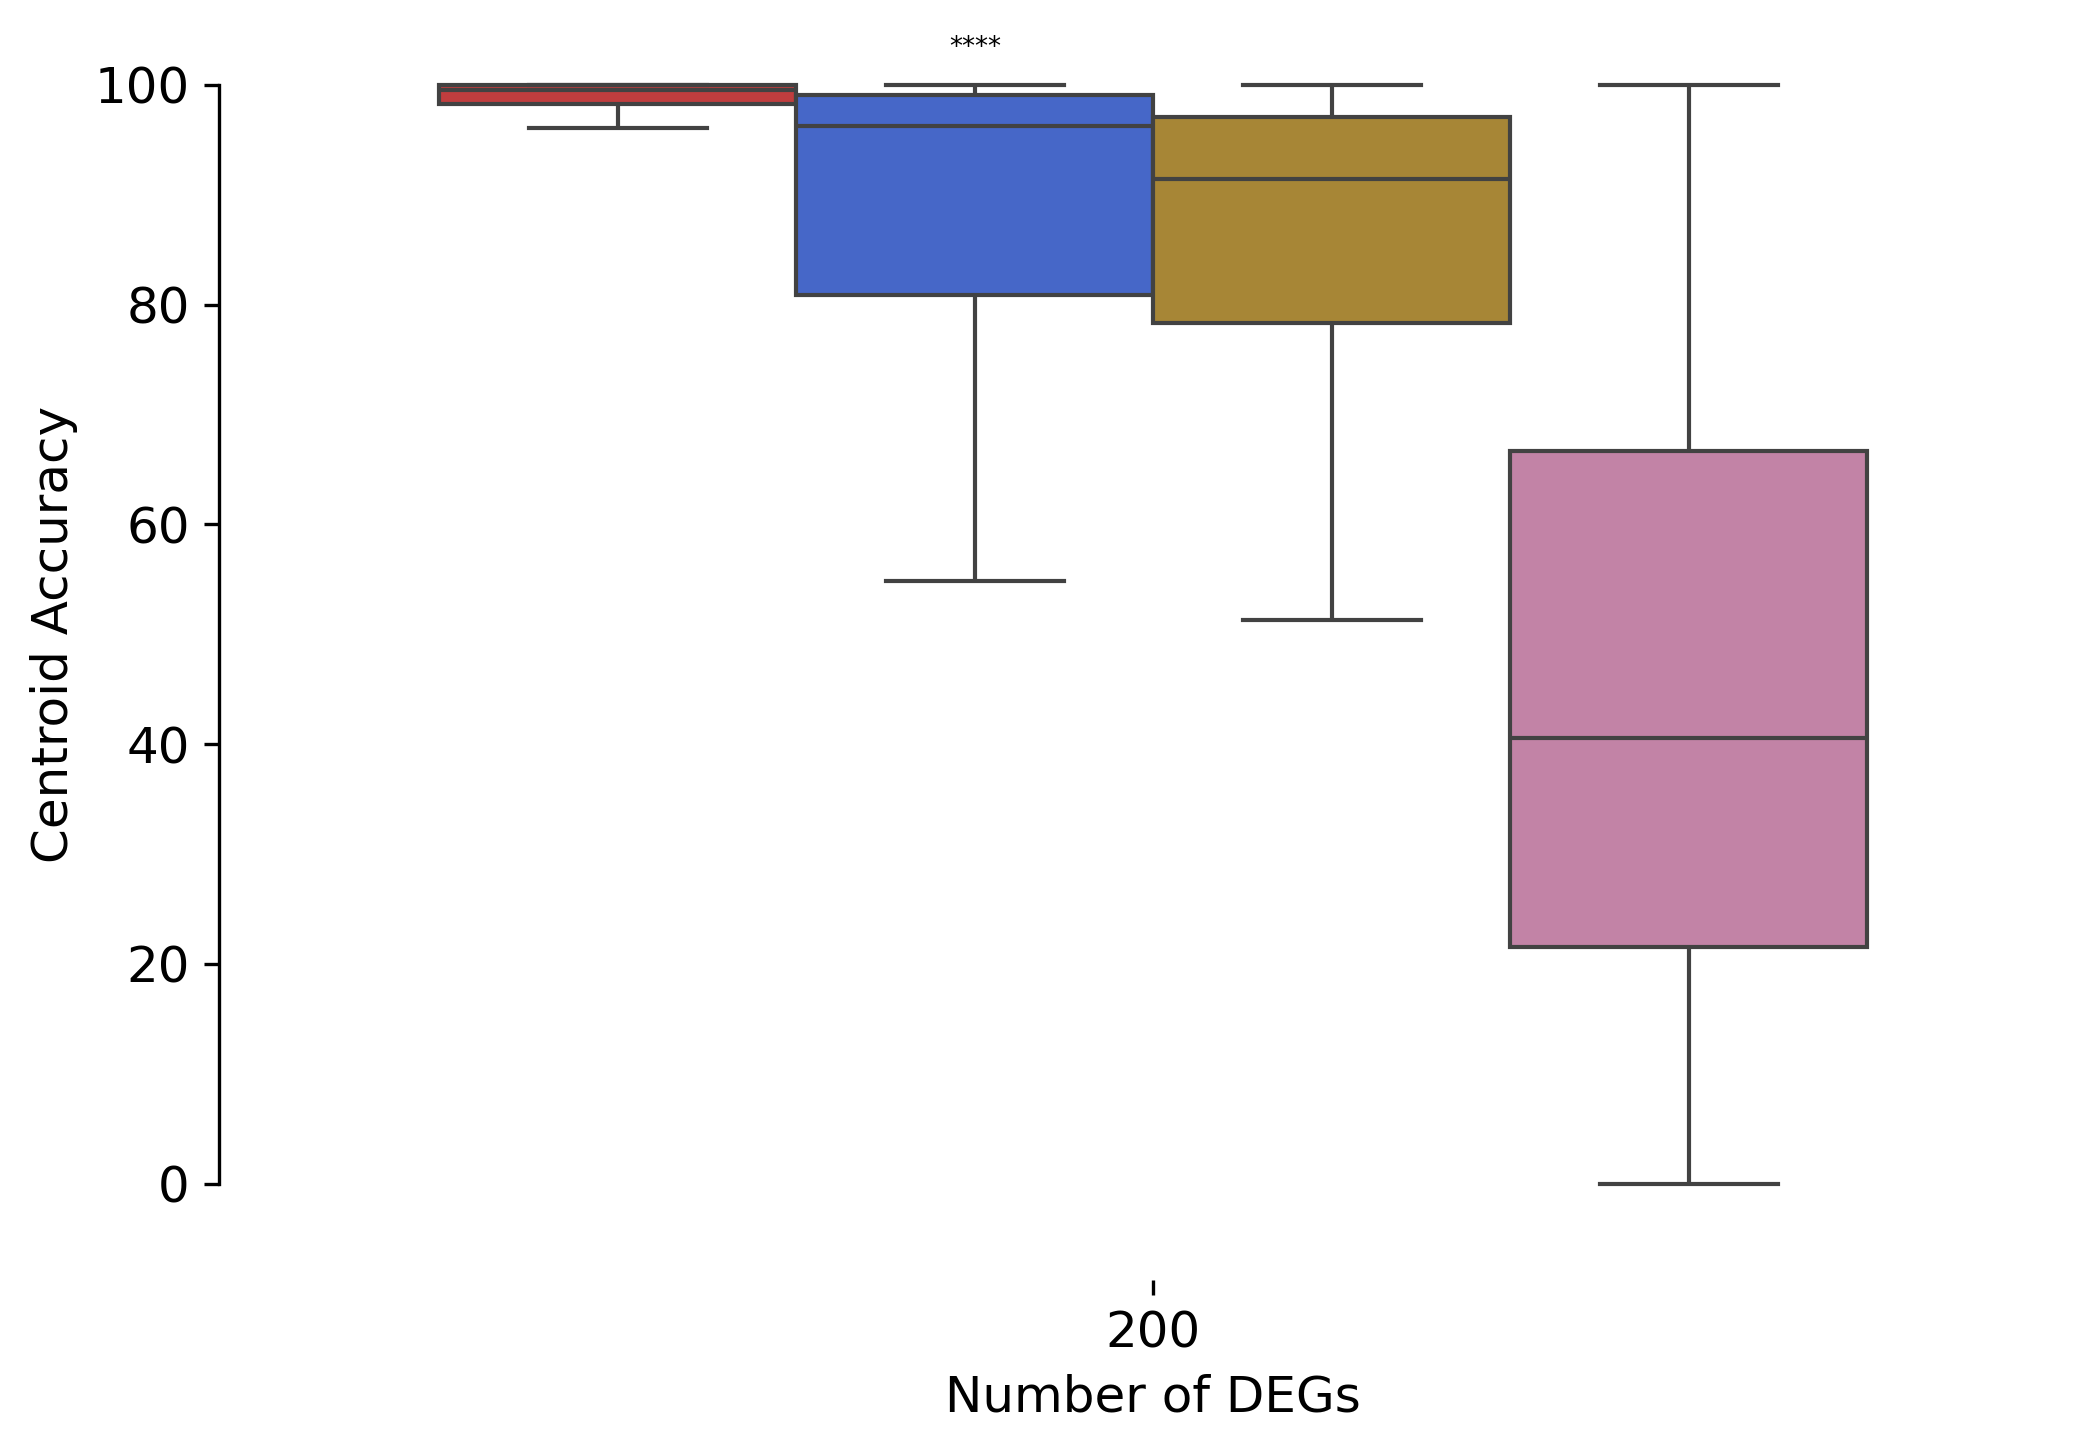

Using 128 perturbation


/home/SE/Desktop/Projects/SCDISENTANGLE/hygeia/hygeia/utils/hplots.py:208: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


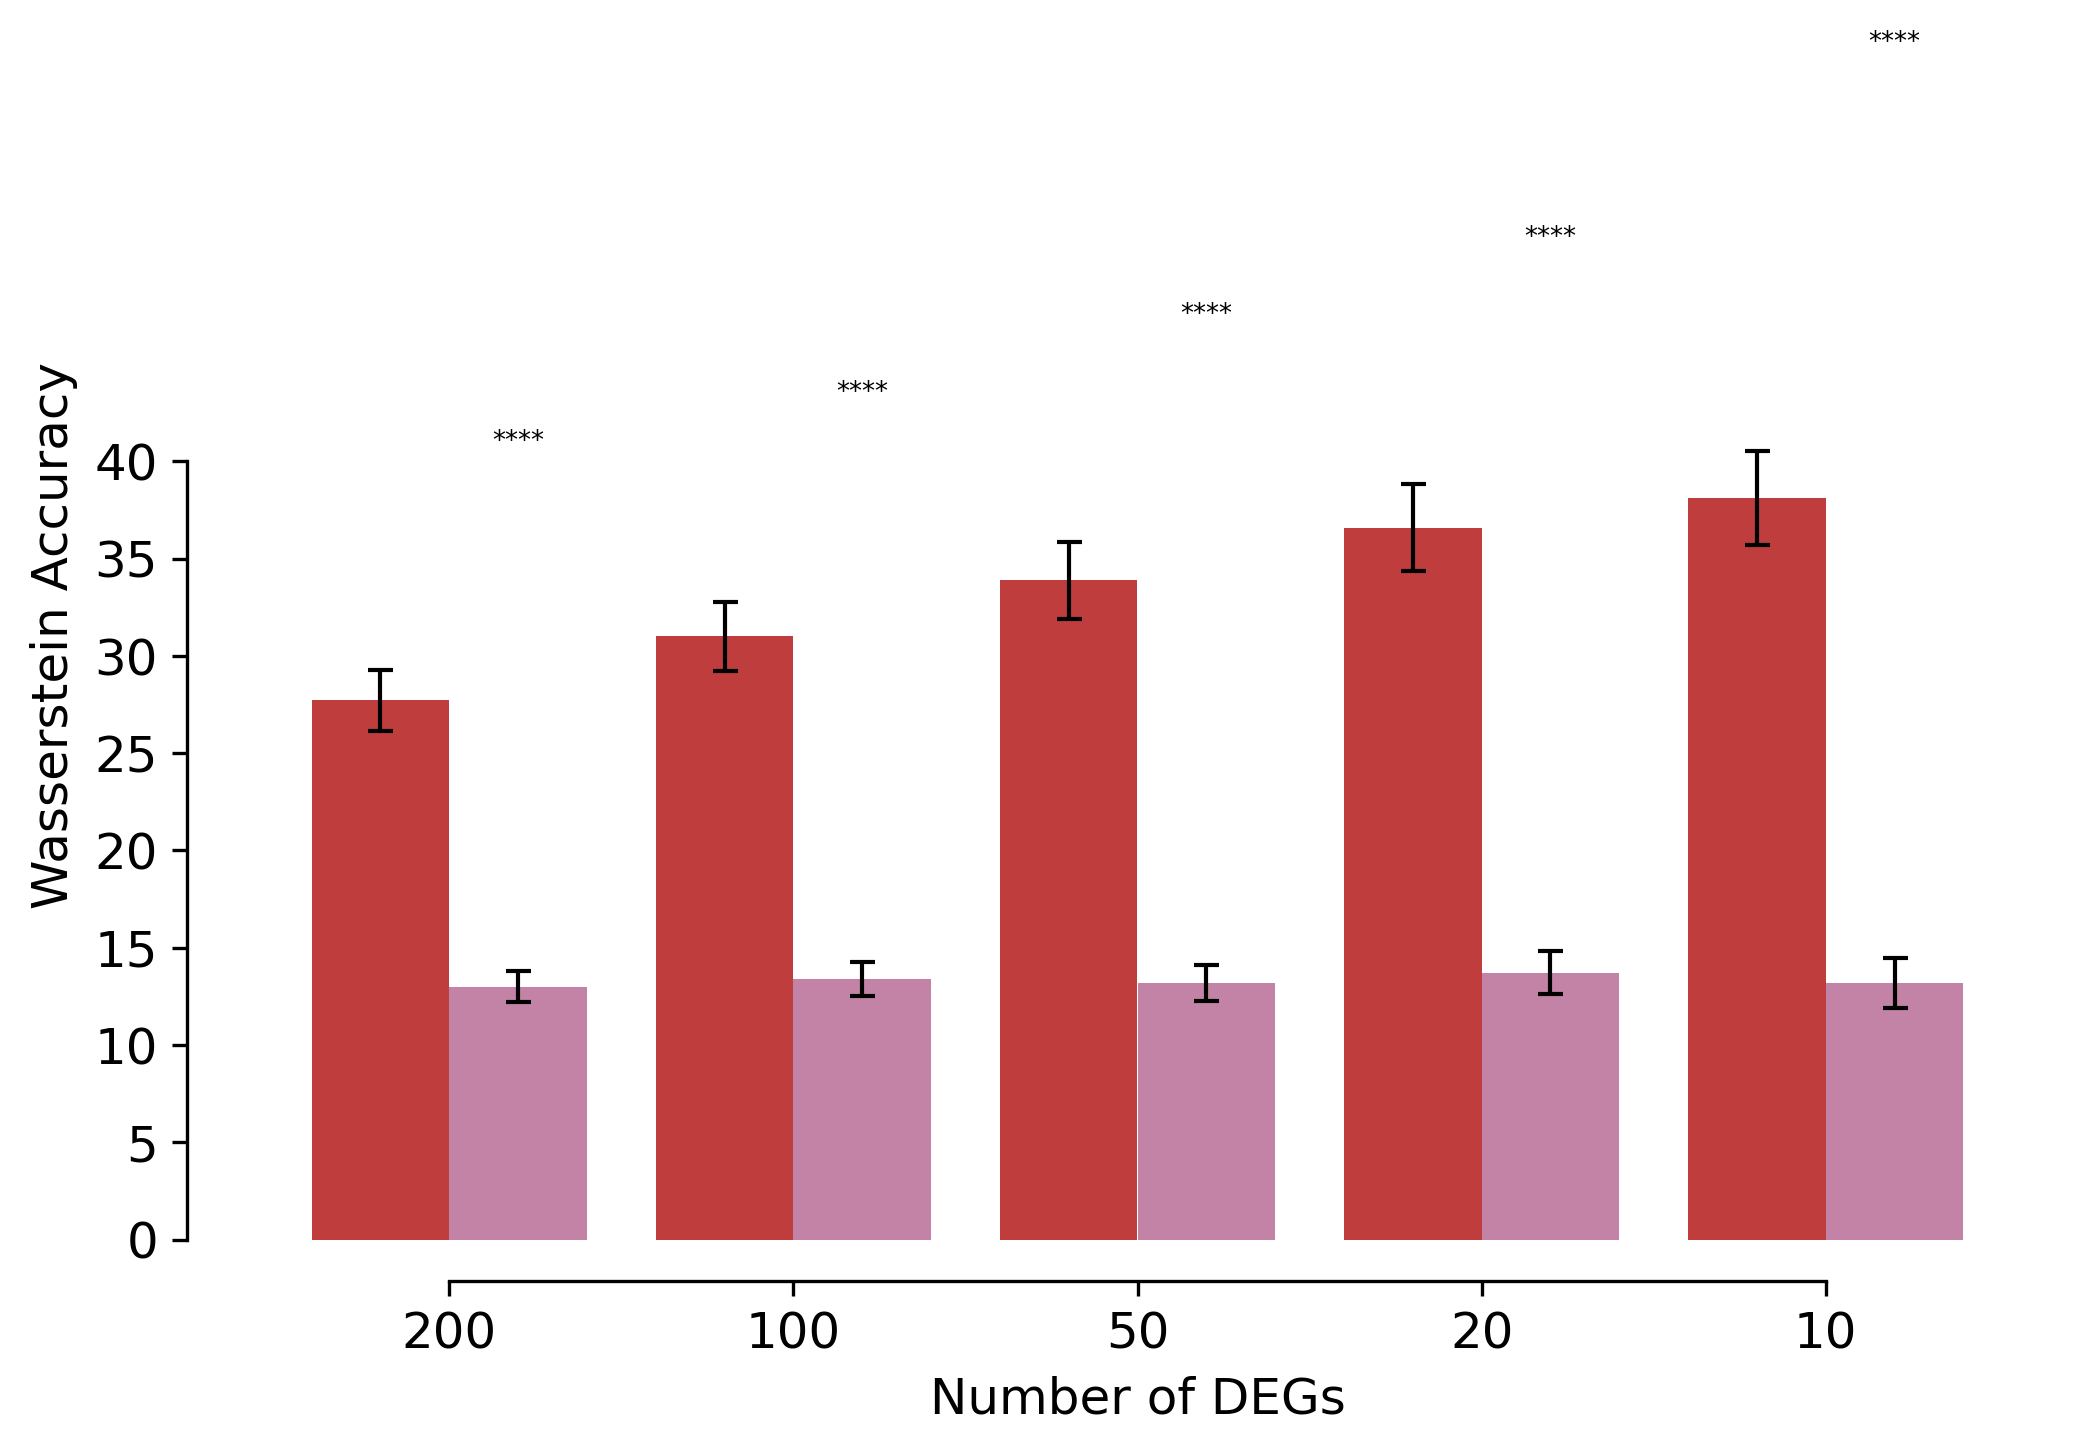

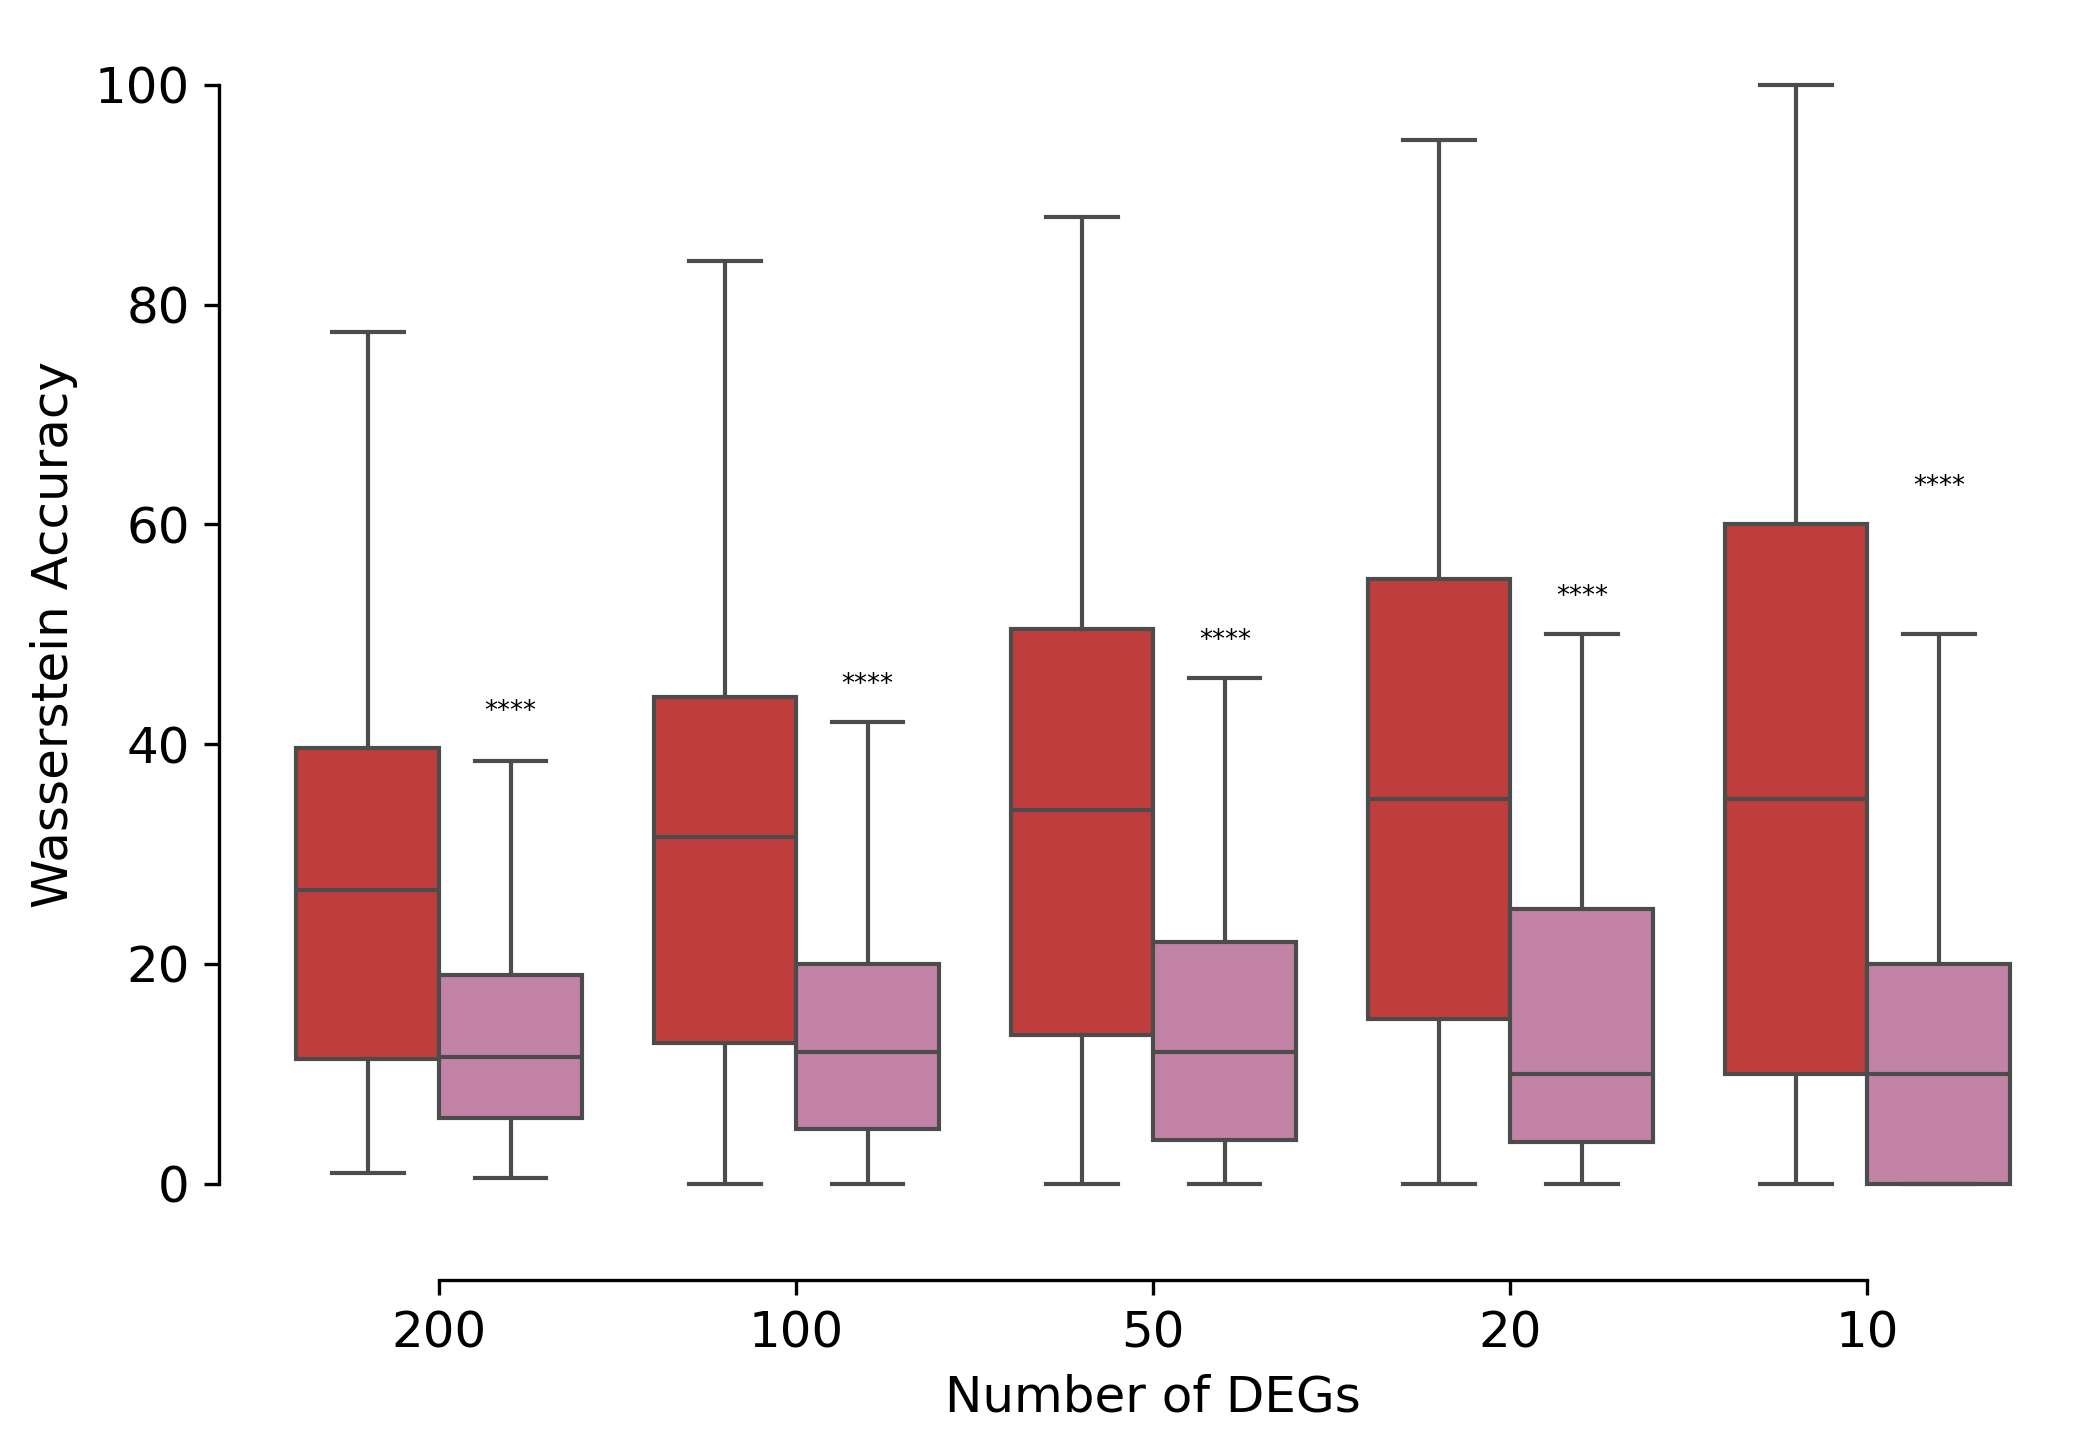

Using 128 perturbation


/home/SE/Desktop/Projects/SCDISENTANGLE/hygeia/hygeia/utils/hplots.py:208: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


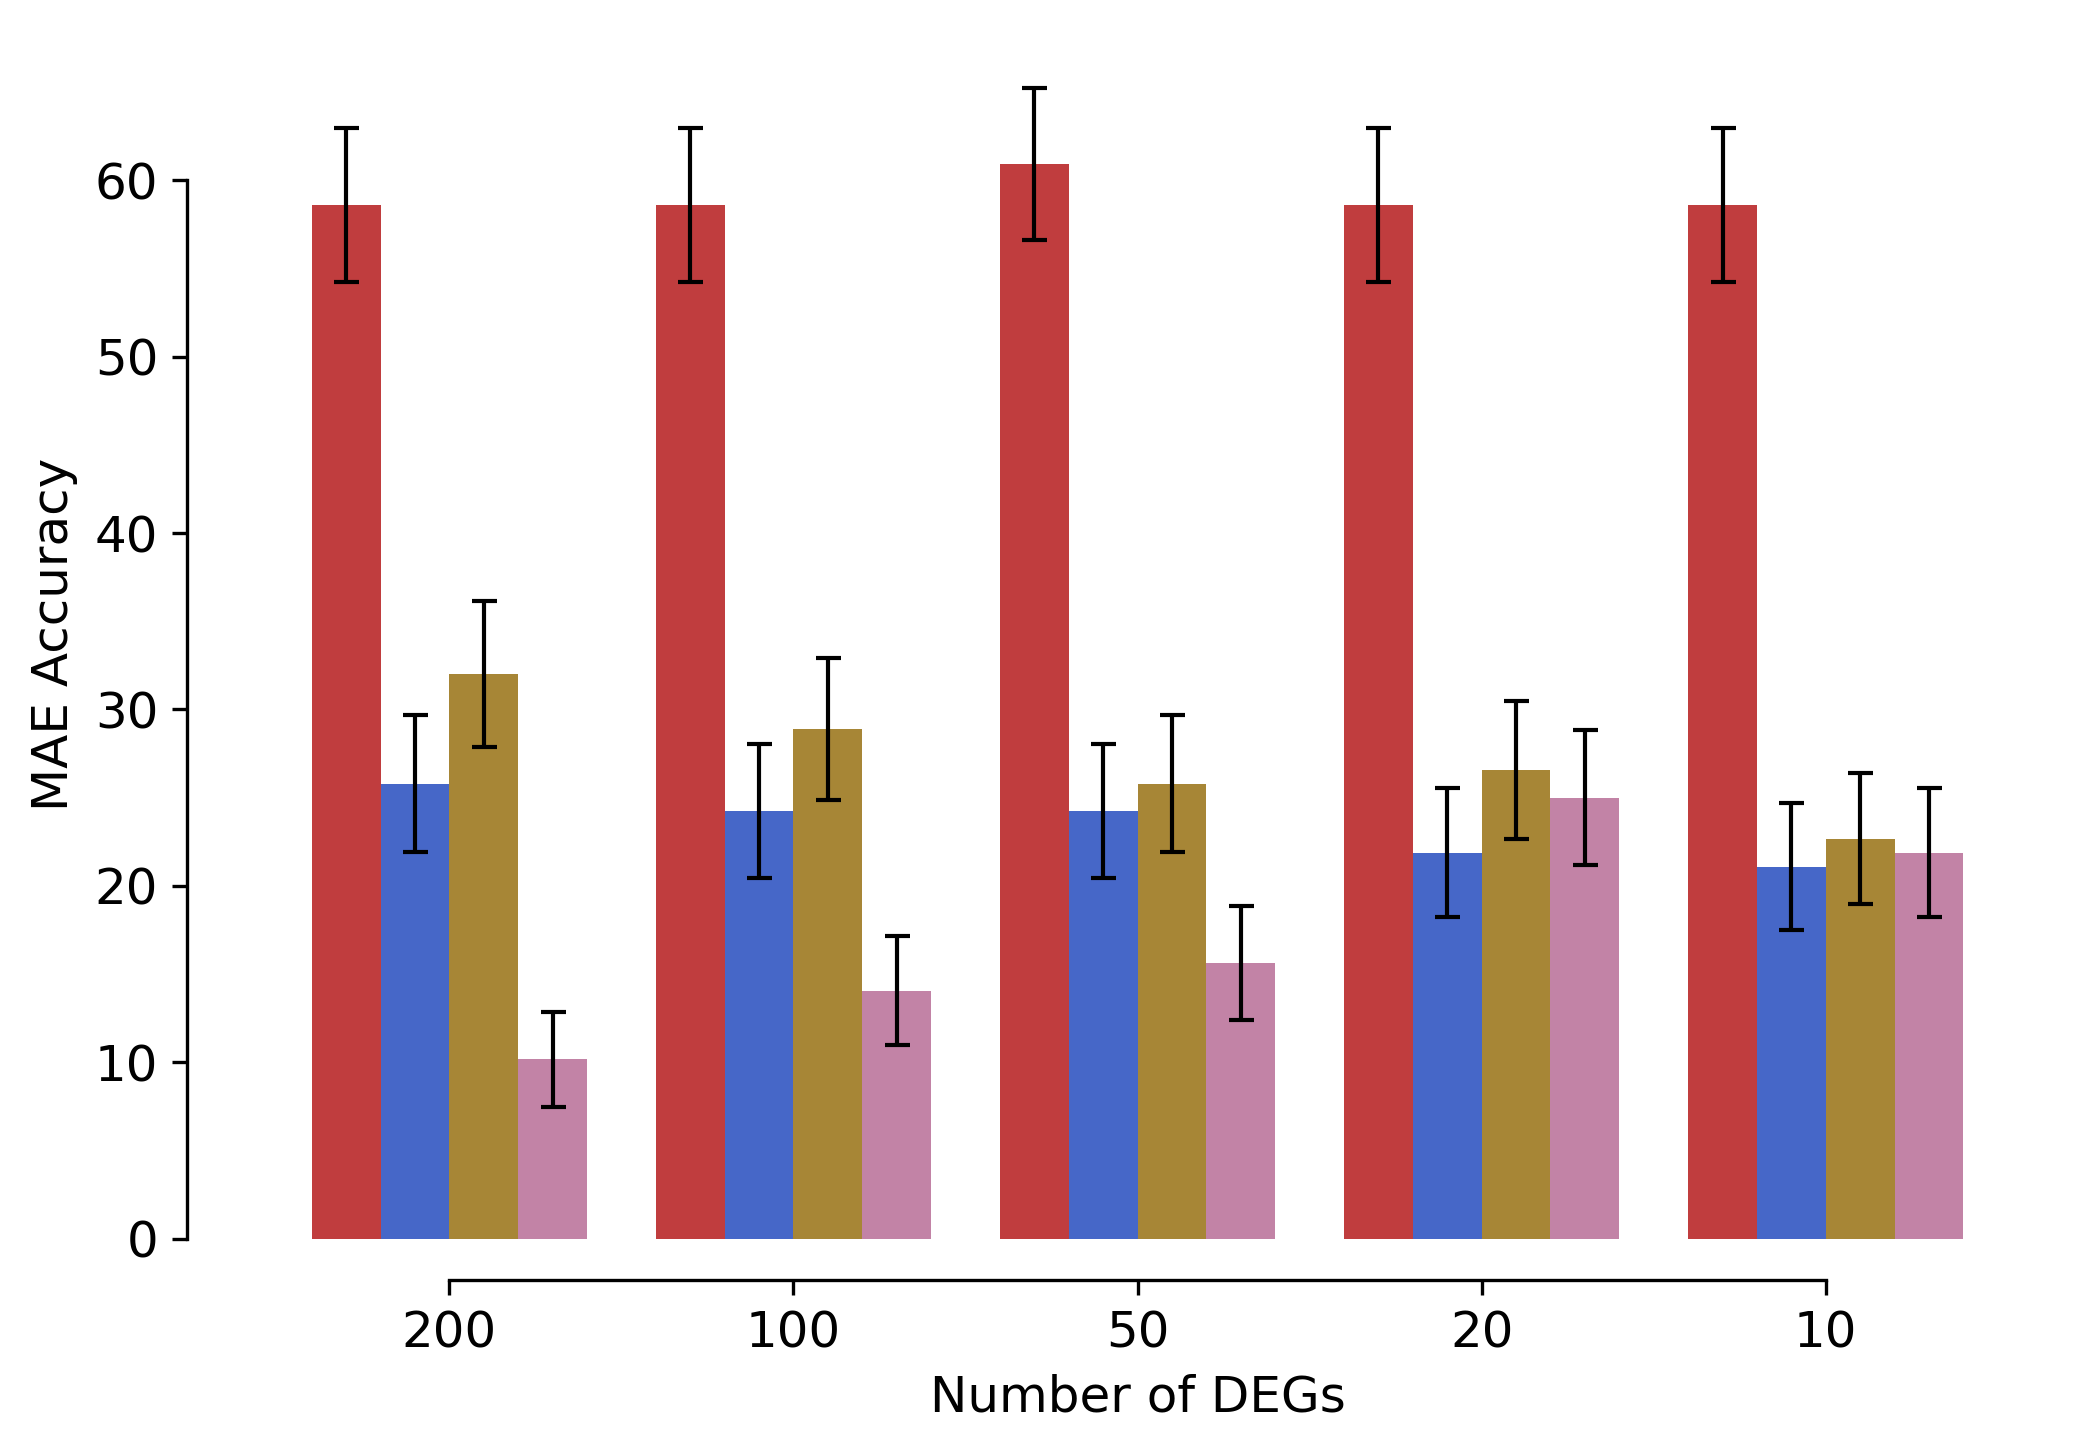

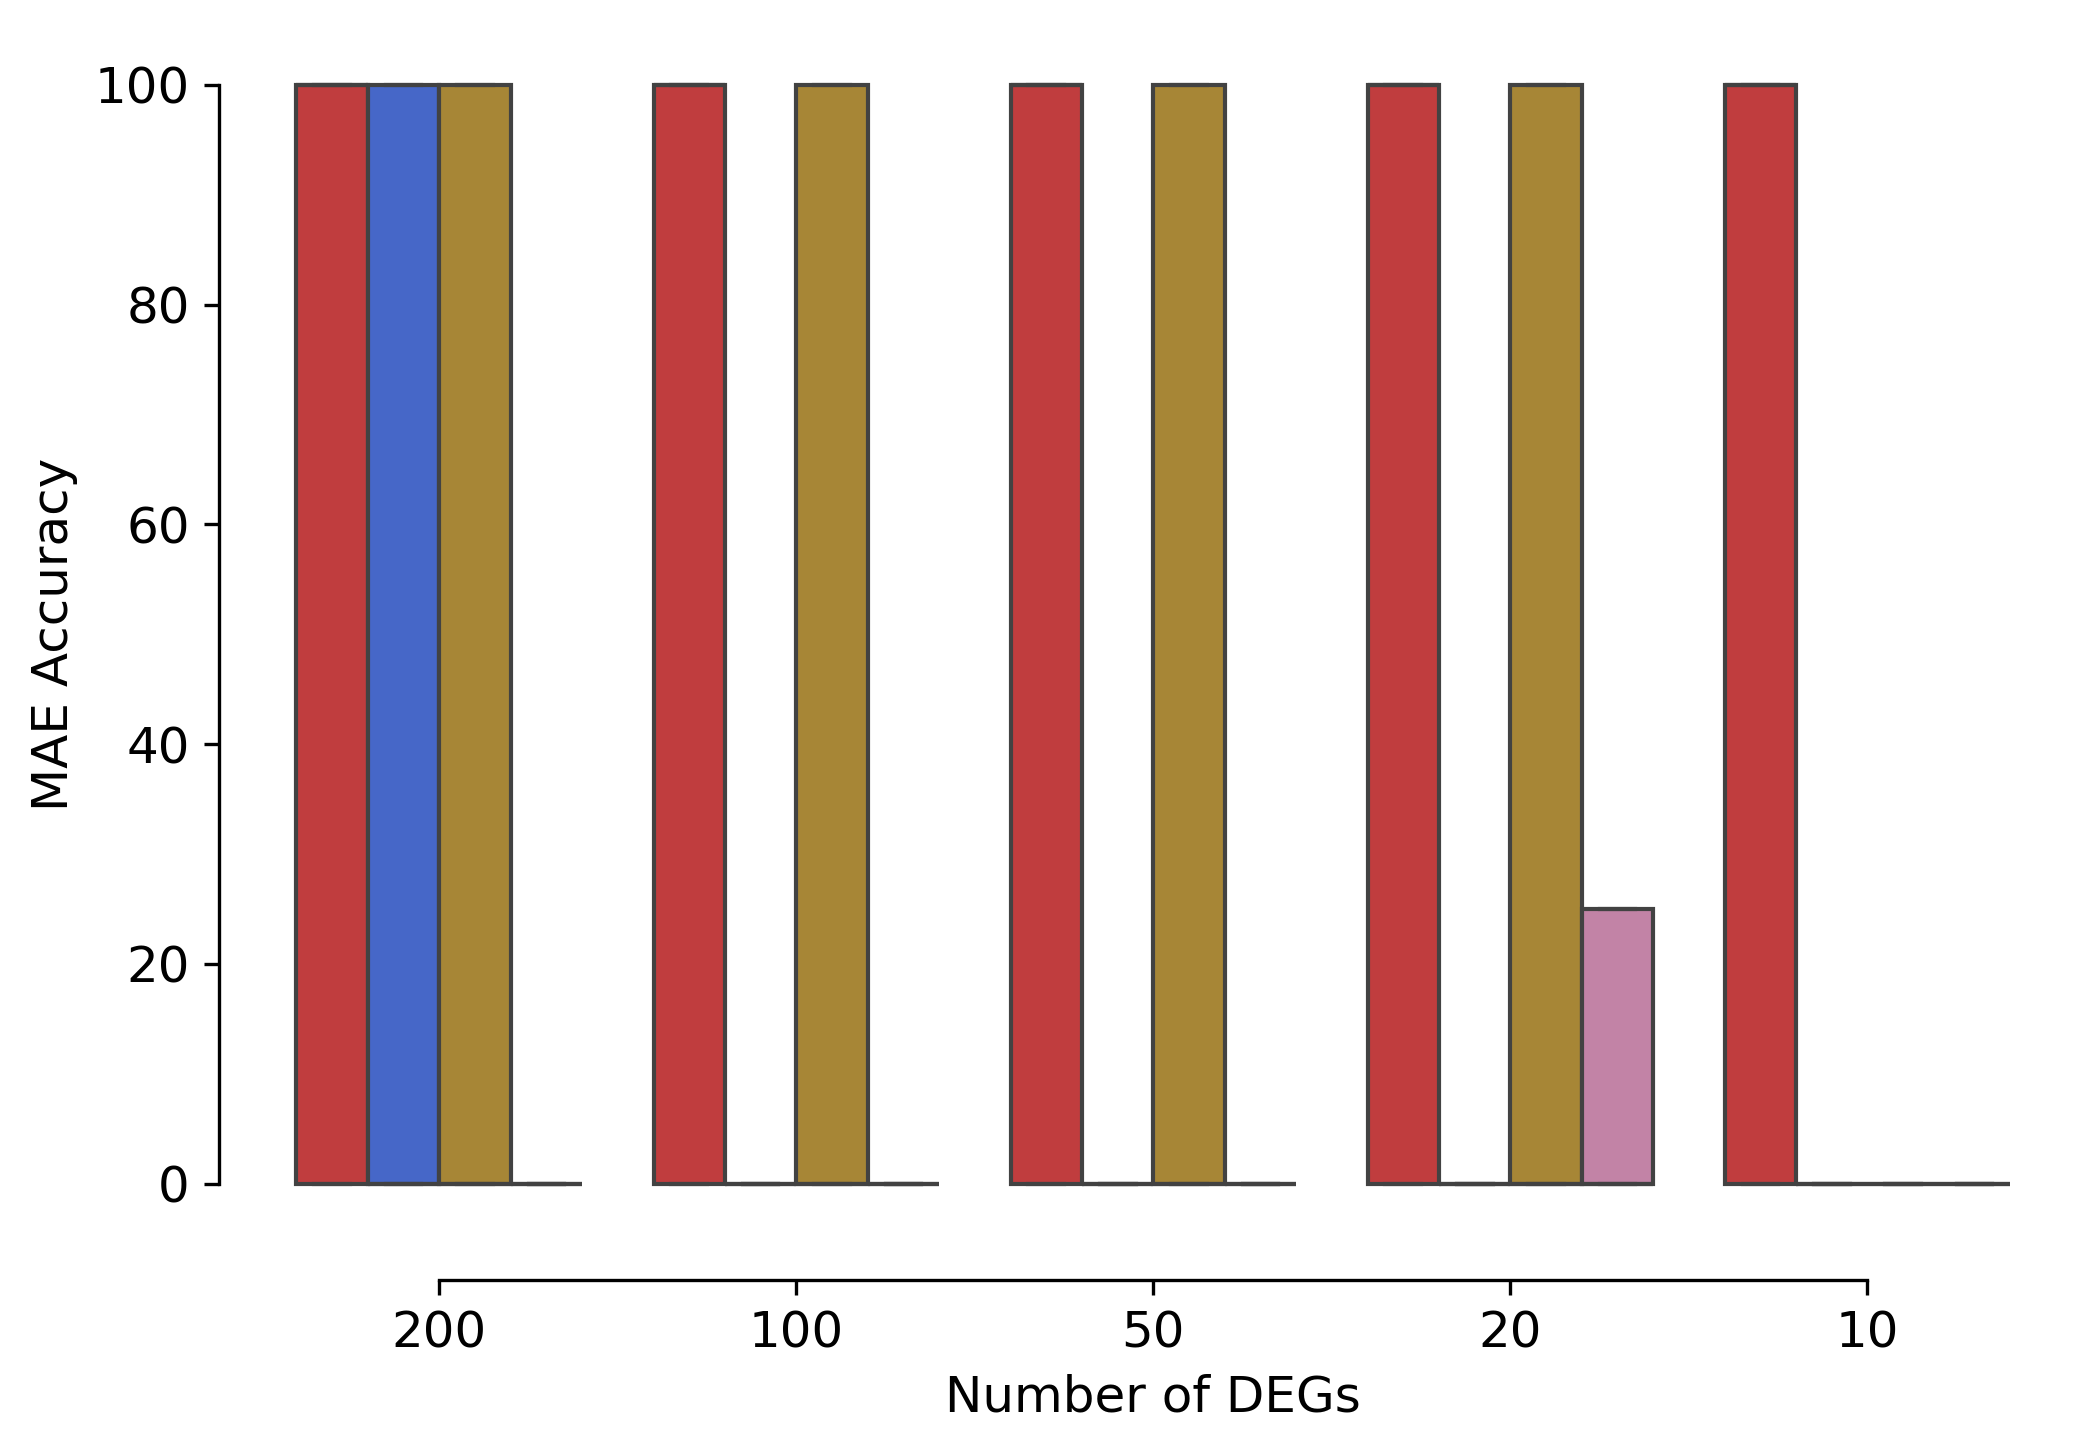

Using 128 perturbation


/home/SE/Desktop/Projects/SCDISENTANGLE/hygeia/hygeia/utils/hplots.py:208: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


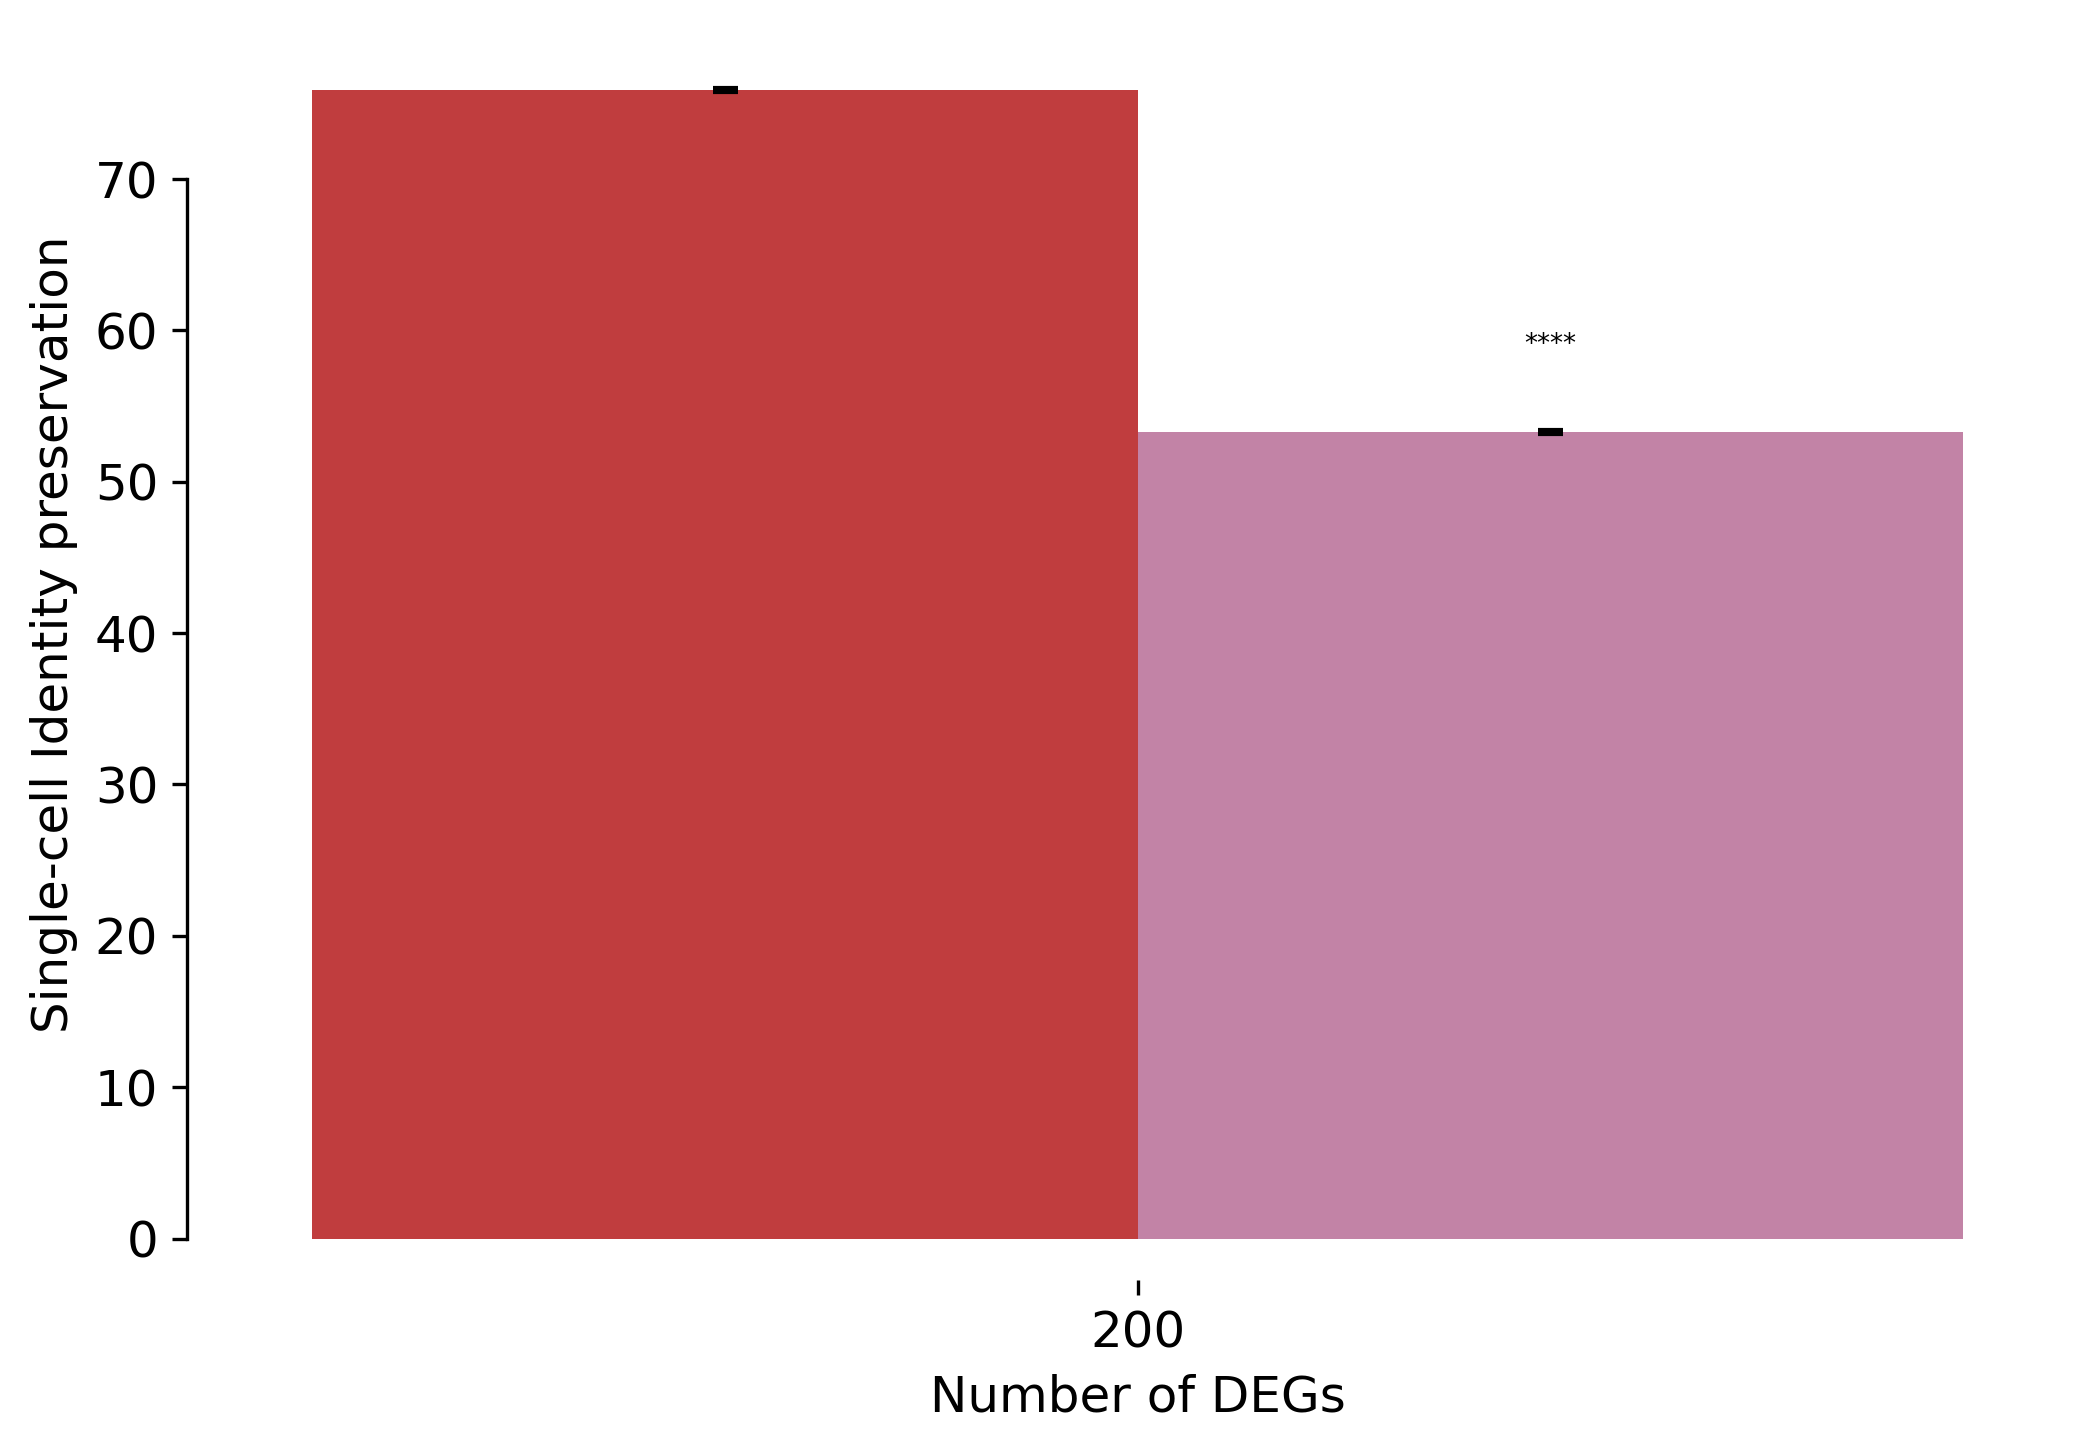

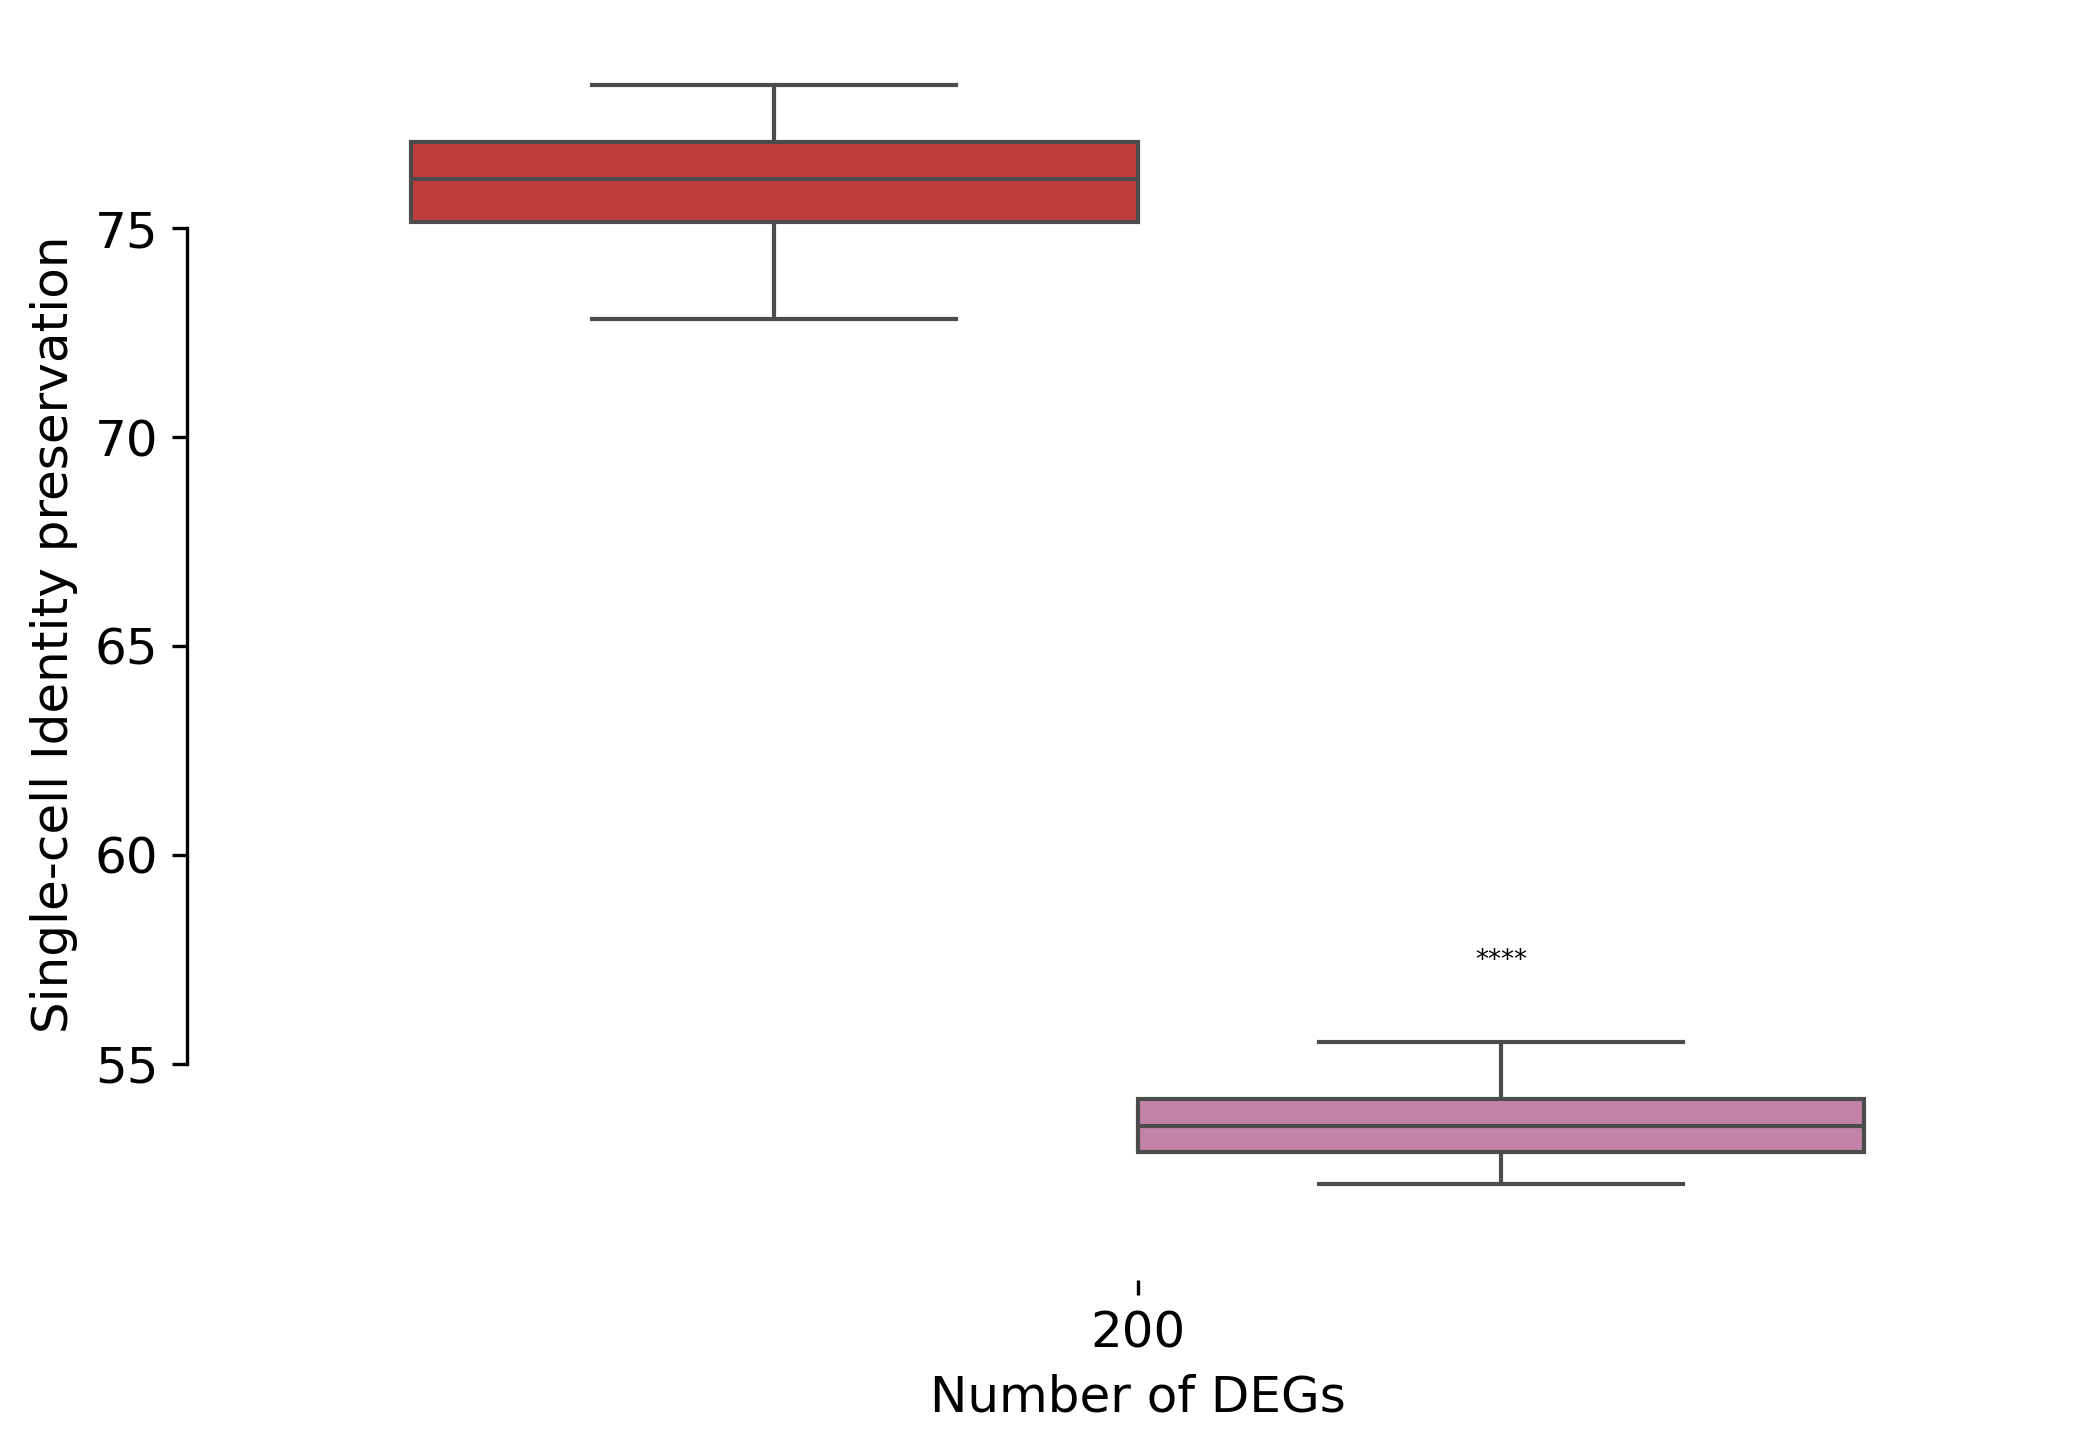

In [6]:
_colors = {
    'scDisentangle': '#d62728',
    'Match-mean': '#305CDE',
    'Perturbation-agnostic': '#698396',
    'GEARS': '#BA8E23',
    'CPA': '#CC79A7',    
    }

_folder_paths = {
     'scDisentangle': f'{base_path}/SCDISENTANGLE/',
     'GEARS': f'{base_path}/GEARS',
     'CPA': f'{base_path}/CPA/', 
     'Match-mean': f'{base_path}/Match Mean',
     'Perturbation-agnostic': f'{base_path}/Pert Mean',
}

for metric_name in [
    'R2 Mean', 'Pearson Mean Delta', 
    'R2 Mean Delta', 'RMSE Mean', 'Wasserstein',
    'Perturbed Reference Pearson Delta',
    'Perturbed Reference R2 Delta', 'Normalized RMSE Mean', 'Centroid Accuracy', 
    'Wasserstein Accuracy', 'MAE Accuracy', 'Single-cell Identity preservation',
]:
    if metric_name in ['Single-cell Identity preservation', 'Centroid Accuracy']:
        n_degs_list = ['200']
    else:
        n_degs_list = ['200', '100', '50', '20', '10']
        
   
    if metric_name not in [
        'R2 Mean', 'Pearson Mean Delta', 
        'R2 Mean Delta', 'RMSE Mean', 'Normalized RMSE Mean',
    ]:
        if metric_name in ['Centroid Accuracy', 'MAE Accuracy', 'Perturbed Reference Pearson Delta', 'Perturbed Reference R2 Delta']:
            to_remove = ['Perturbation-agnostic']
        else:
            to_remove = ['Perturbation-agnostic', 'Match-mean']
        colors = {k:v for k,v in _colors.items() if not k in to_remove}
        folder_paths = {k:v for k,v in _folder_paths.items() if not k in to_remove}

    else:
        colors = _colors
        folder_paths = _folder_paths

    if metric_name in ['Single-cell Identity preservation', 'Wasserstein', 'Wasserstein Accuracy']:
        colors = {k:v for k,v in _colors.items() if not k in ['Perturbation-agnostic', 'Match-mean', 'GEARS']}
        folder_paths = {k:v for k,v in _folder_paths.items() if not k in ['Perturbation-agnostic', 'Match-mean', 'GEARS']}
    
    metrics = mt.get_results(
        folder_paths, 
        metric_name=metric_name, 
        perts = all_results, 
        n_degs_list=n_degs_list
    )
    
    pvals, stars = mt.compute_pvalues(
        metrics_dict=metrics,
        metric_name=metric_name,
        higher_is_better=None,
        anchor_method='scDisentangle',
        best_method_only=True
    )
    
    records = hp.plot_data(
                metrics,
                plot_type='barplot', 
                save_path=f'{FIG_ROOT}/{data_name}/{custom_name}/Benchmarks/{metric_name}_bar',
                y_name=metric_name, 
                legend=False, 
                title='',
                colors=colors,
                show_grid=False,
                sort_order=None,
                stars=stars,
            )

    records = hp.plot_data(
                metrics,
                plot_type='boxplot', 
                save_path=f'{FIG_ROOT}/{data_name}/{custom_name}/Benchmarks/{metric_name}_box',
                y_name=metric_name, 
                legend=False, 
                title='',
                colors=colors,
                show_grid=False,
                sort_order=None,
                stars=stars,
            )

In [7]:
# Single-only OOD scenario

In [8]:
data_name = 'Norman'
cond_key = 'condition'
control_name = 'ctrl'
custom_name = 'single_only'
ood_labels = double_perts

all_results = []
for ood_l in ood_labels:
    all_results.append(f'{ood_l}')

base_path = f'results/{data_name}/{custom_name}'
os.makedirs(f'{FIG_ROOT}/{data_name}/{custom_name}/Benchmarks/', exist_ok=True)

Using 9 perturbation


/home/SE/Desktop/Projects/SCDISENTANGLE/hygeia/hygeia/utils/hplots.py:208: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


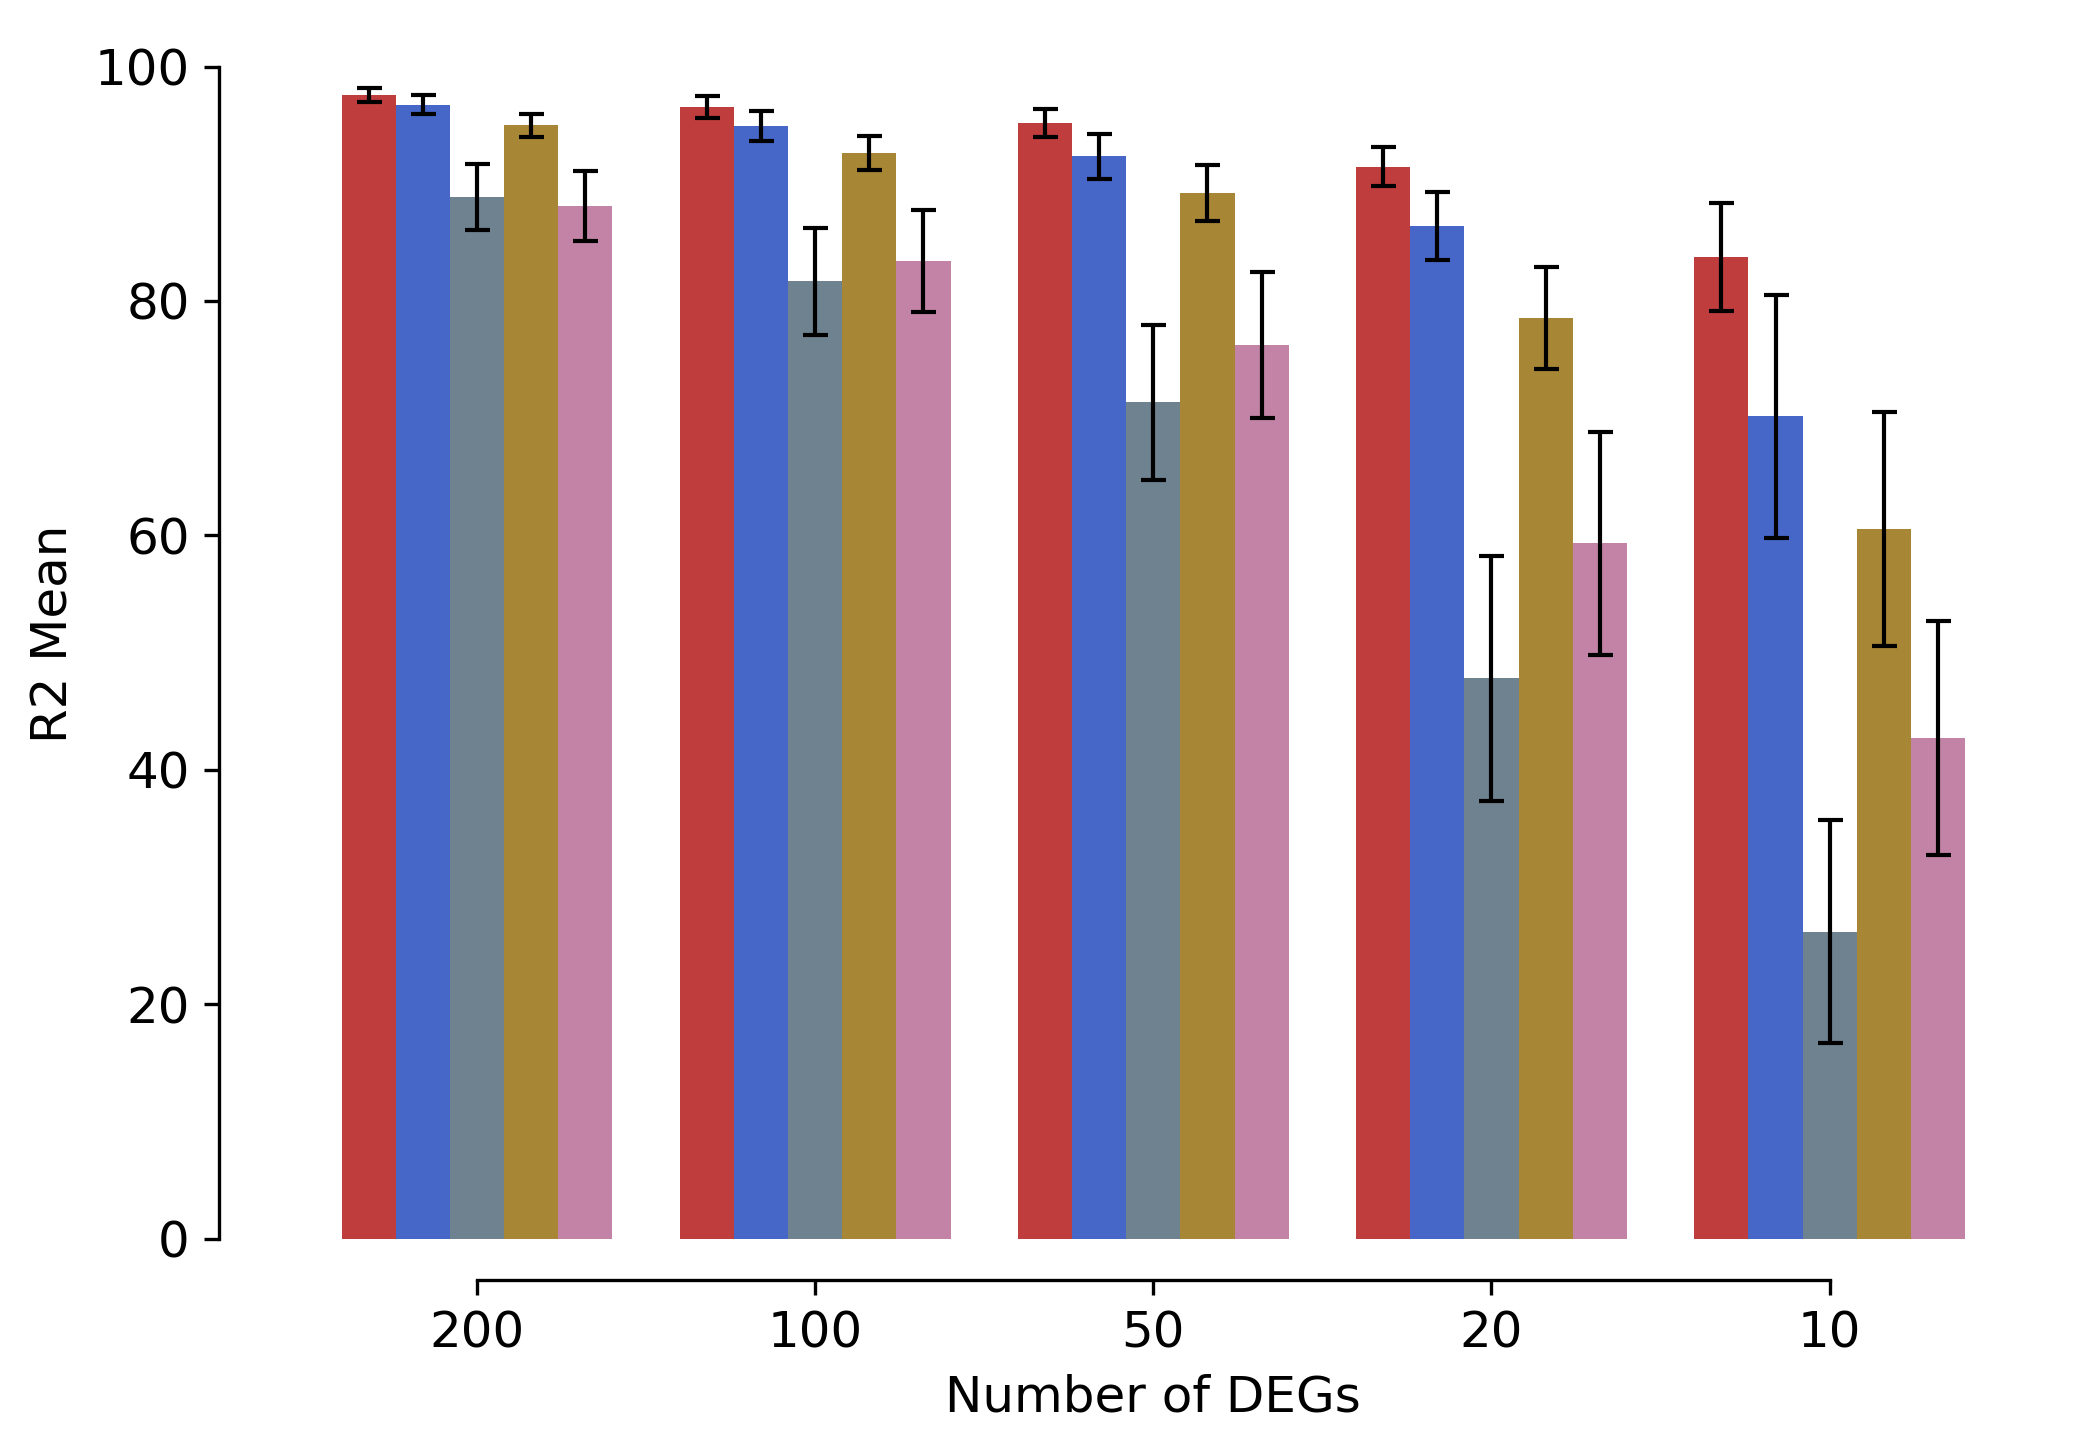

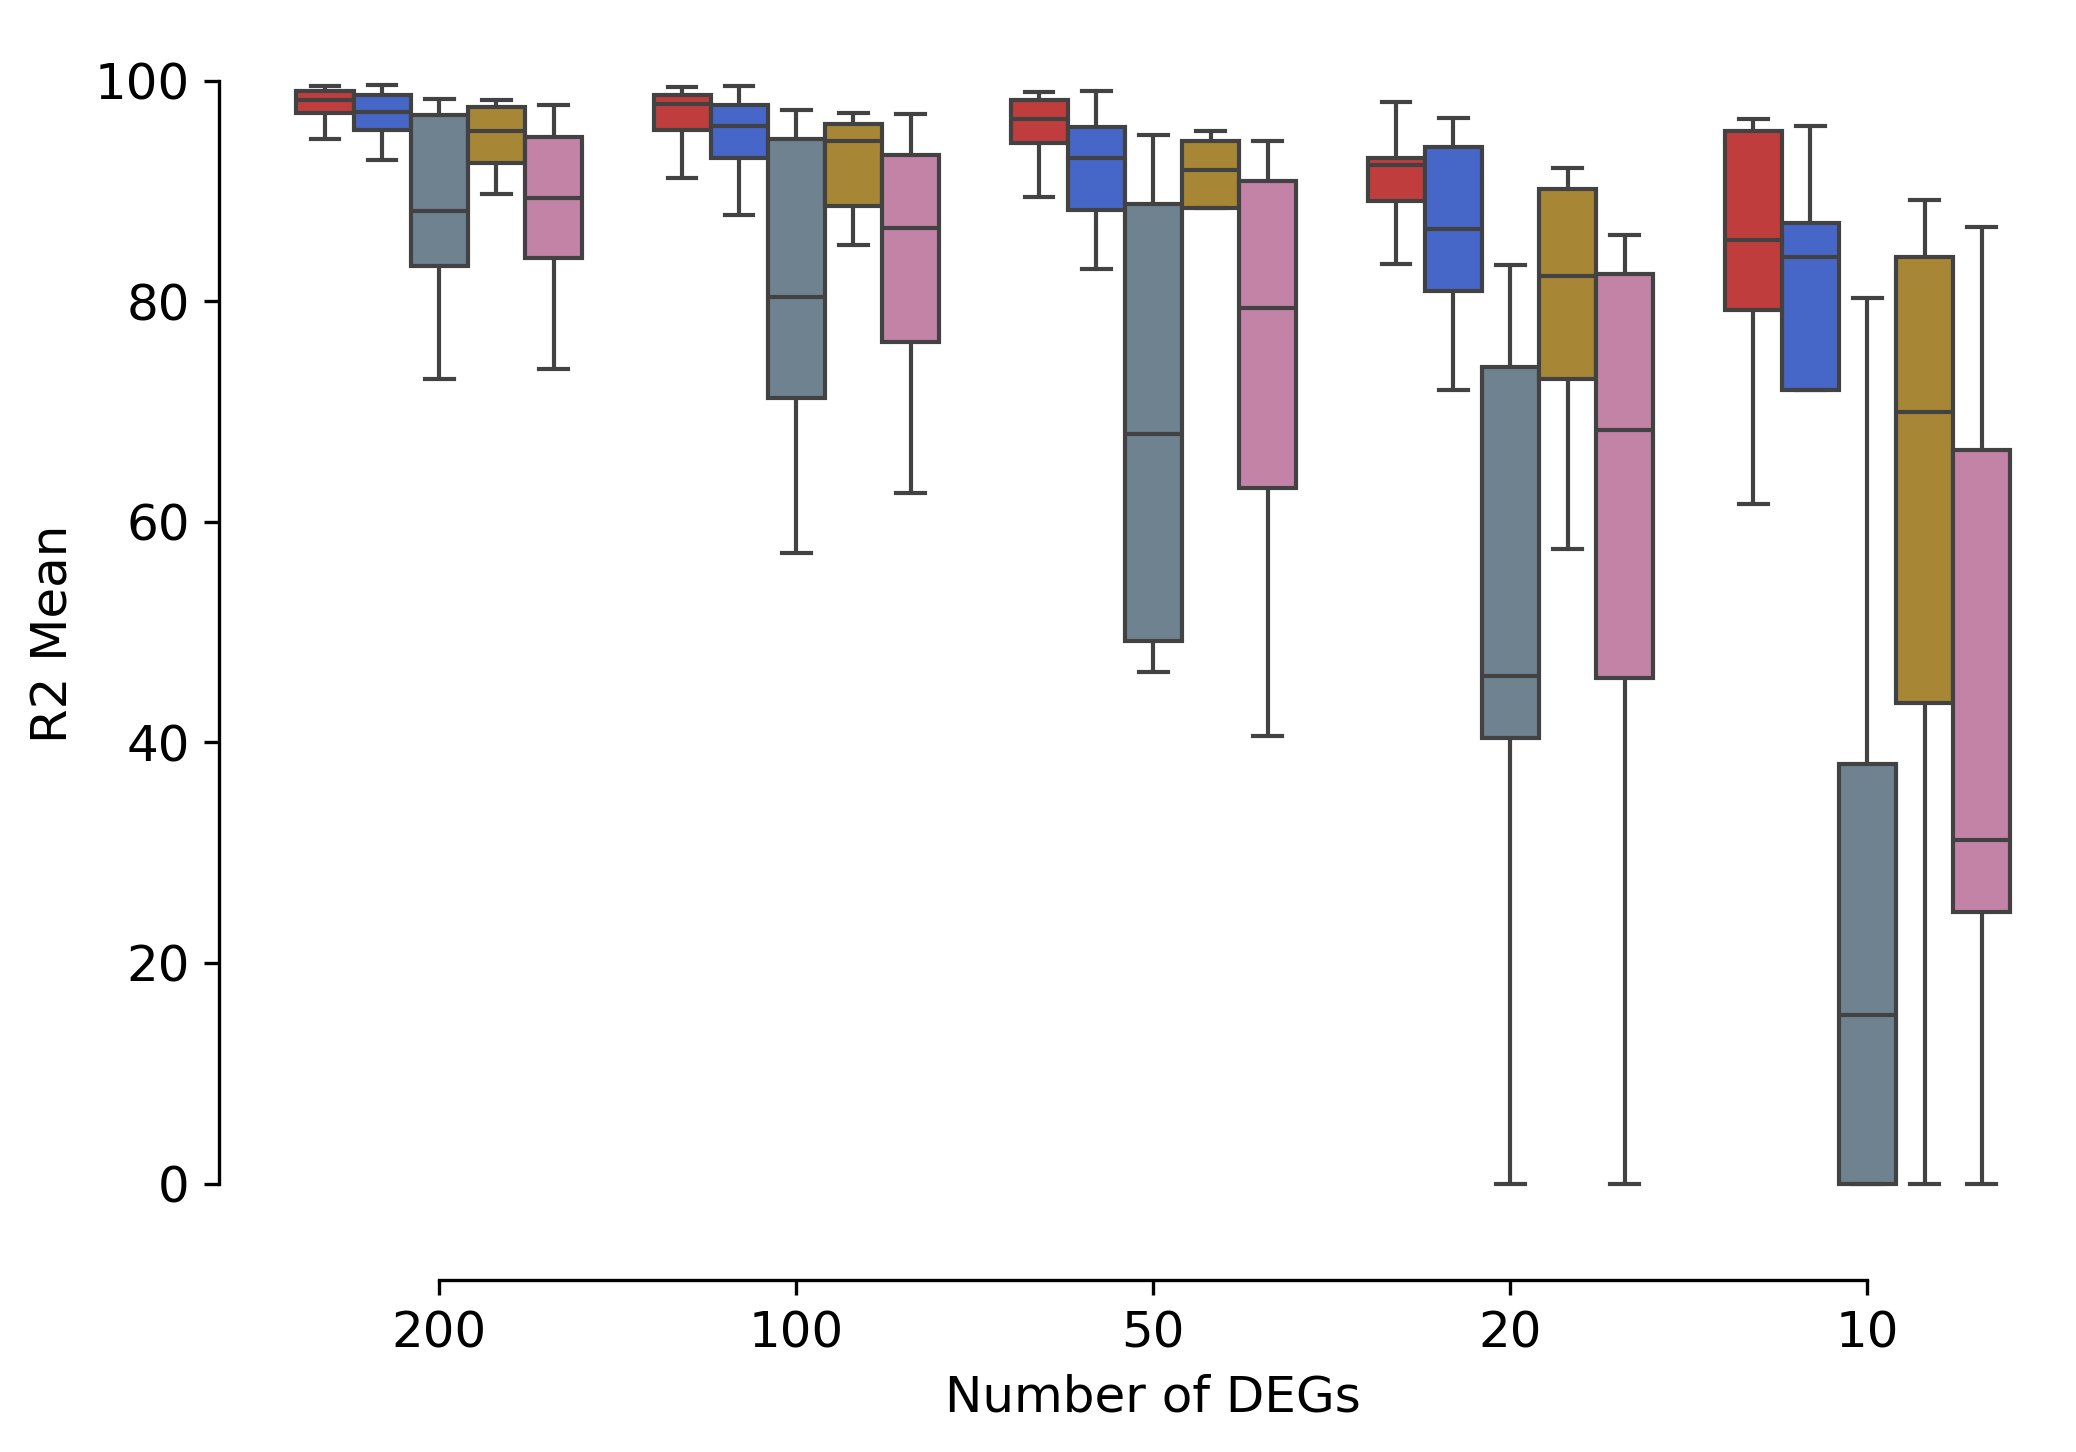

Using 9 perturbation


/home/SE/Desktop/Projects/SCDISENTANGLE/hygeia/hygeia/utils/hplots.py:208: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


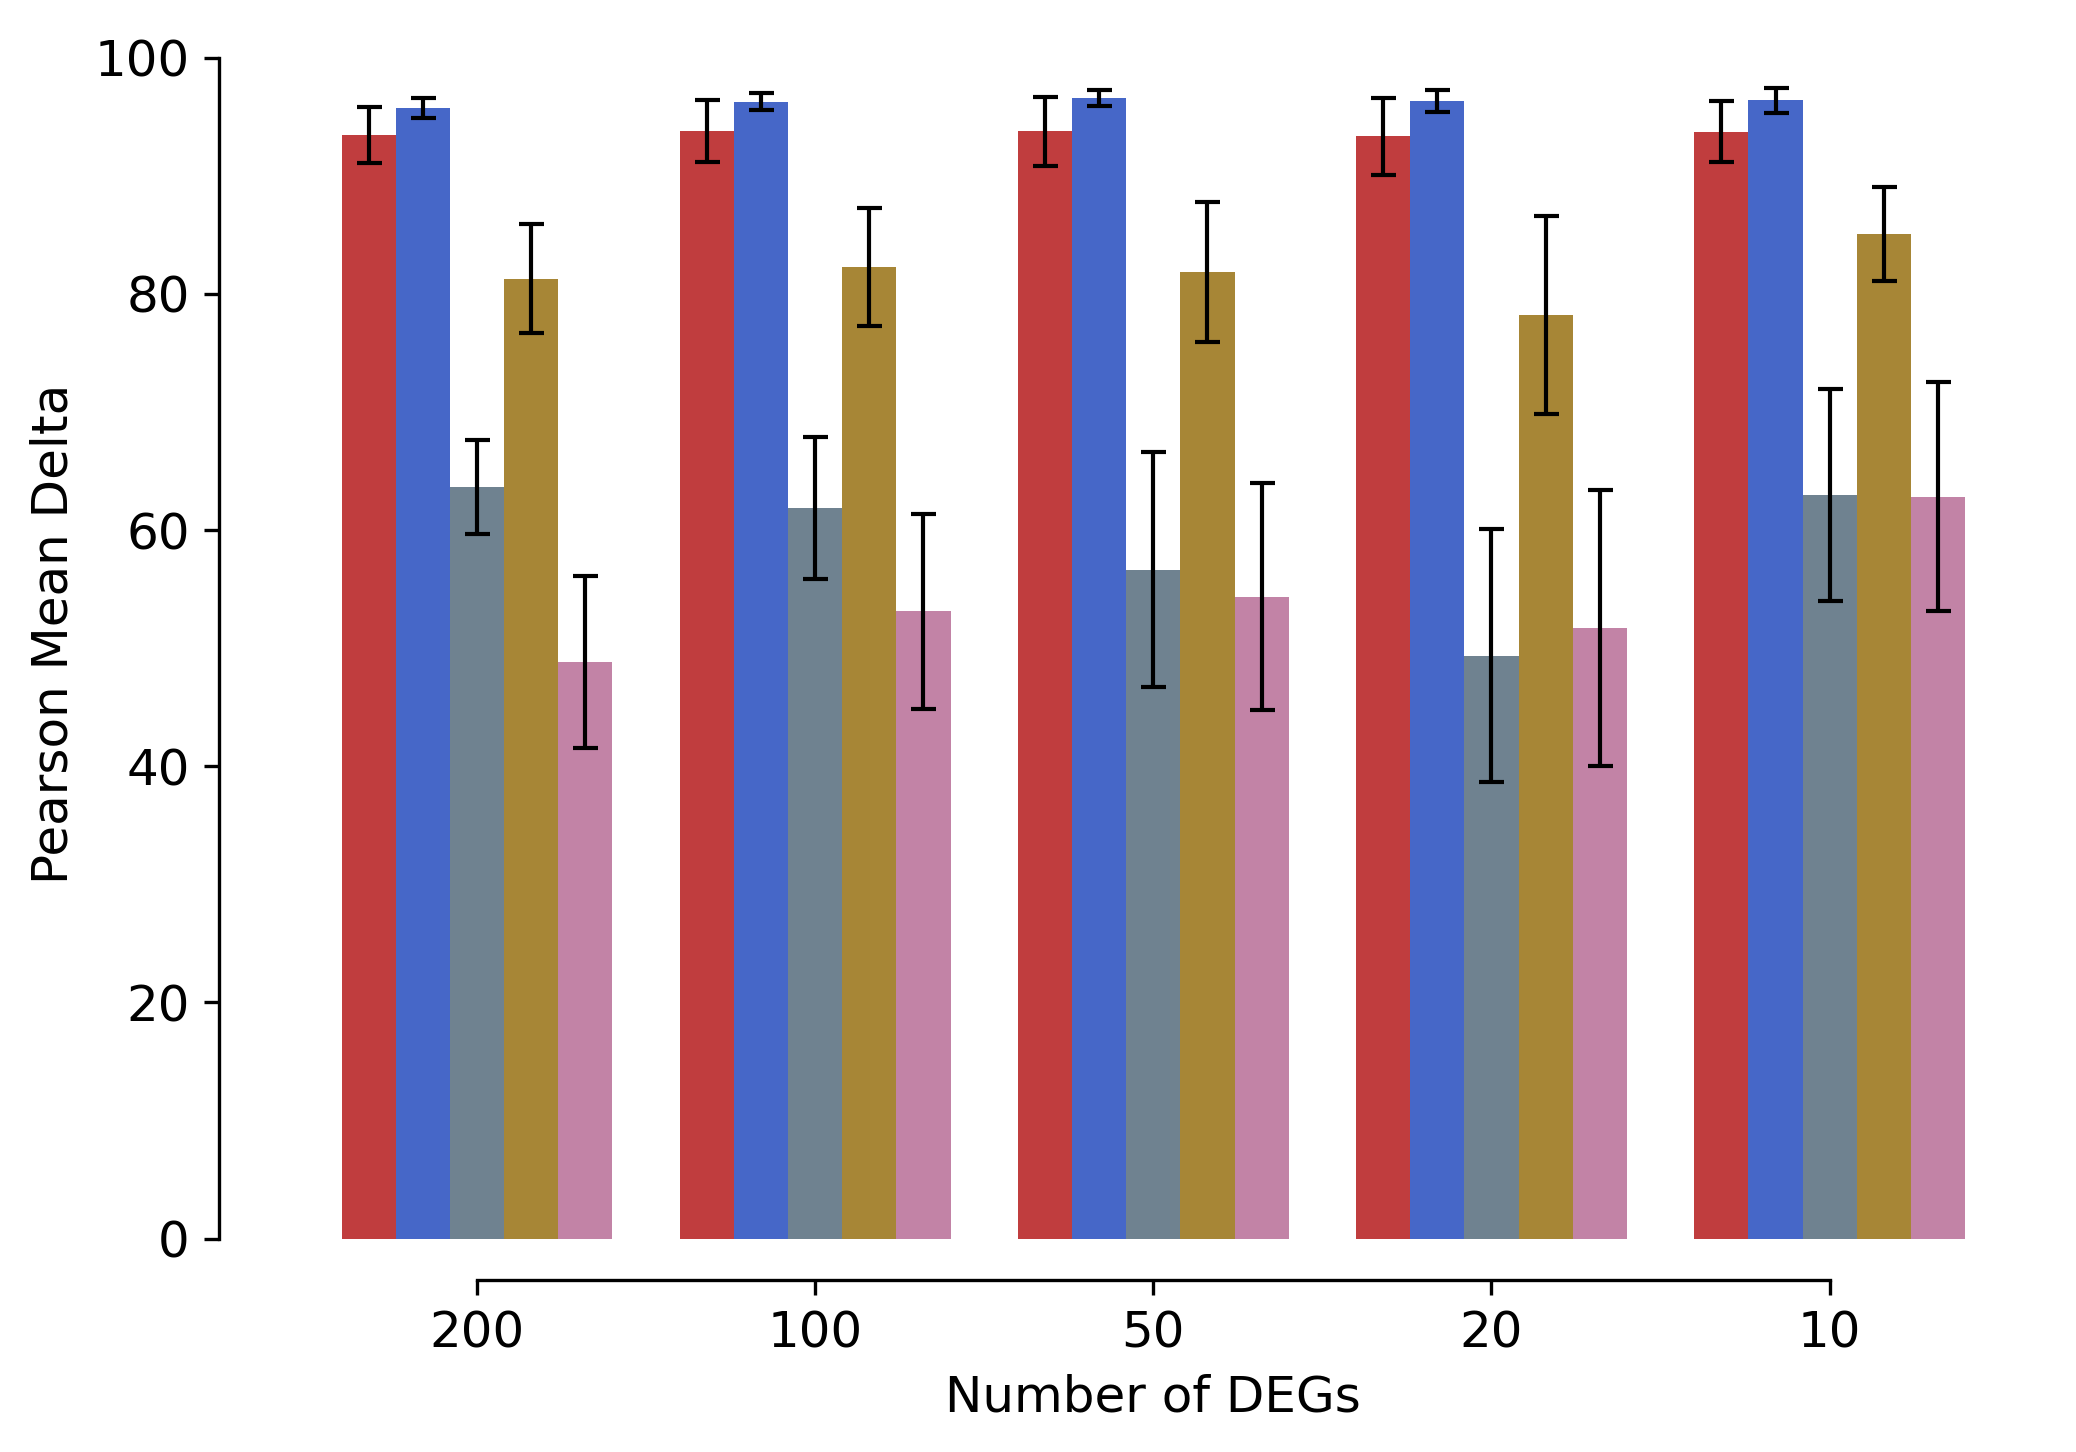

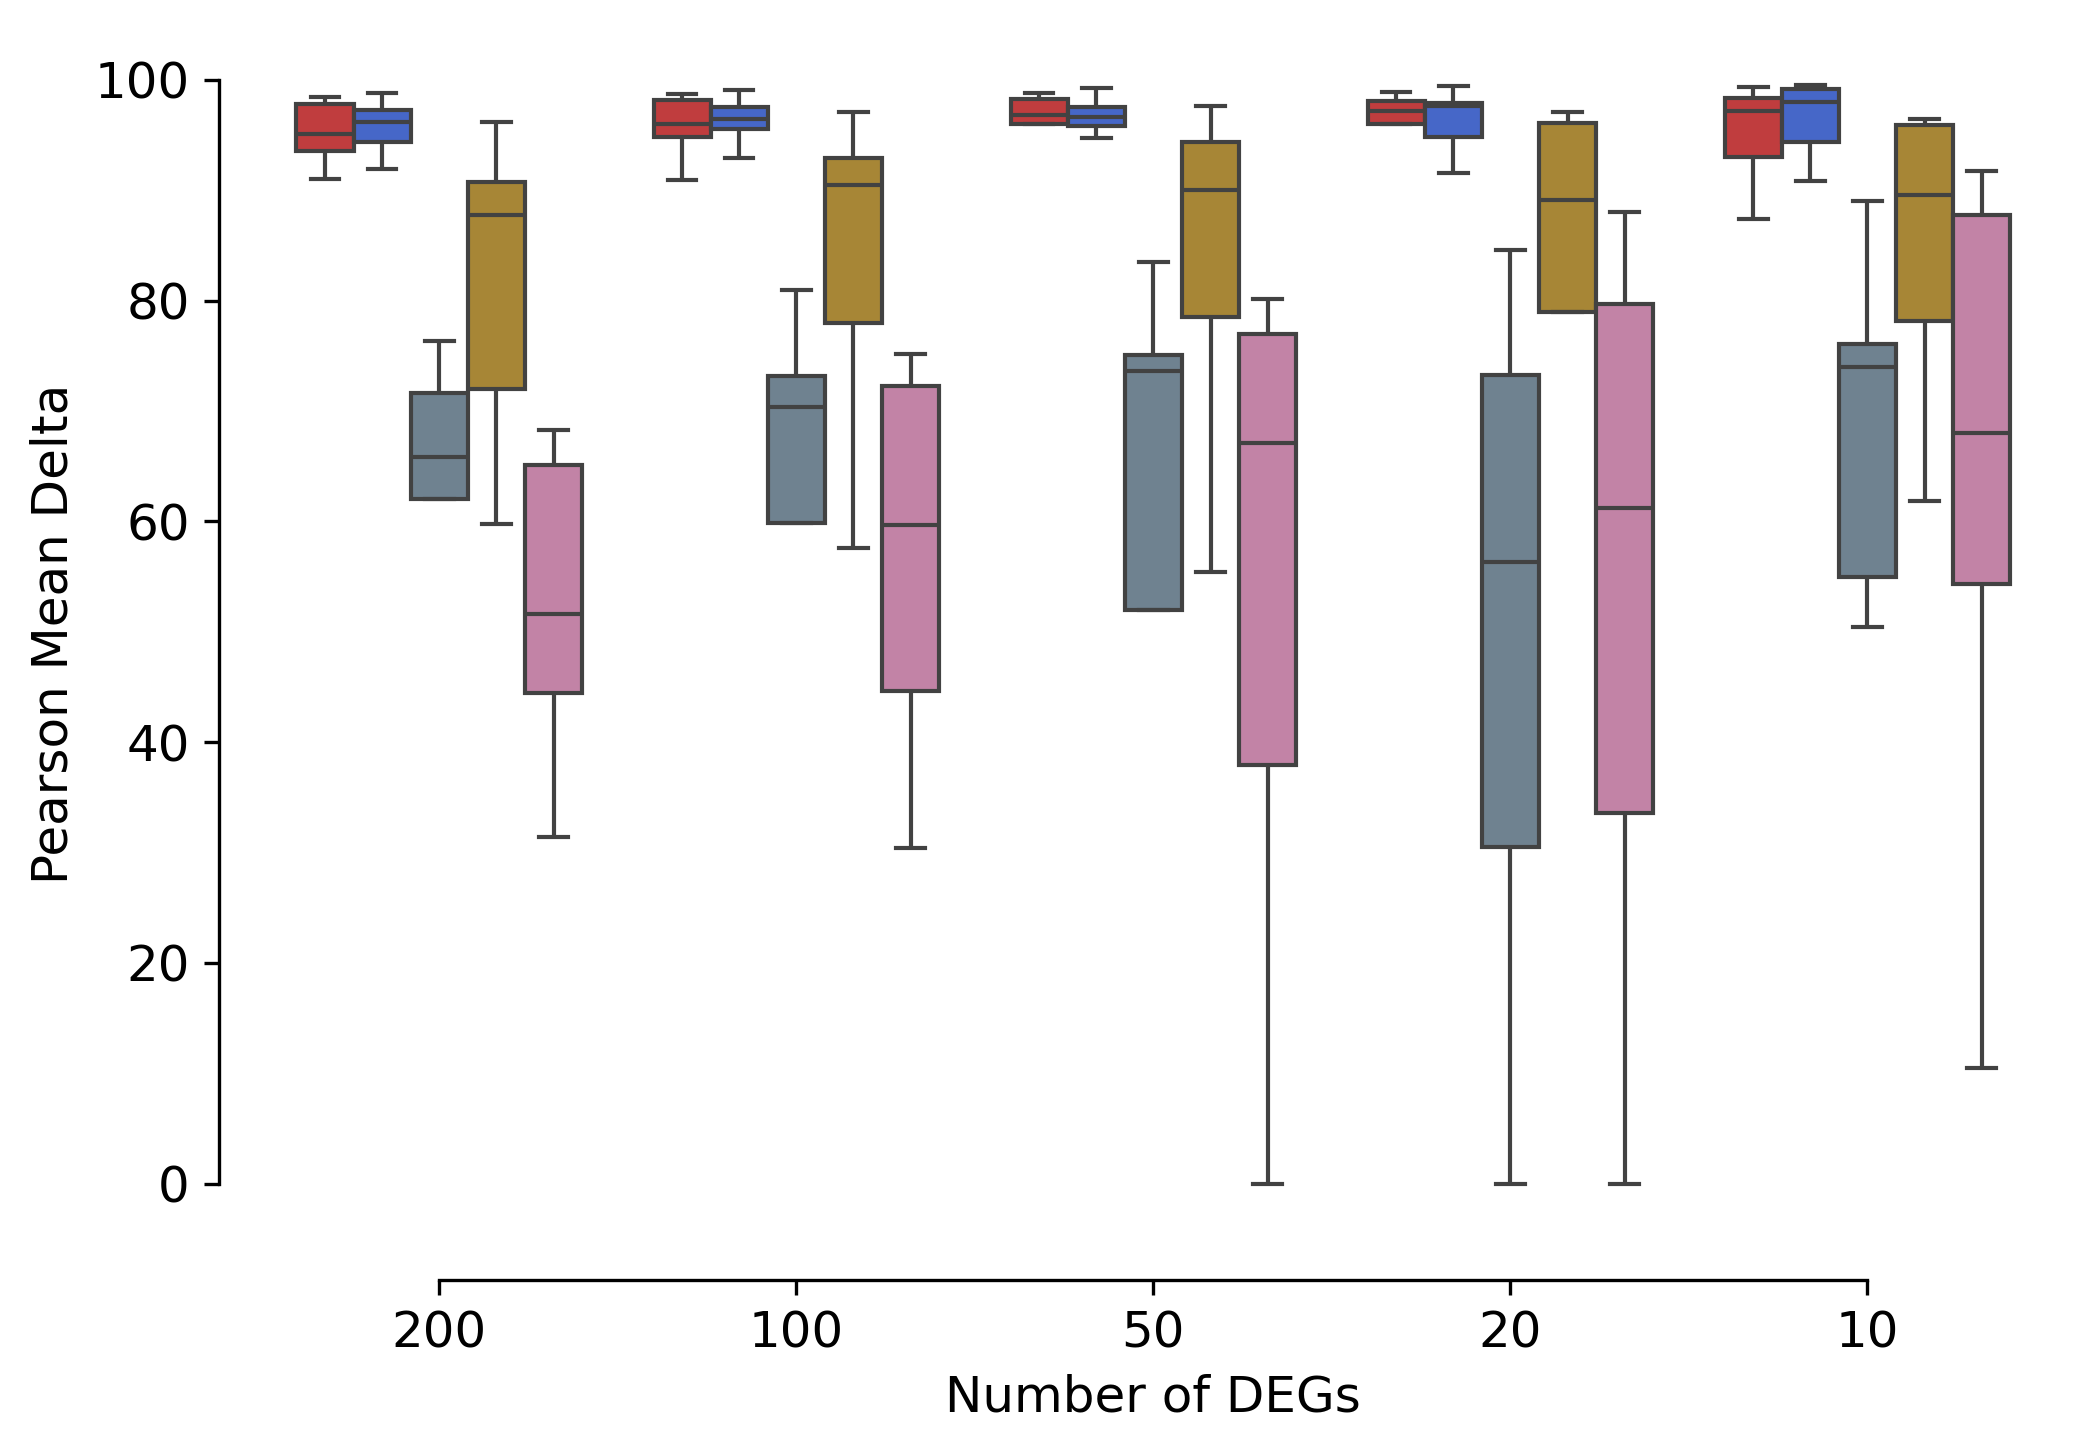

Using 9 perturbation


/home/SE/Desktop/Projects/SCDISENTANGLE/hygeia/hygeia/utils/hplots.py:208: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


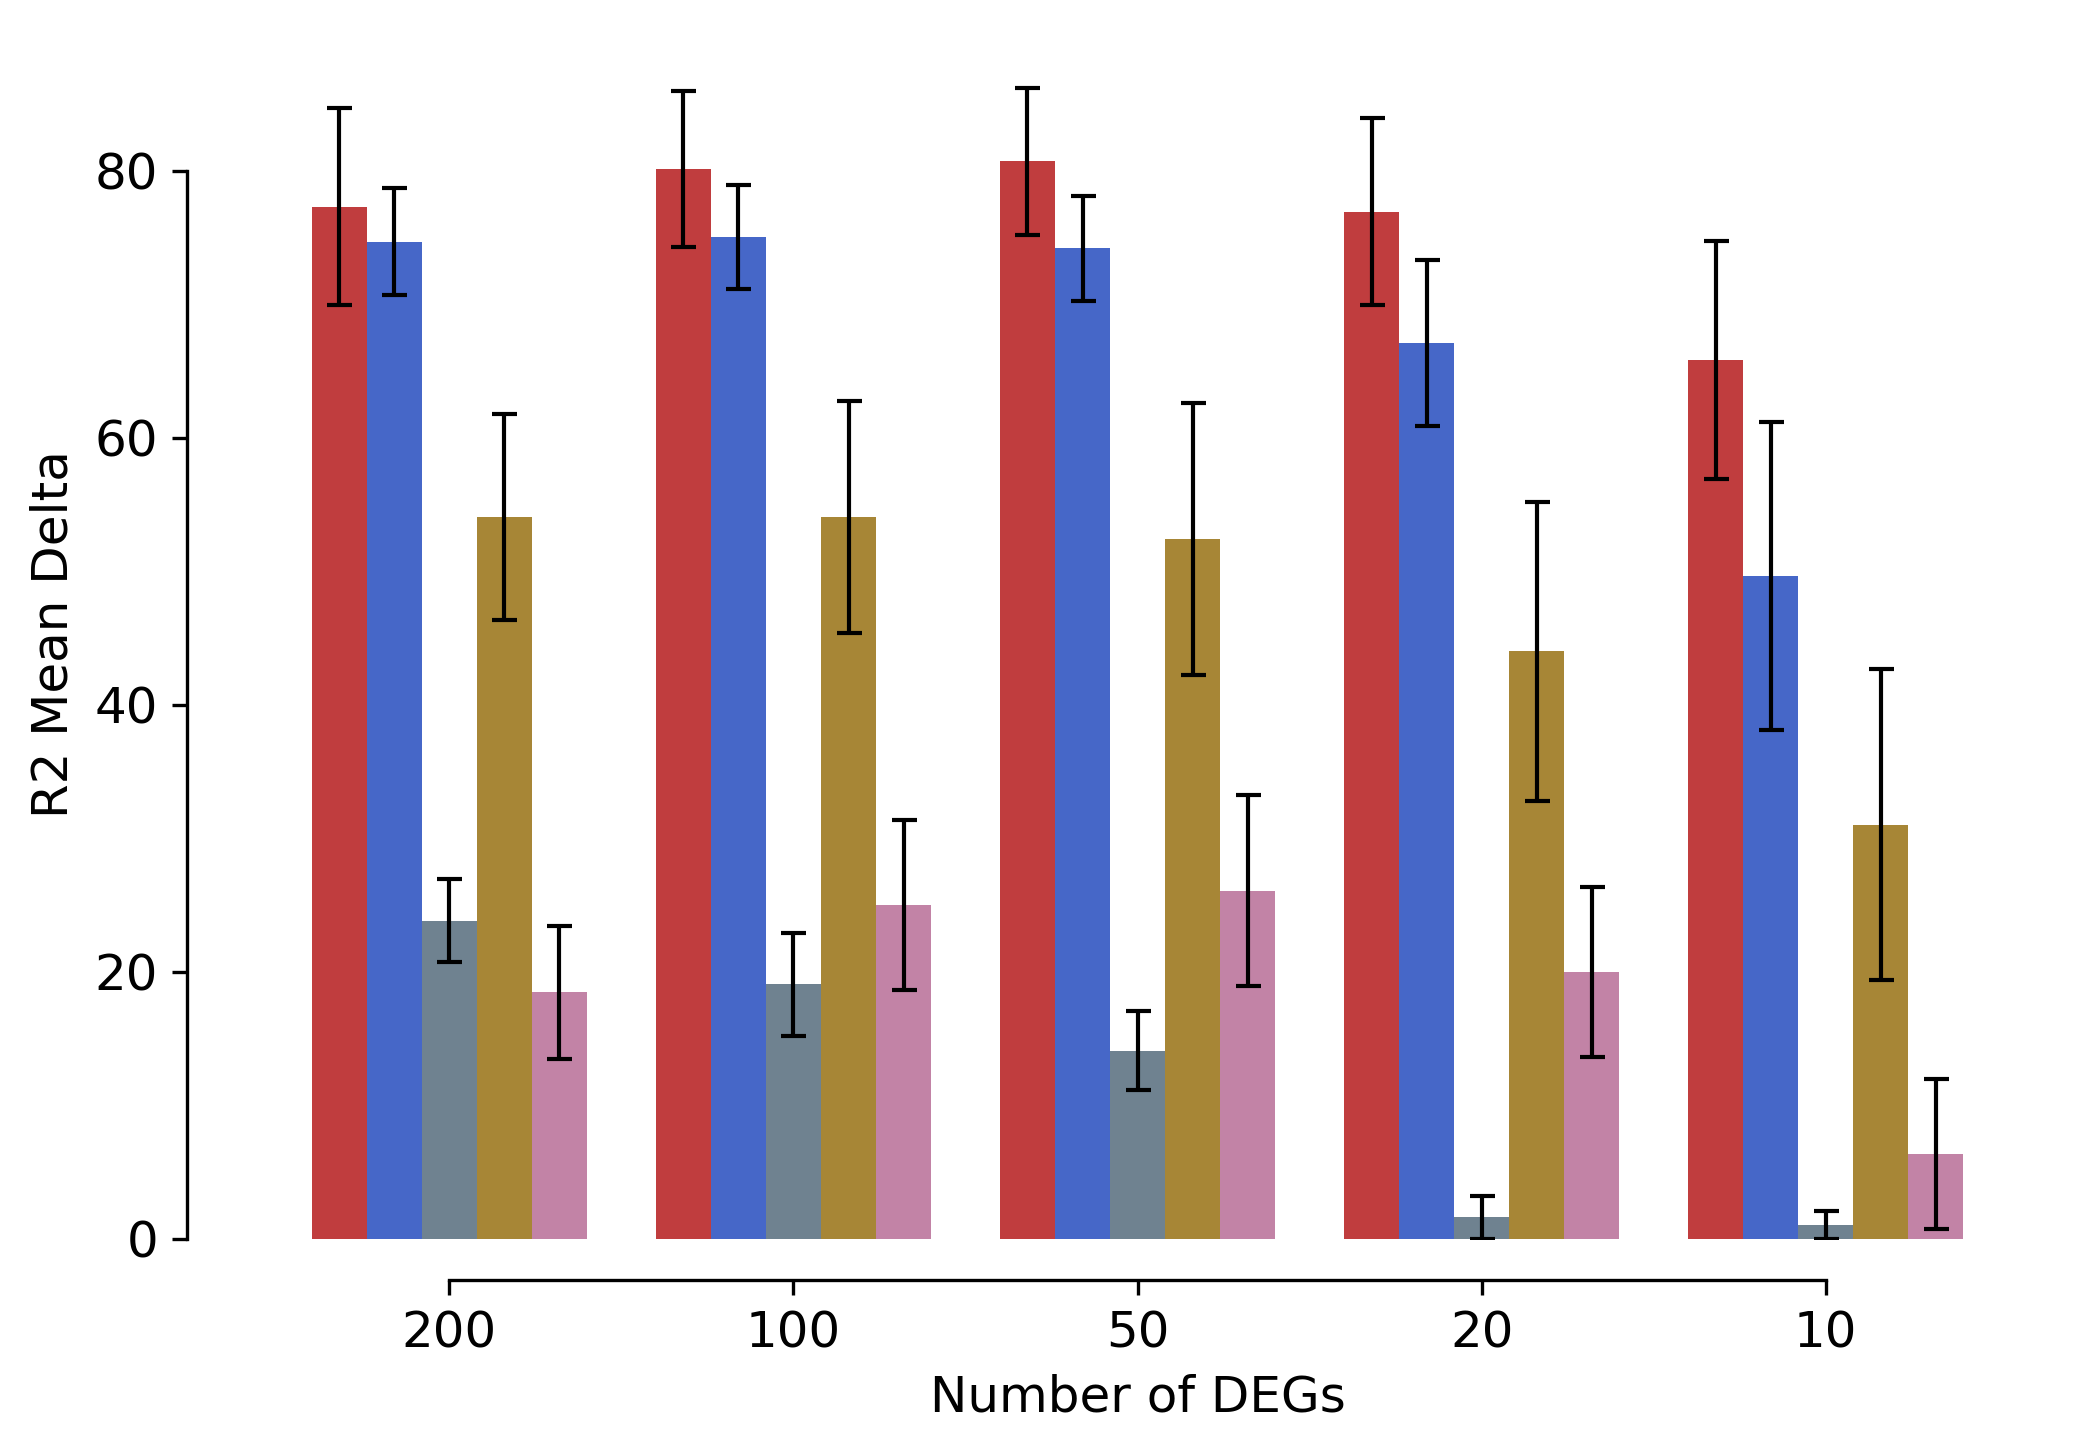

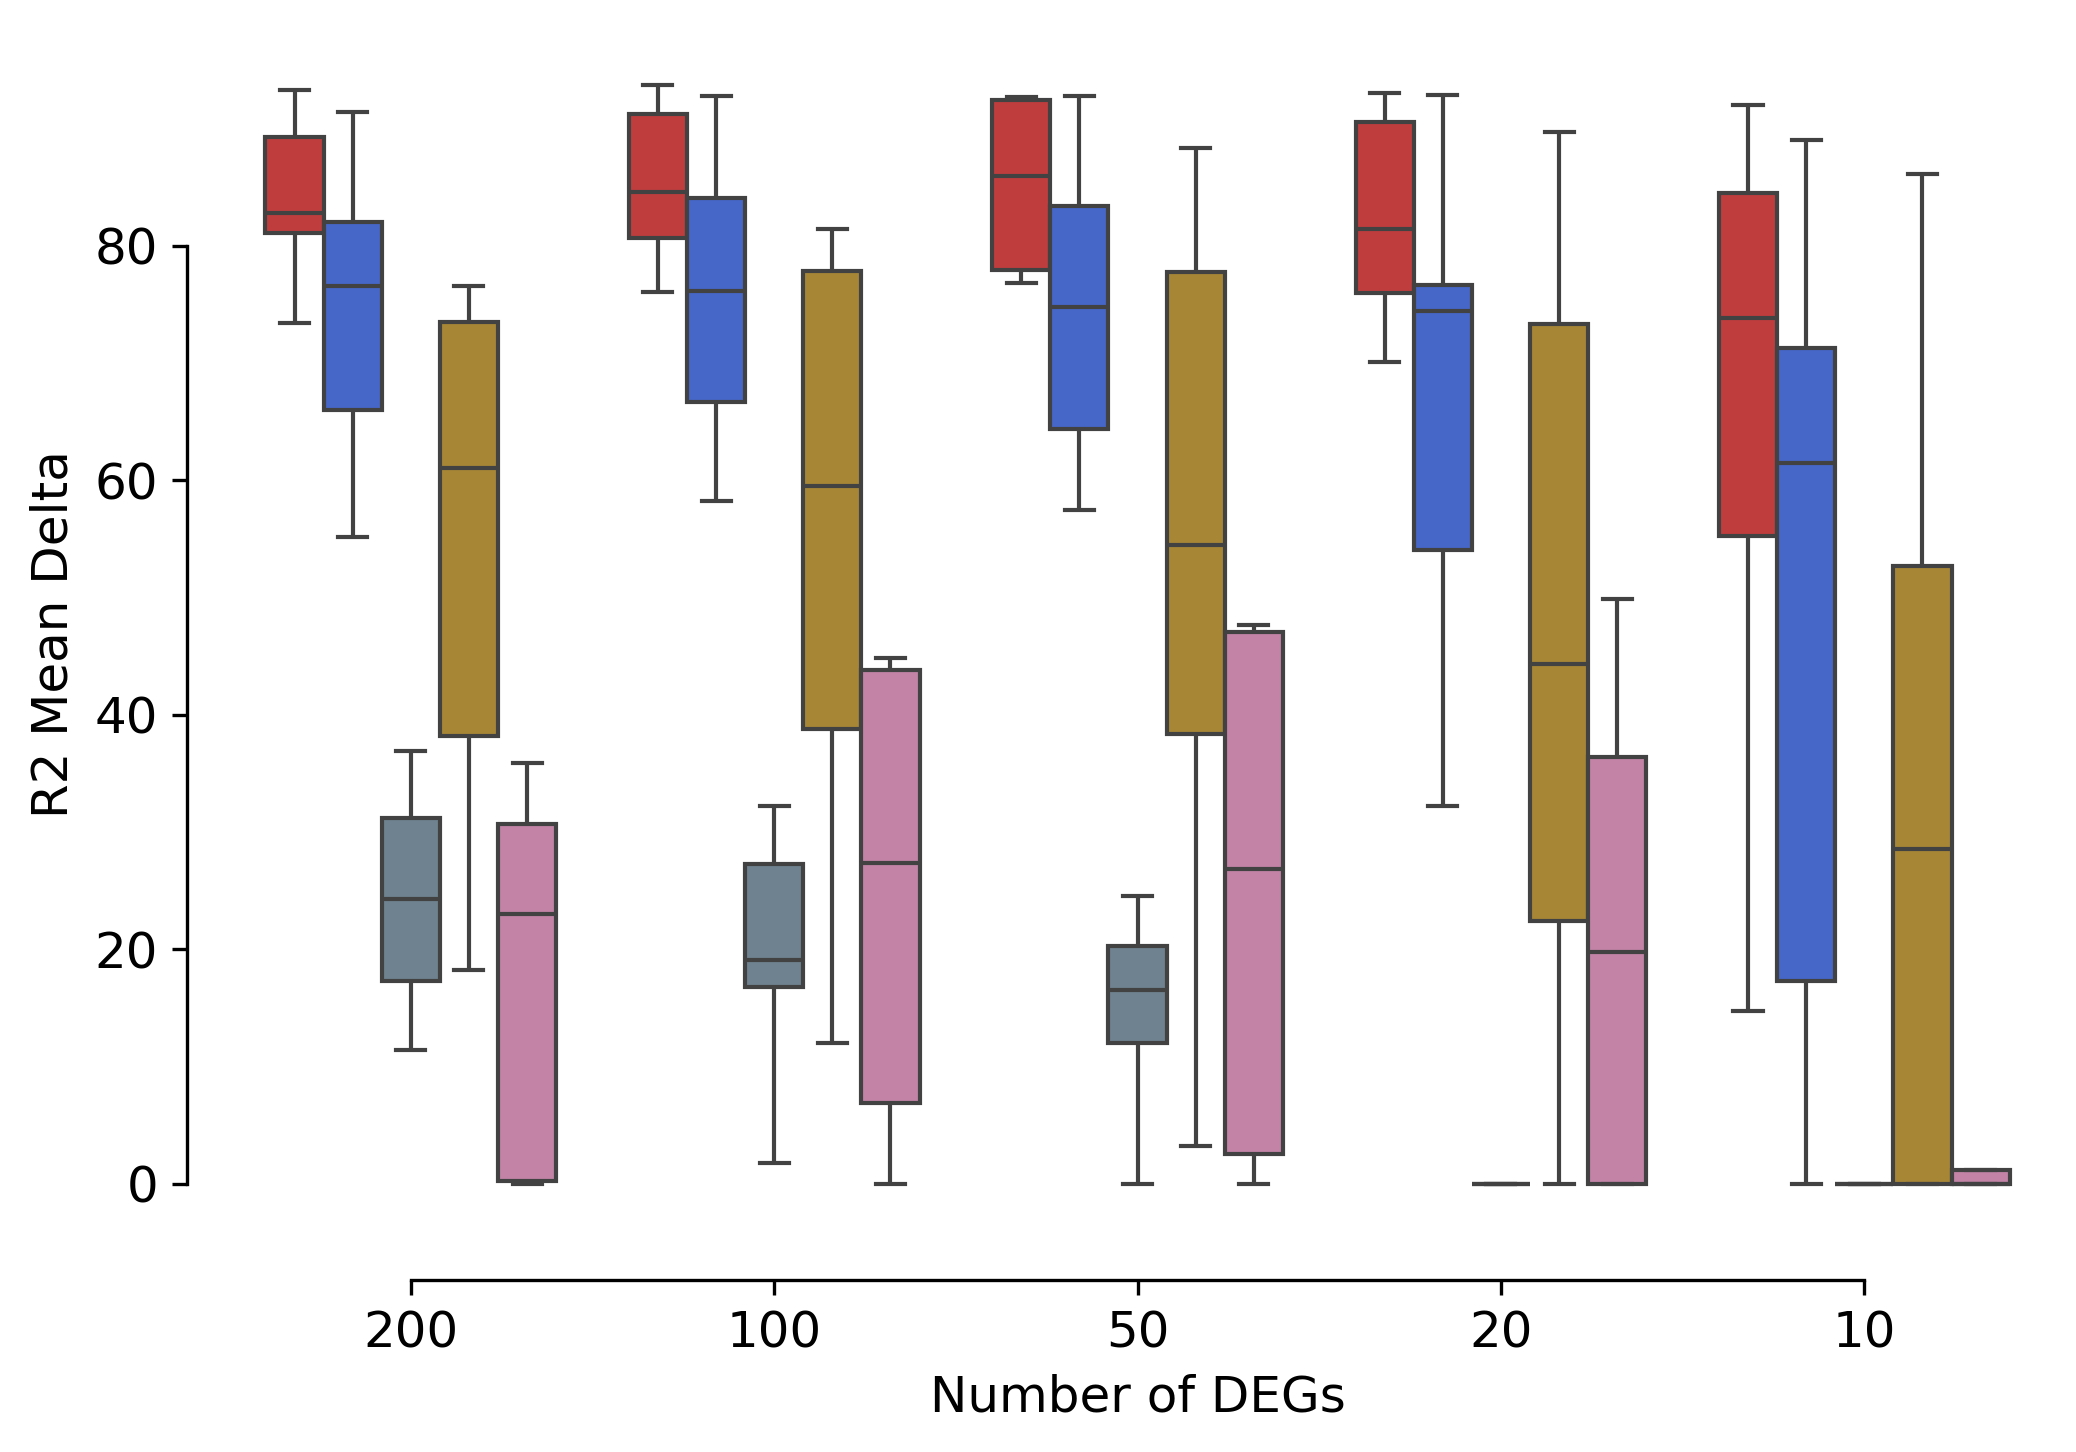

Using 9 perturbation


/home/SE/Desktop/Projects/SCDISENTANGLE/hygeia/hygeia/utils/hplots.py:208: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


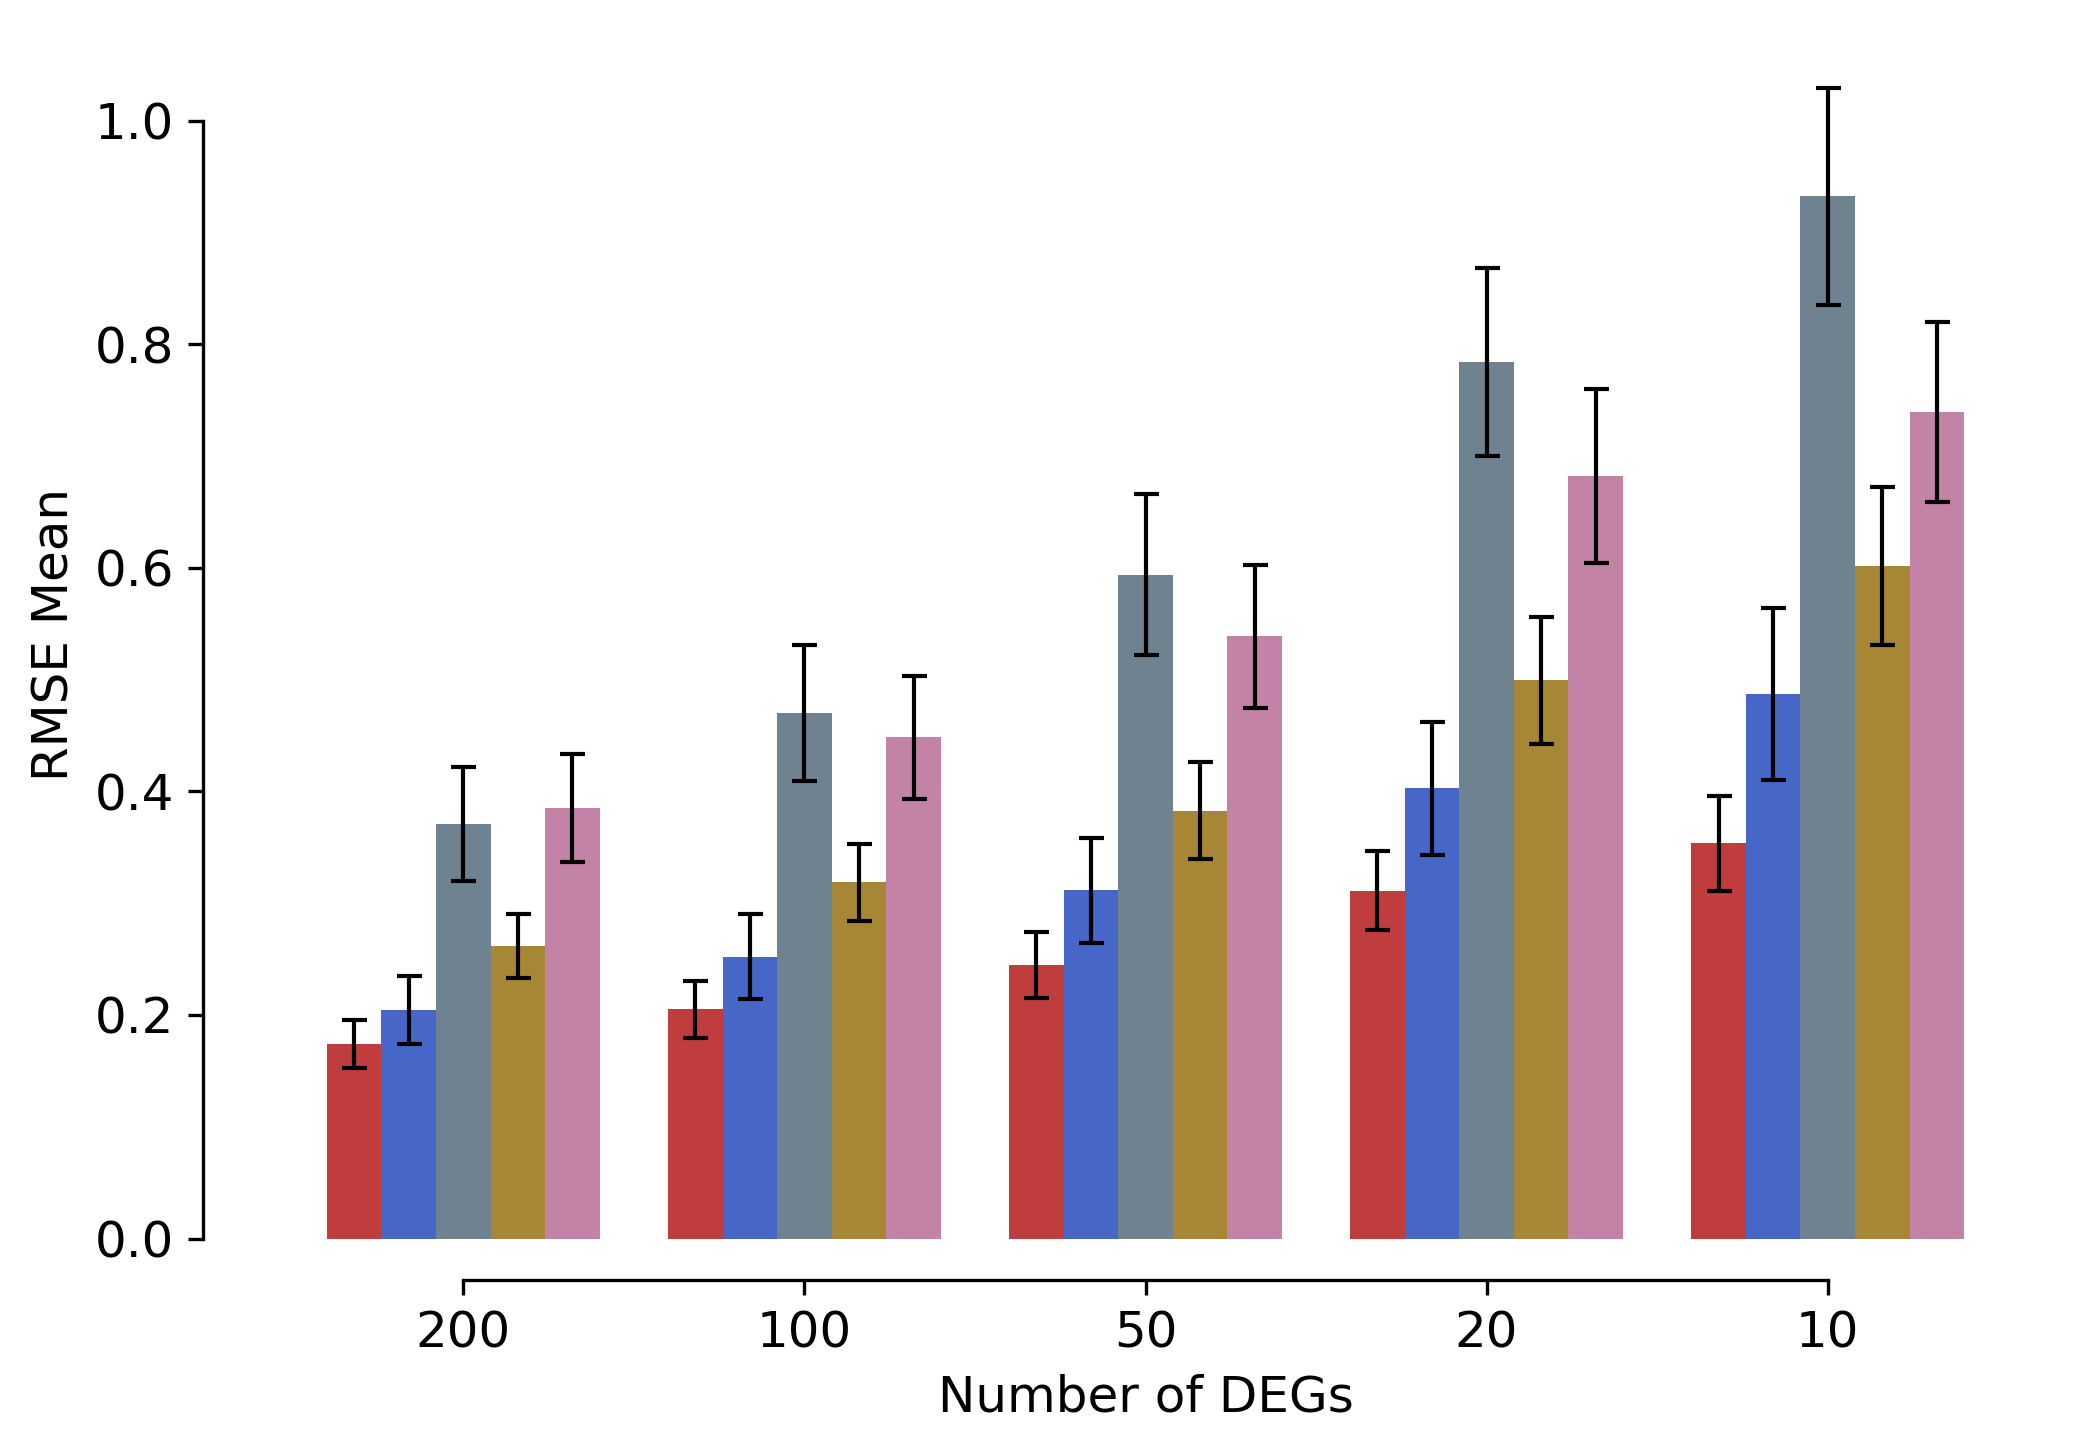

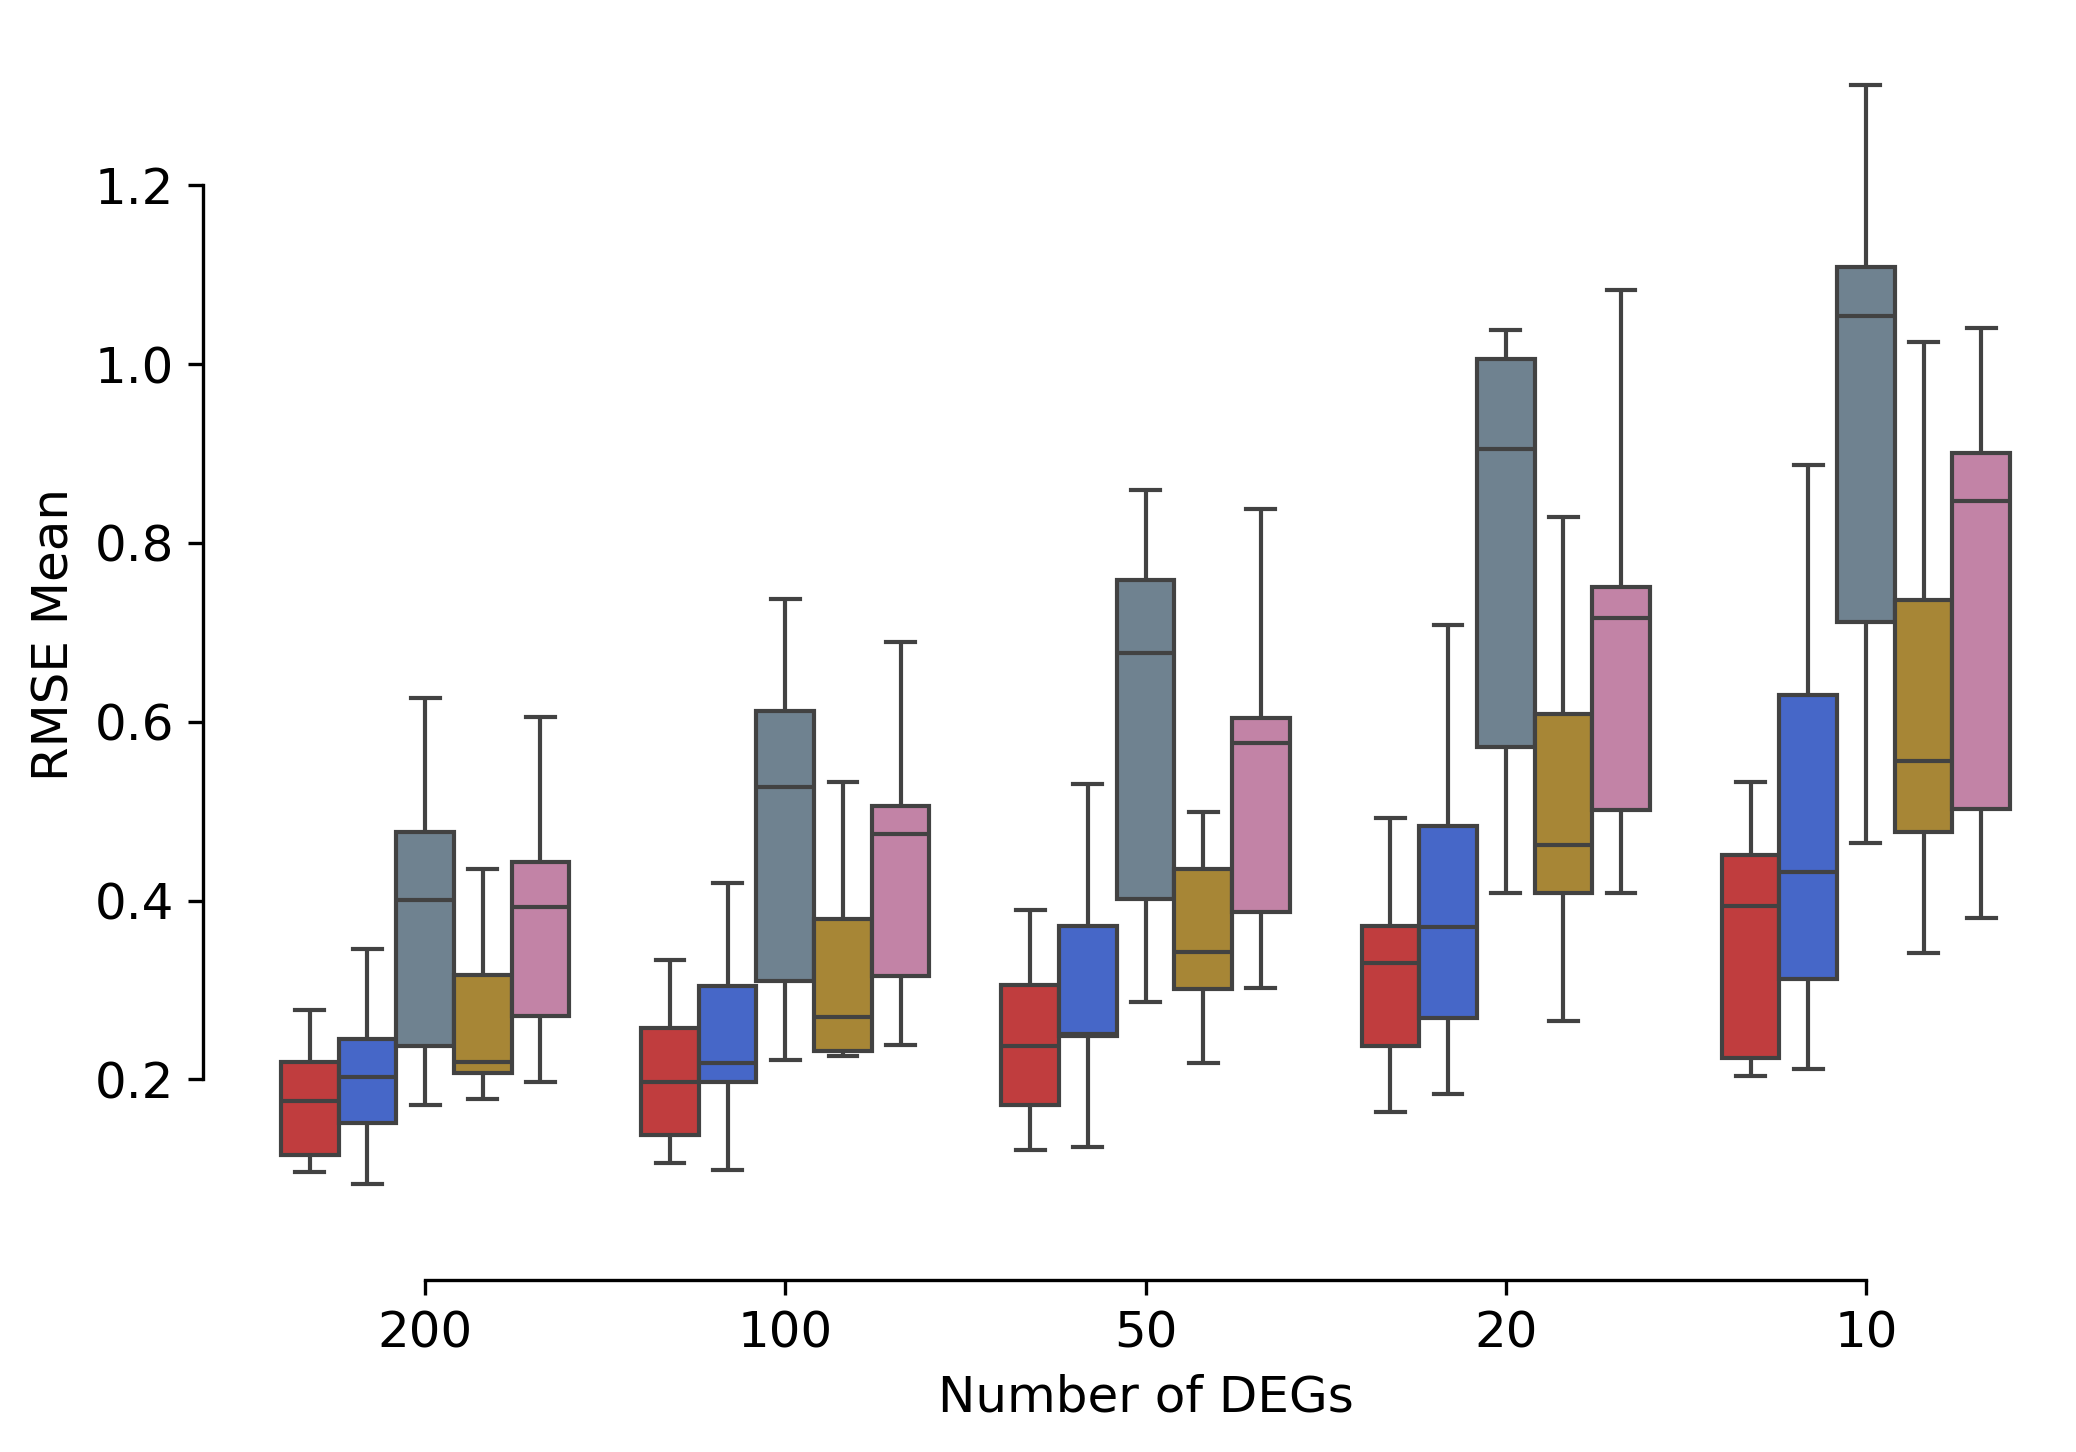

Using 9 perturbation


/home/SE/Desktop/Projects/SCDISENTANGLE/hygeia/hygeia/utils/hplots.py:208: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


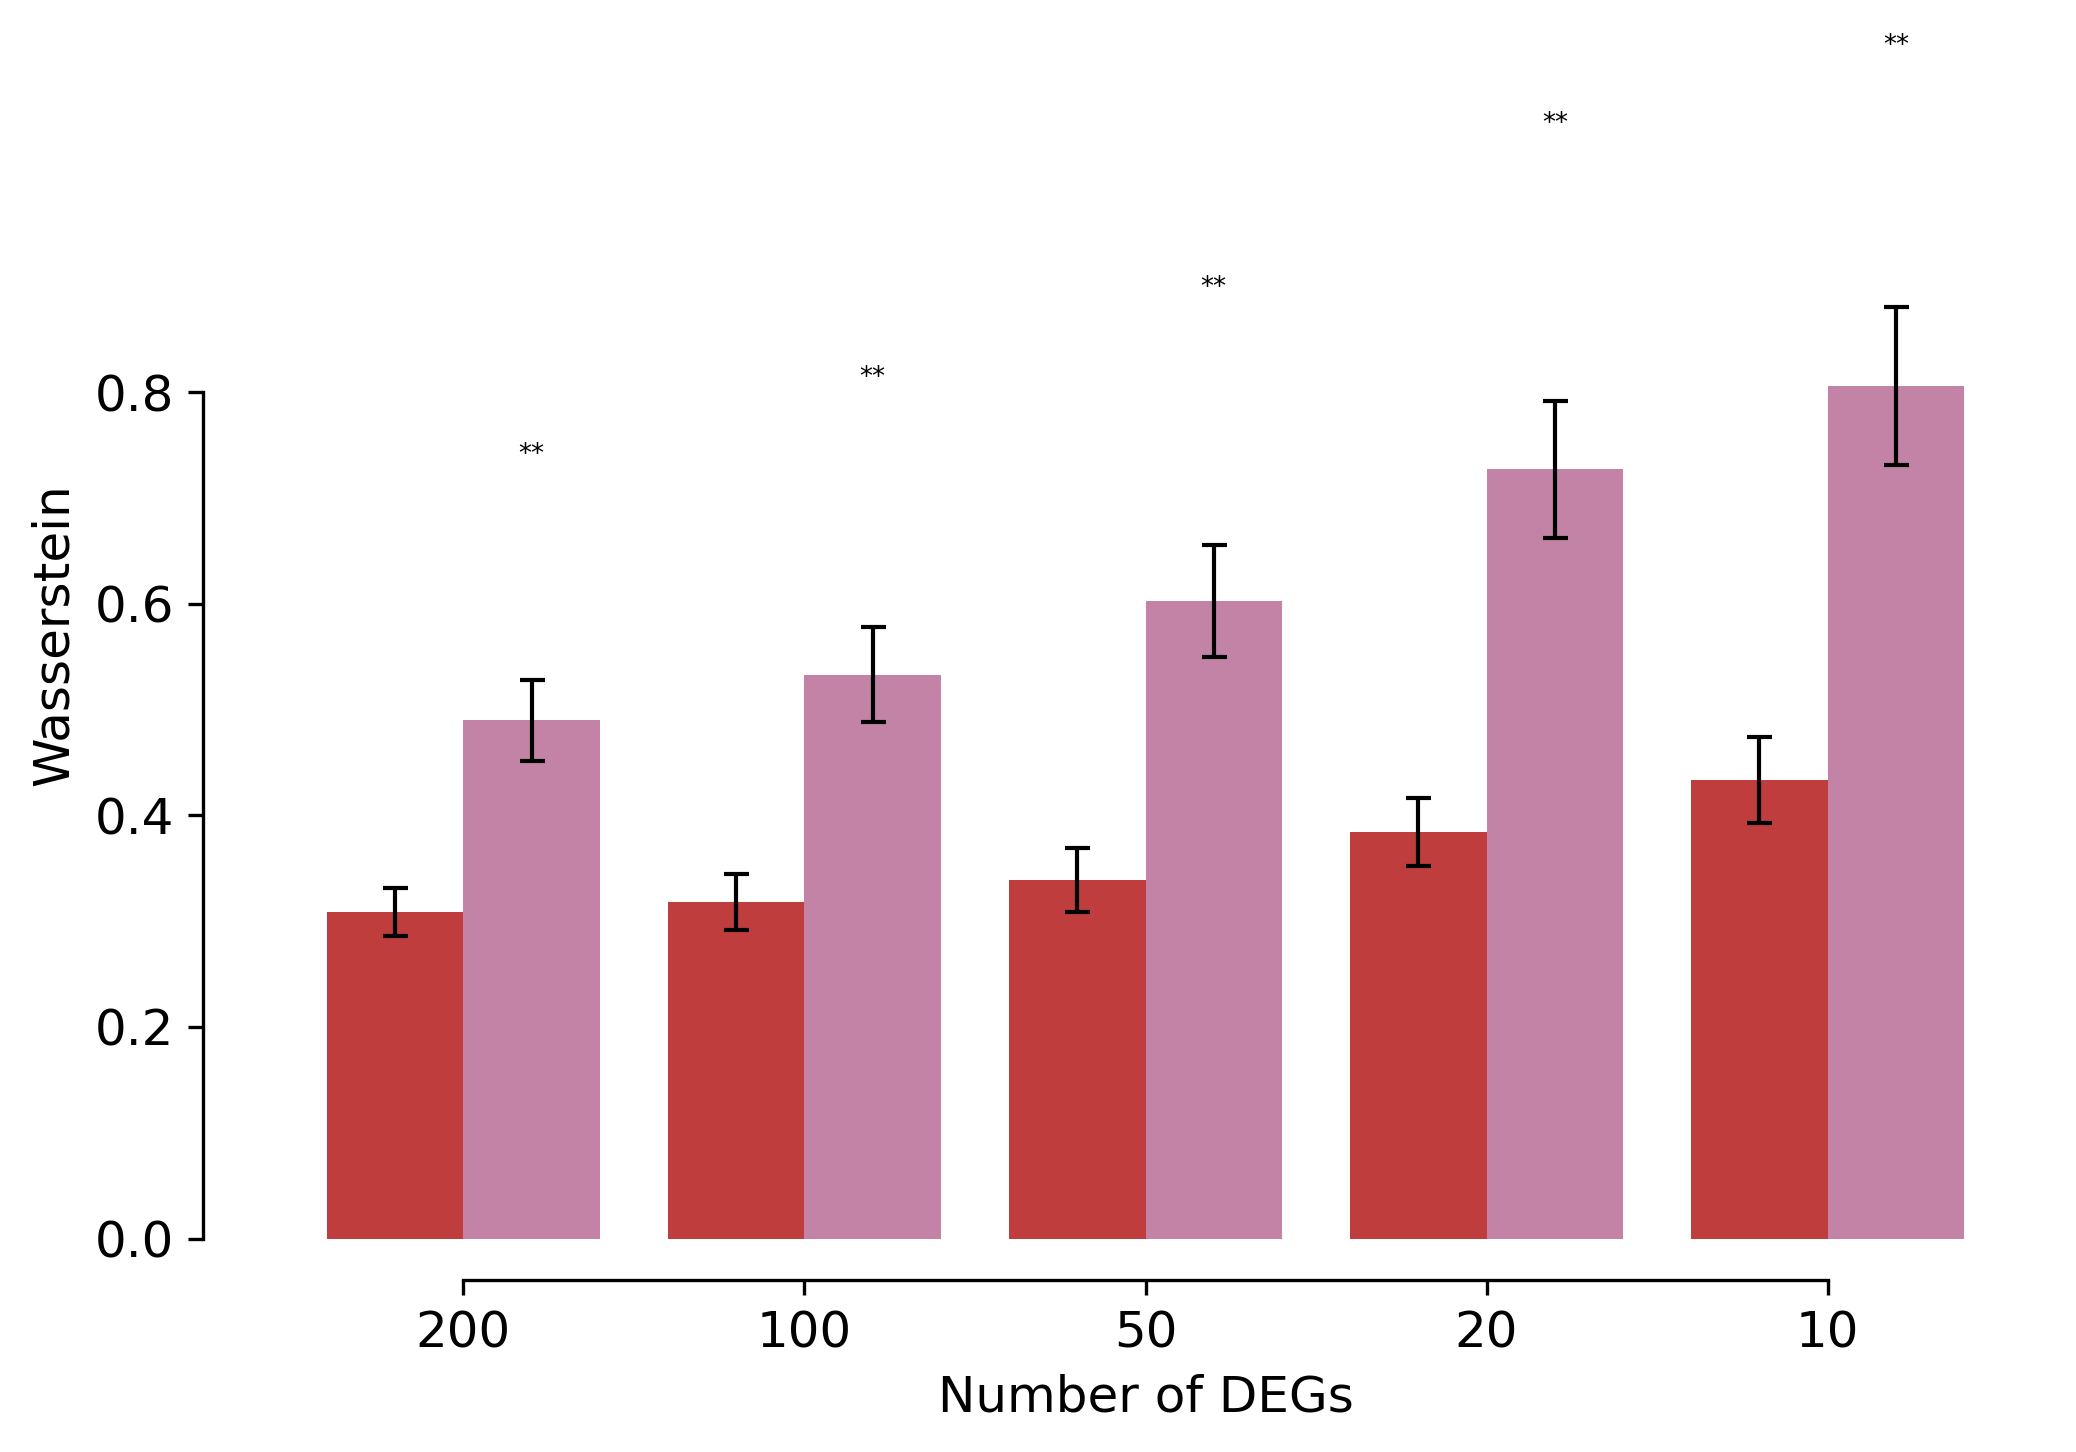

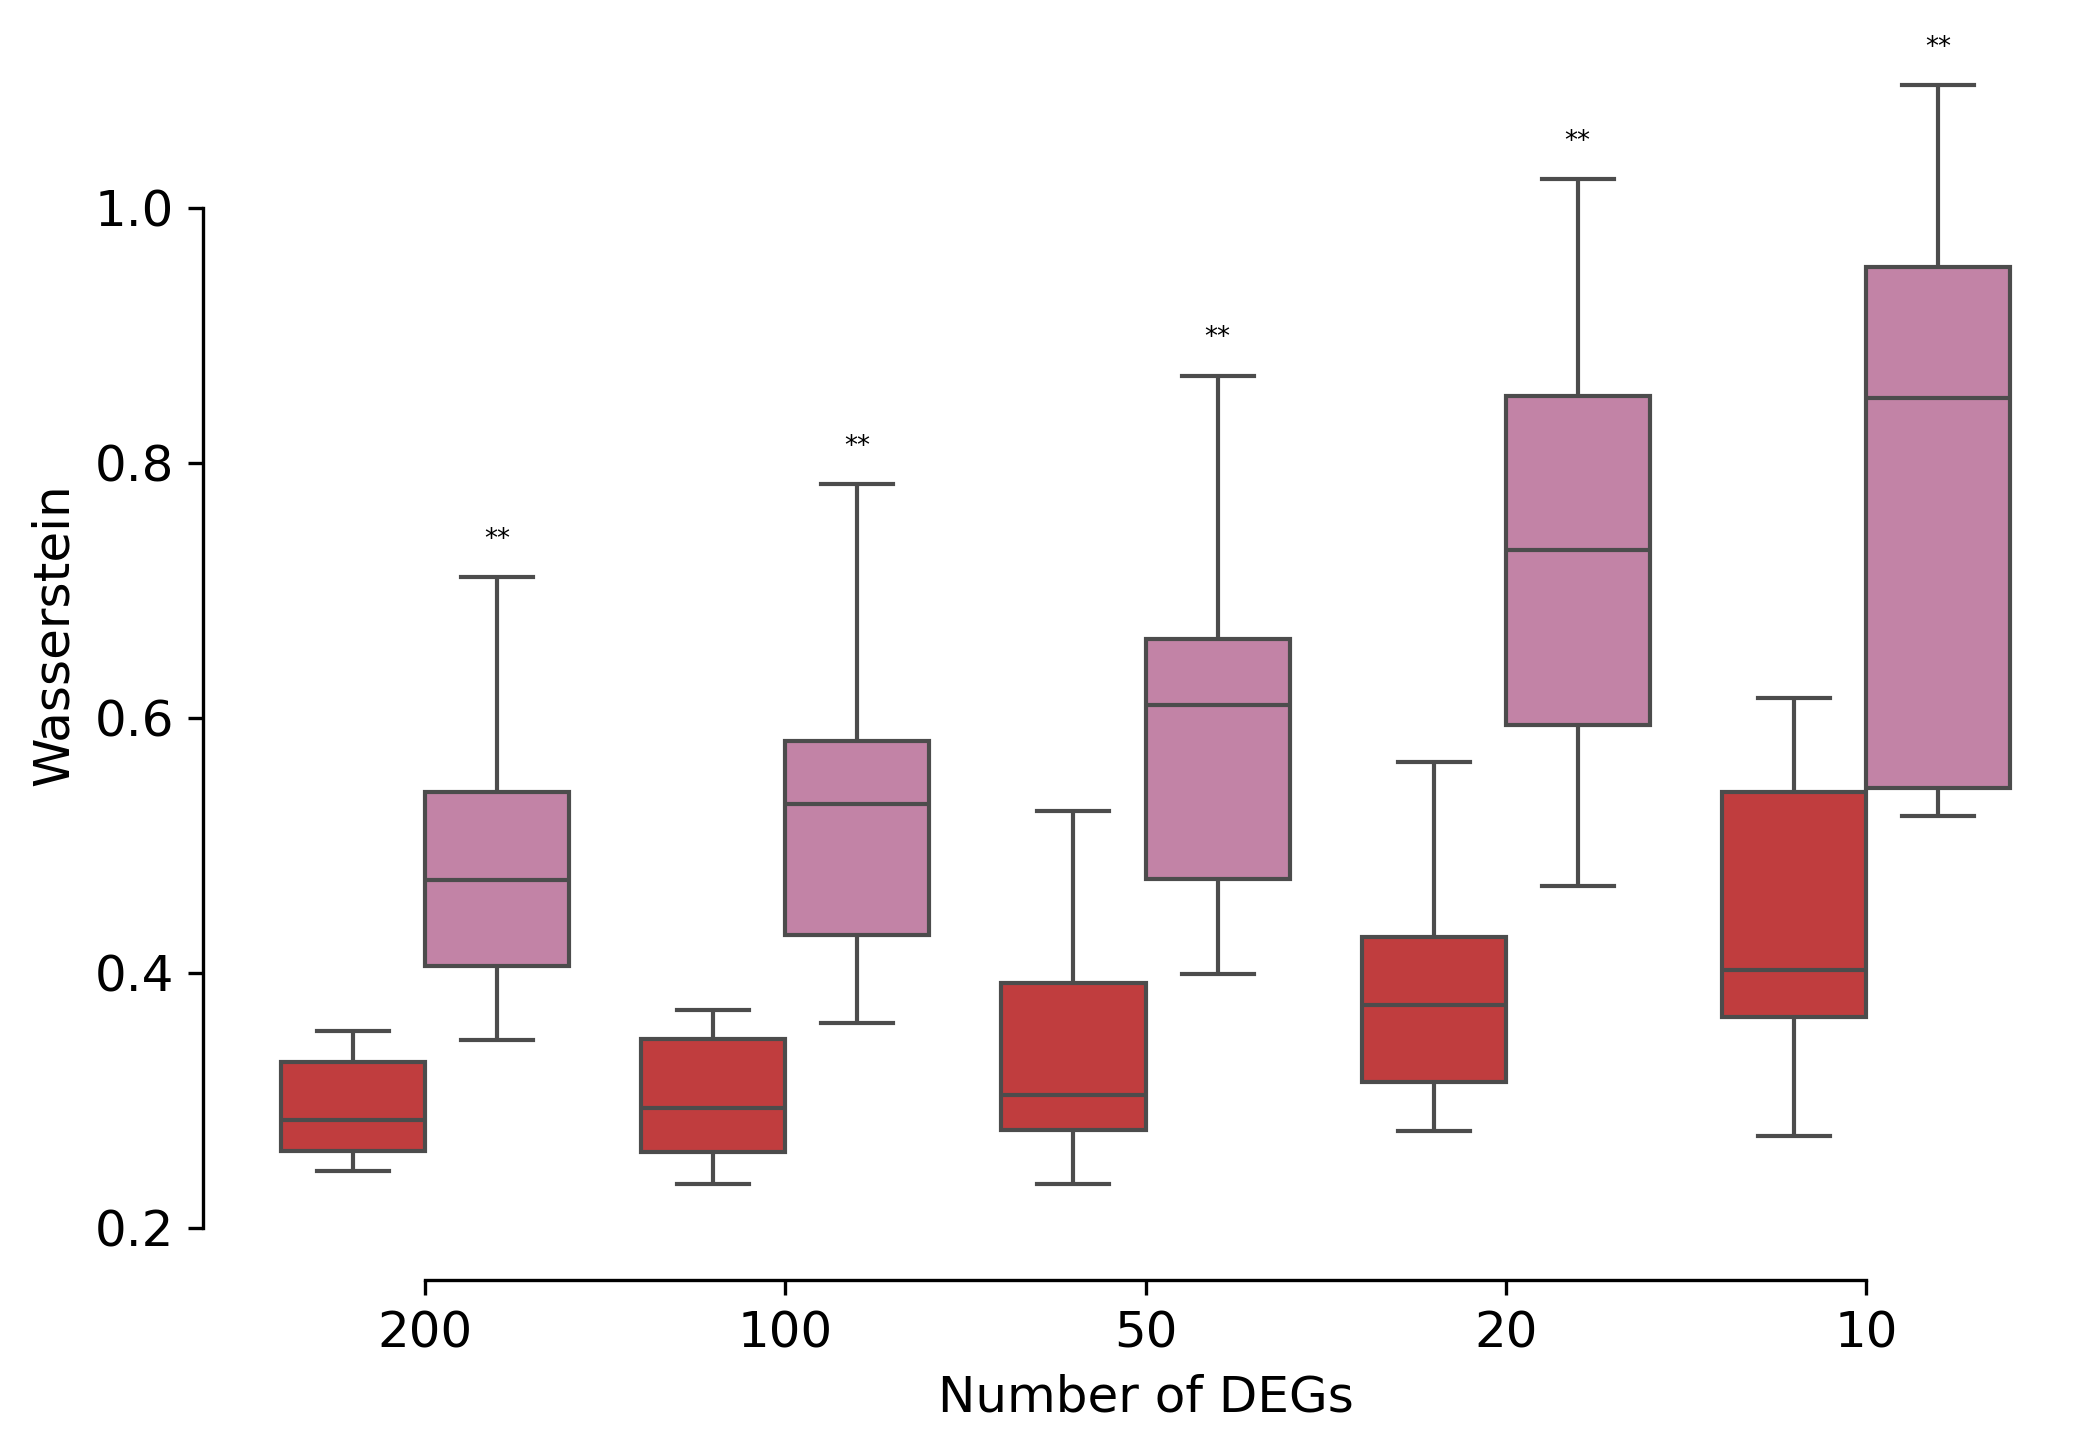

Using 9 perturbation


/home/SE/Desktop/Projects/SCDISENTANGLE/hygeia/hygeia/utils/hplots.py:208: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


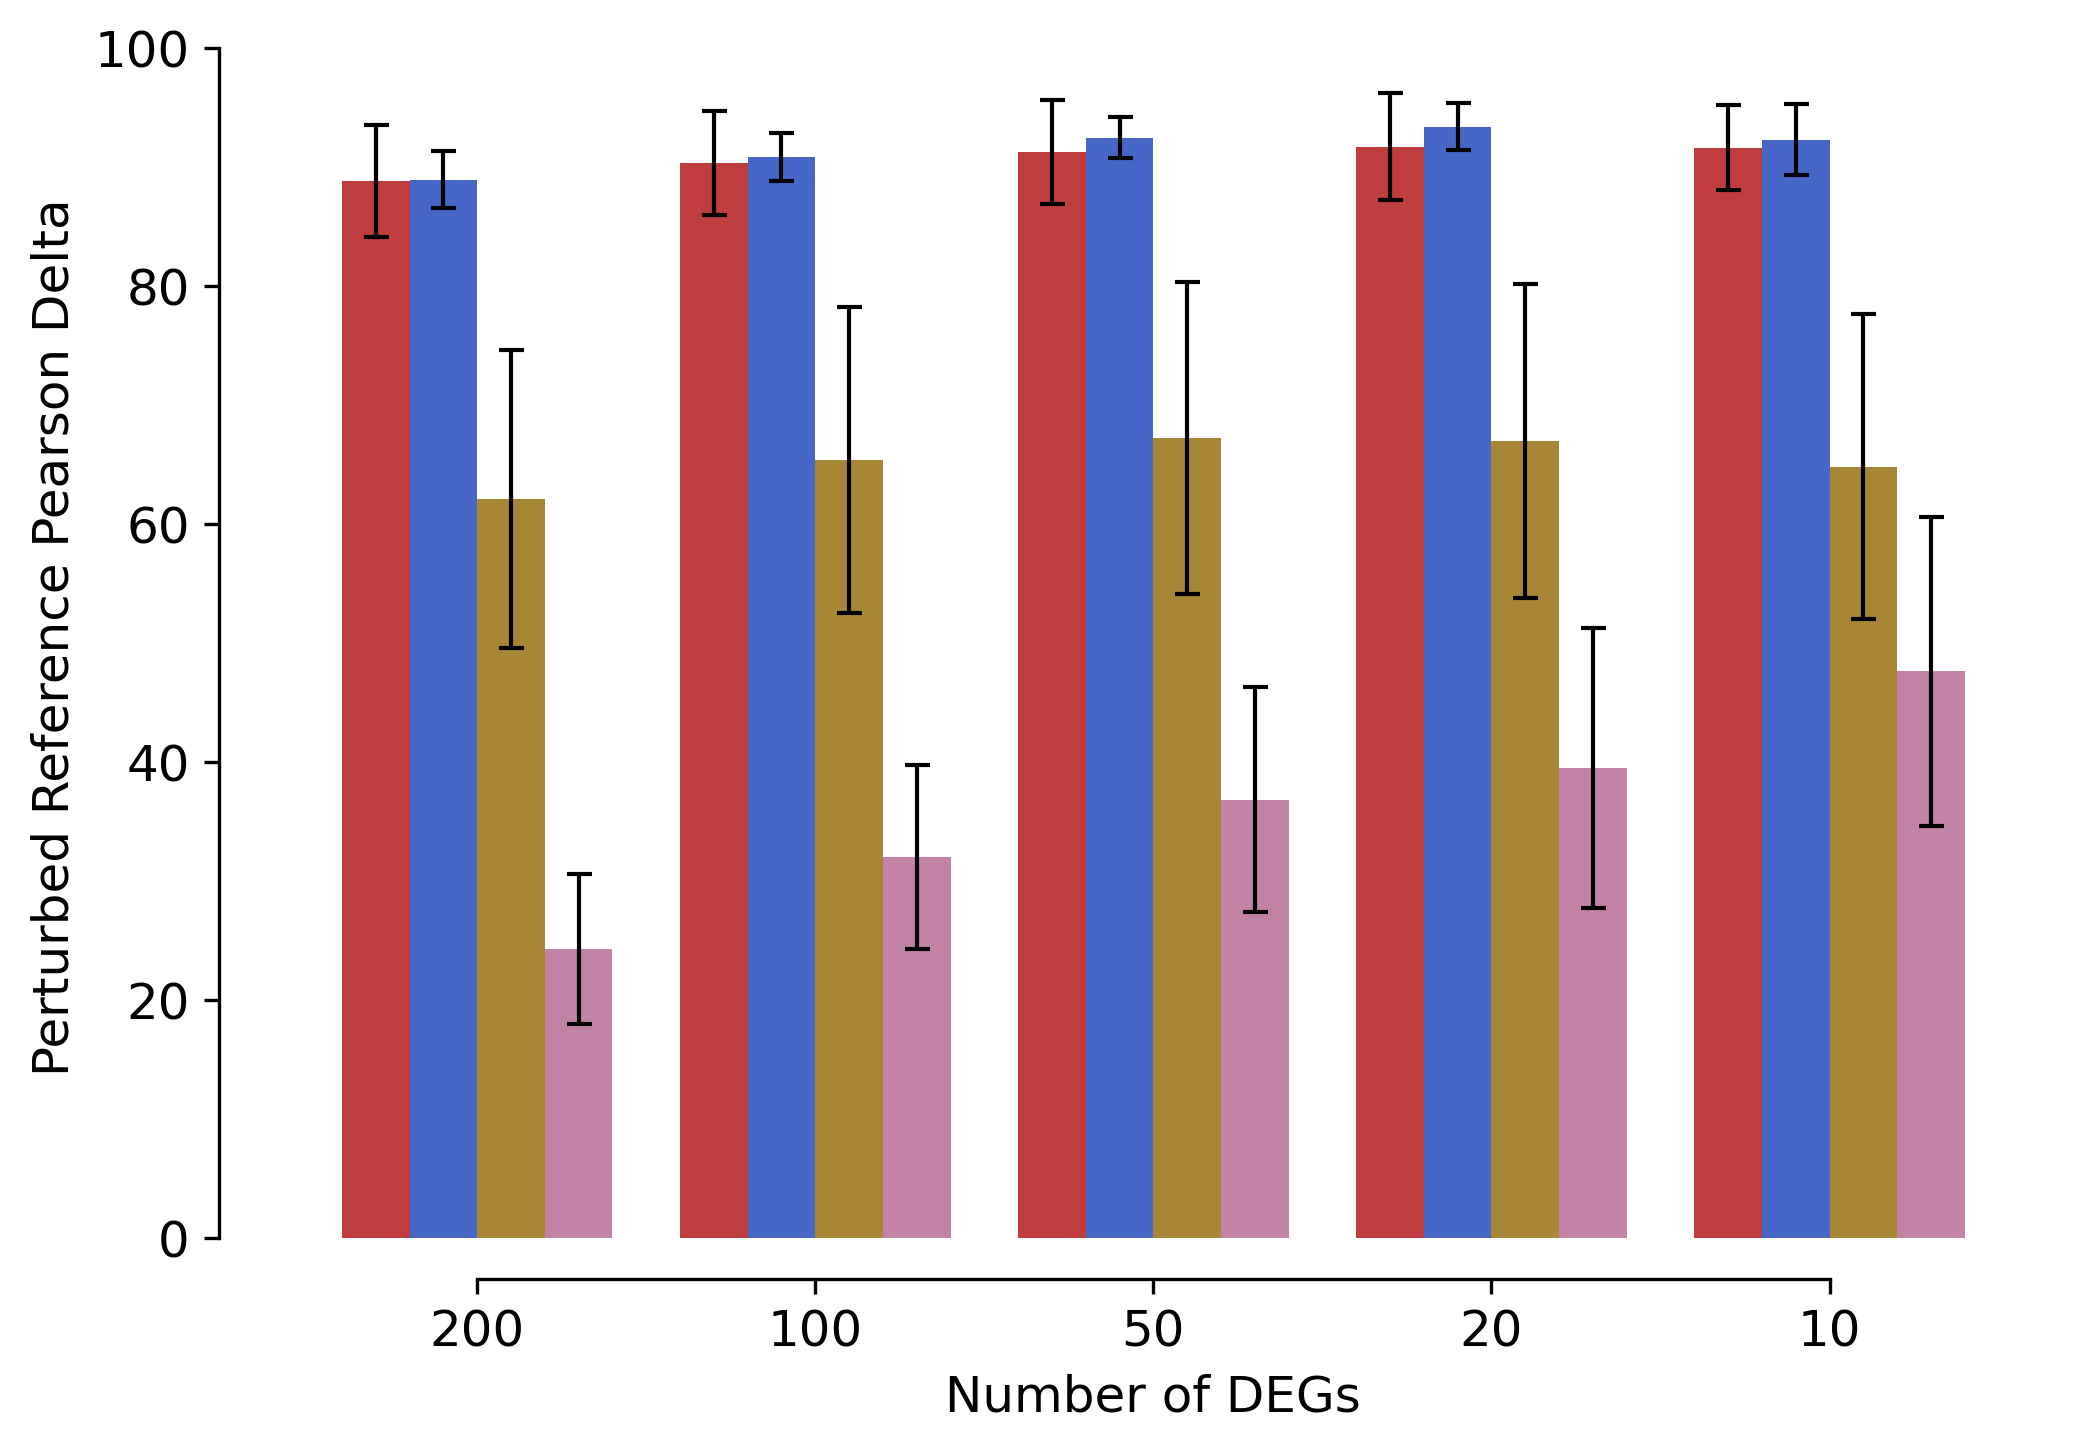

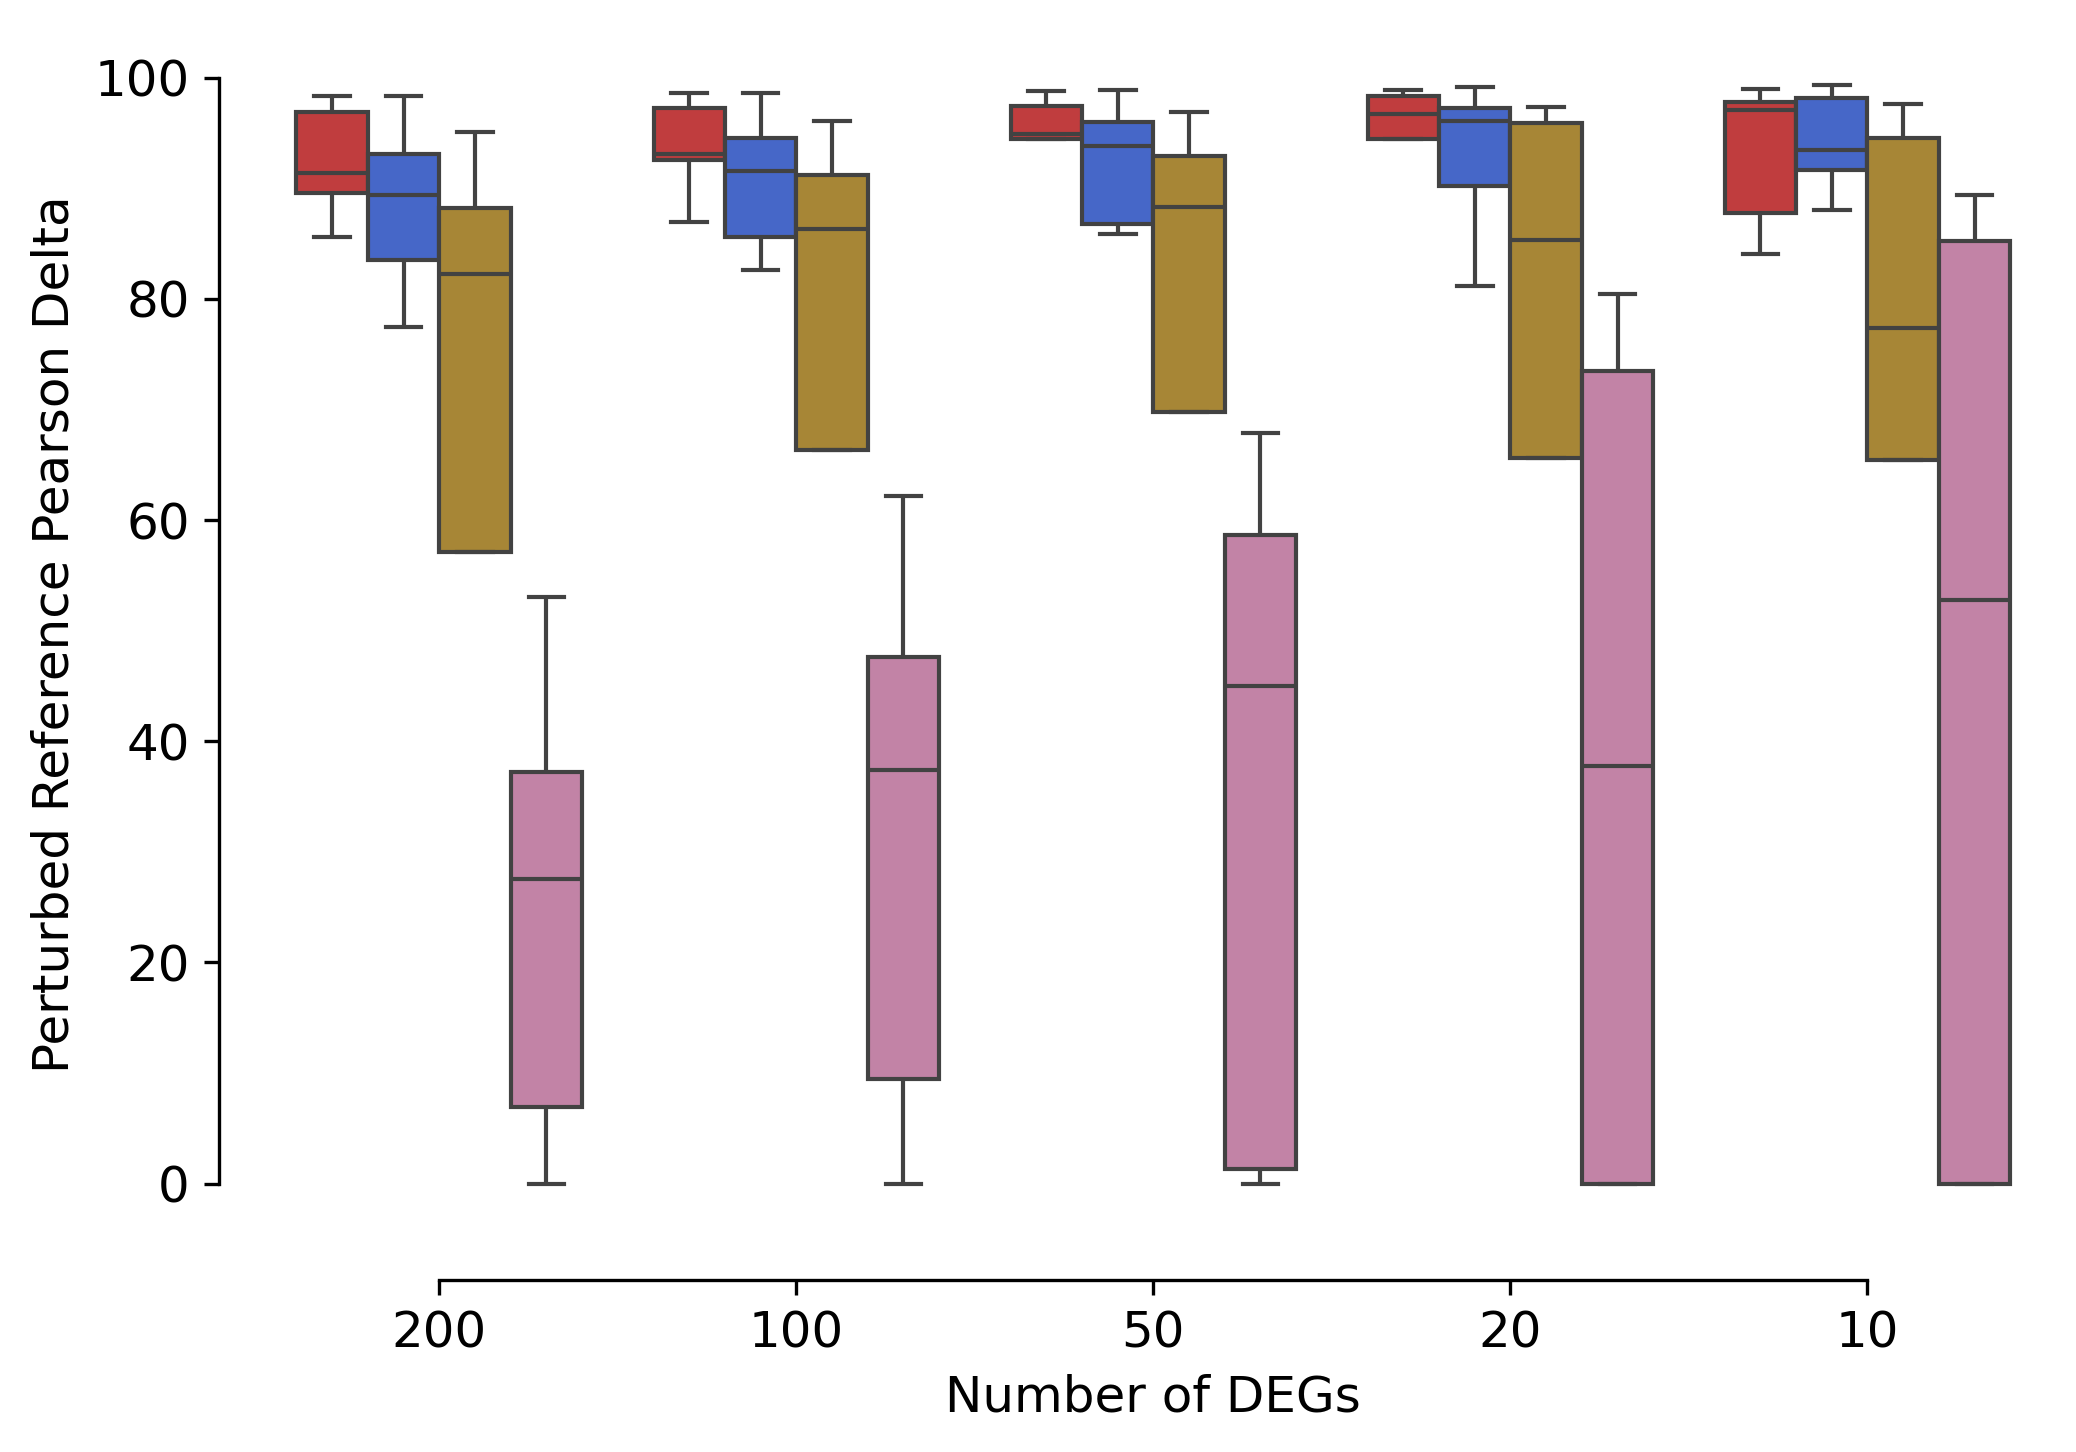

Using 9 perturbation


/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  res = hypotest_fun_out(*samples, **kwds)
/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: Sample size too small for normal approximation.
  res = hypotest_fun_out(*samples, **kwds)
/home/SE/Desktop/Projects/SCDISENTANGLE/hygeia/hygeia/utils/hplots.py:208: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


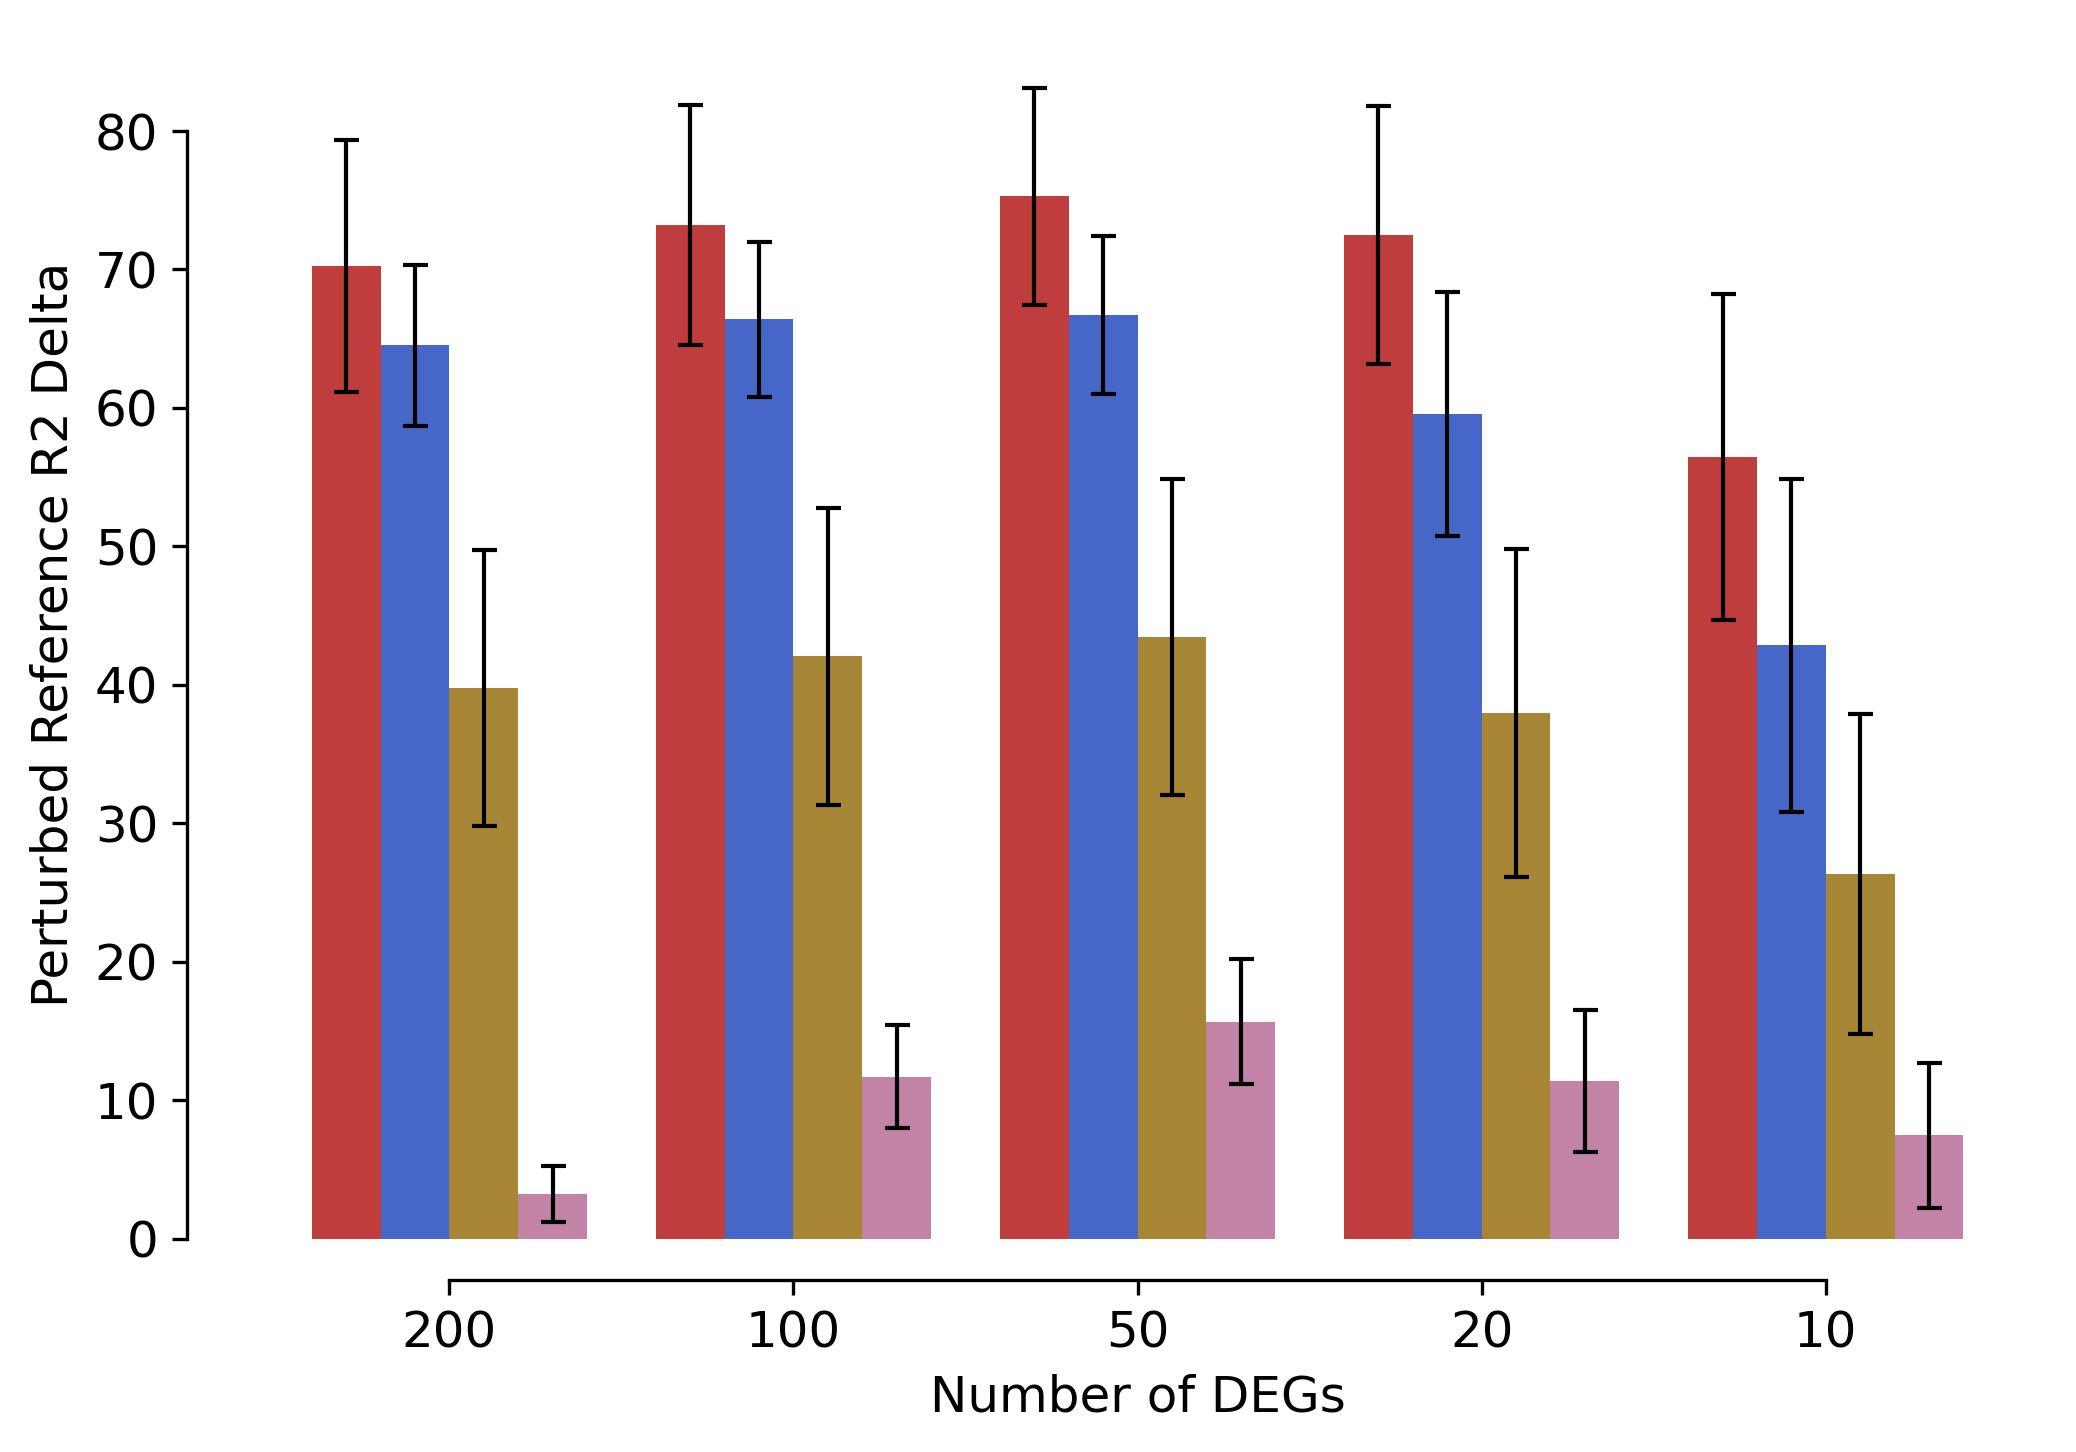

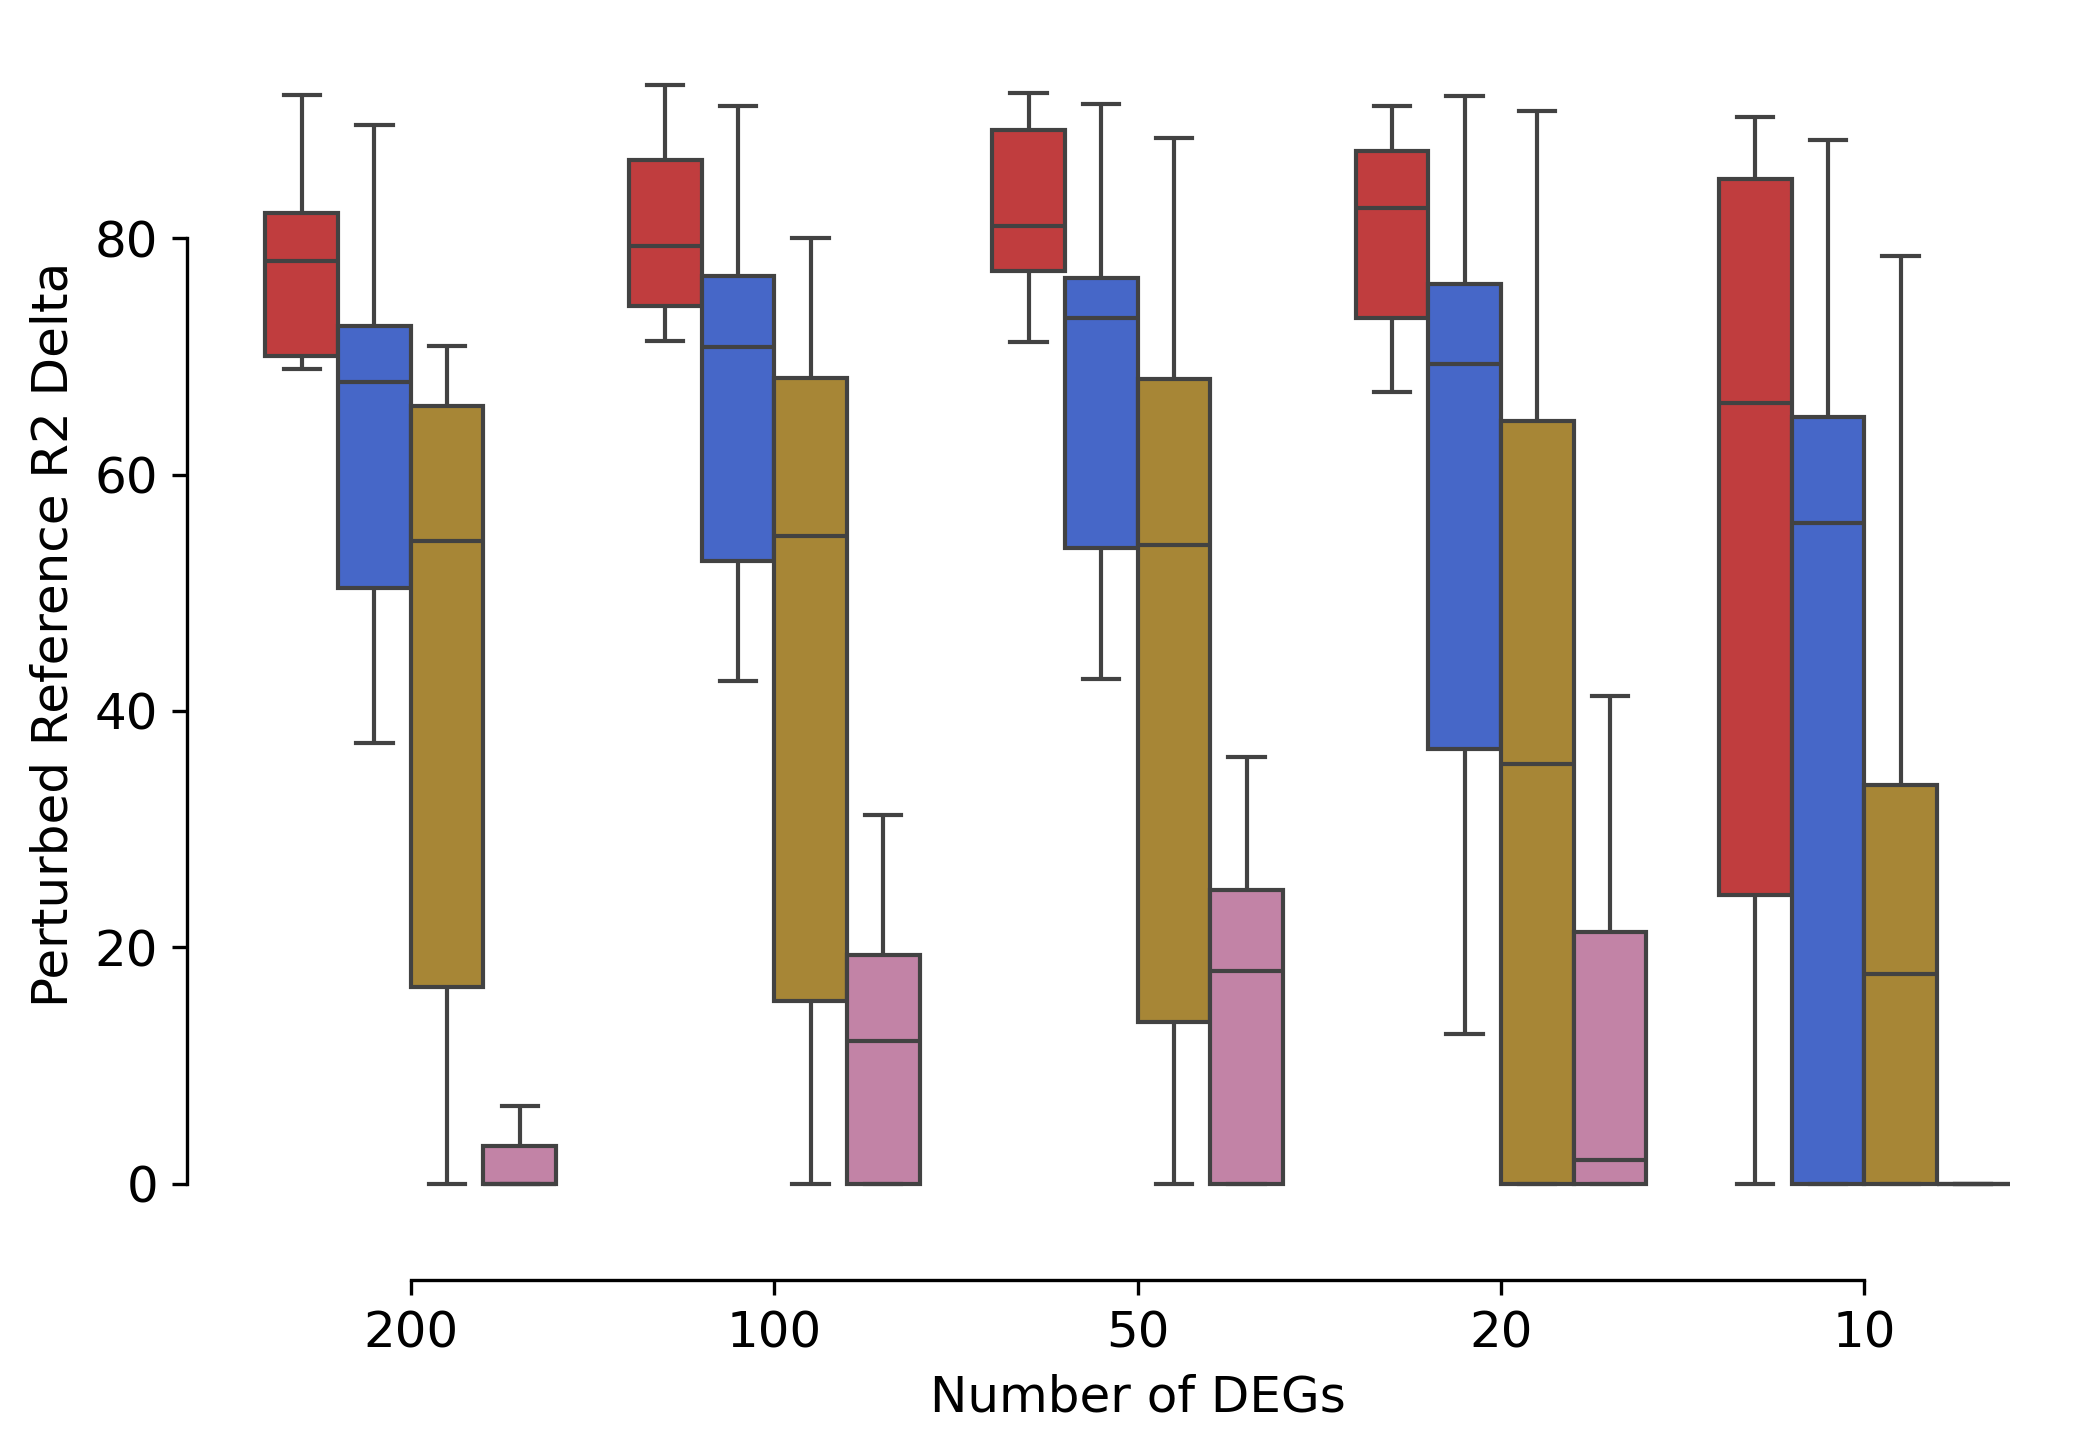

Using 9 perturbation


/home/SE/Desktop/Projects/SCDISENTANGLE/hygeia/hygeia/utils/hplots.py:208: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


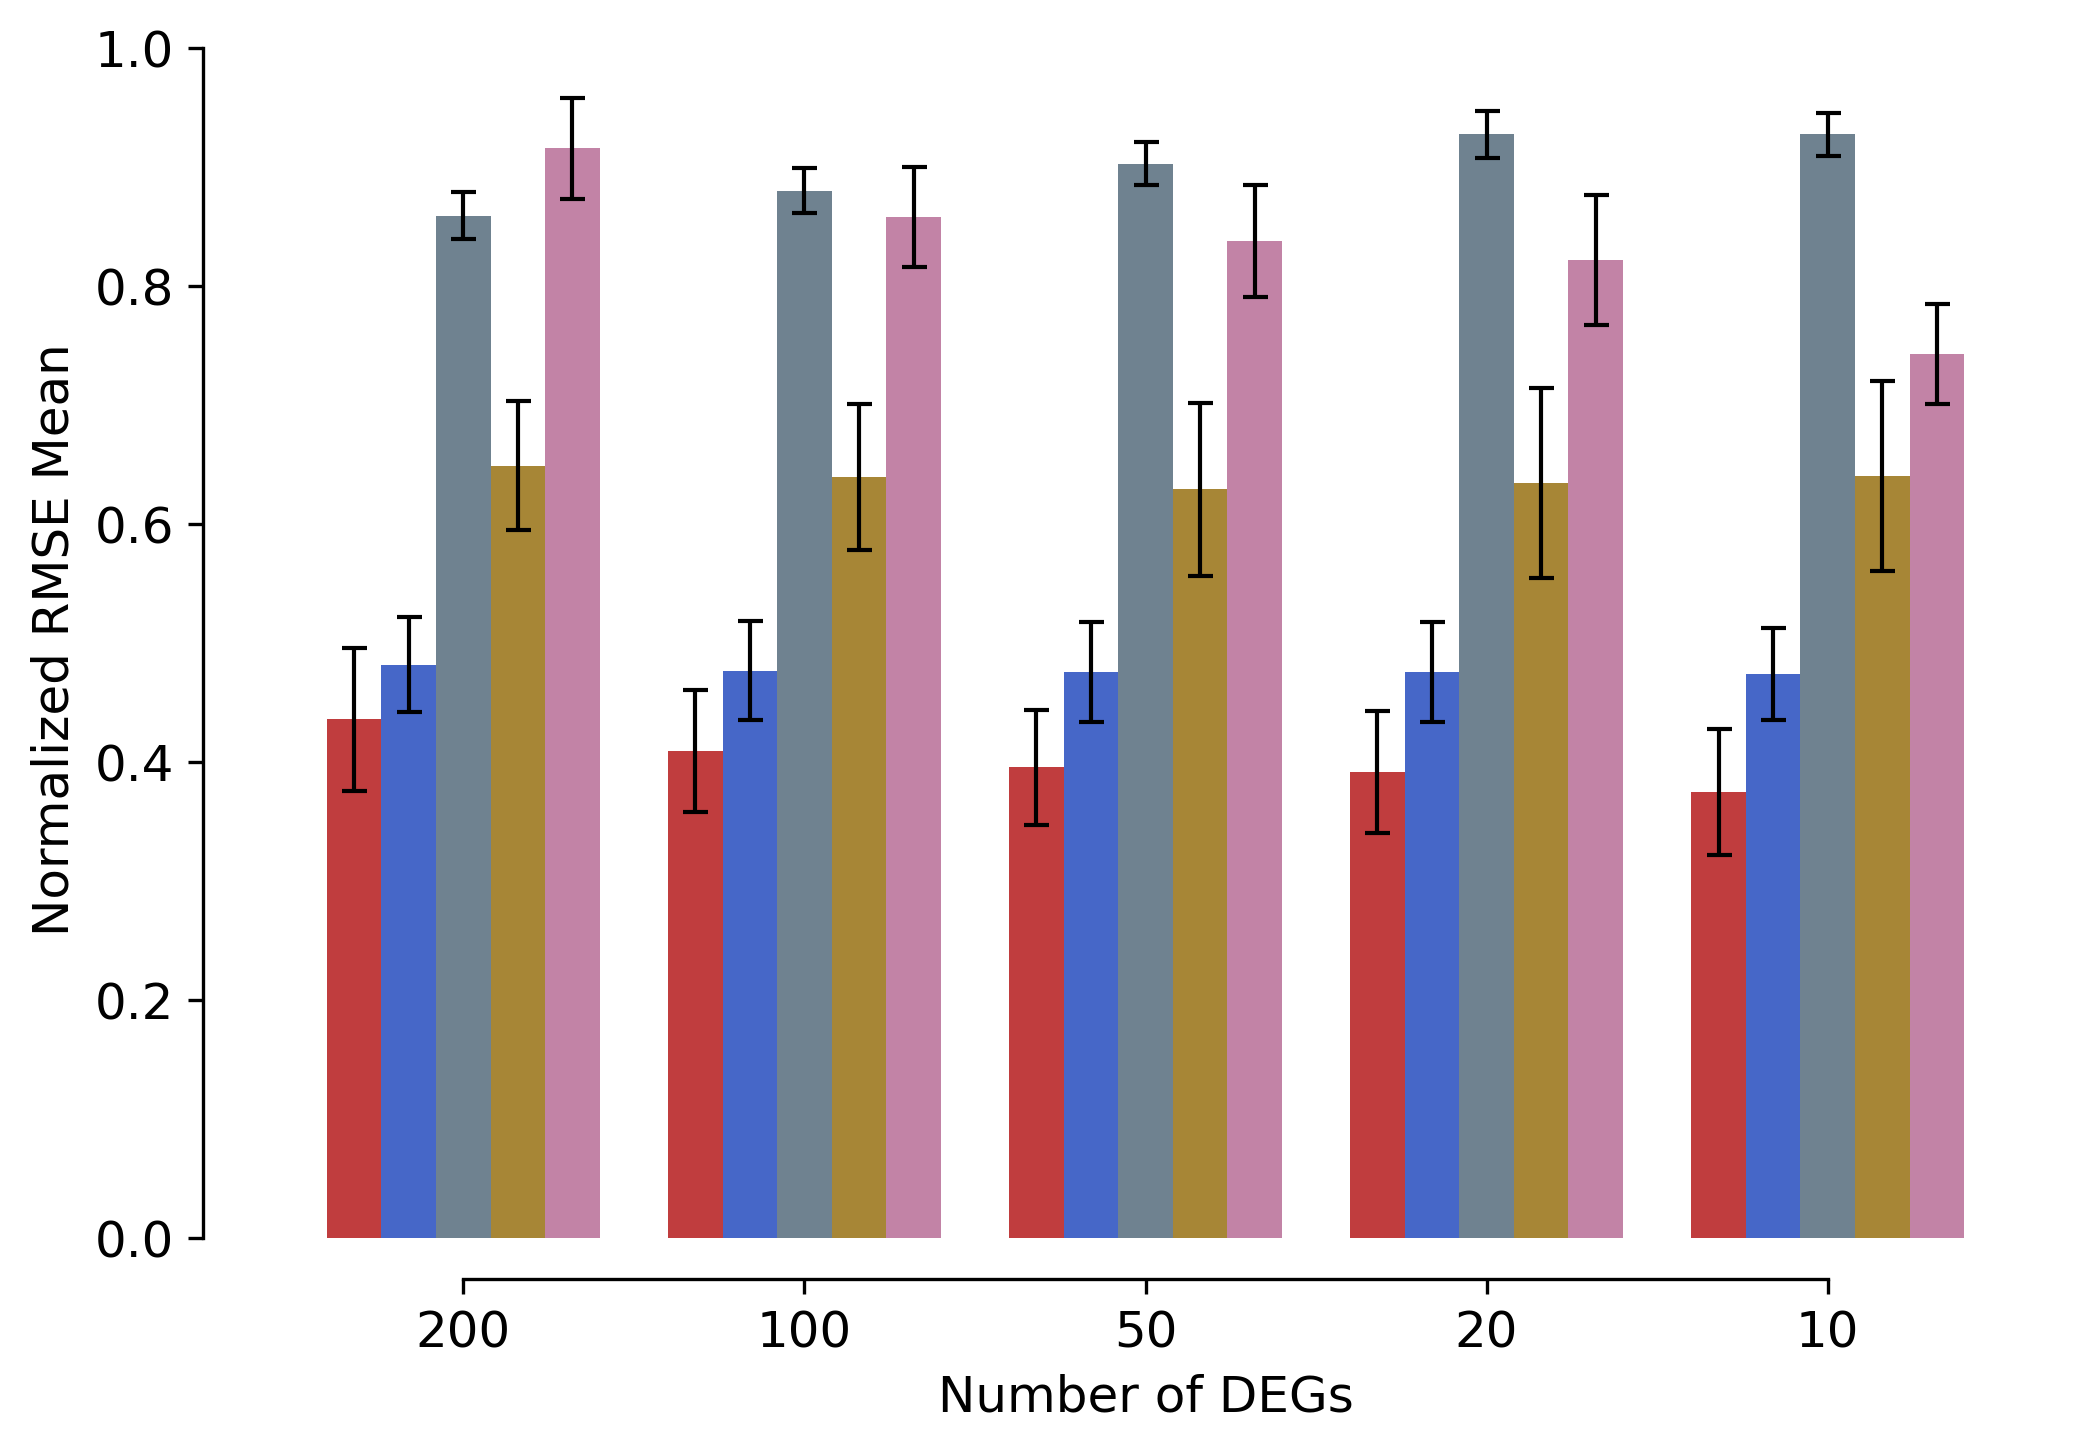

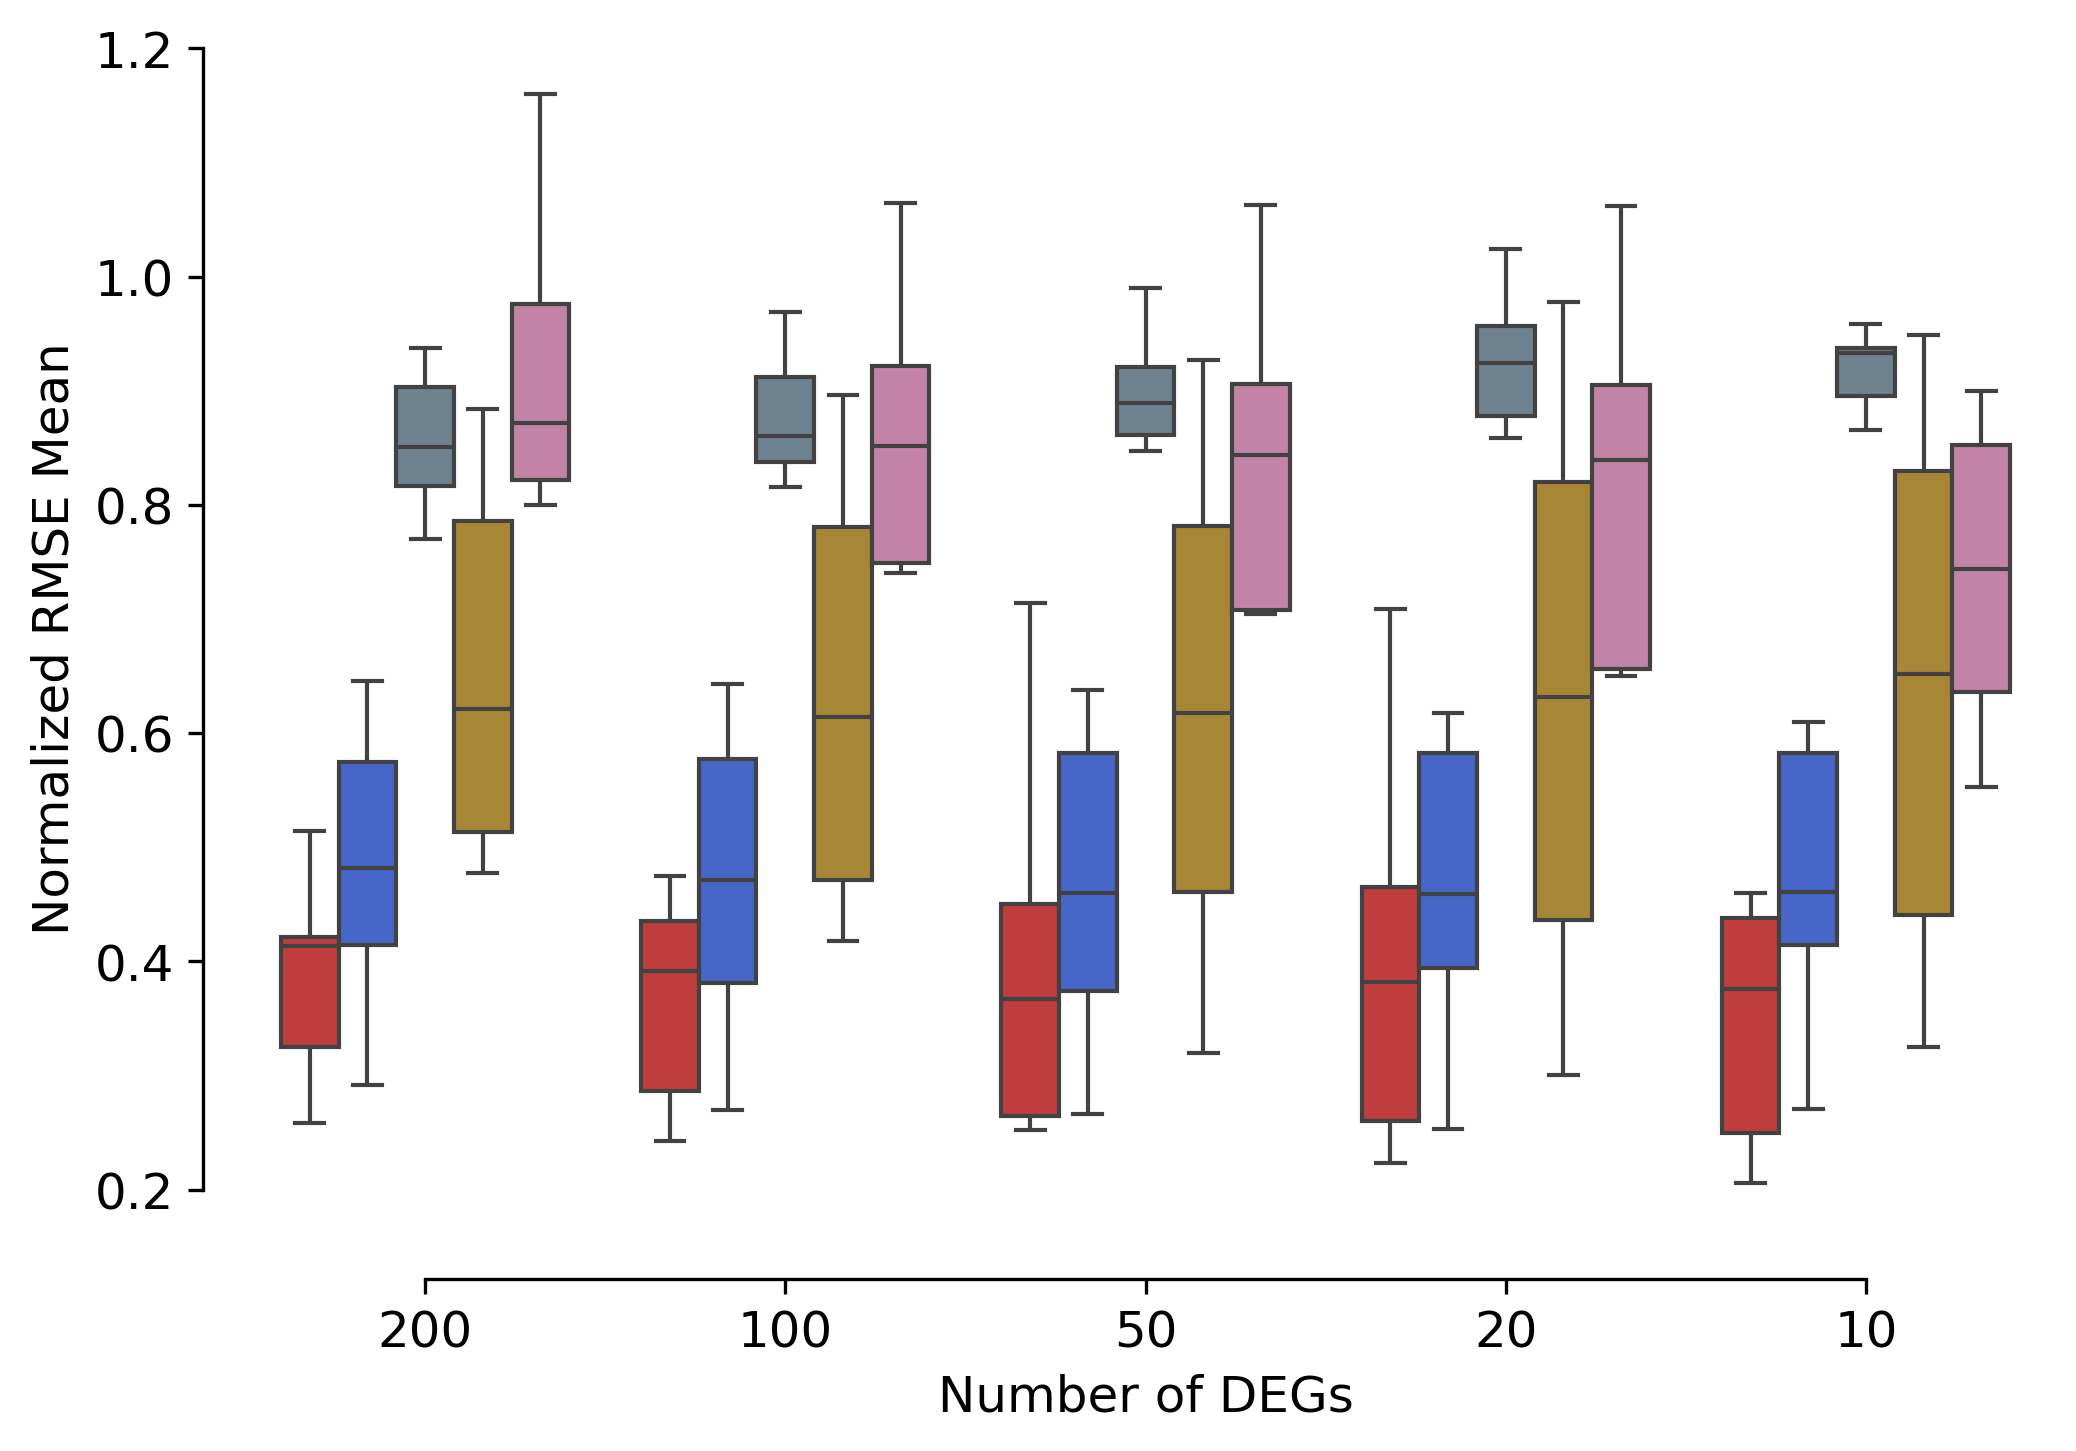

Using 9 perturbation


/home/SE/Desktop/Projects/SCDISENTANGLE/hygeia/hygeia/utils/hplots.py:208: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


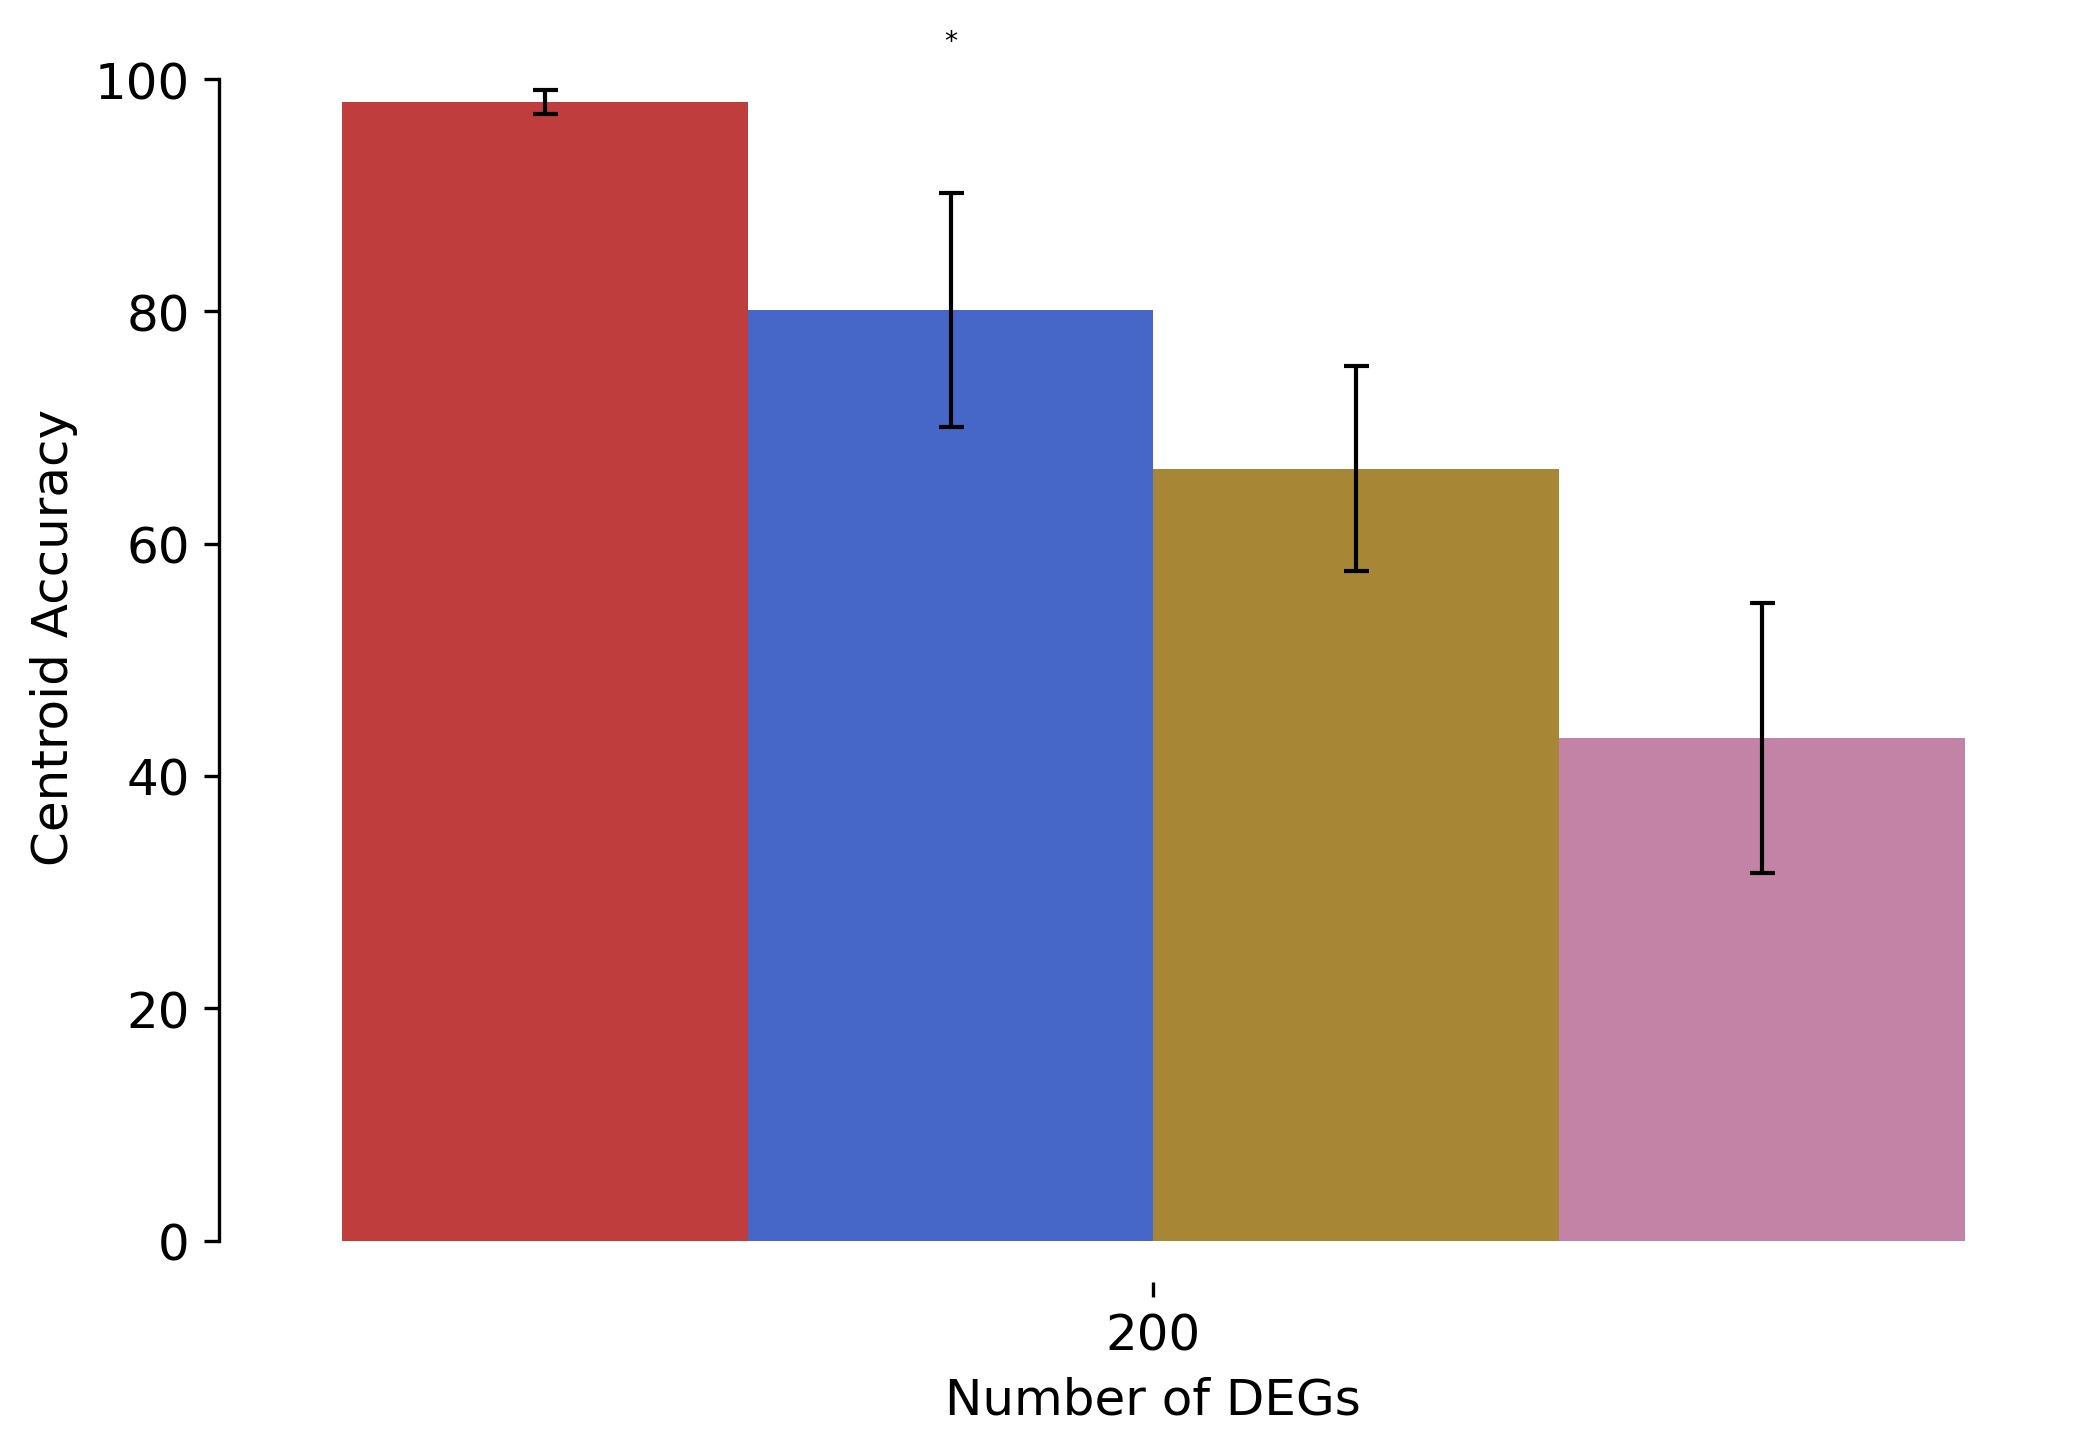

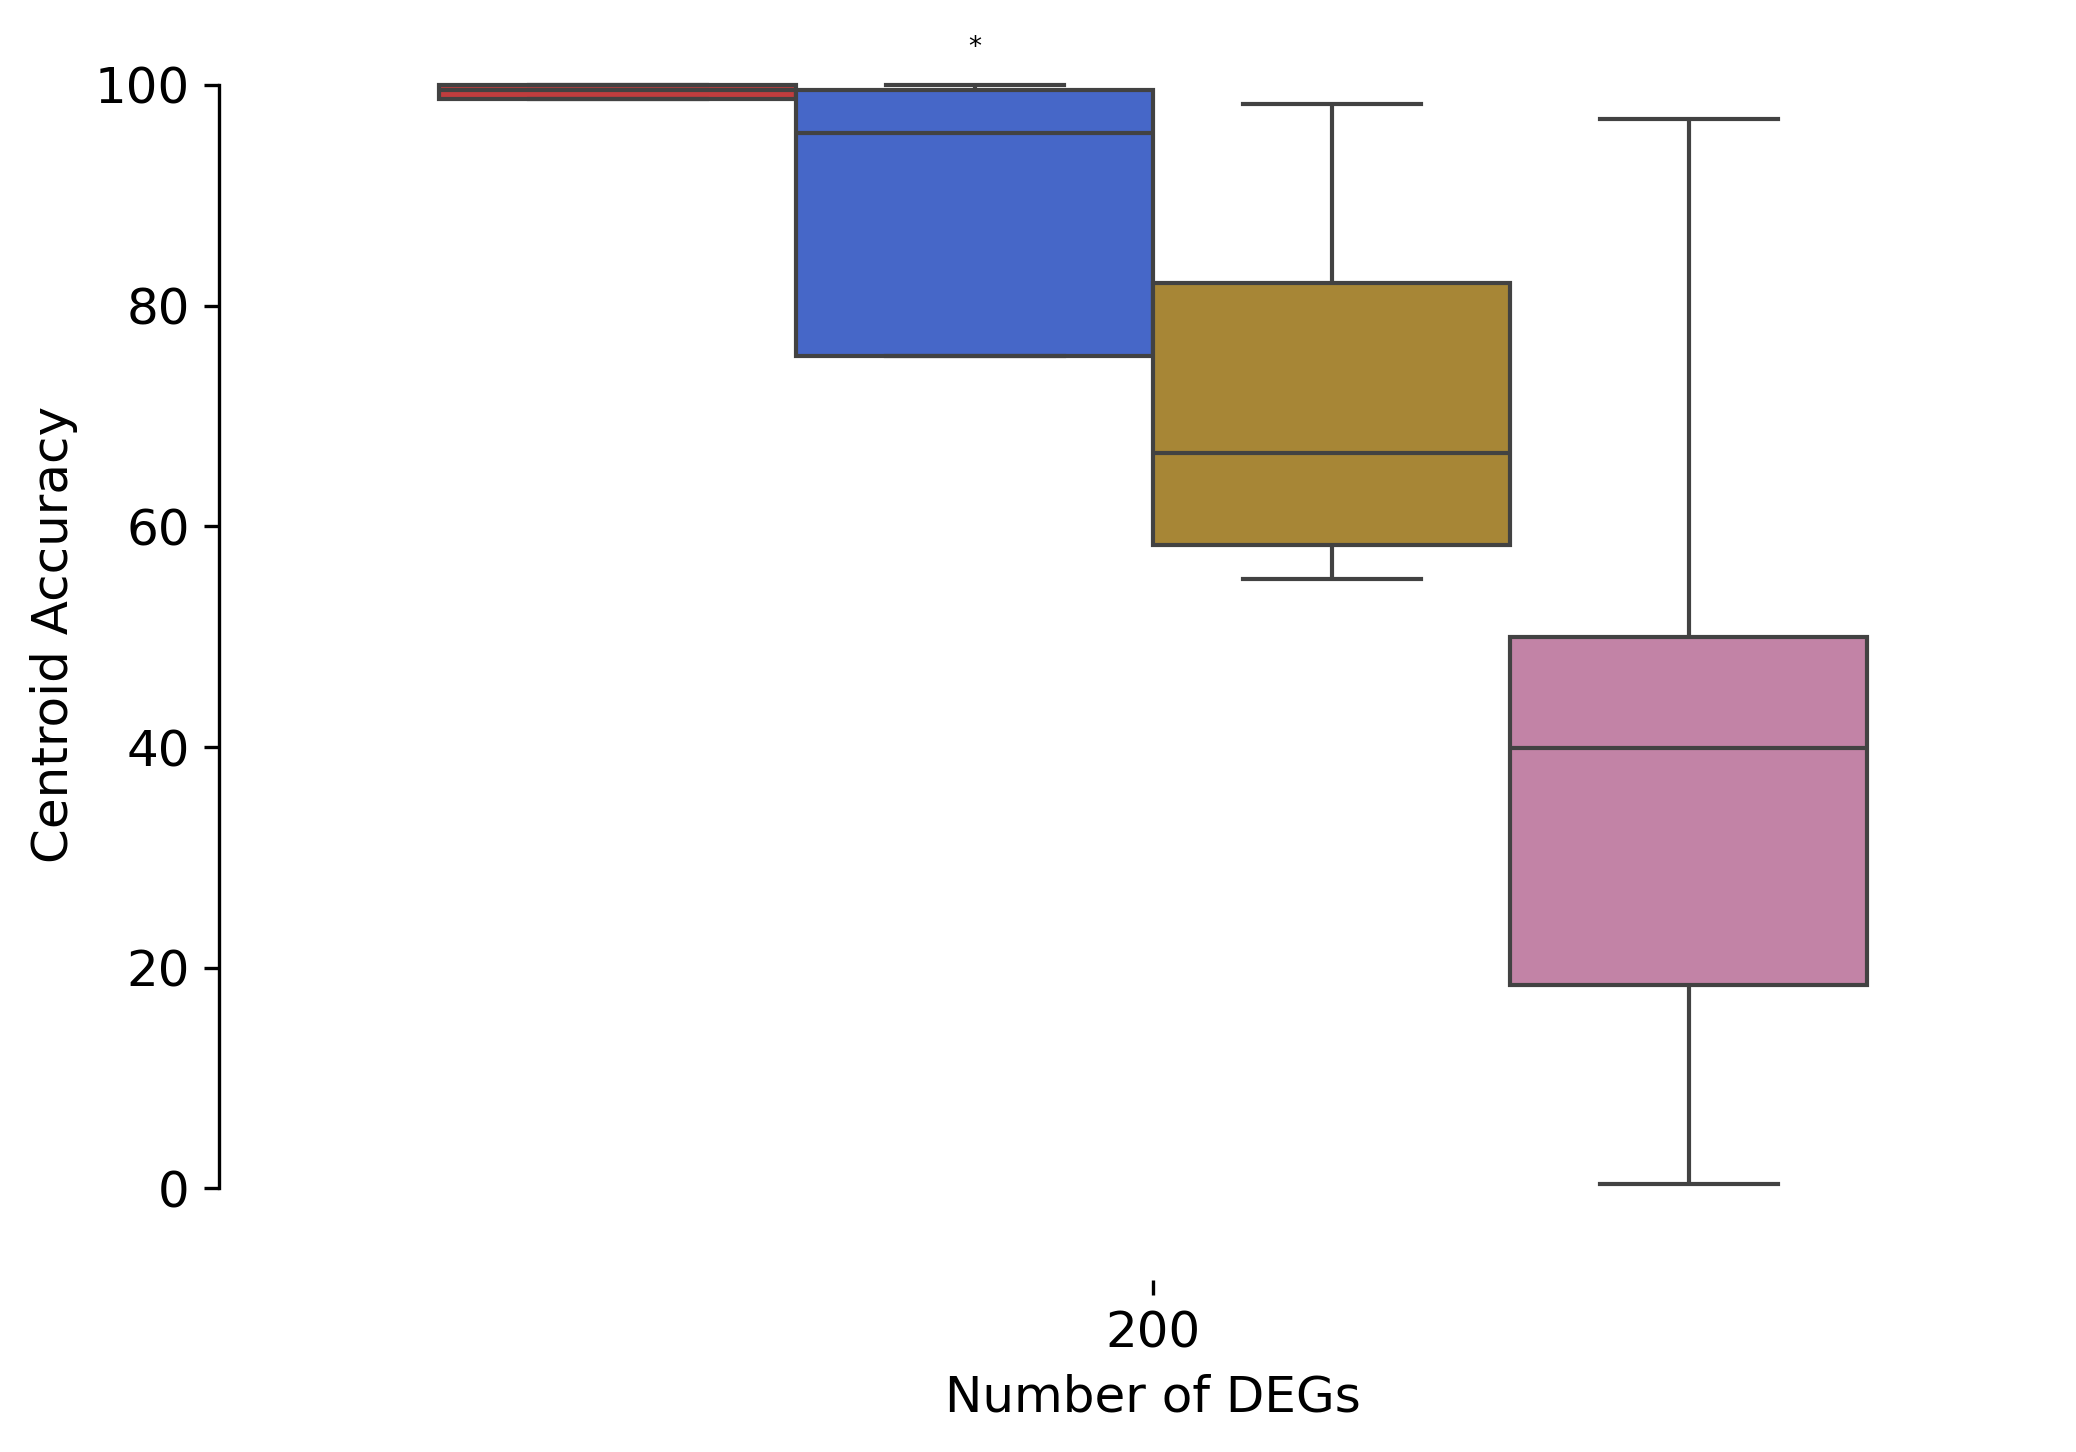

Using 9 perturbation


/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  res = hypotest_fun_out(*samples, **kwds)
/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: Sample size too small for normal approximation.
  res = hypotest_fun_out(*samples, **kwds)
/home/SE/Desktop/Projects/SCDISENTANGLE/hygeia/hygeia/utils/hplots.py:208: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


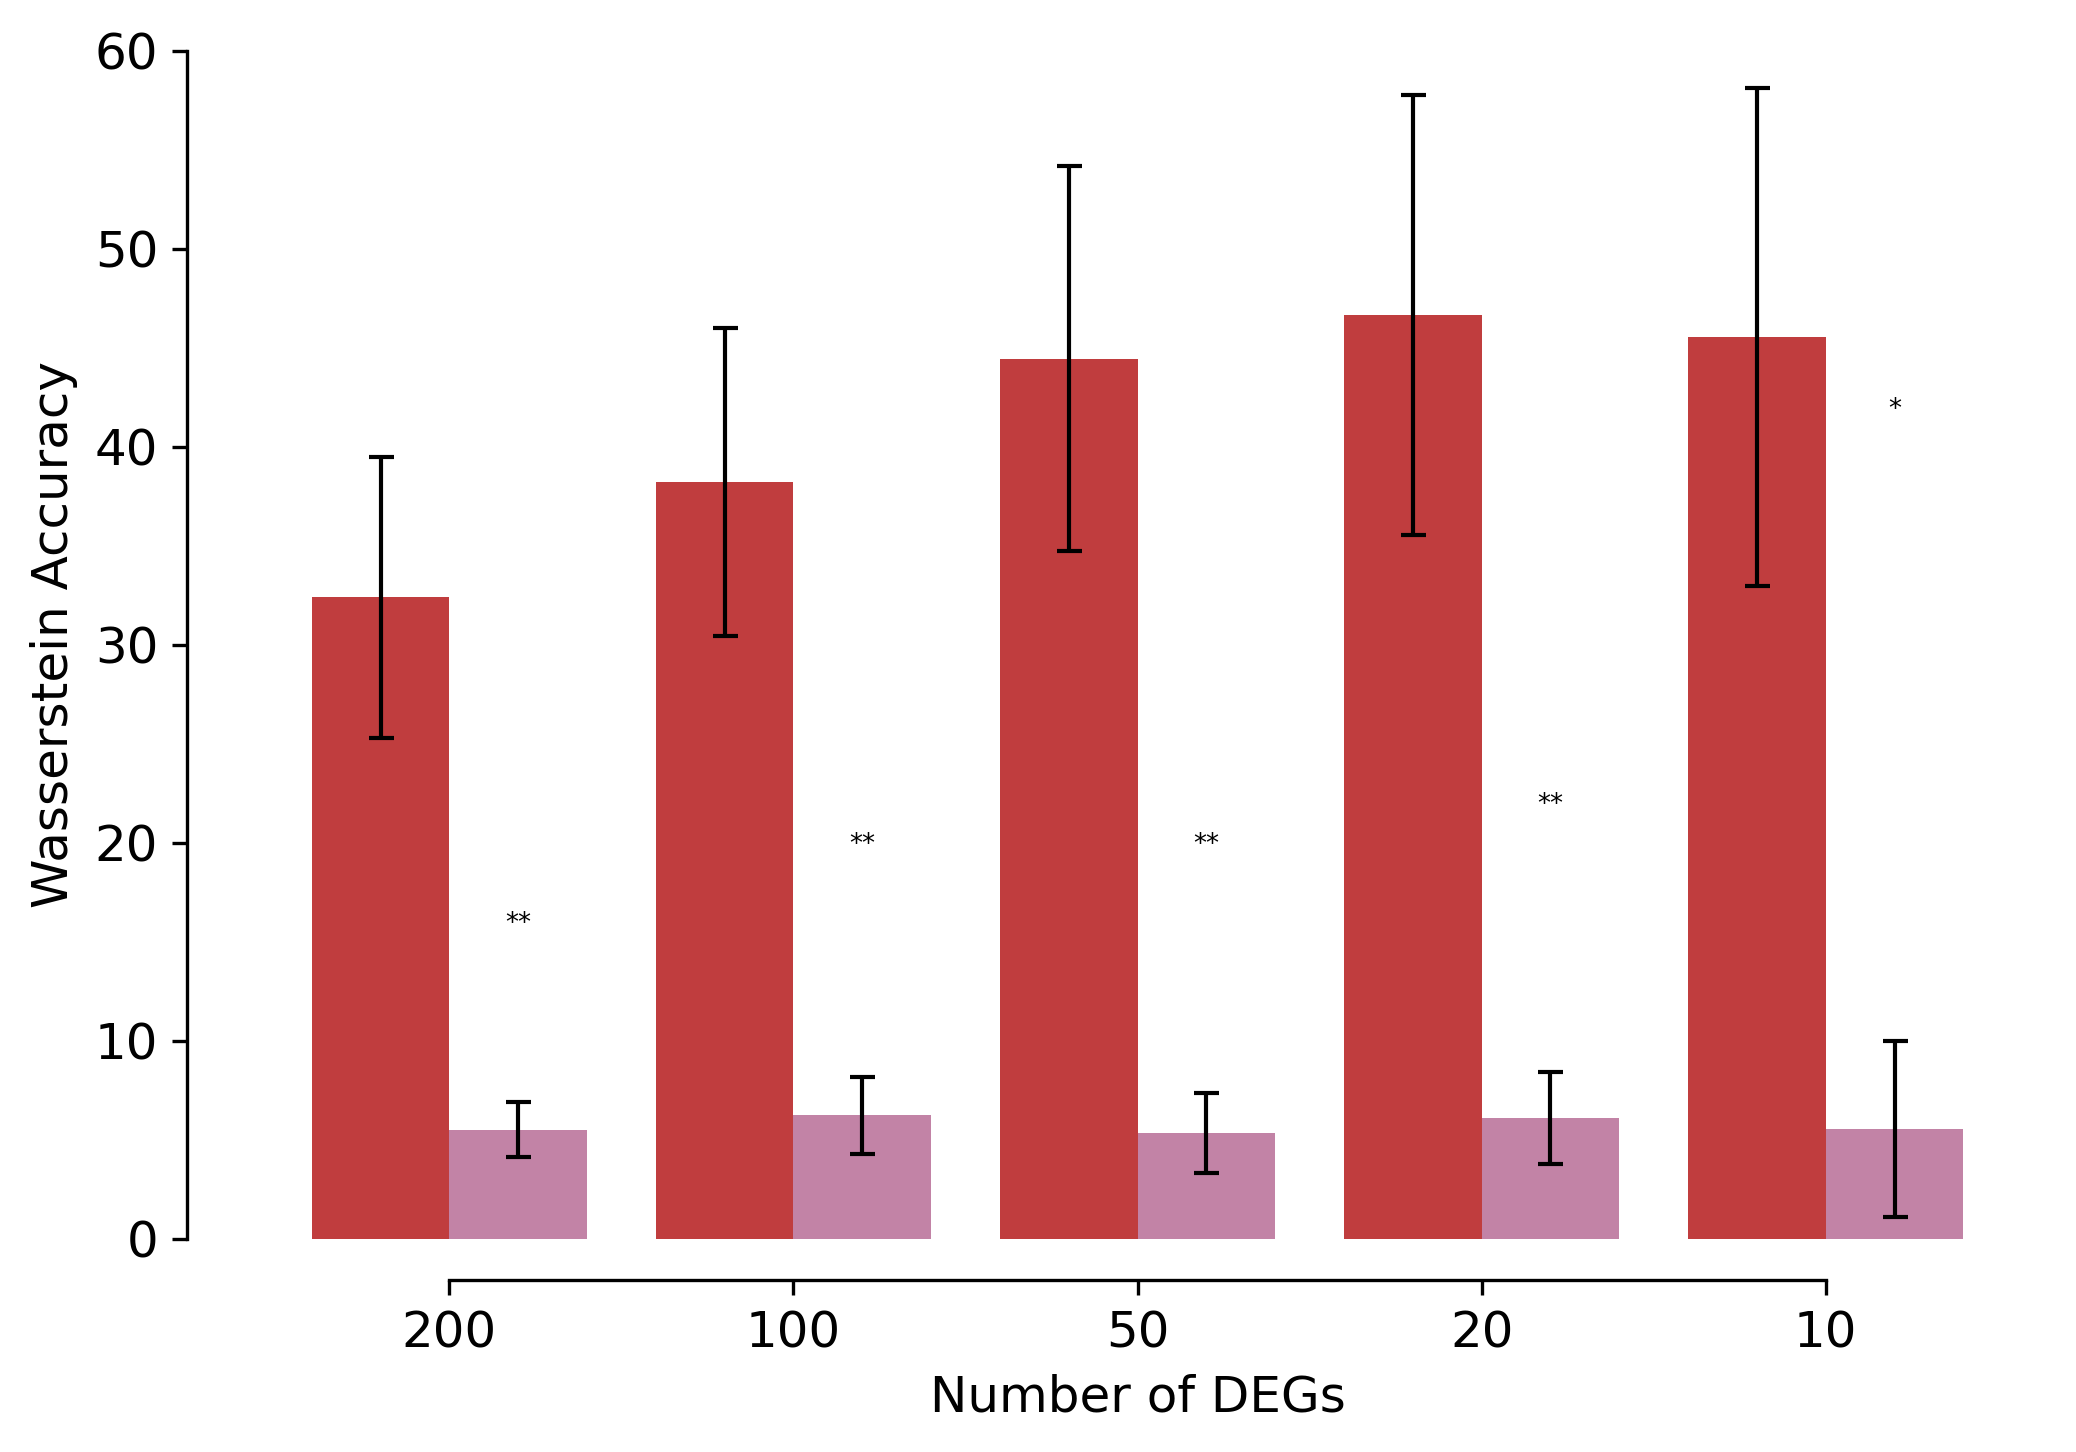

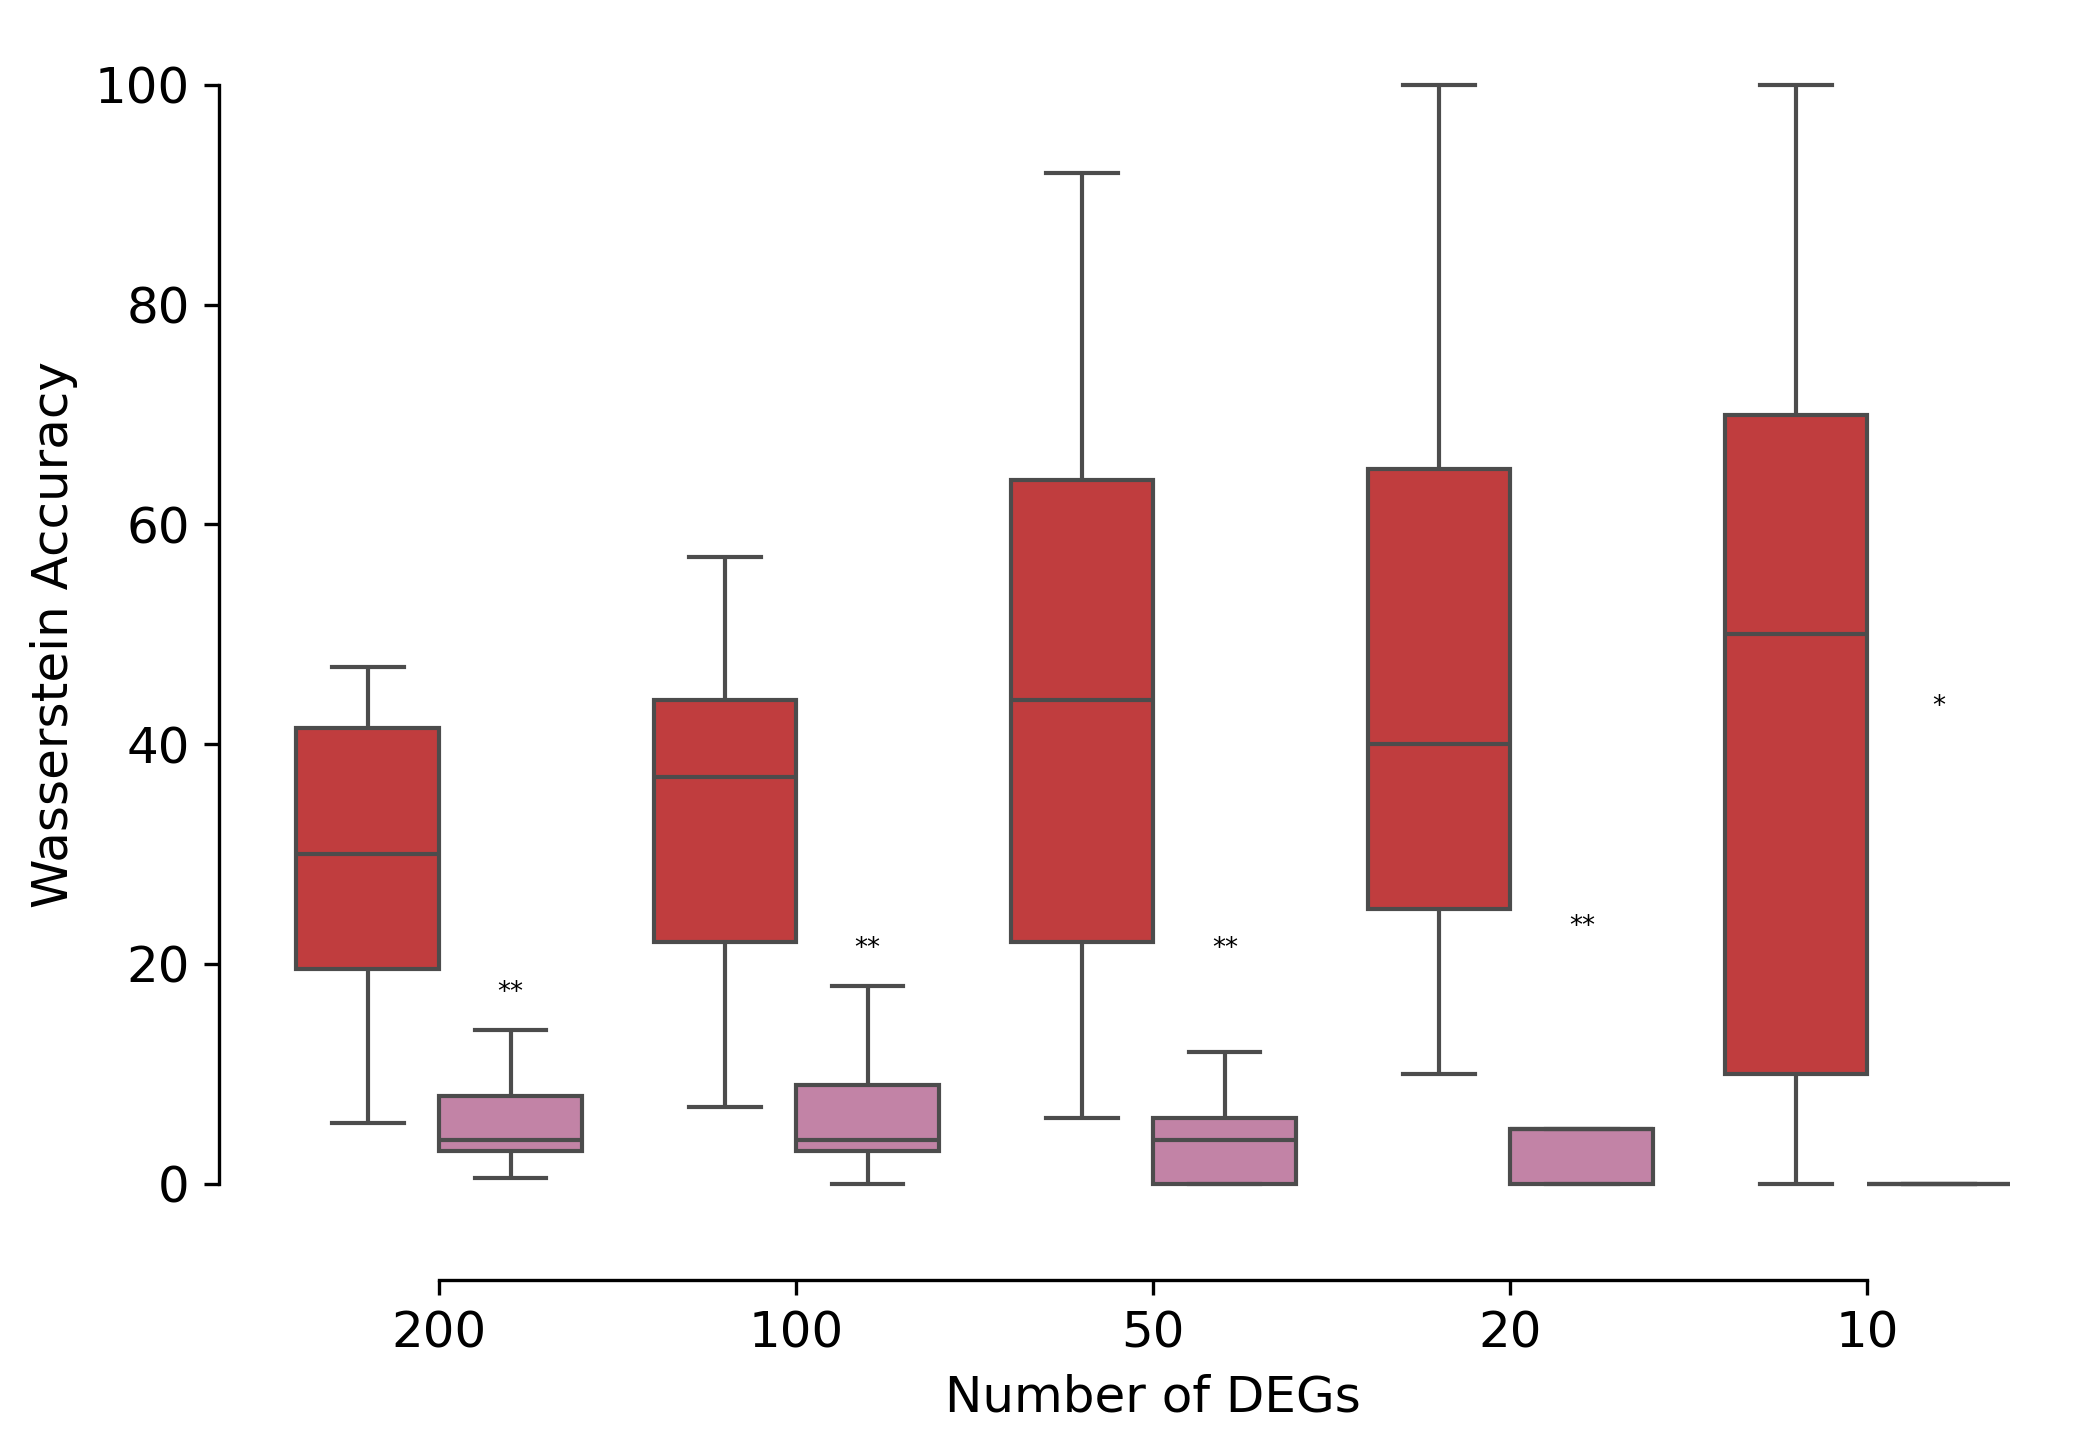

Using 9 perturbation


/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  res = hypotest_fun_out(*samples, **kwds)
/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: Sample size too small for normal approximation.
  res = hypotest_fun_out(*samples, **kwds)
/home/SE/Desktop/Projects/SCDISENTANGLE/hygeia/hygeia/utils/hplots.py:208: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


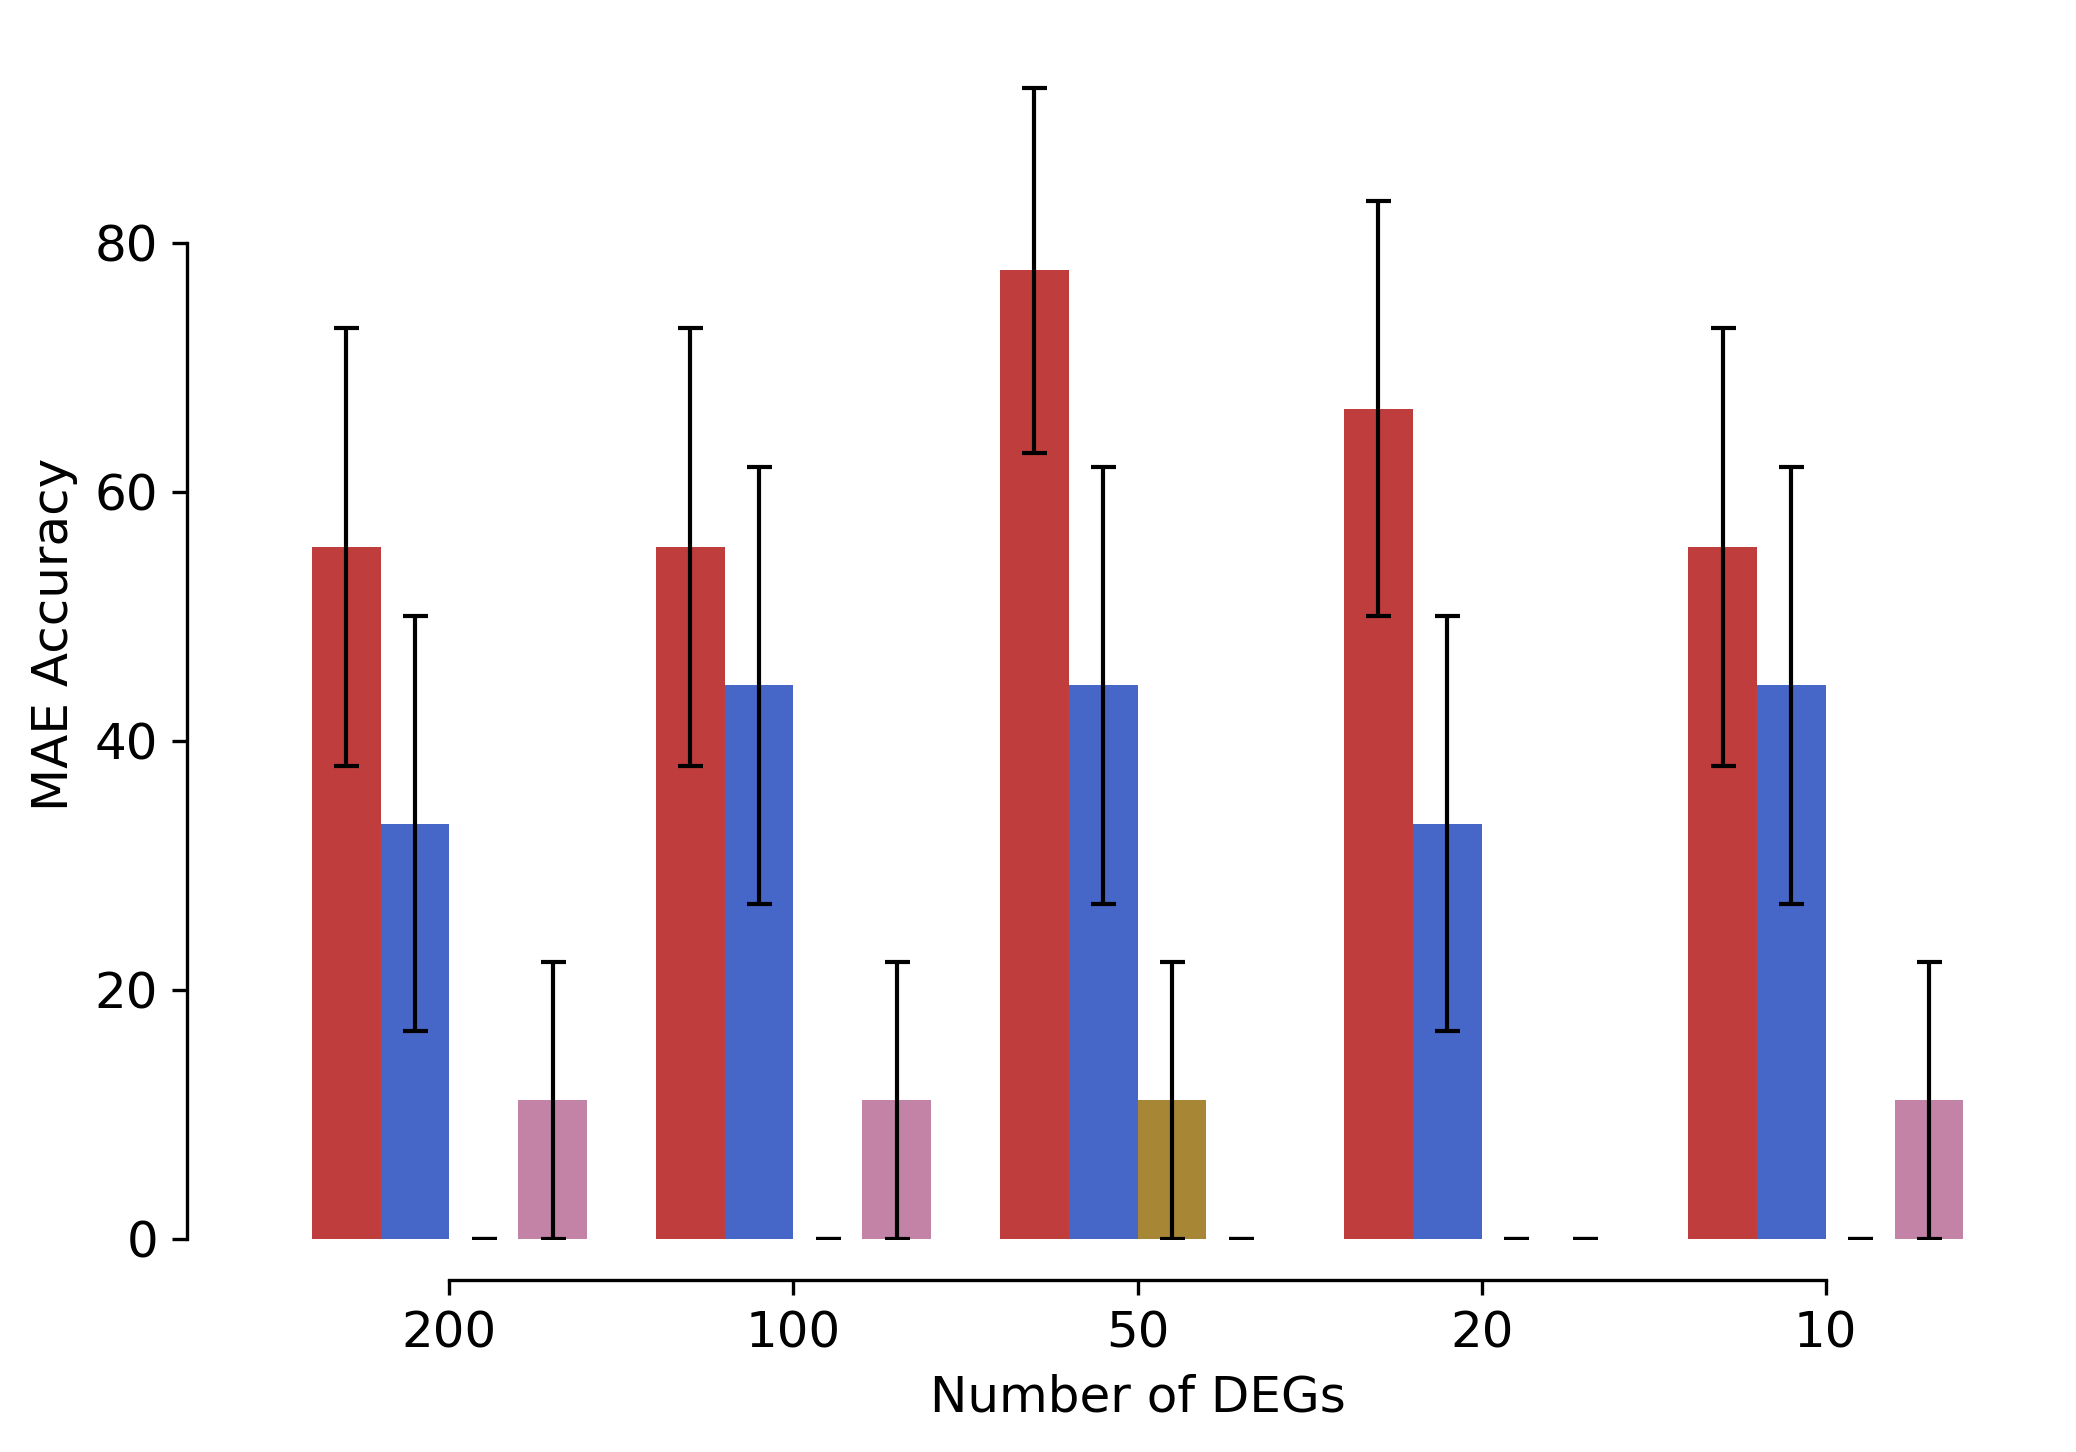

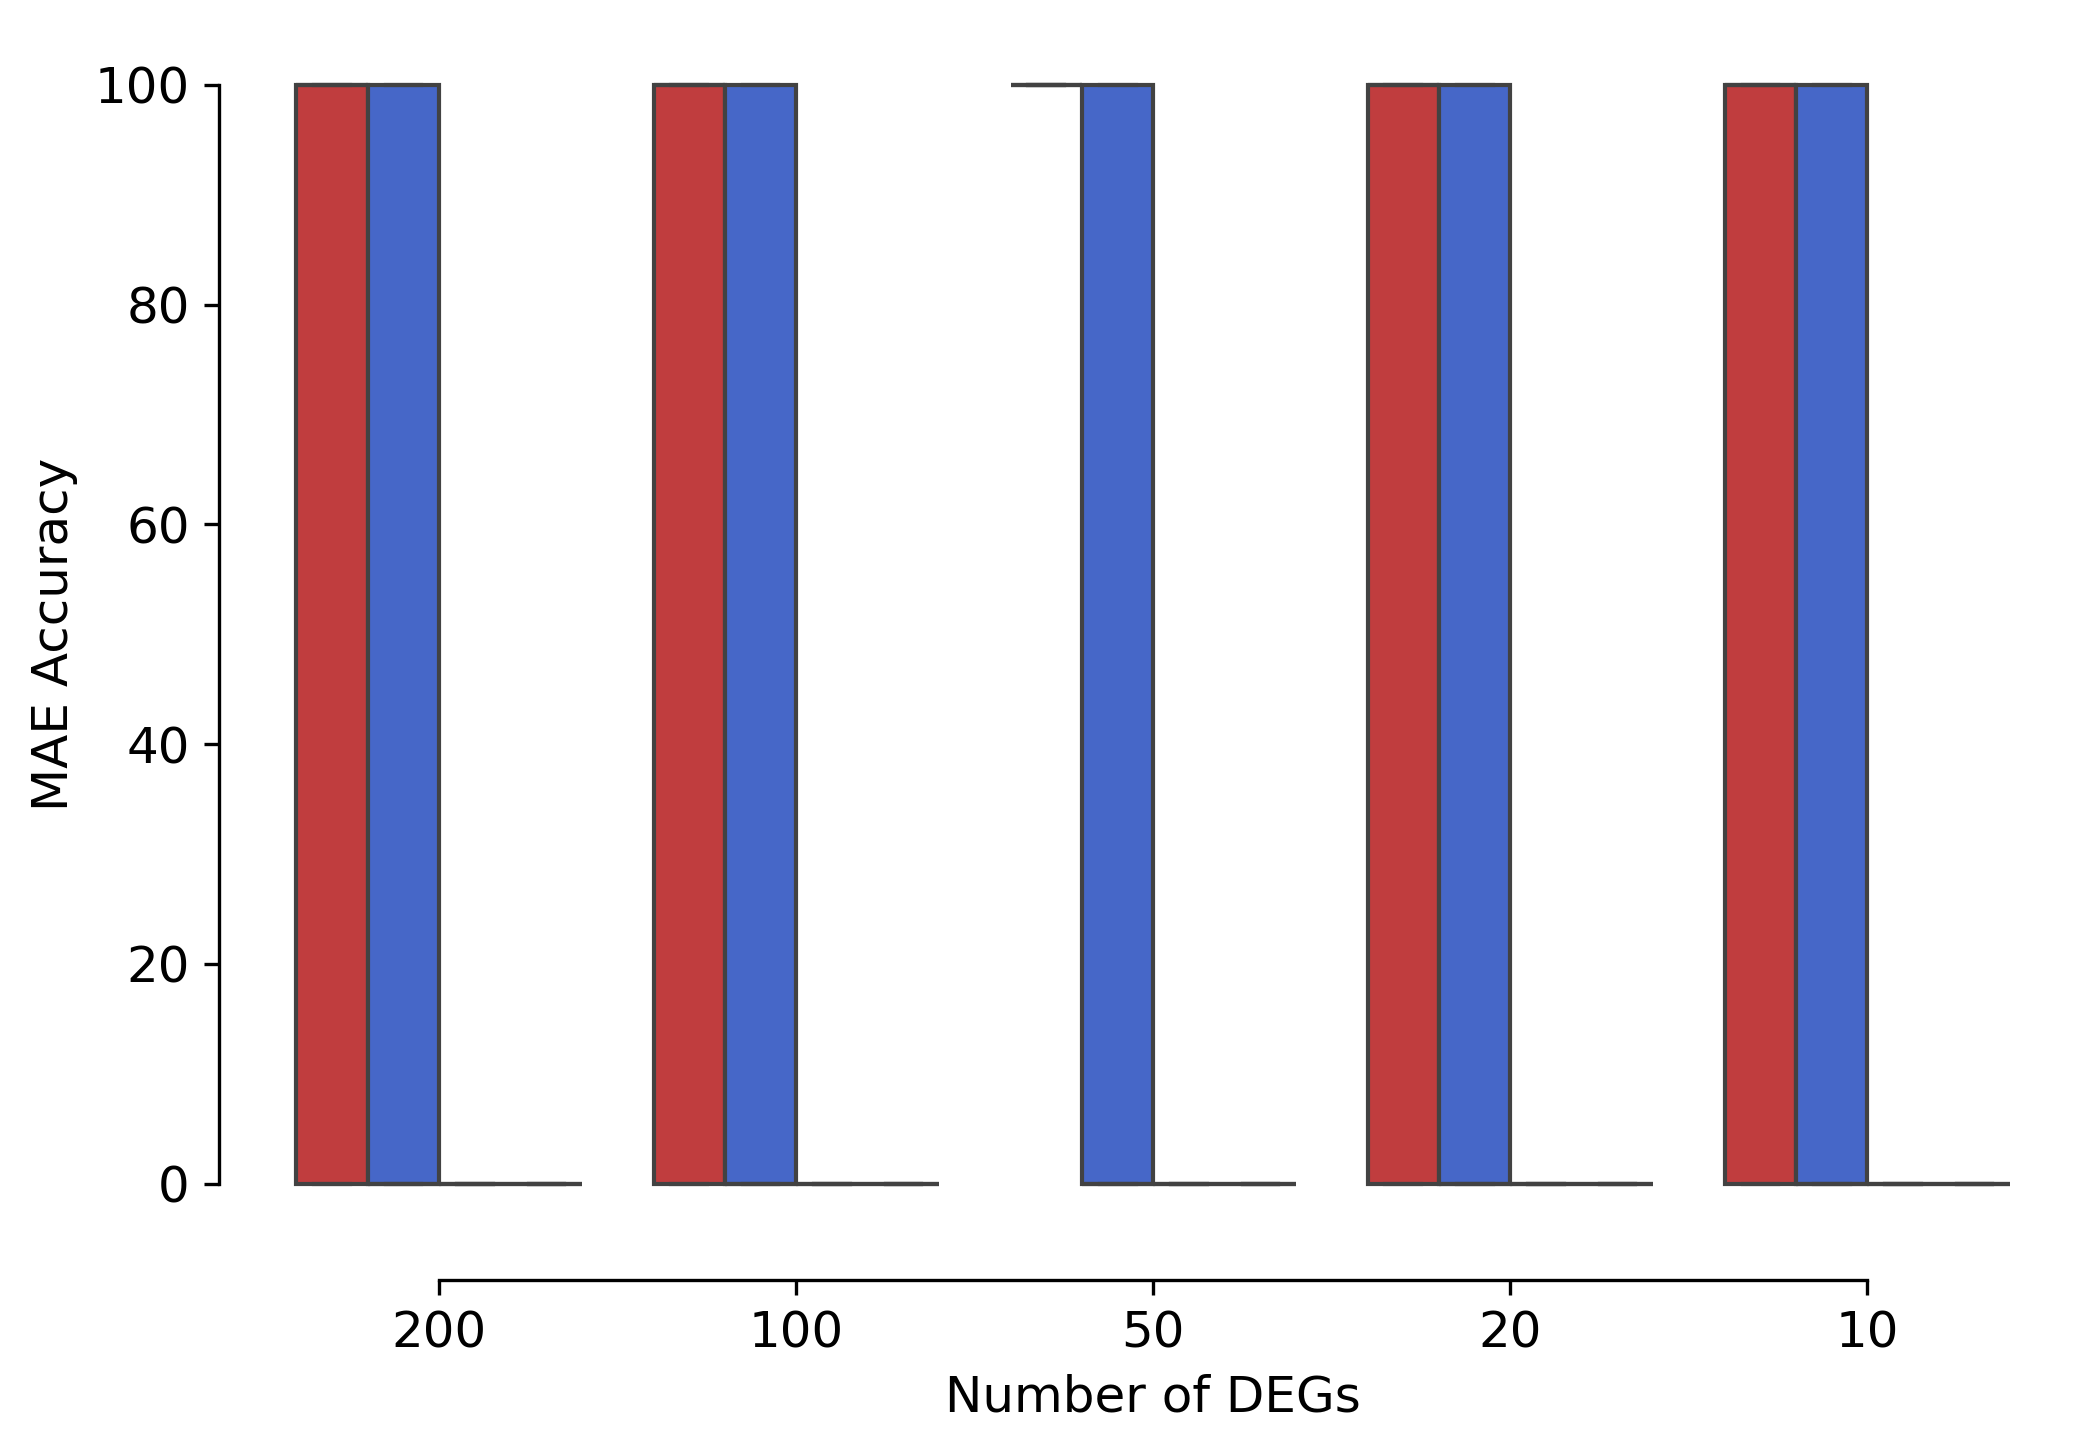

Using 9 perturbation


/home/SE/Desktop/Projects/SCDISENTANGLE/hygeia/hygeia/utils/hplots.py:208: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


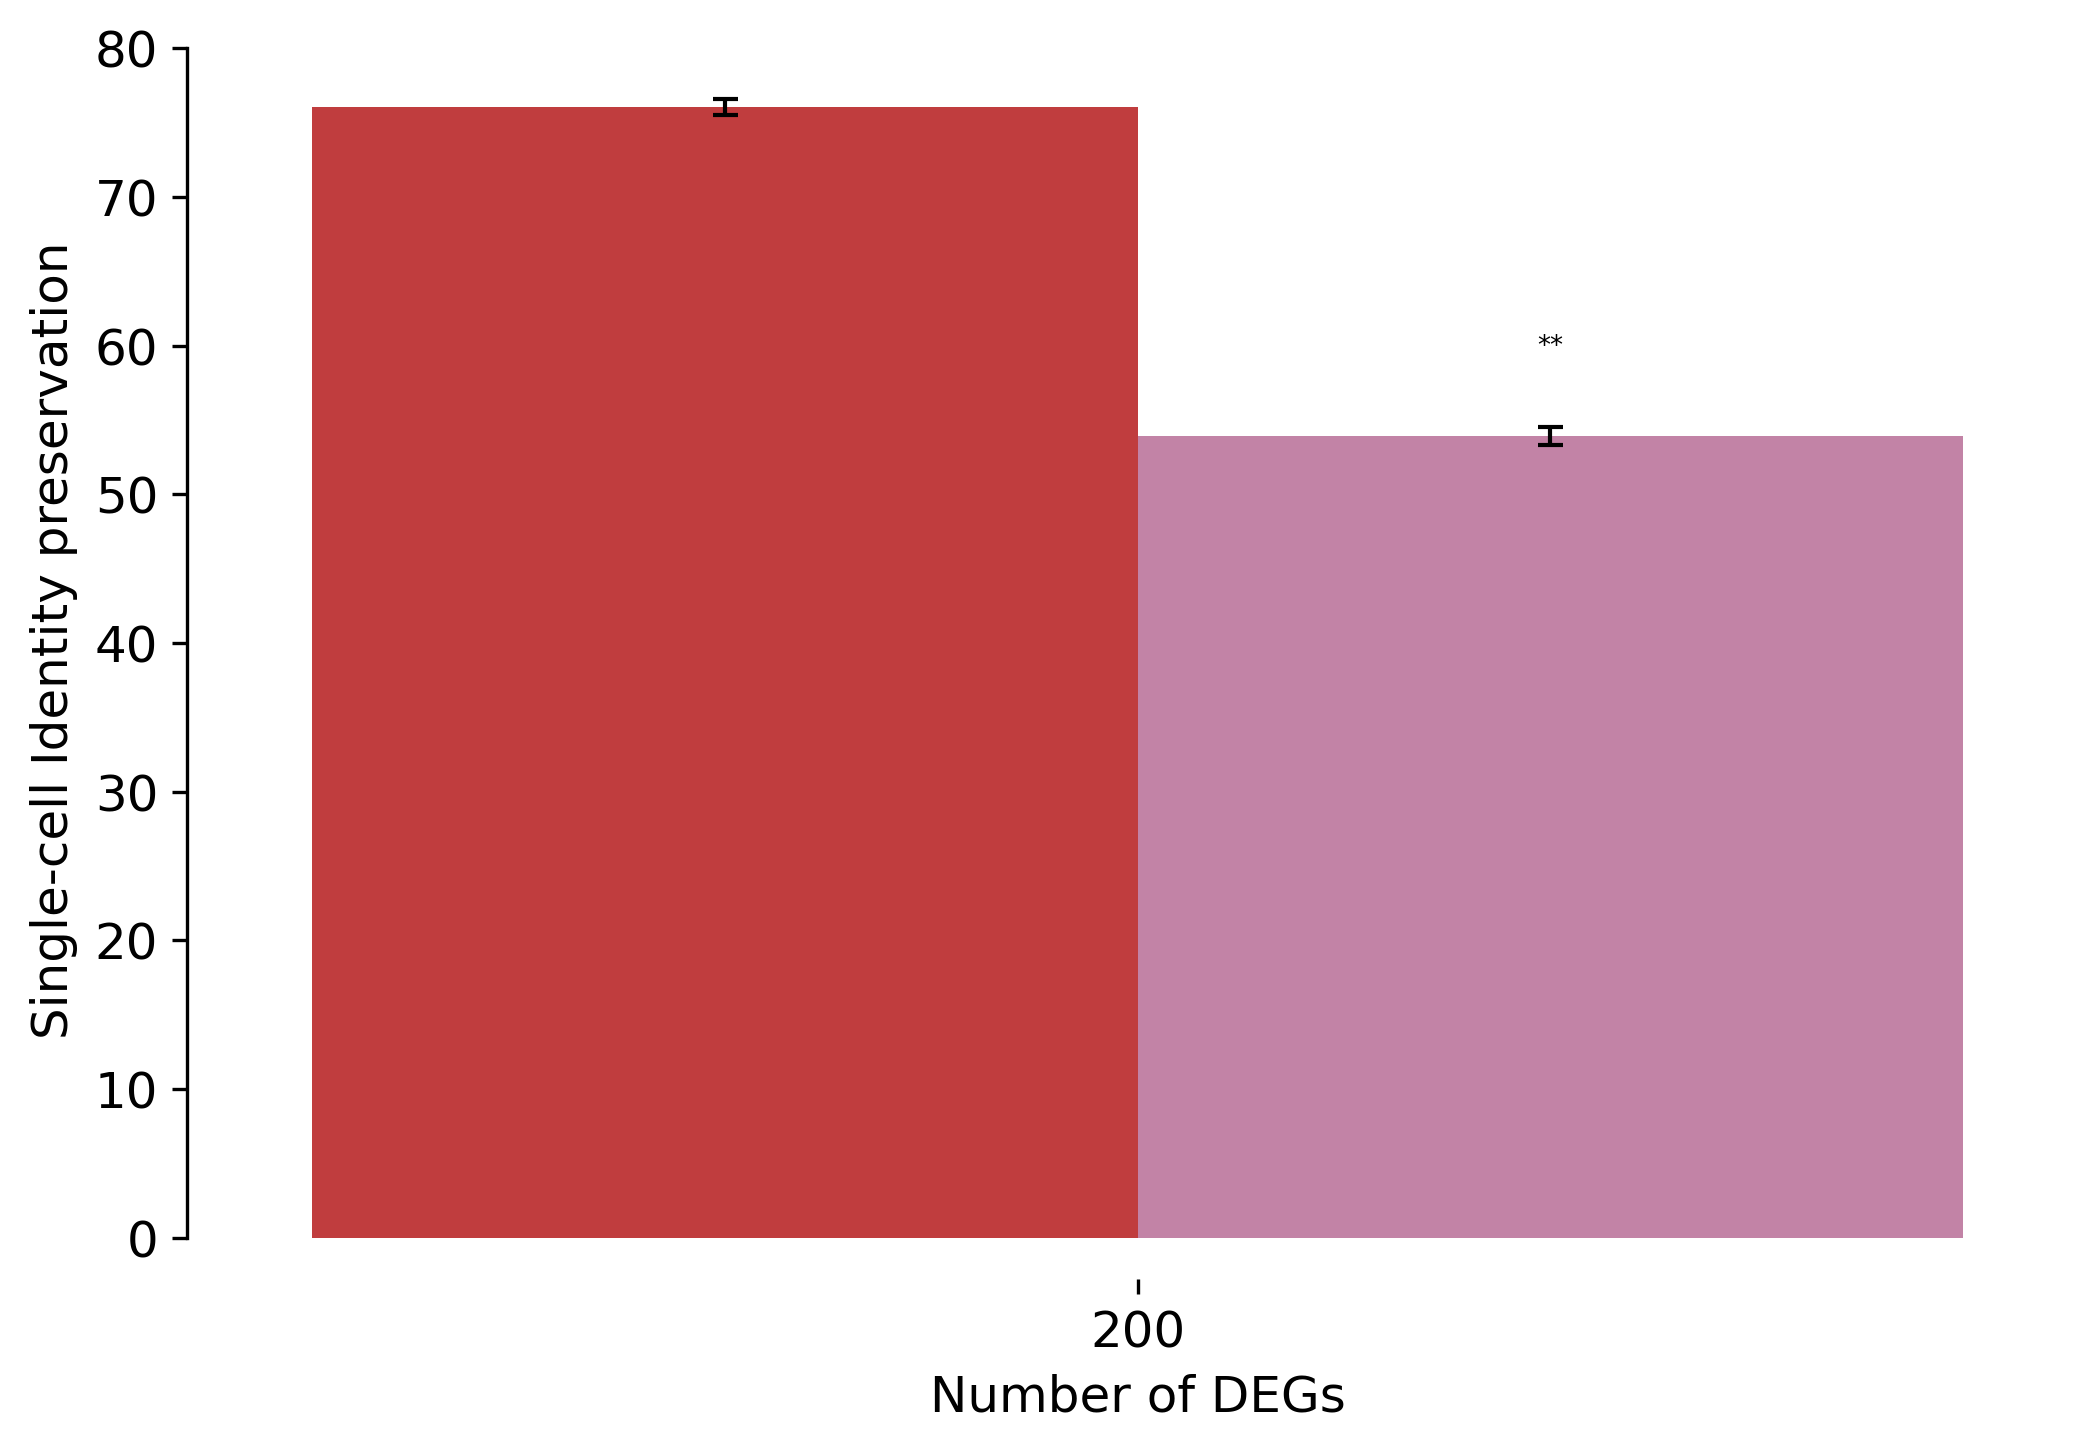

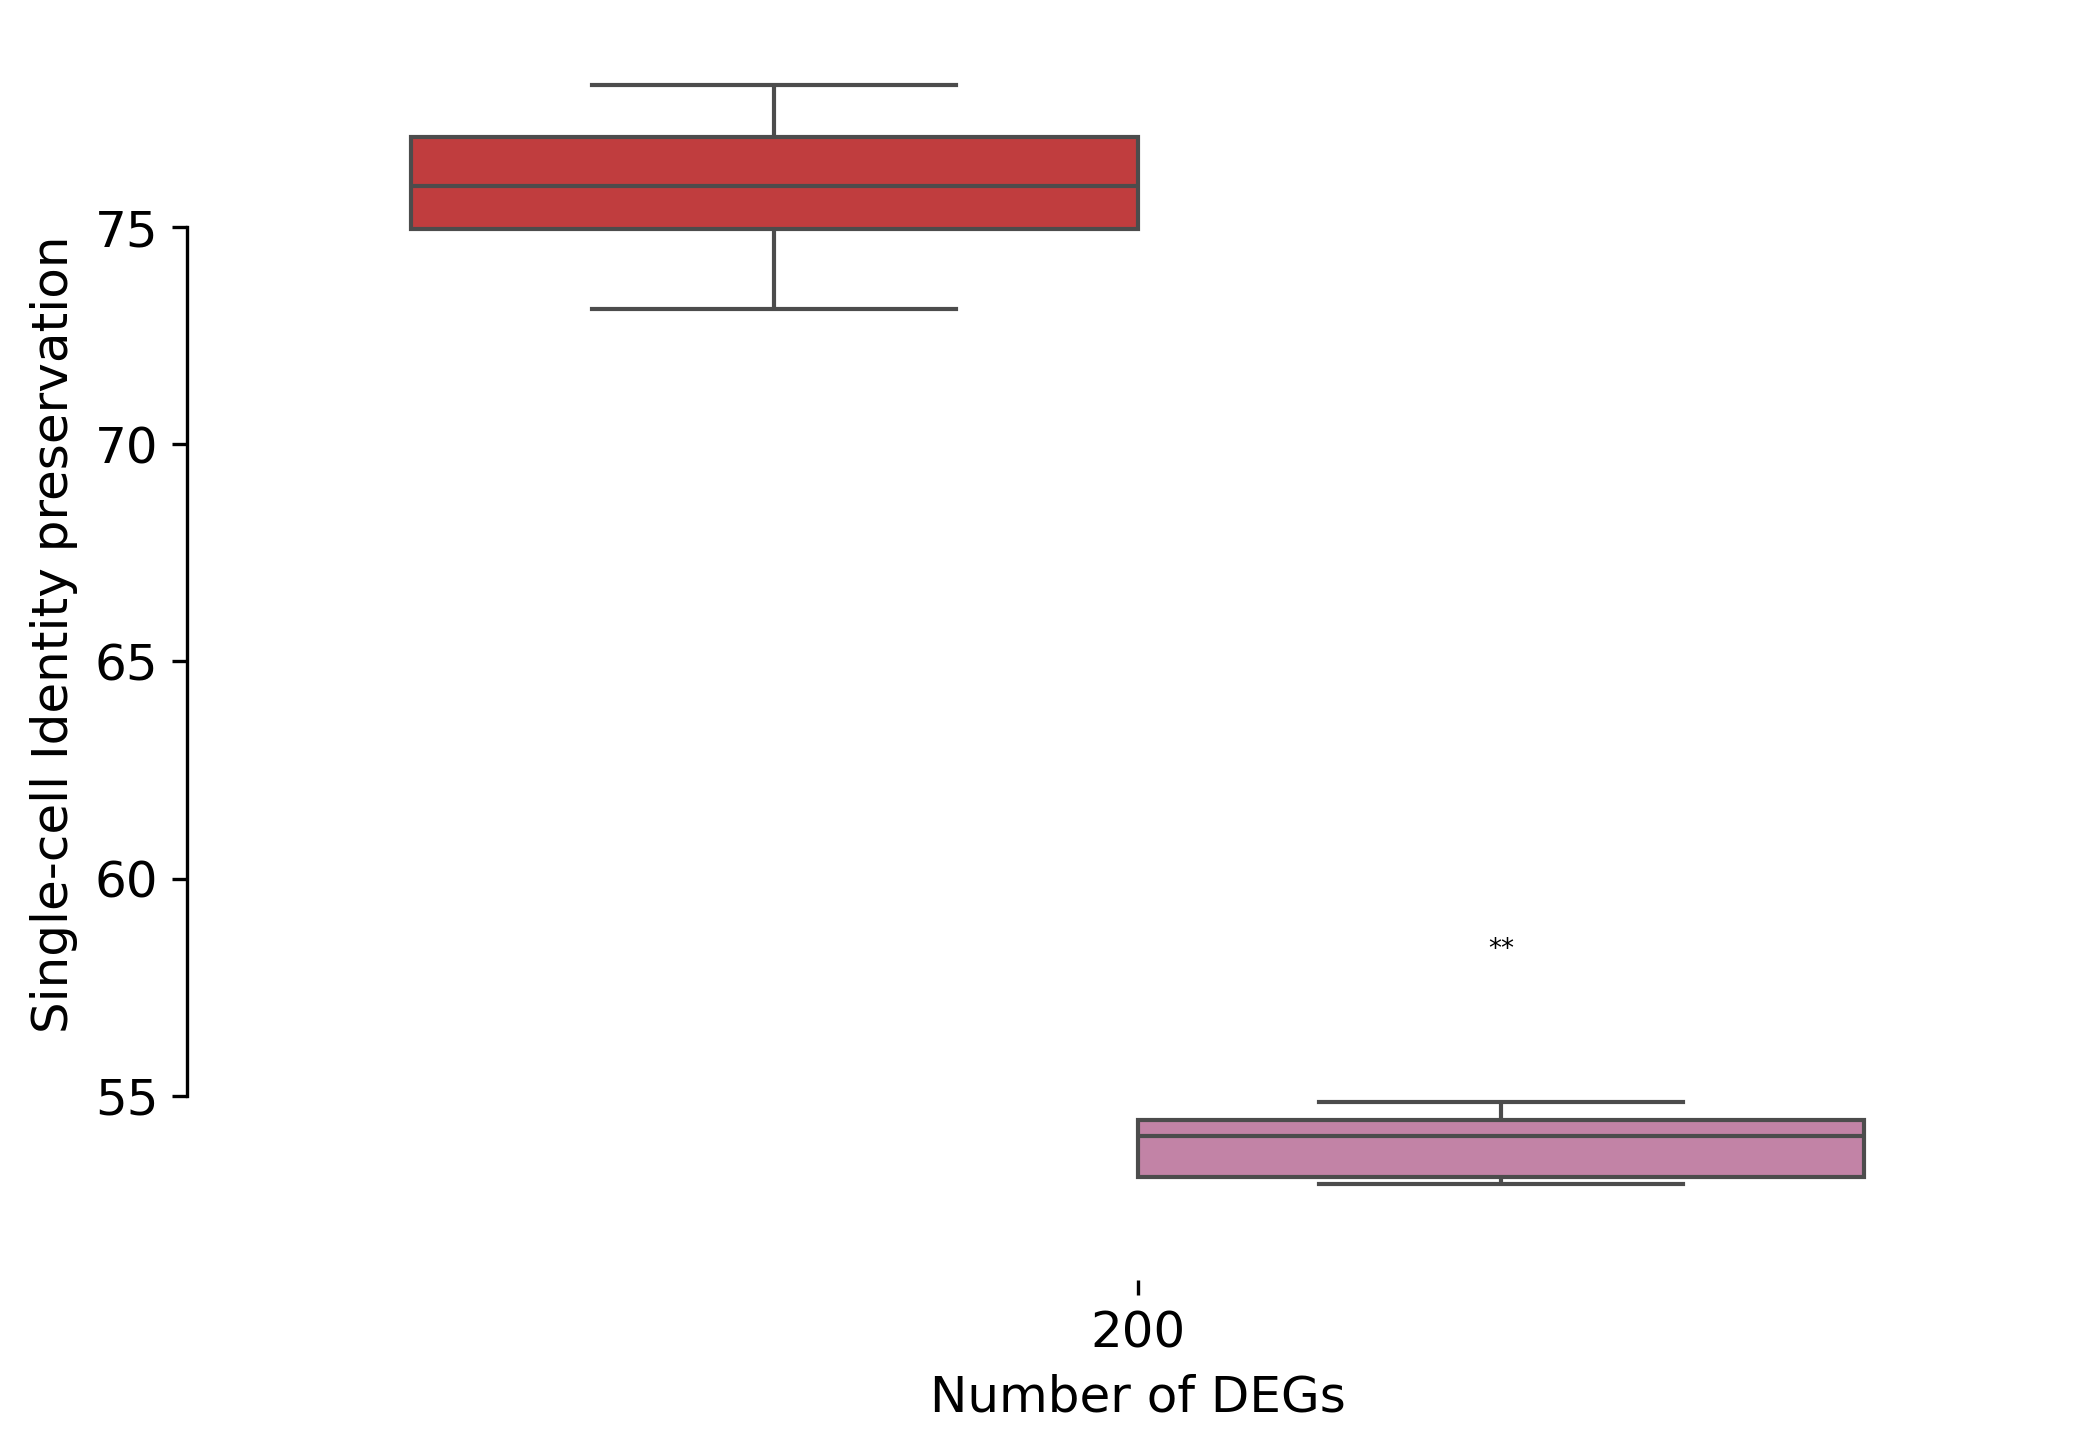

In [9]:
_colors = {
    'scDisentangle': '#d62728',
    'Match-mean': '#305CDE',
    'Perturbation-agnostic': '#698396',
    'GEARS': '#BA8E23',
    'CPA': '#CC79A7',    
    }

_folder_paths = {
     'scDisentangle': f'{base_path}/SCDISENTANGLE/',
     'GEARS': f'{base_path}/GEARS',
     'CPA': f'{base_path}/CPA/', 
     'Match-mean': f'{base_path}/Match Mean',
     'Perturbation-agnostic': f'{base_path}/Pert Mean',
}

for metric_name in [
    'R2 Mean', 'Pearson Mean Delta', 
    'R2 Mean Delta', 'RMSE Mean', 'Wasserstein',
    'Perturbed Reference Pearson Delta',
    'Perturbed Reference R2 Delta', 'Normalized RMSE Mean', 'Centroid Accuracy', 
    'Wasserstein Accuracy', 'MAE Accuracy', 'Single-cell Identity preservation',
]:
    if metric_name in ['Single-cell Identity preservation', 'Centroid Accuracy']:
        n_degs_list = ['200']
    else:
        n_degs_list = ['200', '100', '50', '20', '10']
        
   
    if metric_name not in [
        'R2 Mean', 'Pearson Mean Delta', 
        'R2 Mean Delta', 'RMSE Mean', 'Normalized RMSE Mean',
    ]:
 
        if metric_name in ['Centroid Accuracy', 'MAE Accuracy', 'Perturbed Reference Pearson Delta', 'Perturbed Reference R2 Delta']:
            to_remove = ['Perturbation-agnostic']
        else:
            to_remove = ['Perturbation-agnostic', 'Match-mean']
        colors = {k:v for k,v in _colors.items() if not k in to_remove}
        folder_paths = {k:v for k,v in _folder_paths.items() if not k in to_remove}

    else:
        colors = _colors
        folder_paths = _folder_paths

    if metric_name in ['Single-cell Identity preservation', 'Wasserstein', 'Wasserstein Accuracy']:
        colors = {k:v for k,v in _colors.items() if not k in ['Perturbation-agnostic', 'Match-mean', 'GEARS']}
        folder_paths = {k:v for k,v in _folder_paths.items() if not k in ['Perturbation-agnostic', 'Match-mean', 'GEARS']}
    
    metrics = mt.get_results(
        folder_paths, 
        metric_name=metric_name, 
        perts = all_results, 
        n_degs_list=n_degs_list
    )
    
    pvals, stars = mt.compute_pvalues(
        metrics_dict=metrics,
        metric_name=metric_name,
        higher_is_better=None,
        anchor_method='scDisentangle',
        best_method_only=True
    )
    
    records = hp.plot_data(
                metrics,
                plot_type='barplot', 
                save_path=f'{FIG_ROOT}/{data_name}/{custom_name}/Benchmarks/{metric_name}_bar',
                y_name=metric_name, 
                legend=False, 
                title='',
                colors=colors,
                show_grid=False,
                sort_order=None,
                stars=stars,
            )

    records = hp.plot_data(
                metrics,
                plot_type='boxplot', 
                save_path=f'{FIG_ROOT}/{data_name}/{custom_name}/Benchmarks/{metric_name}_box',
                y_name=metric_name, 
                legend=False, 
                title='',
                colors=colors,
                show_grid=False,
                sort_order=None,
                stars=stars,
            )